# Instanciação de Parâmetros

In [1]:
import pyomo as pyo

GENERATE_NEW_SCENARIOS = False

# Solver
solver_name = 'highs'
# solver_name = 'ipopt'

# Número de meses
T=60

S = 100

S_range = range(1, S+1)

# Parâmetros
a = 60  # Constante da demanda
b = 1/2000    # Elasticidade da demanda
variable_cost_percentage = 0.35  # Percentual de custos variáveis - Depois será utilizado no problema de otimização estocástica
variable_cost_increment = 1.01
variable_expenses_percentage = 0.03  # Percentual de custos variáveis
taxes_percentage = 0.07  # Percentual de impostos sobre vendas, neste caso consideramos uma empresa que opera em lucro presumido
CF = 112_500    # Custo fixo mensal (salários, aluguel, etc)
DF = 247_500    # Despesa fixa mensal
theta_AR = 35/30 # 35 dias de recebimento
theta_I = 30/30 # 30 dias de estoque
theta_AP = 30/30 # 30 dias de pagamento


# Relações de incremento Inc = a_inc * Despesas com Mkt + b_inc
a_inc = 0.25  # Incremento percentual de vendas por R$ despesas com marketing
b_inc = 1000  # Quantidade de vendas alcançadas se não houver despesas com marketing

# Relações de Churn Rate
churn_rate = 0.005  # Taxa de churn rate, ou seja, a porcentagem de clientes que deixam de comprar

# Intervalos de preço e quantidade
P_min = 3 # 3 reais por lata
P_max = 3
Q_min = 250_000 # 250.000 latas
inital_sales = 250_000 # Vendas iniciais
Q_max = 1_000_000

# Variação inicial da NCG (exemplo)
initial_NCG = 875_000 + 262_500 - 262_500 # CR + Estoque Inicial - CP
initial_inventory = 262_500 # 

# Meses usados no cálculo do FCO futuro
months_future_FCO = 12

# Taxa de Incremento do Lucro
profit_increment_rate = 0.8 #0.7
growth_rate = 1.019446 # 1.26 a.a

# Value at risk
alpha_var = 0.05
epsilon_var = 10000  # Valor inicial, será atualizado no loop

# Taxa de Desconto
GAMMA = 0.01

# Parâmetros WACC
initial_equity = 10_000
initial_debt = 0
initial_cost_of_debt = 0.01
cost_of_equity = 0.005
tax_rate = 0.3

# Produção - Capacidade
production_capacity = 350_000  # Capacidade máxima de produção por fábrica
price_of_factory = 100_000  # Custo de construção de uma nova fábrica
factory_lifetime = 120  # Vida útil de uma fábrica em meses

# Dados de Marketing
M_max = 1e6  
initial_mkt = 10

# Dados de Emprestimo
Borrow_max = 10e9
E_max = 10e10
D_max = E_max*2
# Parâmetros do "produto de empréstimo": amortização linear em L meses
L_loan = 12  # exemplo: 12 meses; ajuste como quiser

import matplotlib.pyplot as plt

plt.rcParams['figure.titlesize'] = 16   # Tamanho do título geral da figura
plt.rcParams['axes.titlesize'] = 16     # Tamanho do título dos eixos
plt.rcParams['axes.labelsize'] = 14     # Tamanho dos rótulos (labels) de eixos x e y
plt.rcParams['legend.fontsize'] = 12    # Tamanho da fonte na legenda
plt.rcParams['xtick.labelsize'] = 12    # Tamanho dos rótulos no eixo x
plt.rcParams['ytick.labelsize'] = 12    # Tamanho dos rótulos no eixo y
plt.style.use('default')

In [2]:
from pyomo.environ import *

# Cria um modelo concreto
naive_model = model = ConcreteModel()

# Variáveis de decisão
model.P = Param(initialize=P_min)
model.Q = Var(range(1, T+1), bounds=(Q_min, Q_max), within=NonNegativeReals) # XXX: NonNegativeIntegers
        # exemplo; ajuste ou remova o 'bounds' se não quiser limite
model.M = Var(range(1, T+1), bounds=(0, M_max), within=NonNegativeReals)

# Variável de Churn
model.churn_rate = Param(initialize=churn_rate)

# 1.B  – coeficientes do Increment (fixados em 1, conforme indicado)
model.a_inc = Param(initialize=a_inc)
model.b_inc = Param(initialize=b_inc)

def incr_rule(model, t):
    return model.a_inc * model.M[t] + model.b_inc
model.Increment = Expression(range(1, T+1), rule=incr_rule)

# Variável de Quantidade de fábricas (uma inteira)
model.num_factories = Var(range(1, T+1), within=NonNegativeIntegers)

# Parâmetros de custos, despesas e impostos

initialize_variable_costs=[variable_cost_percentage*variable_cost_increment**t for t in range(0, T)]

model.variable_cost_percentage = Param(range(1, T+1), initialize=lambda model, t: initialize_variable_costs[t-1], mutable=True)
model.variable_expenses_percentage = Param(initialize=variable_expenses_percentage)
model.taxes_percentage = Param(initialize=taxes_percentage)
model.fix_costs = Param(initialize=CF)
model.fix_expenses = Param(initialize=DF)

# Parâmetros de elasticidade da demanda
model.a = Param(initialize=a)
model.b = Param(initialize=b)

# Parâmetro de quantidade inicial de vendas
model.initial_quantity = Param(initialize=Q_min)
model.Q[1].fix(model.initial_quantity)

# Parâmetro de gastos com Mkt no mês 1
model.initial_mkt = Param(initialize=initial_mkt)
model.M[1].fix(model.initial_mkt)

# Parâmetros de NCG
model.theta_AR = Param(initialize=theta_AR)
model.theta_I = Param(initialize=theta_I)
model.theta_AP = Param(initialize=theta_AP)
model.initial_NCG = Param(initialize=initial_NCG)
model.initial_investment = Param(initialize=initial_inventory)

# WACC: Parâmetros WACC
model.cost_of_equity = Param(initialize=cost_of_equity)
model.tax_rate = Param(initialize=tax_rate)

# Expressões Auxiliares Gerais
def revenue_rule(model, t):
    return model.P * model.Q[t]

# Expressões Auxiliares para o cálculo do número de fábricas
def depreciation_rule(model, t):
    return (price_of_factory / factory_lifetime) * model.num_factories[t]

model.initial_factories = Param(initialize=Q_min//production_capacity, mutable=False)

def difference_on_factories_rule(model, t):
    prev = model.num_factories[t-1] if t > 1 else model.initial_factories
    return model.num_factories[t] - prev  # agora é expressão Pyomo para todo t

model.price_of_factory = Param(initialize=price_of_factory, mutable=False)

def capex_aquisi_rule(model, t):
    return model.price_of_factory * difference_on_factories_rule(model, t)

# Expressões Auxiliares para cálculo da NCG

def AR_rule(model, t):
    # return 0
    return revenue_rule(model, t) * model.theta_AR

def I_rule(model, t):
    # return 0
    return (model.variable_cost_percentage[t] * revenue_rule(model, t)) * model.theta_I

#TODO: Adicionar o I aqui
def AP_rule(model, t):
    i_t_minus_1 = I_rule(model, t-1) if t > 1 else model.initial_investment
    return (I_rule(model, t) + model.variable_cost_percentage[t] * revenue_rule(model, t) -i_t_minus_1) * model.theta_AP

def NCG_rule(model, t):
    # return AR_rule(model, t) + I_rule(model, t) - AP_rule(model, t) - (AR_rule(model, t-1) + I_rule(model, t-1) - AP_rule(model, t-1) if t > 1 else model.initial_NCG)
    if t > 1:
        return AR_rule(model, t) + I_rule(model, t) - AP_rule(model, t) - (AR_rule(model, t-1) + I_rule(model, t-1) - AP_rule(model, t-1) if t > 1 else model.initial_NCG)
    else:
        # return AR_rule(model, t) + I_rule(model, t) - AP_rule(model, t) - AR_rule(model, t) + I_rule(model, t) - AP_rule(model, t) 
        return AR_rule(model, t) + I_rule(model, t) - AP_rule(model, t) - model.initial_NCG

def fcf_period_expression(model, t_period):
    receita = revenue_rule(model, t_period)
    depreciation = depreciation_rule(model, t_period)
    capex_aquisi = capex_aquisi_rule(model, t_period)
    return (receita
            - model.variable_cost_percentage[t_period] * receita
            - model.variable_expenses_percentage * receita
            - model.M[t_period]
            - model.taxes_percentage * receita
            - model.fix_costs
            - model.fix_expenses
            - depreciation
            - capex_aquisi
            - NCG_rule(model, t_period))

# WACC: Expressões para ratios WACC
def old_wacc():
    # ABAIXO SÃO OS ANTIGOS

    # def equity_ratio_rule(model, t):
    #     return model.E[t] / (model.E[t] + model.D[t])

    # def debt_ratio_rule(model, t):
    #     return model.D[t] / (model.E[t] + model.D[t])

    # model.equity_ratio = Expression(range(1, T+1), rule=equity_ratio_rule)
    # model.debt_ratio = Expression(range(1, T+1), rule=debt_ratio_rule)

    # # WACC: Expressão WACC Dinâmico
    # def wacc_rule(model, t):
    #     return (model.equity_ratio[t] * model.cost_of_equity + 
    #             model.debt_ratio[t] * model.cost_of_debt[t] * (1 - model.tax_rate))

    # model.WACC = Expression(range(1, T+1), rule=wacc_rule)

    # # WACC: Restrições valores iniciais WACC
    # def initial_equity_rule(model):
    #     return model.E[1] == initial_equity

    # def initial_debt_rule(model):
    #     return model.D[1] == initial_debt

    # def initial_cost_of_debt_rule(model):
    #     return model.cost_of_debt[1] == initial_cost_of_debt

    # model.initial_equity_constraint = Constraint(rule=initial_equity_rule)
    # model.initial_debt_constraint = Constraint(rule=initial_debt_rule)
    # model.initial_cost_of_debt_constraint = Constraint(rule=initial_cost_of_debt_rule)
    ...

# ABAIXO SÃO OS NOVOS

# ----------------------------
# BLOCO: Capital (E, D) e WACC
# ----------------------------

# Fixar custo da dívida (exógeno)
model.cost_of_debt = Param(range(1, T+1), initialize=lambda m,t: initial_cost_of_debt)

# Estoques de capital (E e D)
model.E = Var(range(1, T+1), bounds=(0, E_max), within=NonNegativeReals, initialize=lambda m,t: 100_000)
model.D = Var(range(1, T+1), bounds=(0, D_max), within=NonNegativeReals, initialize=lambda m,t: 10_000)

# Fluxos de financiamento
model.Borrow = Var(range(1, T+1), bounds=(0, Borrow_max), within=NonNegativeReals)

# Amortização total do mês (inclui amortização de dívidas antigas + das novas tomadas)
model.Repay = Var(range(1, T+1), bounds=(0, Borrow_max), within=NonNegativeReals)

# Amortização do estoque inicial (assumindo que ele será pago linearmente em L_loan meses a partir do mês 1)
def init_amort_rule(m, t):
    return initial_debt / L_loan if t <= L_loan else 0.0
model.init_amort = Param(range(1, T+1), initialize=init_amort_rule, mutable=False)

# Amortização das novas tomadas: cada Borrow[k] paga 1/L_loan por mês durante L_loan meses
def repay_schedule_rule(m, t):
    # soma das parcelas (Borrow[t], Borrow[t-1], ..., Borrow[t-L_loan+1]) / L_loan
    s = 0
    kmin = max(1, t - L_loan + 1)
    for k in range(kmin, t+1):
        s += m.Borrow[k]
    return m.Repay[t] == m.init_amort[t] + (1.0 / L_loan) * s

model.repay_schedule = Constraint(range(1, T+1), rule=repay_schedule_rule)

# Dinâmica da dívida (estoque)
def debt_dyn_rule(m, t):
    if t == 1:
        return m.D[1] == initial_debt + m.Borrow[1] - m.Repay[1]
    return m.D[t] == m.D[t-1] + m.Borrow[t] - m.Repay[t]
model.debt_dyn = Constraint(range(1, T+1), rule=debt_dyn_rule)

# Juros (sobre D do mês anterior; no t=1 usa initial_debt)
def interest_rule(m, t):
    D_prev = initial_debt if t == 1 else m.D[t-1]
    return m.cost_of_debt[t] * D_prev
model.Interest = Expression(range(1, T+1), rule=interest_rule)

def ebit_rule(m, t):
    receita = revenue_rule(m, t)
    dep = depreciation_rule(m, t)
    return (receita
            - m.variable_cost_percentage[t] * receita
            - m.variable_expenses_percentage * receita
            - m.M[t]
            - m.taxes_percentage * receita
            - m.fix_costs
            - m.fix_expenses
            - dep)
model.EBIT = Expression(range(1, T+1), rule=ebit_rule)

def ni_rule(m, t):
    return m.EBIT[t] - m.Interest[t]
model.NI = Expression(range(1, T+1), rule=ni_rule)


# Evitar divisão por zero nos pesos do WACC, além de evitar que o estoque de capital seja negativo (o que não faz sentido)
eps = 10_000
model.capital_positive = Constraint(range(1, T+1), rule=lambda m,t: m.E[t] + m.D[t] >= eps)

# Pesos
def equity_ratio_rule(m, t):
    return m.E[t] / (m.E[t] + m.D[t])
def debt_ratio_rule(m, t):
    return m.D[t] / (m.E[t] + m.D[t])

model.equity_ratio = Expression(range(1, T+1), rule=equity_ratio_rule)
model.debt_ratio   = Expression(range(1, T+1), rule=debt_ratio_rule)

def equity_dyn_rule(m, t):
    if t == 1:
        return m.E[1] == initial_equity + m.NI[1]
    return m.E[t] == m.E[t-1] + m.NI[t]
model.equity_dyn = Constraint(range(1, T+1), rule=equity_dyn_rule)


# WACC dinâmico
def wacc_rule(m, t):
    return (m.equity_ratio[t] * m.cost_of_equity +
            m.debt_ratio[t] * m.cost_of_debt[t])
# model.WACC = Expression(range(1, T+1), rule=wacc_rule)

WACC_MIN = 0.001
WACC_MAX = 0.999          # ajuste
CAPITAL_MIN = 100_000     # ajuste (ver nota abaixo)

model.WACC = Var(range(1, T+1), bounds=(WACC_MIN, WACC_MAX), initialize=0.10)

model.capital_positive = Constraint(
    range(1, T+1),
    rule=lambda m,t: m.E[t] + m.D[t] >= CAPITAL_MIN
)

def wacc_def_rule(m, t):
    return (m.E[t] + m.D[t]) * m.WACC[t] == m.E[t] * m.cost_of_equity + m.D[t] * m.cost_of_debt[t]

model.wacc_def = Constraint(range(1, T+1), rule=wacc_def_rule)



# Crie uma restrição para garantir que o WACC seja positivo
model.wacc_positive = Constraint(range(1, T+1), rule=lambda m,t: m.WACC[t] >= 0.001)

## FIM DO NOVO ##

def objective_rule(model):
    t_final = T

    return sum(
        fcf_period_expression(model, t_period) / ((1 + model.WACC[t_period]) ** t_period)
        for t_period in range(t_final - months_future_FCO + 1, t_final + 1)
    )

model.objective = Objective(rule=objective_rule, sense=maximize)

# Restrição de demanda
def demand_rule(model, t):
    return model.P[t] == model.a - model.b * model.Q[t]

# model.demand = Constraint(range(1, T+1), rule=demand_rule)

def fco_rule(model, t):
    receita = revenue_rule(model, t)
    depreciation = depreciation_rule(model, t)
    capex_aquisi = capex_aquisi_rule(model, t)
    return (receita
            - model.variable_cost_percentage[t] * receita
            - model.variable_expenses_percentage * receita
            - model.M[t]                               # << NOVO
            - model.taxes_percentage * receita
            - model.fix_costs
            - model.fix_expenses
            - depreciation
            - capex_aquisi
            - NCG_rule(model, t)) >= 0


# model.fco = Constraint(range(1, T+1), rule=fco_rule)

# Restrição de quantidade poder crescer unicamente 10% em cada mês
def growth_rule(model, t):
    return model.Q[t] <= model.Q[t-1] * growth_rate if t > 1 else model.Q[t] <= model.initial_quantity

model.growth = Constraint(range(1, T+1), rule=growth_rule)

# Restrição de o lucro ser maior ou igual ao mês anterior
def profit_rule(model, t):
    if t <= 2:
        return Constraint.Skip          # ou qualquer relaxamento que já usava

    receita_t   = revenue_rule(model, t)
    receita_tm1 = revenue_rule(model, t-1)

    lucro_t = (receita_t
               - model.variable_cost_percentage[t]   * receita_t
               - model.variable_expenses_percentage  * receita_t
               - model.M[t]                          # << NOVO
               - model.taxes_percentage              * receita_t
               - model.fix_costs
               - model.fix_expenses)

    lucro_tm1 = (receita_tm1
                 - model.variable_cost_percentage[t-1] * receita_tm1
                 - model.variable_expenses_percentage  * receita_tm1
                 - model.M[t-1]                        # << NOVO
                 - model.taxes_percentage              * receita_tm1
                 - model.fix_costs
                 - model.fix_expenses)

    return lucro_t >= lucro_tm1 * profit_increment_rate


# model.profit = Constraint(range(1, T+1), rule=profit_rule)

def non_regression_rule(model, t):
    return model.Q[t] >= model.Q[t-1] if t > 1 else model.Q[t] >= model.initial_quantity

model.non_regression = Constraint(range(1, T+1), rule=non_regression_rule)

def qty_increment_rule(model, t):
    if t == 1:
        return Constraint.Skip          # já fixamos Q[1] no valor inicial
    return model.Q[t] == (1 - model.churn_rate) * model.Q[t-1] + model.Increment[t]

model.qty_increment = Constraint(range(1, T+1), rule=qty_increment_rule)

# Restrições dos Capex

# Aquisição de novas fábricas deve ser 0 ou positiva
def capex_aquisi_constraint_rule(model, t):
    return capex_aquisi_rule(model, t) >= 0

model.capex_aquisi_constraint = Constraint(range(1, T+1), rule=capex_aquisi_constraint_rule)

# quantidade de fábricas deve ser >= qt * capacidade de produção
def production_capacity_rule(model, t):
    return model.Q[t] <= model.num_factories[t] * production_capacity

model.production_capacity_constraint = Constraint(range(1, T+1), rule=production_capacity_rule)

# Componentes da NCG
model.AR = Expression(range(1, T+1), rule=AR_rule)
model.I = Expression(range(1, T+1), rule=I_rule)
model.AP = Expression(range(1, T+1), rule=AP_rule)
model.NCG = Expression(range(1, T+1), rule=NCG_rule)

# Resolver o modelo
solver = SolverFactory("mindtpy")

# solver.options['max_iter'] = 1000
# solver.options['tol'] = 1e-6
# solver.options['NonConvex'] = 2
result = solver.solve(
    model, 
    strategy="OA",          # alternativas: "ECP", "GBD"
    init_strategy="rNLP",   # começa resolvendo a relaxação contínua
    mip_solver="appsi_highs",       # ou "gurobi"/"cplex"
    nlp_solver="ipopt",
    tee=True,
)


# Exibir os resultados
for t in range(1, T+1):
    print(f'Mês {t}: Preço = {model.P.value}, Quantidade = {model.Q[t].value}')
    
    # print(f'Mês {t}: Preço = {model.P[t].value}, Quantidade = {model.Q[t].value}, AR = {model.AR[t].value}, Estoque = {model.I[t].value}, AP = {model.AP[t].value}')

(type=<class 'pyomo.core.base.constraint.IndexedConstraint'>) on block unknown
with a new Component (type=<class
'pyomo.core.base.constraint.IndexedConstraint'>). This is usually indicative
of a modelling error. To avoid this warning, use block.del_component() and
block.add_component().


Starting MindtPy version 1.0.0 using OA algorithm
iteration_limit: 50
stalling_limit: 15
time_limit: 600
strategy: OA
add_regularization: None
call_after_main_solve: <pyomo.contrib.gdpopt.util._DoNothing object at 0x12eaf02b0>
call_before_subproblem_solve: <pyomo.contrib.gdpopt.util._DoNothing object at 0x12ea6ab10>
call_after_subproblem_solve: <pyomo.contrib.gdpopt.util._DoNothing object at 0x12ead49e0>
call_after_subproblem_feasible: <pyomo.contrib.gdpopt.util._DoNothing object at 0x12ead4af0>
tee: true
logger: <Logger pyomo.contrib.mindtpy (INFO)>
logging_level: 20
integer_to_binary: false
add_no_good_cuts: false
use_tabu_list: false
single_tree: false
solution_pool: false
num_solution_iteration: 5
cycling_check: true
feasibility_norm: L_infinity
differentiate_mode: reverse_symbolic
use_mcpp: false
calculate_dual_at_solution: false
use_fbbt: false
use_dual_bound: true
partition_obj_nonlinear_terms: true
quadratic_strategy: 0
move_objective: false
add_cuts_at_incumbent: false
heurist

deprecated. Either specify deactivated Blocks as targets to activate them if
transforming them is the desired behavior.  (deprecated in 6.9.3) (called from
/Users/henriquealvesbarbosa/opt/anaconda3/envs/valuation-
optimization/lib/python3.13/site-
packages/pyomo/core/base/transformation.py:77)


         -       Relaxed NLP       1.81683e+06           -inf    1.81683e+06      nan%      1.14
         1              MILP       1.81612e+06           -inf    1.81612e+06      nan%      1.52
*        1         Fixed NLP       1.81612e+06    1.81612e+06    1.81612e+06    -0.00%      1.75
MindtPy exiting on bound convergence. Absolute gap: -6.552552804350853e-06 <= absolute tolerance: 0.0001 

 Primal integral          :    0.0000 
 Dual integral            :   802.8180 
 Primal-dual gap integral :   802.8180 


Mês 1: Preço = 3, Quantidade = 250000
Mês 2: Preço = 3, Quantidade = 254861.50000000998
Mês 3: Preço = 3, Quantidade = 259817.53672902015
Mês 4: Preço = 3, Quantidade = 264869.94854826265
Mês 5: Preço = 3, Quantidade = 270020.60956774215
Mês 6: Preço = 3, Quantidade = 275271.43034140643
Mês 7: Preço = 3, Quantidade = 280624.3585758354
Mês 8: Preço = 3, Quantidade = 286081.3798527111
Mês 9: Preço = 3, Quantidade = 291644.5183653369
Mês 10: Preço = 3, Quantidade = 297315.83766947914
Mês 11: Preço = 3, Quantidade = 303097.4414488098
Mês 12: Preço = 3, Quantidade = 308991.4742952333
Mês 13: Preço = 3, Quantidade = 315000.1225043884
Mês 14: Preço = 3, Quantidade = 321125.6148866187
Mês 15: Preço = 3, Quantidade = 327370.22359371383
Mês 16: Preço = 3, Quantidade = 333736.26496172714
Mês 17: Preço = 3, Quantidade = 340226.10037018295
Mês 18: Preço = 3, Quantidade = 346842.13711799146
Mês 19: Preço = 3, Quantidade = 353586.8293163979
Mês 20: Preço = 3, Quantidade = 360462.6787992945
Mês 21: Pr

# Modelo Determinístico

## Validação com Dados Reais (Agência de Automação e IA)

In [ ]:
import pyomo as pyo

GENERATE_NEW_SCENARIOS = False

# Solver
solver_name = 'highs'
# solver_name = 'ipopt'

# Número de meses
T=12

S = 100

S_range = range(1, S+1)

# Parâmetros
a = 60  # Constante da demanda
b = 1/2000    # Elasticidade da demanda
variable_cost_percentage = 0.157 + 0.15  # Preciso de adicionar os valores de 5,3% para cada sócio
variable_cost_increment = 1.00
variable_expenses_percentage = 0.15  # Percentual de custos variáveis
taxes_percentage = 0.07  # Percentual de impostos sobre vendas, neste caso consideramos uma empresa que opera em lucro presumido
CF = 2_333.96    # Custo fixo mensal (salários, aluguel, etc)
DF = 5_148.8 + 2_333.96    # Despesa fixa mensal
theta_AR = 180/30 # 35 dias de recebimento
theta_I = 0/30 # 30 dias de estoque
theta_AP = 30/30 # 30 dias de pagamento


# Relações de incremento Inc = a_inc * Despesas com Mkt + b_inc
a_inc = 10/10_800  # Incremento percentual de vendas por R$ despesas com marketing
b_inc = 0  # Quantidade de vendas alcançadas se não houver despesas com marketing

# Relações de Churn Rate
churn_rate = 0.05  # Taxa de churn rate, ou seja, a porcentagem de clientes que deixam de comprar

# Intervalos de preço e quantidade
P_min = 10_800 # 3 reais por lata
P_max = 10_800
Q_min = 19 # 250.000 latas
inital_sales = 19 # Vendas iniciais
Q_max = 1_000_000

# Variação inicial da NCG (exemplo)
initial_NCG = 1231200 + 0 - 125992.8/2 # AR = 1231200.0, Estoque (I) = 62996.4, AP = 125992.8, NCG = -1.8917489796876907e-10
initial_inventory = 0 # 

# Meses usados no cálculo do FCO futuro
months_future_FCO = 3

# Taxa de Incremento do Lucro
profit_increment_rate = 0.7 #0.7
growth_rate = 1.5 # 1.5% a.m

# Value at risk
alpha_var = 0.05
epsilon_var = 10000  # Valor inicial, será atualizado no loop

# Taxa de Desconto
GAMMA = 0.01

# Parâmetros WACC
initial_equity = 10_000
initial_debt = 0
initial_cost_of_debt = 0.005 #25% ano
cost_of_equity = 0.01 #30% ano
tax_rate = 0.06

# Produção - Capacidade
production_capacity = 7  # Capacidade máxima de produção por fábrica
price_of_factory = 3_200  # Custo de construção de uma nova fábrica
factory_lifetime = 1  # Vida útil de uma fábrica em meses

# Dados de Marketing
M_max = 1e6  
initial_mkt = 3_760.9

# Dados de Emprestimo
Borrow_max = 10_000
E_max = 10e6
D_max = E_max*2
# Parâmetros do "produto de empréstimo": amortização linear em L meses
L_loan = 12  # exemplo: 12 meses; ajuste como quiser

import matplotlib.pyplot as plt

plt.rcParams['figure.titlesize'] = 16   # Tamanho do título geral da figura
plt.rcParams['axes.titlesize'] = 16     # Tamanho do título dos eixos
plt.rcParams['axes.labelsize'] = 14     # Tamanho dos rótulos (labels) de eixos x e y
plt.rcParams['legend.fontsize'] = 12    # Tamanho da fonte na legenda
plt.rcParams['xtick.labelsize'] = 12    # Tamanho dos rótulos no eixo x
plt.rcParams['ytick.labelsize'] = 12    # Tamanho dos rótulos no eixo y
plt.style.use('default')

In [4]:
from pyomo.environ import *

# Cria um modelo concreto
naive_model = model = ConcreteModel()

# Variáveis de decisão
model.P = Param(initialize=P_min)
model.Q = Var(range(1, T+1), bounds=(Q_min, Q_max), within=NonNegativeReals) # XXX: NonNegativeIntegers
        # exemplo; ajuste ou remova o 'bounds' se não quiser limite
model.M = Var(range(1, T+1), bounds=(0, M_max), within=NonNegativeReals)

# Variável de Churn
model.churn_rate = Param(initialize=churn_rate)

# 1.B  – coeficientes do Increment (fixados em 1, conforme indicado)
model.a_inc = Param(initialize=a_inc)
model.b_inc = Param(initialize=b_inc)

def incr_rule(model, t):
    return model.a_inc * model.M[t] + model.b_inc
model.Increment = Expression(range(1, T+1), rule=incr_rule)

# Variável de Quantidade de fábricas (uma inteira)
model.num_factories = Var(range(1, T+1), within=NonNegativeIntegers)
# fixar o número de fábricas de t=1
model.num_factories[1].fix(3)

# Parâmetros de custos, despesas e impostos

initialize_variable_costs=[variable_cost_percentage*variable_cost_increment**t for t in range(0, T)]

model.variable_cost_percentage = Param(range(1, T+1), initialize=lambda model, t: initialize_variable_costs[t-1], mutable=True)
model.variable_expenses_percentage = Param(initialize=variable_expenses_percentage)
model.taxes_percentage = Param(initialize=taxes_percentage)
model.fix_costs = Param(initialize=CF)
model.fix_expenses = Param(initialize=DF)

# Parâmetros de elasticidade da demanda
model.a = Param(initialize=a)
model.b = Param(initialize=b)

# Parâmetro de quantidade inicial de vendas
model.initial_quantity = Param(initialize=Q_min)
model.Q[1].fix(model.initial_quantity)

# Parâmetro de gastos com Mkt no mês 1
model.initial_mkt = Param(initialize=initial_mkt)
model.M[1].fix(model.initial_mkt)

# Parâmetros de NCG
model.theta_AR = Param(initialize=theta_AR)
model.theta_I = Param(initialize=theta_I)
model.theta_AP = Param(initialize=theta_AP)
model.initial_NCG = Param(initialize=initial_NCG)
model.initial_investment = Param(initialize=initial_inventory)

# WACC: Parâmetros WACC
model.cost_of_equity = Param(initialize=cost_of_equity)
model.tax_rate = Param(initialize=tax_rate)

# Expressões Auxiliares Gerais
def revenue_rule(model, t):
    return model.P * model.Q[t]

# Expressões Auxiliares para o cálculo do número de fábricas
def depreciation_rule(model, t):
    return (price_of_factory / factory_lifetime) * model.num_factories[t]

model.initial_factories = Param(initialize=3, mutable=False)

def difference_on_factories_rule(model, t):
    prev = model.num_factories[t-1] if t > 1 else model.initial_factories
    return model.num_factories[t] - prev  # agora é expressão Pyomo para todo t

model.price_of_factory = Param(initialize=price_of_factory, mutable=False)

def capex_aquisi_rule(model, t):
    return model.price_of_factory * difference_on_factories_rule(model, t)

# Expressões Auxiliares para cálculo da NCG

def AR_rule(model, t):
    # return 0
    return revenue_rule(model, t) * model.theta_AR

def I_rule(model, t):
    # return 0
    return (model.variable_cost_percentage[t] * revenue_rule(model, t)) * model.theta_I

#TODO: Adicionar o I aqui
def AP_rule(model, t):
    i_t_minus_1 = I_rule(model, t-1) if t > 1 else model.initial_investment
    return (I_rule(model, t) + model.variable_cost_percentage[t] * revenue_rule(model, t) -i_t_minus_1) * model.theta_AP

def NCG_rule(model, t):
    # return AR_rule(model, t) + I_rule(model, t) - AP_rule(model, t) - (AR_rule(model, t-1) + I_rule(model, t-1) - AP_rule(model, t-1) if t > 1 else model.initial_NCG)
    if t > 1:
        return AR_rule(model, t) + I_rule(model, t) - AP_rule(model, t) - (AR_rule(model, t-1) + I_rule(model, t-1) - AP_rule(model, t-1) if t > 1 else model.initial_NCG)
    else:
        # return AR_rule(model, t) + I_rule(model, t) - AP_rule(model, t) - AR_rule(model, t) + I_rule(model, t) - AP_rule(model, t) 
        return AR_rule(model, t) + I_rule(model, t) - AP_rule(model, t) - model.initial_NCG

def fcf_period_expression(model, t_period):
    receita = revenue_rule(model, t_period)
    depreciation = depreciation_rule(model, t_period)
    capex_aquisi = capex_aquisi_rule(model, t_period)
    return (receita
            - model.variable_cost_percentage[t_period] * receita
            - model.variable_expenses_percentage * receita
            - model.M[t_period]
            - model.taxes_percentage * receita
            - model.fix_costs
            - model.fix_expenses
            - depreciation
            - capex_aquisi
            - NCG_rule(model, t_period))

# ABAIXO SÃO OS NOVOS

# ----------------------------
# BLOCO: Capital (E, D) e WACC
# ----------------------------

# Fixar custo da dívida (exógeno)
model.cost_of_debt = Param(range(1, T+1), initialize=lambda m,t: initial_cost_of_debt)

# Estoques de capital (E e D)
model.E = Var(range(1, T+1), bounds=(0, E_max), within=NonNegativeReals, initialize=lambda m,t: initial_equity)
model.D = Var(range(1, T+1), bounds=(0, D_max), within=NonNegativeReals, initialize=lambda m,t: initial_debt)

# Fluxos de financiamento
model.Borrow = Var(range(1, T+1), bounds=(0, Borrow_max), within=NonNegativeReals, initialize=lambda m,t: 0)

# Amortização total do mês (inclui amortização de dívidas antigas + das novas tomadas)
model.Repay = Var(range(1, T+1), bounds=(0, 10e9), within=NonNegativeReals, initialize=lambda m,t: 0)

# Amortização do estoque inicial (assumindo que ele será pago linearmente em L_loan meses a partir do mês 1)
def init_amort_rule(m, t):
    return initial_debt / L_loan if t <= L_loan else 0.0
model.init_amort = Param(range(1, T+1), initialize=init_amort_rule, mutable=False)

# Amortização das novas tomadas: cada Borrow[k] paga 1/L_loan por mês durante L_loan meses
def repay_schedule_rule(m, t):
    # soma das parcelas (Borrow[t], Borrow[t-1], ..., Borrow[t-L_loan+1]) / L_loan
    s = 0
    kmin = max(1, t - L_loan + 1)
    for k in range(kmin, t+1):
        s += m.Borrow[k]
    return m.Repay[t] == m.init_amort[t] + (1.0 / L_loan) * s

model.repay_schedule = Constraint(range(1, T+1), rule=repay_schedule_rule)

# Dinâmica da dívida (estoque)
def debt_dyn_rule(m, t):
    if t == 1:
        return m.D[1] == initial_debt + m.Borrow[1] - m.Repay[1]
    return m.D[t] == m.D[t-1] + m.Borrow[t] - m.Repay[t]
model.debt_dyn = Constraint(range(1, T+1), rule=debt_dyn_rule)

# Juros (sobre D do mês anterior; no t=1 usa initial_debt)
def interest_rule(m, t):
    D_prev = initial_debt if t == 1 else m.D[t-1]
    return m.cost_of_debt[t] * D_prev
model.Interest = Expression(range(1, T+1), rule=interest_rule)

def ebit_rule(m, t):
    receita = revenue_rule(m, t)
    dep = depreciation_rule(m, t)
    return (receita
            - m.variable_cost_percentage[t] * receita
            - m.variable_expenses_percentage * receita
            - m.M[t]
            - m.taxes_percentage * receita
            - m.fix_costs
            - m.fix_expenses
            - dep)
model.EBIT = Expression(range(1, T+1), rule=ebit_rule)

def ni_rule(m, t):
    return m.EBIT[t] - m.Interest[t]
model.NI = Expression(range(1, T+1), rule=ni_rule)


# Evitar divisão por zero nos pesos do WACC, além de evitar que o estoque de capital seja negativo (o que não faz sentido)
eps = 1
model.capital_positive = Constraint(range(1, T+1), rule=lambda m,t: m.E[t] + m.D[t] >= eps)

# Pesos
def equity_ratio_rule(m, t):
    return m.E[t] / (m.E[t] + m.D[t])
def debt_ratio_rule(m, t):
    return m.D[t] / (m.E[t] + m.D[t])

model.equity_ratio = Expression(range(1, T+1), rule=equity_ratio_rule)
model.debt_ratio   = Expression(range(1, T+1), rule=debt_ratio_rule)

def equity_dyn_rule(m, t):
    if t == 1:
        return m.E[1] == initial_equity + m.NI[1]
    return m.E[t] == m.E[t-1] + m.NI[t]
model.equity_dyn = Constraint(range(1, T+1), rule=equity_dyn_rule)


# WACC dinâmico
def wacc_rule(m, t):
    return (m.equity_ratio[t] * m.cost_of_equity +
            m.debt_ratio[t] * m.cost_of_debt[t])
model.WACC = Expression(range(1, T+1), rule=wacc_rule)

WACC_MIN = 0.00001
WACC_MAX = 0.99999          # ajuste
CAPITAL_MIN = 0     # ajuste (ver nota abaixo)

model.WACC = Var(range(1, T+1), bounds=(WACC_MIN, WACC_MAX), initialize=0.10)

model.capital_positive = Constraint(
    range(1, T+1),
    rule=lambda m,t: m.E[t] + m.D[t] >= CAPITAL_MIN
)

def wacc_def_rule(m, t):
    return (m.E[t] + m.D[t]) * m.WACC[t] == m.E[t] * m.cost_of_equity + m.D[t] * m.cost_of_debt[t]

model.wacc_def = Constraint(range(1, T+1), rule=wacc_def_rule)

# Crie uma restrição para garantir que o WACC seja positivo
model.wacc_positive = Constraint(range(1, T+1), rule=lambda m,t: m.WACC[t] >= 0.001)

## FIM DO NOVO ##

def objective_rule(model):
    t_final = T

    return sum(
        fcf_period_expression(model, t_period) / ((1 + model.WACC[t_period]) ** t_period)
        for t_period in range(t_final - months_future_FCO + 1, t_final + 1)
    )

model.objective = Objective(rule=objective_rule, sense=maximize)

# Restrição de demanda
def demand_rule(model, t):
    return model.P[t] == model.a - model.b * model.Q[t]

# model.demand = Constraint(range(1, T+1), rule=demand_rule)

def fco_rule(model, t):
    receita = revenue_rule(model, t)
    depreciation = depreciation_rule(model, t)
    capex_aquisi = capex_aquisi_rule(model, t)
    return (receita
            - model.variable_cost_percentage[t] * receita
            - model.variable_expenses_percentage * receita
            - model.M[t]                               # << NOVO
            - model.taxes_percentage * receita
            - model.fix_costs
            - model.fix_expenses
            - depreciation
            - capex_aquisi
            - NCG_rule(model, t)) >= 0


model.fco = Constraint(range(1, T+1), rule=fco_rule)

# Restrição de quantidade poder crescer unicamente 10% em cada mês
def growth_rule(model, t):
    return model.Q[t] <= model.Q[t-1] * growth_rate if t > 1 else model.Q[t] <= model.initial_quantity

model.growth = Constraint(range(1, T+1), rule=growth_rule)

# Restrição de o lucro ser maior ou igual ao mês anterior
def profit_rule(model, t):
    if t <= 2:
        return Constraint.Skip          # ou qualquer relaxamento que já usava

    receita_t   = revenue_rule(model, t)
    receita_tm1 = revenue_rule(model, t-1)

    lucro_t = (receita_t
               - model.variable_cost_percentage[t]   * receita_t
               - model.variable_expenses_percentage  * receita_t
               - model.M[t]                          # << NOVO
               - model.taxes_percentage              * receita_t
               - model.fix_costs
               - model.fix_expenses)

    lucro_tm1 = (receita_tm1
                 - model.variable_cost_percentage[t-1] * receita_tm1
                 - model.variable_expenses_percentage  * receita_tm1
                 - model.M[t-1]                        # << NOVO
                 - model.taxes_percentage              * receita_tm1
                 - model.fix_costs
                 - model.fix_expenses)

    return lucro_t >= lucro_tm1 * profit_increment_rate


model.profit = Constraint(range(1, T+1), rule=profit_rule)

def non_regression_rule(model, t):
    return model.Q[t] >= model.Q[t-1]*1 if t > 1 else model.Q[t] >= model.initial_quantity

model.non_regression = Constraint(range(1, T+1), rule=non_regression_rule)

def qty_increment_rule(model, t):
    if t == 1:
        return Constraint.Skip          # já fixamos Q[1] no valor inicial
    return model.Q[t] == (1 - model.churn_rate) * model.Q[t-1] + model.Increment[t]

model.qty_increment = Constraint(range(1, T+1), rule=qty_increment_rule)

# Restrições dos Capex

# Aquisição de novas fábricas deve ser 0 ou positiva
def capex_aquisi_constraint_rule(model, t):
    return capex_aquisi_rule(model, t) >= 0

model.capex_aquisi_constraint = Constraint(range(1, T+1), rule=capex_aquisi_constraint_rule)

# quantidade de fábricas deve ser >= qt * capacidade de produção
def production_capacity_rule(model, t):
    return model.Q[t] <= model.num_factories[t] * production_capacity

model.production_capacity_constraint = Constraint(range(1, T+1), rule=production_capacity_rule)

# Componentes da NCG
model.AR = Expression(range(1, T+1), rule=AR_rule)
model.I = Expression(range(1, T+1), rule=I_rule)
model.AP = Expression(range(1, T+1), rule=AP_rule)
model.NCG = Expression(range(1, T+1), rule=NCG_rule)

# Resolver o modelo
solver = SolverFactory("highs")

# solver.options['max_iter'] = 1000
# solver.options['tol'] = 1e-6
# solver.options['NonConvex'] = 2
# result = solver.solve(
#     model, 
#     tee=True,
# )

solver = SolverFactory("mindtpy")
result = solver.solve(
    model, 
    strategy="OA",          # alternativas: "ECP", "GBD"
    init_strategy="rNLP",   # começa resolvendo a relaxação contínua
    mip_solver="appsi_highs",       # ou "gurobi"/"cplex"
    nlp_solver="ipopt",
    tee=True,
)


# Exibir os resultados
for t in range(1, T+1):
    print(f'Mês {t}: Preço = {model.P.value}, Quantidade = {model.Q[t].value}, MKT = {model.M[t].value}')
    
    # print(f'Mês {t}: Preço = {model.P[t].value}, Quantidade = {model.Q[t].value}, AR = {model.AR[t].value}, Estoque = {model.I[t].value}, AP = {model.AP[t].value}')

'pyomo.core.base.expression.IndexedExpression'>) on block unknown with a new
Component (type=<class 'pyomo.core.base.var.IndexedVar'>). This is usually
indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().
(type=<class 'pyomo.core.base.constraint.IndexedConstraint'>) on block unknown
with a new Component (type=<class
'pyomo.core.base.constraint.IndexedConstraint'>). This is usually indicative
of a modelling error. To avoid this warning, use block.del_component() and
block.add_component().


Starting MindtPy version 1.0.0 using OA algorithm
iteration_limit: 50
stalling_limit: 15
time_limit: 600
strategy: OA
add_regularization: None
call_after_main_solve: <pyomo.contrib.gdpopt.util._DoNothing object at 0x12eaf02b0>
call_before_subproblem_solve: <pyomo.contrib.gdpopt.util._DoNothing object at 0x12ea6ab10>
call_after_subproblem_solve: <pyomo.contrib.gdpopt.util._DoNothing object at 0x12ead49e0>
call_after_subproblem_feasible: <pyomo.contrib.gdpopt.util._DoNothing object at 0x12ead4af0>
tee: true
logger: <Logger pyomo.contrib.mindtpy (INFO)>
logging_level: 20
integer_to_binary: false
add_no_good_cuts: false
use_tabu_list: false
single_tree: false
solution_pool: false
num_solution_iteration: 5
cycling_check: true
feasibility_norm: L_infinity
differentiate_mode: reverse_symbolic
use_mcpp: false
calculate_dual_at_solution: false
use_fbbt: false
use_dual_bound: true
partition_obj_nonlinear_terms: true
quadratic_strategy: 0
move_objective: false
add_cuts_at_incumbent: false
heurist

Mês 1: Preço = 10800, Quantidade = 19, MKT = 3760.9
Mês 2: Preço = 10800, Quantidade = 20.333487886382695, MKT = 2466.1669172933075
Mês 3: Preço = 10800, Quantidade = 21.672893016794422, MKT = 2544.565886709332
Mês 4: Preço = 10800, Quantidade = 23.185820308358206, MKT = 2804.2976977957865
Mês 5: Preço = 10800, Quantidade = 24.831839700006917, MKT = 3029.735239631953
Mês 6: Preço = 10800, Quantidade = 26.622659293778092, MKT = 3275.0045050732424
Mês 7: Preço = 10800, Quantidade = 28.459627567491424, MKT = 3421.5493374744146
Mês 8: Preço = 10800, Quantidade = 30.513888594662284, MKT = 3755.421797989069
Mês 9: Preço = 10800, Quantidade = 32.748862809937634, MKT = 4061.522136609143
Mês 10: Preço = 10800, Quantidade = 32.74886279993769, MKT = 1768.4385809366977
Mês 11: Preço = 10800, Quantidade = 32.748862789937746, MKT = 1768.4385803966964
Mês 12: Preço = 10800, Quantidade = 32.748862779937795, MKT = 1768.4385798566927


In [5]:
for t in range(1, T+1):
    print(
        f"Mês {t}: Q={model.Q[t].value:.2f} | "
        f"E={model.E[t].value:.2f} | D={model.D[t].value:.2f} | "
        f"WACC={value(model.WACC[t]):.4f} | "
        f"Borrow={model.Borrow[t].value:.2f} | Repay={model.Repay[t].value:.2f} | "
        f"NI={value(model.NI[t]):.2f}"
    )


Mês 1: Q=19.00 | E=83881.98 | D=9166.67 | WACC=0.0095 | Borrow=10000.00 | Repay=833.33 | NI=73881.98
Mês 2: Q=20.33 | E=165824.85 | D=17500.00 | WACC=0.0095 | Borrow=10000.00 | Repay=1666.67 | NI=81942.87
Mês 3: Q=21.67 | E=251289.87 | D=25000.00 | WACC=0.0095 | Borrow=10000.00 | Repay=2500.00 | NI=85465.02
Mês 4: Q=23.19 | E=344186.30 | D=31666.67 | WACC=0.0096 | Borrow=10000.00 | Repay=3333.33 | NI=92896.43
Mês 5: Q=24.83 | E=445232.48 | D=37500.00 | WACC=0.0096 | Borrow=10000.00 | Repay=4166.67 | NI=101046.18
Mês 6: Q=26.62 | E=555152.45 | D=42500.00 | WACC=0.0096 | Borrow=10000.00 | Repay=5000.00 | NI=109919.97
Mês 7: Q=28.46 | E=671084.84 | D=46666.67 | WACC=0.0097 | Borrow=10000.00 | Repay=5833.33 | NI=115932.39
Mês 8: Q=30.51 | E=797156.51 | D=50000.00 | WACC=0.0097 | Borrow=10000.00 | Repay=6666.67 | NI=126071.67
Mês 9: Q=32.75 | E=934322.56 | D=52500.00 | WACC=0.0097 | Borrow=10000.00 | Repay=7500.00 | NI=137166.05
Mês 10: Q=32.75 | E=1073769.19 | D=54166.67 | WACC=0.0098 | Bo

### Criação de Funções auxiliares para calcular Receita, Lucro e FCO

In [6]:
from pyomo.environ import value


def fco_period(model, t):
    return value(model.P * model.Q[t] - model.variable_cost_percentage[t] * model.P * model.Q[t] - model.variable_expenses_percentage * model.P * model.Q[t] - model.M[t] - model.taxes_percentage * model.P * model.Q[t] - model.fix_costs - model.fix_expenses - model.NCG[t])

def revenue_period(model, t):
    return value(model.P * model.Q[t])

def profit_period(model, t):
    return value(model.P * model.Q[t] - model.variable_cost_percentage[t] * model.P * model.Q[t] - model.variable_expenses_percentage * model.P * model.Q[t] - model.M[t] - model.taxes_percentage * model.P * model.Q[t] - model.fix_costs - model.fix_expenses)

In [7]:
# Verificar se o modelo foi solucionado com sucesso
if result.solver.termination_condition == TerminationCondition.optimal:
    for t in range(1, T+1):
        # Calcula e exibe as componentes diretamente sem usar as expressões model.AR, model.I, model.AP, model.NCG
        AR_value = AR_rule(model, t)()
        I_value = I_rule(model, t)()
        AP_value = AP_rule(model, t)()
        NCG_value = NCG_rule(model, t)()
        revenue_value = revenue_rule(model, t)()

        print(f'Mês {t}: Preço = {model.P.value}, Quantidade = {model.Q[t].value}')
        print(f'  AR = {AR_value}, Estoque (I) = {I_value}, AP = {AP_value}, NCG = {NCG_value}')
        print(f'  NCG = AR - I - AP = {AR_value} - {I_value} - {AP_value} = {NCG_value}')
        # agora o lucro
        # print(f'  Lucro = {revenue_value - model.variable_cost_percentage * revenue_value - model.variable_expenses_percentage * revenue_value - model.taxes_percentage * revenue_value - model.fix_costs - model.fix_expenses}')
else:
    print("O modelo não encontrou uma solução ótima.")

Mês 1: Preço = 10800, Quantidade = 19
  AR = 1231200.0, Estoque (I) = 0.0, AP = 62996.4, NCG = -9.458744898438454e-11
  NCG = AR - I - AP = 1231200.0 - 0.0 - 62996.4 = -9.458744898438454e-11
Mês 2: Preço = 10800, Quantidade = 20.333487886382695
  AR = 1317610.0150375986, Estoque (I) = 0.0, AP = 67417.71243609046, NCG = 81988.702601508
  NCG = AR - I - AP = 1317610.0150375986 - 0.0 - 67417.71243609046 = 81988.702601508
Mês 3: Preço = 10800, Quantidade = 21.672893016794422
  AR = 1404403.4674882786, Estoque (I) = 0.0, AP = 71858.64408648359, NCG = 82352.52080028695
  NCG = AR - I - AP = 1404403.4674882786 - 0.0 - 71858.64408648359 = 82352.52080028695
Mês 4: Preço = 10800, Quantidade = 23.185820308358206
  AR = 1502441.1559816117, Estoque (I) = 0.0, AP = 76874.90581439246, NCG = 93021.42676542423
  NCG = AR - I - AP = 1502441.1559816117 - 0.0 - 76874.90581439246 = 93021.42676542423
Mês 5: Preço = 10800, Quantidade = 24.831839700006917
  AR = 1609103.212560448, Estoque (I) = 0.0, AP = 8233

### Gráficos de Comportamento da Solução

#### Valores do WACC

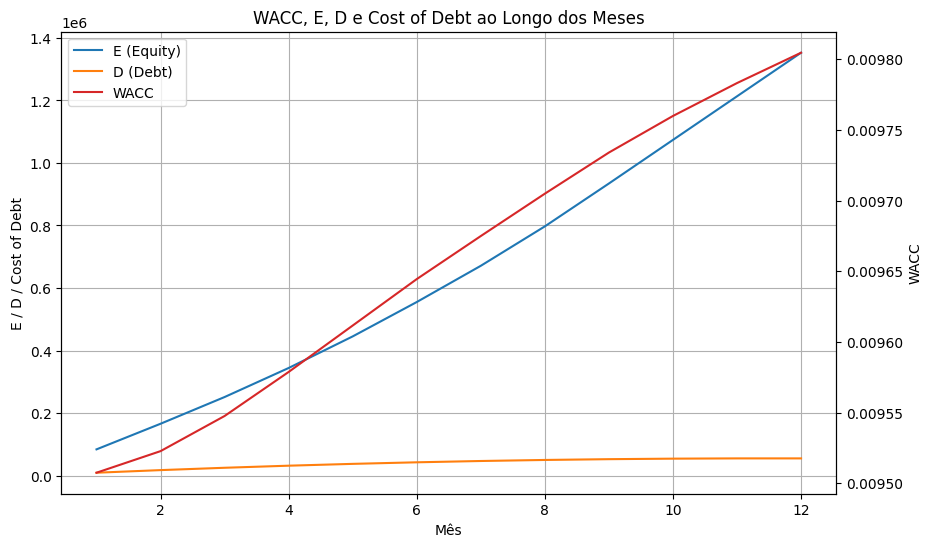

In [8]:
import matplotlib.pyplot as plt
from pyomo.environ import value  # se já não estiver importado

meses = range(1, T+1)

wacc_series       = [value(model.WACC[t])               for t in meses]
equity_series     = [model.E[t].value                  for t in meses]
debt_series       = [model.D[t].value                  for t in meses]

fig, ax1 = plt.subplots(figsize=(10, 6))

# E, D e cost_of_debt no eixo da esquerda
ax1.plot(meses, equity_series,    label='E (Equity)',      color='tab:blue')
ax1.plot(meses, debt_series,      label='D (Debt)',        color='tab:orange')
ax1.set_xlabel('Mês')
ax1.set_ylabel('E / D / Cost of Debt')
ax1.grid(True)

# WACC no eixo da direita
ax2 = ax1.twinx()
ax2.plot(meses, wacc_series, label='WACC', color='tab:red')
ax2.set_ylabel('WACC')

# Legendas combinadas
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='best')

plt.title('WACC, E, D e Cost of Debt ao Longo dos Meses')
plt.show()

In [9]:
equity_series

[83881.98000000001,
 165824.8492681793,
 251289.8700684747,
 344186.2968339098,
 445232.4781844744,
 555152.4464157518,
 671084.8385440649,
 797156.5119097289,
 934322.5605514178,
 1073769.192697694,
 1213207.4914600921,
 1352641.6235052785]

#### Gastos com Marketing

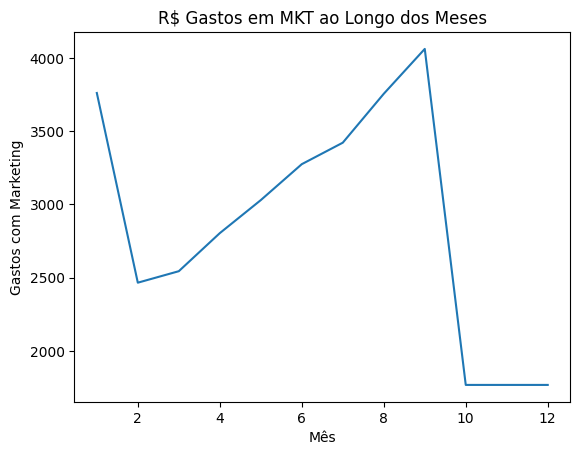

In [10]:


plt.plot(range(1, T+1), [model.M[t].value for t in range(1, T+1)])
plt.xlabel('Mês')
plt.ylabel('Gastos com Marketing')
plt.title('R$ Gastos em MKT ao Longo dos Meses')
plt.show()

#### Número de Fábricas

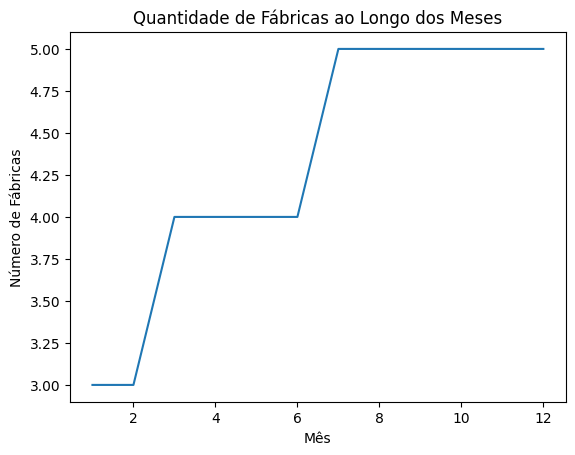

In [11]:
import matplotlib.pyplot as plt

plt.plot(range(1, T+1), [model.num_factories[t].value for t in range(1, T+1)])
plt.xlabel('Mês')
plt.ylabel('Número de Fábricas')
plt.title('Quantidade de Fábricas ao Longo dos Meses')
plt.show()

In [12]:
model.num_factories.display()

num_factories : Size=12, Index={1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12}
    Key : Lower : Value : Upper : Fixed : Stale : Domain
      1 :     0 :     3 :  None :  True :  True : NonNegativeIntegers
      2 :     0 :   3.0 :  None : False : False : NonNegativeIntegers
      3 :     0 :   4.0 :  None : False : False : NonNegativeIntegers
      4 :     0 :   4.0 :  None : False : False : NonNegativeIntegers
      5 :     0 :   4.0 :  None : False : False : NonNegativeIntegers
      6 :     0 :   4.0 :  None : False : False : NonNegativeIntegers
      7 :     0 :   5.0 :  None : False : False : NonNegativeIntegers
      8 :     0 :   5.0 :  None : False : False : NonNegativeIntegers
      9 :     0 :   5.0 :  None : False : False : NonNegativeIntegers
     10 :     0 :   5.0 :  None : False : False : NonNegativeIntegers
     11 :     0 :   5.0 :  None : False : False : NonNegativeIntegers
     12 :     0 :   5.0 :  None : False : False : NonNegativeIntegers


#### Quantidade de Vendas por Período

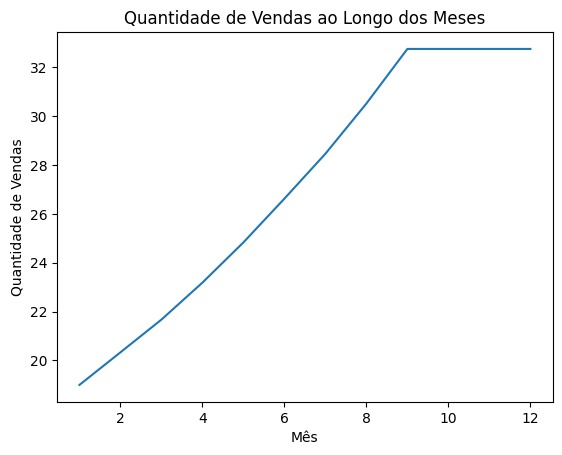

In [13]:
import matplotlib.pyplot as plt

plt.plot(range(1, T+1), [model.Q[t].value for t in range(1, T+1)])
plt.xlabel('Mês')
plt.ylabel('Quantidade de Vendas')
plt.title('Quantidade de Vendas ao Longo dos Meses')
plt.show()

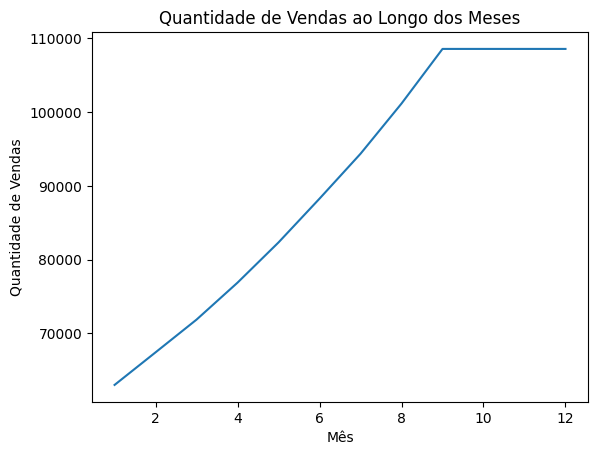

In [14]:
import matplotlib.pyplot as plt

# plt.plot(range(1, 3), [value(AR_rule(model, t)) for t in range(1, 3)], label='AR')

plt.plot(range(1, T+1), [value(AP_rule(model, t)) for t in range(1, T+1)], label='AP')

# plt.plot(range(1, 3), [value(I_rule(model, t)) for t in range(1, 3)], label='I')

plt.xlabel('Mês')
plt.ylabel('Quantidade de Vendas')
plt.title('Quantidade de Vendas ao Longo dos Meses')
plt.show()

# plt.plot(range(1, 3), [value(AP_rule(model, t)) for t in range(1, 3)])
# plt.xlabel('Mês')
# plt.ylabel('Quantidade de Vendas')
# plt.title('Quantidade de Vendas ao Longo dos Meses')
# plt.show()

#### Receita por Período

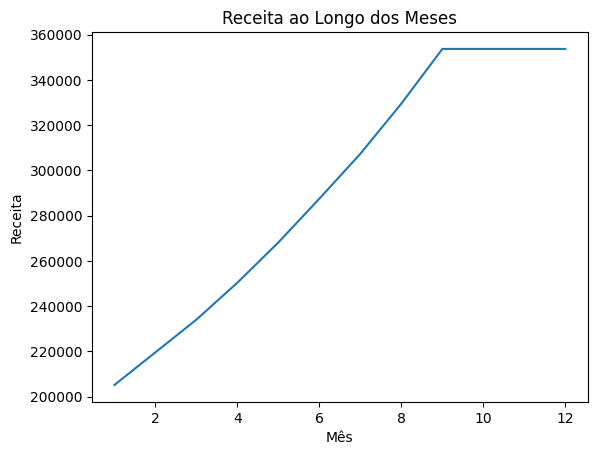

In [15]:
plt.plot(range(1, T+1), [revenue_period(model, t) for t in range(1, T+1)])
plt.xlabel('Mês')
plt.ylabel('Receita')
plt.title('Receita ao Longo dos Meses')
plt.show()

#### Lucro por Período

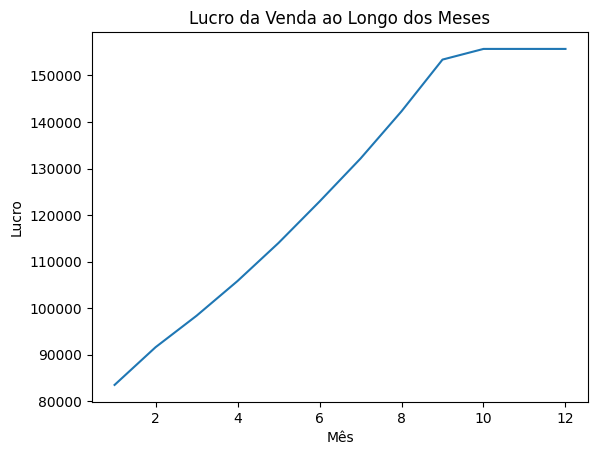

In [16]:
plt.plot(range(1, T+1), [profit_period(model, t) for t in range(1, T+1)])
plt.xlabel('Mês')
plt.ylabel('Lucro')
plt.title('Lucro da Venda ao Longo dos Meses')
plt.show()

#### Fluxo de Caixa Operacional por Período

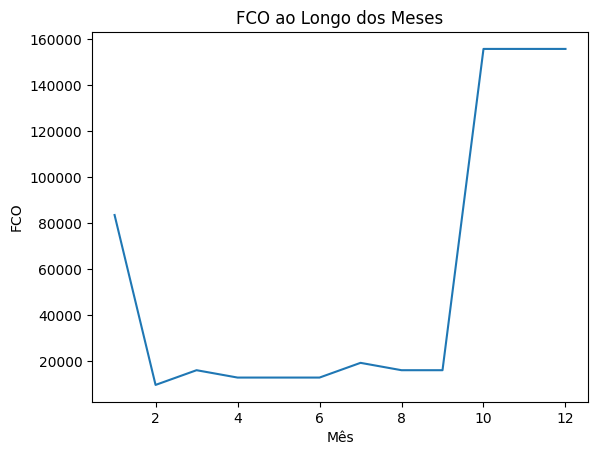

In [17]:
plt.plot(range(1, T+1), [fco_period(model, t) for t in range(1, T+1)])
plt.xlabel('Mês')
plt.ylabel('FCO')
plt.title('FCO ao Longo dos Meses')
plt.show()

## Modelo de Fábrica
O modelo abaixo é o que será utilizado para otimizar o marketing com empréstimo ao longo 
do estudo

In [ ]:
import pyomo as pyo

GENERATE_NEW_SCENARIOS = False

# Solver
solver_name = 'highs'
# solver_name = 'ipopt'

# Número de meses
T=60

S = 50

S_range = range(1, S+1)

# Parâmetros
a = 60  # Constante da demanda
b = 1/2000    # Elasticidade da demanda
variable_cost_percentage = 0.35  # Percentual de custos variáveis - Depois será utilizado no problema de otimização estocástica
variable_cost_increment = 1.01
variable_expenses_percentage = 0.03  # Percentual de custos variáveis
taxes_percentage = 0.07  # Percentual de impostos sobre vendas, neste caso consideramos uma empresa que opera em lucro presumido
CF = 112_500    # Custo fixo mensal (salários, aluguel, etc)
DF = 247_500    # Despesa fixa mensal
theta_AR = 35/30 # 35 dias de recebimento
theta_I = 30/30 # 30 dias de estoque
theta_AP = 30/30 # 30 dias de pagamento


# Relações de incremento Inc = a_inc * Despesas com Mkt + b_inc
# CAC = 6 reais por lata -> Motivo: Está aumentando o valor para adquirir cliente
# Crescimento orgânico: 10% ao ano -> Por limitação vamos
a_inc = 0.25  # Incremento percentual de vendas por R$ despesas com marketing
b_inc = 1000  # Quantidade de vendas alcançadas se não houver despesas com marketing

# Relações de Churn Rate
churn_rate = 0.005  # Taxa de churn rate, ou seja, a porcentagem de clientes que deixam de comprar

# Intervalos de preço e quantidade
P_min = 3 # 3 reais por lata
P_max = 3
Q_min = 250_000 # 250.000 latas
inital_sales = 250_000 # Vendas iniciais
Q_max = 1_000_000

# Variação inicial da NCG (exemplo)
initial_NCG = 875_000 + 262_500 - 262_500 # CR + Estoque Inicial - CP
initial_inventory = 262_500 # 

# Meses usados no cálculo do FCO futuro
months_future_FCO = 12

# Taxa de Incremento do Lucro
profit_increment_rate = 0.8 #0.7
growth_rate = 1.019446 # 1.26 a.a

# Value at risk
alpha_var = 0.05
epsilon_var = 10000  # Valor inicial, será atualizado no loop

# Taxa de Desconto
GAMMA = 0.01

# Parâmetros WACC
initial_equity = 5_000_000
initial_debt = 100_000
initial_cost_of_debt = 0.005
cost_of_equity = 0.01
tax_rate = 0.3

# Produção - Capacidade
production_capacity = 350_000  # Capacidade máxima de produção por fábrica
price_of_factory = 100_000  # Custo de construção de uma nova fábrica
factory_lifetime = 120  # Vida útil de uma fábrica em meses

# Dados de Marketing
M_max = 1e6  
initial_mkt = 10

# Dados de Emprestimo
Borrow_max = 1e6
E_max = 10e10
D_max = 1e7
# Parâmetros do "produto de empréstimo": amortização linear em L meses
L_loan = 12  # exemplo: 12 meses; ajuste como quiser

import matplotlib.pyplot as plt

plt.rcParams['figure.titlesize'] = 16   # Tamanho do título geral da figura
plt.rcParams['axes.titlesize'] = 16     # Tamanho do título dos eixos
plt.rcParams['axes.labelsize'] = 14     # Tamanho dos rótulos (labels) de eixos x e y
plt.rcParams['legend.fontsize'] = 12    # Tamanho da fonte na legenda
plt.rcParams['xtick.labelsize'] = 12    # Tamanho dos rótulos no eixo x
plt.rcParams['ytick.labelsize'] = 12    # Tamanho dos rótulos no eixo y
plt.style.use('default')

In [323]:
import pyomo as pyo

GENERATE_NEW_SCENARIOS = False

# Solver
solver_name = 'highs'
# solver_name = 'ipopt'

# Número de meses
T=60

S = 50

S_range = range(1, S+1)

# Parâmetros
a = 60  # Constante da demanda
b = 1/2000    # Elasticidade da demanda
variable_cost_percentage = 0.35  # Percentual de custos variáveis - Depois será utilizado no problema de otimização estocástica
variable_cost_increment = 1.01
variable_expenses_percentage = 0.03  # Percentual de custos variáveis
taxes_percentage = 0.07  # Percentual de impostos sobre vendas, neste caso consideramos uma empresa que opera em lucro presumido
CF = 112_500    # Custo fixo mensal (salários, aluguel, etc)
DF = 247_500    # Despesa fixa mensal
theta_AR = 35/30 # 35 dias de recebimento
theta_I = 30/30 # 30 dias de estoque
theta_AP = 30/30 # 30 dias de pagamento


# Relações de incremento Inc = a_inc * Despesas com Mkt + b_inc
# CAC = 6 reais por lata -> Motivo: Está aumentando o valor para adquirir cliente
# Crescimento orgânico: 10% ao ano -> Por limitação vamos usar 25_000
a_inc = 1/6  # Incremento percentual de vendas por R$ despesas com marketing
b_inc = 25_000  # Quantidade de vendas alcançadas se não houver despesas com marketing

# Relações de Churn Rate
# Churn de 5% ao mês
churn_rate = 0.05  # Taxa de churn rate, ou seja, a porcentagem de clientes que deixam de comprar

# Intervalos de preço e quantidade
P_min = 3 # 3 reais por lata
P_max = 3
Q_min = 250_000 # 250.000 latas
inital_sales = 250_000 # Vendas iniciais
Q_max = 1_000_000

# Variação inicial da NCG (exemplo)
initial_NCG = 875_000 + 262_500 - 262_500 # CR + Estoque Inicial - CP
initial_inventory = 262_500 # 

# Meses usados no cálculo do FCO futuro
months_future_FCO = 12

# Taxa de Incremento do Lucro
profit_increment_rate = 0.8 #0.7
growth_rate = 1.019446 # 1.26 a.a

# Value at risk
alpha_var = 0.05
epsilon_var = 10000  # Valor inicial, será atualizado no loop

# Taxa de Desconto
GAMMA = 0.01

# Parâmetros WACC
initial_equity = 5_000_000
initial_debt = 100_000
# Custo da Dívida Anualizado = 21%
initial_cost_of_debt = 1.60/100
# Custo do Equity anualizado = 25%
cost_of_equity = 1.88/100
tax_rate = 0.3

# Produção - Capacidade
production_capacity = 350_000  # Capacidade máxima de produção por fábrica
# Custo da Fábrica = 750_000 * 6
price_of_factory = 750_000*6  # Custo de construção de uma nova fábrica
factory_lifetime = 120  # Vida útil de uma fábrica em meses

# Dados de Marketing
M_max = 1_000_000
initial_mkt = 10

# Dados de Emprestimo
# Pode pegar 1_000_000 de empréstimo no mês
Borrow_max = 1_000_000
E_max = 10e10
# Pode ter até 15_000_000 de dívida
D_max = 15_000_000
# Parâmetros do "produto de empréstimo": amortização linear em L meses
L_loan = 12  # exemplo: 12 meses; ajuste como quiser

import matplotlib.pyplot as plt

plt.rcParams['figure.titlesize'] = 16   # Tamanho do título geral da figura
plt.rcParams['axes.titlesize'] = 16     # Tamanho do título dos eixos
plt.rcParams['axes.labelsize'] = 14     # Tamanho dos rótulos (labels) de eixos x e y
plt.rcParams['legend.fontsize'] = 12    # Tamanho da fonte na legenda
plt.rcParams['xtick.labelsize'] = 12    # Tamanho dos rótulos no eixo x
plt.rcParams['ytick.labelsize'] = 12    # Tamanho dos rótulos no eixo y
plt.style.use('default')

In [15]:
from pyomo.environ import *

# Cria um modelo concreto
naive_model = model = ConcreteModel()

# Variáveis de decisão
model.P = Param(initialize=P_min)
model.Q = Var(range(1, T+1), bounds=(Q_min, Q_max), within=NonNegativeReals) # XXX: NonNegativeIntegers
        # exemplo; ajuste ou remova o 'bounds' se não quiser limite
model.M = Var(range(1, T+1), bounds=(0, M_max), within=NonNegativeReals)

# Variável de Churn
model.churn_rate = Param(initialize=churn_rate)

# 1.B  – coeficientes do Increment (fixados em 1, conforme indicado)
model.a_inc = Param(initialize=a_inc)
model.b_inc = Param(initialize=b_inc)

def incr_rule(model, t):
    return model.a_inc * model.M[t] + model.b_inc
model.Increment = Expression(range(1, T+1), rule=incr_rule)

# Variável de Quantidade de fábricas (uma inteira)
model.num_factories = Var(range(1, T+1), within=NonNegativeIntegers)
# fixar o número de fábricas de t=1
model.num_factories[1].fix(3)

# Parâmetros de custos, despesas e impostos

initialize_variable_costs=[variable_cost_percentage*variable_cost_increment**t for t in range(0, T)]

model.variable_cost_percentage = Param(range(1, T+1), initialize=lambda model, t: initialize_variable_costs[t-1], mutable=True)
model.variable_expenses_percentage = Param(initialize=variable_expenses_percentage)
model.taxes_percentage = Param(initialize=taxes_percentage)
model.fix_costs = Param(initialize=CF)
model.fix_expenses = Param(initialize=DF)

# Parâmetros de elasticidade da demanda
model.a = Param(initialize=a)
model.b = Param(initialize=b)

# Parâmetro de quantidade inicial de vendas
model.initial_quantity = Param(initialize=Q_min)
model.Q[1].fix(model.initial_quantity)

# Parâmetro de gastos com Mkt no mês 1
model.initial_mkt = Param(initialize=initial_mkt)
model.M[1].fix(model.initial_mkt)

# Parâmetros de NCG
model.theta_AR = Param(initialize=theta_AR)
model.theta_I = Param(initialize=theta_I)
model.theta_AP = Param(initialize=theta_AP)
model.initial_NCG = Param(initialize=initial_NCG)
model.initial_investment = Param(initialize=initial_inventory)

# WACC: Parâmetros WACC
model.cost_of_equity = Param(initialize=cost_of_equity)
model.tax_rate = Param(initialize=tax_rate)

# Expressões Auxiliares Gerais
def revenue_rule(model, t):
    return model.P * model.Q[t]

# Expressões Auxiliares para o cálculo do número de fábricas
def depreciation_rule(model, t):
    return (price_of_factory / factory_lifetime) * model.num_factories[t]

model.initial_factories = Param(initialize=3, mutable=False)

def difference_on_factories_rule(model, t):
    prev = model.num_factories[t-1] if t > 1 else model.initial_factories
    return model.num_factories[t] - prev  # agora é expressão Pyomo para todo t

model.price_of_factory = Param(initialize=price_of_factory, mutable=False)

def capex_aquisi_rule(model, t):
    return model.price_of_factory * difference_on_factories_rule(model, t)

# Expressões Auxiliares para cálculo da NCG

def AR_rule(model, t):
    # return 0
    return revenue_rule(model, t) * model.theta_AR

def I_rule(model, t):
    # return 0
    return (model.variable_cost_percentage[t] * revenue_rule(model, t)) * model.theta_I

#TODO: Adicionar o I aqui
def AP_rule(model, t):
    i_t_minus_1 = I_rule(model, t-1) if t > 1 else model.initial_investment
    return (I_rule(model, t) + model.variable_cost_percentage[t] * revenue_rule(model, t) -i_t_minus_1) * model.theta_AP

def NCG_rule(model, t):
    # return AR_rule(model, t) + I_rule(model, t) - AP_rule(model, t) - (AR_rule(model, t-1) + I_rule(model, t-1) - AP_rule(model, t-1) if t > 1 else model.initial_NCG)
    if t > 1:
        return AR_rule(model, t) + I_rule(model, t) - AP_rule(model, t) - (AR_rule(model, t-1) + I_rule(model, t-1) - AP_rule(model, t-1) if t > 1 else model.initial_NCG)
    else:
        # return AR_rule(model, t) + I_rule(model, t) - AP_rule(model, t) - AR_rule(model, t) + I_rule(model, t) - AP_rule(model, t) 
        return AR_rule(model, t) + I_rule(model, t) - AP_rule(model, t) - model.initial_NCG

def fcf_period_expression(model, t_period):
    receita = revenue_rule(model, t_period)
    depreciation = depreciation_rule(model, t_period)
    capex_aquisi = capex_aquisi_rule(model, t_period)
    return (receita
            - model.variable_cost_percentage[t_period] * receita
            - model.variable_expenses_percentage * receita
            - model.M[t_period]
            - model.taxes_percentage * receita
            - model.fix_costs
            - model.fix_expenses
            - depreciation
            - capex_aquisi
            - NCG_rule(model, t_period))

# ABAIXO SÃO OS NOVOS

# ----------------------------
# BLOCO: Capital (E, D) e WACC
# ----------------------------

# Fixar custo da dívida (exógeno)
model.cost_of_debt = Param(range(1, T+1), initialize=lambda m,t: initial_cost_of_debt)

# Estoques de capital (E e D)
model.E = Var(range(1, T+1), bounds=(0, E_max), within=NonNegativeReals, initialize=lambda m,t: initial_equity)
model.D = Var(range(1, T+1), bounds=(0, D_max), within=NonNegativeReals, initialize=lambda m,t: initial_debt)

# Fluxos de financiamento
model.Borrow = Var(range(1, T+1), bounds=(0, Borrow_max), within=NonNegativeReals, initialize=lambda m,t: 0)

# Amortização total do mês (inclui amortização de dívidas antigas + das novas tomadas)
model.Repay = Var(range(1, T+1), bounds=(0, 10e9), within=NonNegativeReals, initialize=lambda m,t: 0)

# Amortização do estoque inicial (assumindo que ele será pago linearmente em L_loan meses a partir do mês 1)
def init_amort_rule(m, t):
    return initial_debt / L_loan if t <= L_loan else 0.0
model.init_amort = Param(range(1, T+1), initialize=init_amort_rule, mutable=False)

# Amortização das novas tomadas: cada Borrow[k] paga 1/L_loan por mês durante L_loan meses
def repay_schedule_rule(m, t):
    # soma das parcelas (Borrow[t], Borrow[t-1], ..., Borrow[t-L_loan+1]) / L_loan
    s = 0
    kmin = max(1, t - L_loan + 1)
    for k in range(kmin, t+1):
        s += m.Borrow[k]
    return m.Repay[t] == m.init_amort[t] + (1.0 / L_loan) * s

model.repay_schedule = Constraint(range(1, T+1), rule=repay_schedule_rule)

# Dinâmica da dívida (estoque)
def debt_dyn_rule(m, t):
    if t == 1:
        return m.D[1] == initial_debt + m.Borrow[1] - m.Repay[1]
    return m.D[t] == m.D[t-1] + m.Borrow[t] - m.Repay[t]
model.debt_dyn = Constraint(range(1, T+1), rule=debt_dyn_rule)

# Juros (sobre D do mês anterior; no t=1 usa initial_debt)
def interest_rule(m, t):
    D_prev = initial_debt if t == 1 else m.D[t-1]
    return m.cost_of_debt[t] * D_prev
model.Interest = Expression(range(1, T+1), rule=interest_rule)

def ebit_rule(m, t):
    receita = revenue_rule(m, t)
    dep = depreciation_rule(m, t)
    return (receita
            - m.variable_cost_percentage[t] * receita
            - m.variable_expenses_percentage * receita
            - m.M[t]
            - m.taxes_percentage * receita
            - m.fix_costs
            - m.fix_expenses
            - dep)
model.EBIT = Expression(range(1, T+1), rule=ebit_rule)

def ni_rule(m, t):
    return m.EBIT[t] - m.Interest[t]
model.NI = Expression(range(1, T+1), rule=ni_rule)


# Evitar divisão por zero nos pesos do WACC, além de evitar que o estoque de capital seja negativo (o que não faz sentido)
eps = 1
model.capital_positive = Constraint(range(1, T+1), rule=lambda m,t: m.E[t] + m.D[t] >= eps)

# Pesos
def equity_ratio_rule(m, t):
    return m.E[t] / (m.E[t] + m.D[t])
def debt_ratio_rule(m, t):
    return m.D[t] / (m.E[t] + m.D[t])

model.equity_ratio = Expression(range(1, T+1), rule=equity_ratio_rule)
model.debt_ratio   = Expression(range(1, T+1), rule=debt_ratio_rule)

def equity_dyn_rule(m, t):
    if t == 1:
        return m.E[1] == initial_equity + m.NI[1]
    return m.E[t] == m.E[t-1] + m.NI[t]
model.equity_dyn = Constraint(range(1, T+1), rule=equity_dyn_rule)


# WACC dinâmico
def wacc_rule(m, t):
    return (m.equity_ratio[t] * m.cost_of_equity +
            m.debt_ratio[t] * m.cost_of_debt[t])
model.WACC = Expression(range(1, T+1), rule=wacc_rule)

WACC_MIN = 0.00001
WACC_MAX = 0.99999          # ajuste
CAPITAL_MIN = 0     # ajuste (ver nota abaixo)

model.WACC = Var(range(1, T+1), bounds=(WACC_MIN, WACC_MAX), initialize=0.10)

model.capital_positive = Constraint(
    range(1, T+1),
    rule=lambda m,t: m.E[t] + m.D[t] >= CAPITAL_MIN
)

def wacc_def_rule(m, t):
    return (m.E[t] + m.D[t]) * m.WACC[t] == m.E[t] * m.cost_of_equity + m.D[t] * m.cost_of_debt[t]

model.wacc_def = Constraint(range(1, T+1), rule=wacc_def_rule)

# Crie uma restrição para garantir que o WACC seja positivo
model.wacc_positive = Constraint(range(1, T+1), rule=lambda m,t: m.WACC[t] >= 0.001)

## FIM DO NOVO ##

def objective_rule(model):
    t_final = T

    return sum(
        fcf_period_expression(model, t_period) / ((1 + model.WACC[t_period]) ** t_period)
        for t_period in range(t_final - months_future_FCO + 1, t_final + 1)
    )

model.objective = Objective(rule=objective_rule, sense=maximize)

# Restrição de demanda
def demand_rule(model, t):
    return model.P[t] == model.a - model.b * model.Q[t]

# model.demand = Constraint(range(1, T+1), rule=demand_rule)

def fco_rule(model, t):
    receita = revenue_rule(model, t)
    depreciation = depreciation_rule(model, t)
    capex_aquisi = capex_aquisi_rule(model, t)
    return (receita
            - model.variable_cost_percentage[t] * receita
            - model.variable_expenses_percentage * receita
            - model.M[t]                               # << NOVO
            - model.taxes_percentage * receita
            - model.fix_costs
            - model.fix_expenses
            - depreciation
            - capex_aquisi
            - NCG_rule(model, t)) >= 0


model.fco = Constraint(range(1, T+1), rule=fco_rule)

# Restrição de quantidade poder crescer unicamente 10% em cada mês
def growth_rule(model, t):
    return model.Q[t] <= model.Q[t-1] * growth_rate if t > 1 else model.Q[t] <= model.initial_quantity

model.growth = Constraint(range(1, T+1), rule=growth_rule)

# Restrição de o lucro ser maior ou igual ao mês anterior
def profit_rule(model, t):
    if t <= 2:
        return Constraint.Skip          # ou qualquer relaxamento que já usava

    receita_t   = revenue_rule(model, t)
    receita_tm1 = revenue_rule(model, t-1)

    lucro_t = (receita_t
               - model.variable_cost_percentage[t]   * receita_t
               - model.variable_expenses_percentage  * receita_t
               - model.M[t]                          # << NOVO
               - model.taxes_percentage              * receita_t
               - model.fix_costs
               - model.fix_expenses)

    lucro_tm1 = (receita_tm1
                 - model.variable_cost_percentage[t-1] * receita_tm1
                 - model.variable_expenses_percentage  * receita_tm1
                 - model.M[t-1]                        # << NOVO
                 - model.taxes_percentage              * receita_tm1
                 - model.fix_costs
                 - model.fix_expenses)

    return lucro_t >= lucro_tm1 * profit_increment_rate


model.profit = Constraint(range(1, T+1), rule=profit_rule)

def non_regression_rule(model, t):
    return model.Q[t] >= model.Q[t-1]*1 if t > 1 else model.Q[t] >= model.initial_quantity

model.non_regression = Constraint(range(1, T+1), rule=non_regression_rule)

def qty_increment_rule(model, t):
    if t == 1:
        return Constraint.Skip          # já fixamos Q[1] no valor inicial
    return model.Q[t] == (1 - model.churn_rate) * model.Q[t-1] + model.Increment[t]

model.qty_increment = Constraint(range(1, T+1), rule=qty_increment_rule)

# Restrições dos Capex

# Aquisição de novas fábricas deve ser 0 ou positiva
def capex_aquisi_constraint_rule(model, t):
    return capex_aquisi_rule(model, t) >= 0

model.capex_aquisi_constraint = Constraint(range(1, T+1), rule=capex_aquisi_constraint_rule)

# quantidade de fábricas deve ser >= qt * capacidade de produção
def production_capacity_rule(model, t):
    return model.Q[t] <= model.num_factories[t] * production_capacity

model.production_capacity_constraint = Constraint(range(1, T+1), rule=production_capacity_rule)

# Componentes da NCG
model.AR = Expression(range(1, T+1), rule=AR_rule)
model.I = Expression(range(1, T+1), rule=I_rule)
model.AP = Expression(range(1, T+1), rule=AP_rule)
model.NCG = Expression(range(1, T+1), rule=NCG_rule)

# Resolver o modelo
solver = SolverFactory("highs")

# solver.options['max_iter'] = 1000
# solver.options['tol'] = 1e-6
# solver.options['NonConvex'] = 2
# result = solver.solve(
#     model, 
#     tee=True,
# )

solver = SolverFactory("mindtpy")
result = solver.solve(
    model, 
    strategy="OA",          # alternativas: "ECP", "GBD"
    init_strategy="rNLP",   # começa resolvendo a relaxação contínua
    mip_solver="appsi_highs",       # ou "gurobi"/"cplex"
    nlp_solver="ipopt",
    tee=True,
)


# Exibir os resultados
for t in range(1, T+1):
    print(f'Mês {t}: Preço = {model.P.value}, Quantidade = {model.Q[t].value}, MKT = {model.M[t].value}')
    
    # print(f'Mês {t}: Preço = {model.P[t].value}, Quantidade = {model.Q[t].value}, AR = {model.AR[t].value}, Estoque = {model.I[t].value}, AP = {model.AP[t].value}')

'pyomo.core.base.expression.IndexedExpression'>) on block unknown with a new
Component (type=<class 'pyomo.core.base.var.IndexedVar'>). This is usually
indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().
(type=<class 'pyomo.core.base.constraint.IndexedConstraint'>) on block unknown
with a new Component (type=<class
'pyomo.core.base.constraint.IndexedConstraint'>). This is usually indicative
of a modelling error. To avoid this warning, use block.del_component() and
block.add_component().


Starting MindtPy version 1.0.0 using OA algorithm
iteration_limit: 50
stalling_limit: 15
time_limit: 600
strategy: OA
add_regularization: None
call_after_main_solve: <pyomo.contrib.gdpopt.util._DoNothing object at 0x12eaf02b0>
call_before_subproblem_solve: <pyomo.contrib.gdpopt.util._DoNothing object at 0x12ea6ab10>
call_after_subproblem_solve: <pyomo.contrib.gdpopt.util._DoNothing object at 0x12ead49e0>
call_after_subproblem_feasible: <pyomo.contrib.gdpopt.util._DoNothing object at 0x12ead4af0>
tee: true
logger: <Logger pyomo.contrib.mindtpy (INFO)>
logging_level: 20
integer_to_binary: false
add_no_good_cuts: false
use_tabu_list: false
single_tree: false
solution_pool: false
num_solution_iteration: 5
cycling_check: true
feasibility_norm: L_infinity
differentiate_mode: reverse_symbolic
use_mcpp: false
calculate_dual_at_solution: false
use_fbbt: false
use_dual_bound: true
partition_obj_nonlinear_terms: true
quadratic_strategy: 0
move_objective: false
add_cuts_at_incumbent: false
heurist

Mês 1: Preço = 3, Quantidade = 250000, MKT = 10
Mês 2: Preço = 3, Quantidade = 254861.50000000998, MKT = 20446.000000039974
Mês 3: Preço = 3, Quantidade = 259817.53672902015, MKT = 20921.376916040907
Mês 4: Preço = 3, Quantidade = 264869.9485482627, MKT = 21405.998011550528
Mês 5: Preço = 3, Quantidade = 270020.6095677422, MKT = 21900.043048883344
Mês 6: Preço = 3, Quantidade = 275271.4303414065, MKT = 22403.695286012055
Mês 7: Preço = 3, Quantidade = 280624.3585758355, MKT = 22917.14154454418
Mês 8: Preço = 3, Quantidade = 286081.3798527111, MKT = 23440.572279019332
Mês 9: Preço = 3, Quantidade = 291644.5183653369, MKT = 23974.181647557354
Mês 10: Preço = 3, Quantidade = 297315.83766947925, MKT = 24518.16758387611
Mês 11: Preço = 3, Quantidade = 303097.4414488099, MKT = 25072.73187071231
Mês 12: Preço = 3, Quantidade = 308991.47429523343, MKT = 25638.080214670234
Mês 13: Preço = 3, Quantidade = 315000.1225043885, MKT = 26214.42232252503
Mês 14: Preço = 3, Quantidade = 321125.614886618

In [20]:
for t in range(1, T+1):
    print(
        f"Mês {t}: Q={model.Q[t].value:.2f} | "
        f"E={model.E[t].value:.2f} | D={model.D[t].value:.2f} | "
        f"WACC={value(model.WACC[t]):.4f} | "
        f"Borrow={model.Borrow[t].value:.2f} | Repay={model.Repay[t].value:.2f} | "
        f"NI={value(model.NI[t]):.2f}"
    )


Mês 1: Q=250000.00 | E=59990.00 | D=5255569.98 | WACC=0.0099 | Borrow=5733349.07 | Repay=477779.09 | NI=49990.00
Mês 2: Q=254861.50 | E=42333.73 | D=4948684.83 | WACC=0.0100 | Borrow=186429.75 | Repay=493314.90 | NI=-17656.27
Mês 3: Q=259817.54 | E=32640.99 | D=4546702.66 | WACC=0.0100 | Borrow=99635.71 | Repay=501617.88 | NI=-9692.74
Mês 4: Q=264869.95 | E=31876.27 | D=4104175.50 | WACC=0.0100 | Borrow=64462.60 | Repay=506989.76 | NI=-764.73
Mês 5: Q=270020.61 | E=40456.36 | D=3658386.04 | WACC=0.0099 | Borrow=66763.97 | Repay=512553.42 | NI=8580.09
Mês 6: Q=275271.43 | E=58422.97 | D=3206894.66 | WACC=0.0099 | Borrow=66613.14 | Repay=518104.52 | NI=17966.61
Mês 7: Q=280624.36 | E=85839.82 | D=2748392.69 | WACC=0.0098 | Borrow=65020.96 | Repay=523522.93 | NI=27416.85
Mês 8: Q=286081.38 | E=122781.19 | D=2281664.87 | WACC=0.0097 | Borrow=61958.31 | Repay=528686.13 | NI=36941.37
Mês 9: Q=291644.52 | E=169330.87 | D=1808313.03 | WACC=0.0096 | Borrow=60364.67 | Repay=533716.51 | NI=46549.

### Criação de Funções auxiliares para calcular Receita, Lucro e FCO

In [21]:
from pyomo.environ import value


def fco_period(model, t):
    return value(model.P * model.Q[t] - model.variable_cost_percentage[t] * model.P * model.Q[t] - model.variable_expenses_percentage * model.P * model.Q[t] - model.M[t] - model.taxes_percentage * model.P * model.Q[t] - model.fix_costs - model.fix_expenses - model.NCG[t])

def revenue_period(model, t):
    return value(model.P * model.Q[t])

def profit_period(model, t):
    return value(model.P * model.Q[t] - model.variable_cost_percentage[t] * model.P * model.Q[t] - model.variable_expenses_percentage * model.P * model.Q[t] - model.M[t] - model.taxes_percentage * model.P * model.Q[t] - model.fix_costs - model.fix_expenses)

In [22]:
# Verificar se o modelo foi solucionado com sucesso
if result.solver.termination_condition == TerminationCondition.optimal:
    for t in range(1, T+1):
        # Calcula e exibe as componentes diretamente sem usar as expressões model.AR, model.I, model.AP, model.NCG
        AR_value = AR_rule(model, t)()
        I_value = I_rule(model, t)()
        AP_value = AP_rule(model, t)()
        NCG_value = NCG_rule(model, t)()
        revenue_value = revenue_rule(model, t)()

        print(f'Mês {t}: Preço = {model.P.value}, Quantidade = {model.Q[t].value}')
        print(f'  AR = {AR_value}, Estoque (I) = {I_value}, AP = {AP_value}, NCG = {NCG_value}')
        print(f'  NCG = AR - I - AP = {AR_value} - {I_value} - {AP_value} = {NCG_value}')
        # agora o lucro
        # print(f'  Lucro = {revenue_value - model.variable_cost_percentage * revenue_value - model.variable_expenses_percentage * revenue_value - model.taxes_percentage * revenue_value - model.fix_costs - model.fix_expenses}')
else:
    print("O modelo não encontrou uma solução ótima.")

Mês 1: Preço = 3, Quantidade = 250000
  AR = 875000.0, Estoque (I) = 262499.99999999994, AP = 262499.9999999999, NCG = 1.1641532182693481e-10
  NCG = AR - I - AP = 875000.0 - 262499.99999999994 - 262499.9999999999 = 1.1641532182693481e-10
Mês 2: Preço = 3, Quantidade = 254861.50000000998
  AR = 892015.2500000349, Estoque (I) = 270280.6207500106, AP = 278061.24150002125, NCG = 9234.629250024038
  NCG = AR - I - AP = 892015.2500000349 - 270280.6207500106 - 278061.24150002125 = 9234.629250024038
Mês 3: Preço = 3, Quantidade = 259817.53672902015
  AR = 909361.3785515706, Estoque (I) = 278291.86267813714, AP = 286303.1046062637, NCG = 17115.50737341994
  NCG = AR - I - AP = 909361.3785515706 - 278291.86267813714 - 286303.1046062637 = 17115.50737341994
Mês 4: Preço = 3, Quantidade = 264869.9485482627
  AR = 927044.8199189195, Estoque (I) = 286540.5615021848, AP = 294789.2603262324, NCG = 17445.984471427742
  NCG = AR - I - AP = 927044.8199189195 - 286540.5615021848 - 294789.2603262324 = 1744

### Gráficos de Comportamento da Solução

#### Valores do WACC

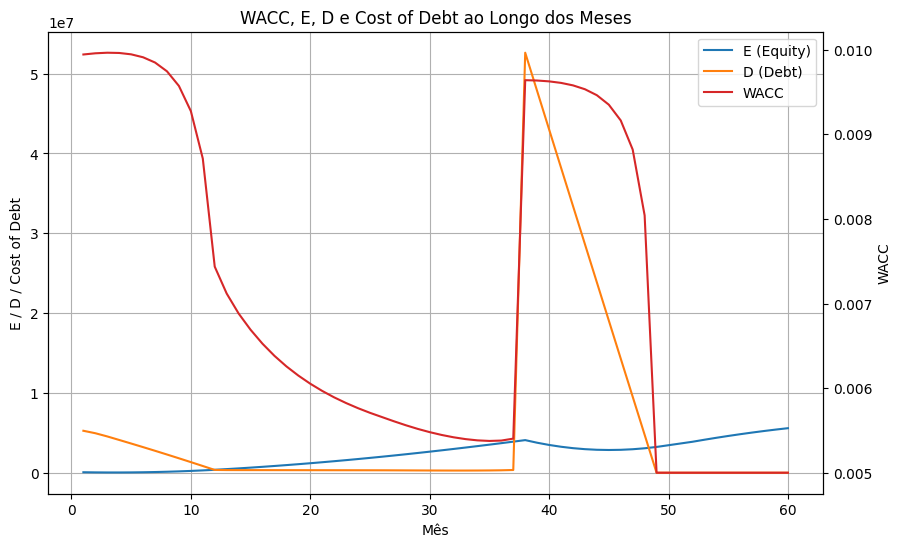

In [23]:
import matplotlib.pyplot as plt
from pyomo.environ import value  # se já não estiver importado

meses = range(1, T+1)

wacc_series       = [value(model.WACC[t])               for t in meses]
equity_series     = [model.E[t].value                  for t in meses]
debt_series       = [model.D[t].value                  for t in meses]

fig, ax1 = plt.subplots(figsize=(10, 6))

# E, D e cost_of_debt no eixo da esquerda
ax1.plot(meses, equity_series,    label='E (Equity)',      color='tab:blue')
ax1.plot(meses, debt_series,      label='D (Debt)',        color='tab:orange')
ax1.set_xlabel('Mês')
ax1.set_ylabel('E / D / Cost of Debt')
ax1.grid(True)

# WACC no eixo da direita
ax2 = ax1.twinx()
ax2.plot(meses, wacc_series, label='WACC', color='tab:red')
ax2.set_ylabel('WACC')

# Legendas combinadas
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='best')

plt.title('WACC, E, D e Cost of Debt ao Longo dos Meses')
plt.show()

#### Gastos com Marketing

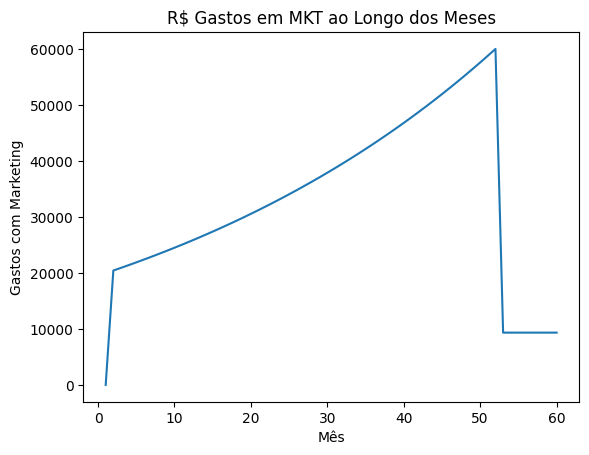

In [24]:


plt.plot(range(1, T+1), [model.M[t].value for t in range(1, T+1)])
plt.xlabel('Mês')
plt.ylabel('Gastos com Marketing')
plt.title('R$ Gastos em MKT ao Longo dos Meses')
plt.show()

#### Número de Fábricas

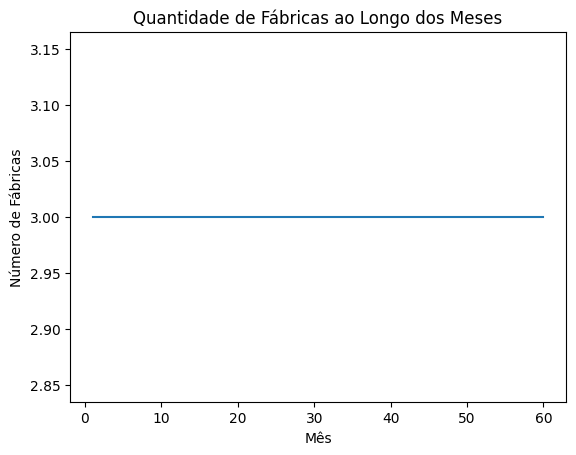

In [25]:
import matplotlib.pyplot as plt

plt.plot(range(1, T+1), [model.num_factories[t].value for t in range(1, T+1)])
plt.xlabel('Mês')
plt.ylabel('Número de Fábricas')
plt.title('Quantidade de Fábricas ao Longo dos Meses')
plt.show()

In [26]:
model.num_factories.display()

num_factories : Size=60, Index={1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60}
    Key : Lower : Value : Upper : Fixed : Stale : Domain
      1 :     0 :     3 :  None :  True :  True : NonNegativeIntegers
      2 :     0 :   3.0 :  None : False : False : NonNegativeIntegers
      3 :     0 :   3.0 :  None : False : False : NonNegativeIntegers
      4 :     0 :   3.0 :  None : False : False : NonNegativeIntegers
      5 :     0 :   3.0 :  None : False : False : NonNegativeIntegers
      6 :     0 :   3.0 :  None : False : False : NonNegativeIntegers
      7 :     0 :   3.0 :  None : False : False : NonNegativeIntegers
      8 :     0 :   3.0 :  None : False : False : NonNegativeIntegers
      9 :     0 :   3.0 :  None : False : False : NonNegativeIntegers
     10 :     0 :   3.0 :  None : False : False : 

#### Quantidade de Vendas por Período

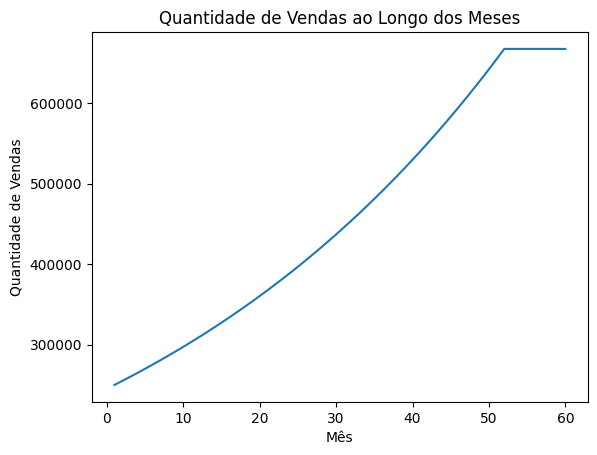

In [27]:
import matplotlib.pyplot as plt

plt.plot(range(1, T+1), [model.Q[t].value for t in range(1, T+1)])
plt.xlabel('Mês')
plt.ylabel('Quantidade de Vendas')
plt.title('Quantidade de Vendas ao Longo dos Meses')
plt.show()

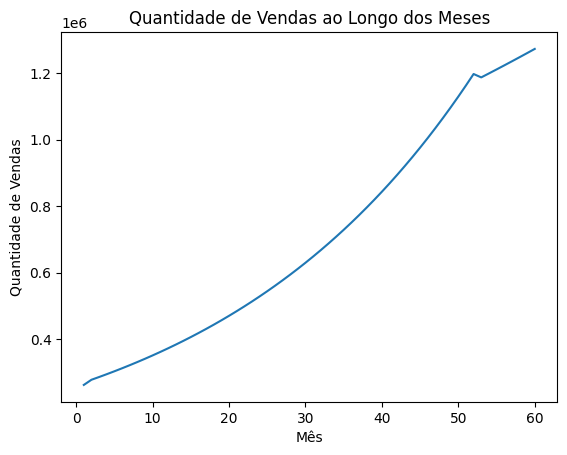

In [28]:
import matplotlib.pyplot as plt

# plt.plot(range(1, 3), [value(AR_rule(model, t)) for t in range(1, 3)], label='AR')

plt.plot(range(1, T+1), [value(AP_rule(model, t)) for t in range(1, T+1)], label='AP')

# plt.plot(range(1, 3), [value(I_rule(model, t)) for t in range(1, 3)], label='I')

plt.xlabel('Mês')
plt.ylabel('Quantidade de Vendas')
plt.title('Quantidade de Vendas ao Longo dos Meses')
plt.show()

# plt.plot(range(1, 3), [value(AP_rule(model, t)) for t in range(1, 3)])
# plt.xlabel('Mês')
# plt.ylabel('Quantidade de Vendas')
# plt.title('Quantidade de Vendas ao Longo dos Meses')
# plt.show()

#### Receita por Período

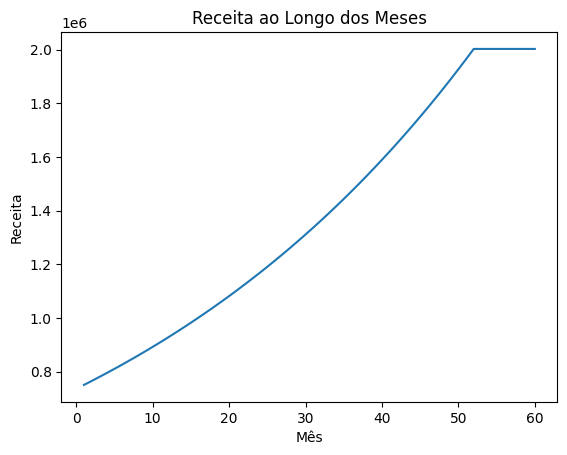

In [29]:
plt.plot(range(1, T+1), [revenue_period(model, t) for t in range(1, T+1)])
plt.xlabel('Mês')
plt.ylabel('Receita')
plt.title('Receita ao Longo dos Meses')
plt.show()

#### Lucro por Período

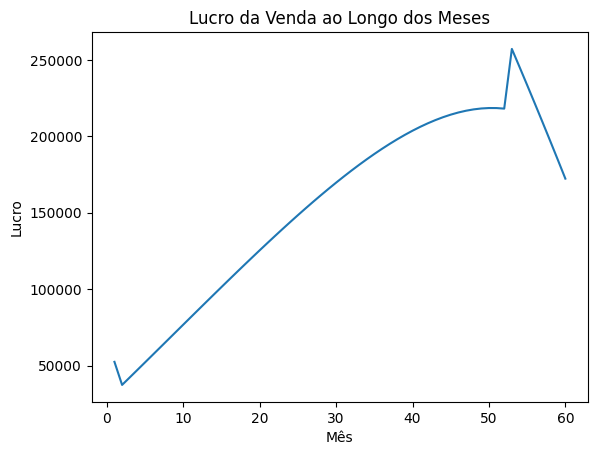

In [30]:
plt.plot(range(1, T+1), [profit_period(model, t) for t in range(1, T+1)])
plt.xlabel('Mês')
plt.ylabel('Lucro')
plt.title('Lucro da Venda ao Longo dos Meses')
plt.show()

#### Fluxo de Caixa Operacional por Período

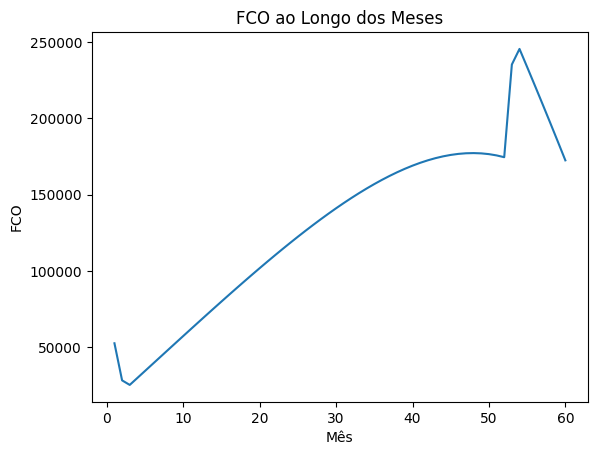

In [31]:
plt.plot(range(1, T+1), [fco_period(model, t) for t in range(1, T+1)])
plt.xlabel('Mês')
plt.ylabel('FCO')
plt.title('FCO ao Longo dos Meses')
plt.show()

# Descobrindo possíveis variações no valor de custos variáveis com base na variação do dólar

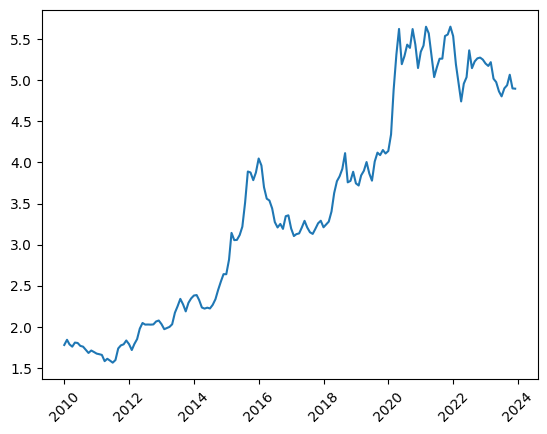

In [17]:
from currency_converter import CurrencyConverter
from datetime import datetime
from numpy import mean
import calendar
import matplotlib.pyplot as plt

c = CurrencyConverter(fallback_on_missing_rate=True)

# Pega a média do dólar mensal desde 2010
dolar_mean = []
for i in range(2010, 2024):
    for j in range(1, 13):
        _, num_days = calendar.monthrange(i, j)
        dolar_mean.append(mean([c.convert(1, 'USD', 'BRL', date=datetime(i, j, k)) for k in range(1, num_days+1)]))

# Plota o gráfico utilizando datas no eixo x
plt.plot([datetime(i, j, 1) for i in range(2010, 2024) for j in range(1, 13)], dolar_mean)
plt.xticks(rotation=45)
plt.show()


/var/folders/6n/ffgn982n58v3d24kq1527mc80000gn/T/ipykernel_52170/32599165.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


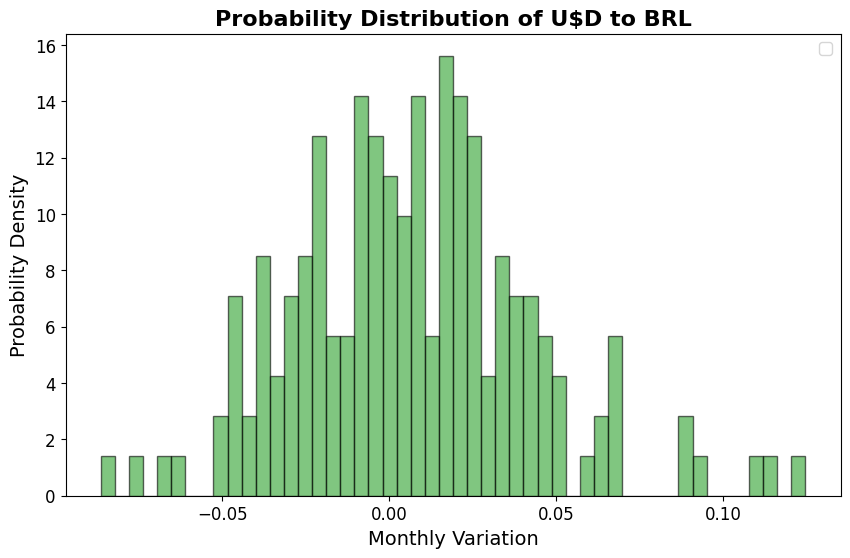

In [18]:
import numpy as np
from scipy.stats import norm

# variação
dolar_mean_variation = np.diff(dolar_mean)
dolar_mean_variation = [(dolar_mean[i] + dolar_mean_variation[i]) / dolar_mean[i] - 1 
                        for i in range(len(dolar_mean_variation))]

# estatísticas
mu, sigma = np.mean(dolar_mean_variation), np.std(dolar_mean_variation)

# plot
plt.figure(figsize=(10,6))

# histograma
count, bins, ignored = plt.hist(dolar_mean_variation, bins=50, density=True, 
                                alpha=0.6, color="#2ca02c", edgecolor="black")

# labels
plt.xlabel('Monthly Variation', fontsize=14)
plt.ylabel('Probability Density', fontsize=14)
plt.title('Probability Distribution of U$D to BRL', fontsize=16, fontweight="bold")
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.savefig('./figures/dollar_variation_distribution.png', dpi=300)
plt.show()


## Estudo sobre propriedades da série

média : 0.6058857773624027 
desvio: 3.5294177434928997 
skew  : 0.2933667314612711 
kurtose: 0.5651612766336411
ARCH LM-stat = 17.15,  p-valor = 0.0042


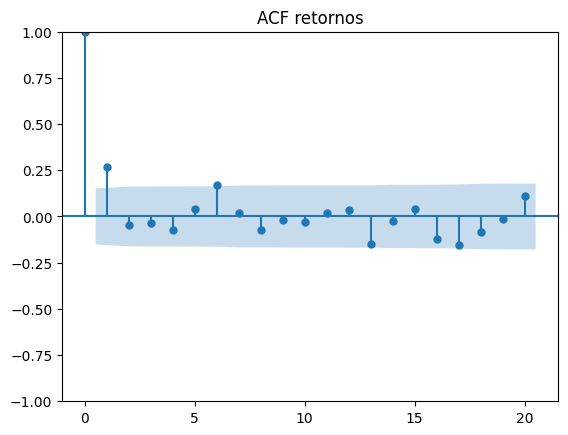

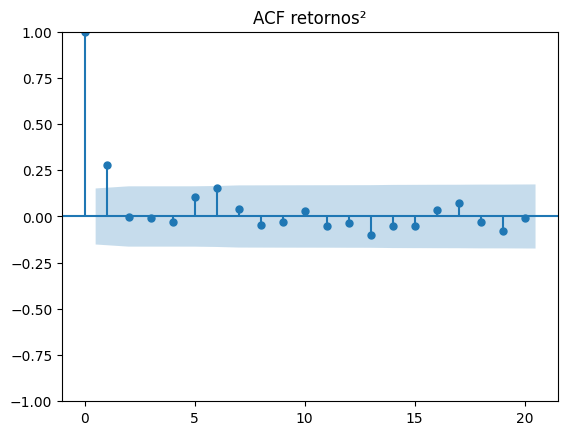

In [34]:
import numpy as np, pandas as pd
from scipy.stats import skew, kurtosis
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import het_arch

fx = pd.Series(dolar_mean, dtype=float)      # nível USD/BRL
ret = 100 * np.log(fx).diff().dropna()       # log-retorno em %

print("média :", ret.mean(),
      "\ndesvio:", ret.std(),
      "\nskew  :", skew(ret),
      "\nkurtose:", kurtosis(ret))

plot_acf(ret,     lags=20, title='ACF retornos')
plot_acf(ret**2,  lags=20, title='ACF retornos²')

lm_stat, lm_pvalue, *_ = het_arch(ret, nlags=5)   # use nlags, não maxlag
print(f"ARCH LM-stat = {lm_stat:.2f},  p-valor = {lm_pvalue:.4f}")


In [35]:
from arch import arch_model
garch = arch_model(ret, mean='Constant', vol='GARCH',
                   p=1, q=1, dist='StudentsT')
res = garch.fit(disp='off')


## Geração de cenários

### Gerando cenários com o modelo Garch

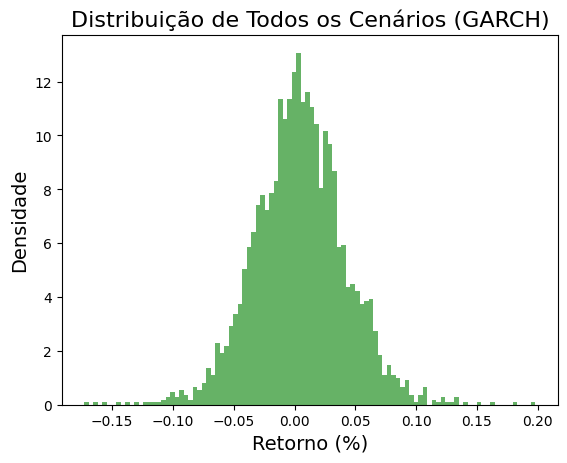

In [36]:
from arch import arch_model
import numpy as np, pandas as pd, pickle, matplotlib.pyplot as plt

# ───────────────────────────────────────────────────────────────
# 1)  retorna mensal (%)
# ───────────────────────────────────────────────────────────────
fx   = pd.Series(dolar_mean, dtype=float)
ret  = 100 * np.log(fx).diff().dropna()

# ───────────────────────────────────────────────────────────────
# 2)  ajusta GARCH(1,1) com inovações t
# ───────────────────────────────────────────────────────────────
garch = arch_model(ret, mean='Constant',
                   vol='GARCH', p=1, q=1,
                   dist='StudentsT')
res = garch.fit(disp='off')

# ───────────────────────────────────────────────────────────────
# 3)  simula S trajetórias de (T-1) meses com burn-in
# ───────────────────────────────────────────────────────────────
T, scenarios = 60, S
# paths = np.vstack([
#     garch.simulate(res.params, nobs=T-1)['data'].values
#     for _ in range(scenarios)
# ])                       # shape = (500 , 59)

# #  ── mantém o mesmo formato usado no seu pickle
# scenarios_data_arch = (paths / 100).reshape(-1, 1)
# pickle.dump(scenarios_data_arch, open('all_data_arch.pkl', 'wb'))

steps = T - 1
burn = 500  # aquecimento padrão do arch (bom ponto de partida)

np.random.seed(42)
paths = np.vstack([
    garch.simulate(
        res.params,
        nobs=steps,
        burn=burn
        # NÃO use initial_value com mean='Constant'
    )["data"].to_numpy()
    for _ in range(scenarios)
])

scenarios_data_arch = (paths / 100.0).reshape(-1, 1)
pickle.dump(scenarios_data_arch, open("all_data_arch.pkl", "wb"))



# ───────────────────────────────────────────────────────────────
# 4)  visualização (opcional)
# ───────────────────────────────────────────────────────────────
plt.hist(scenarios_data_arch, bins=100, density=True, alpha=0.6, color='g')
plt.title('Distribuição de Todos os Cenários (GARCH)', fontsize=16)
plt.xlabel('Retorno (%)', fontsize=14)
plt.ylabel('Densidade', fontsize=14)

plt.savefig('./figures/dollar_variation_distribution_garch.png', dpi=300)
plt.show()


### Gerando cenários com o modelo Markoviano

/Users/henriquealvesbarbosa/opt/anaconda3/envs/valuation-optimization/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:                      y   No. Observations:                  167
Model:               MarkovRegression   Log Likelihood                -436.686
Date:                Mon, 29 Dec 2025   AIC                            897.373
Time:                        11:49:58   BIC                            934.789
Sample:                             0   HQIC                           912.559
                                - 167                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0060      0.505     -0.012      0.991      -0.996       0.984
sigma2        13.5144      2.883      4.687      0.0

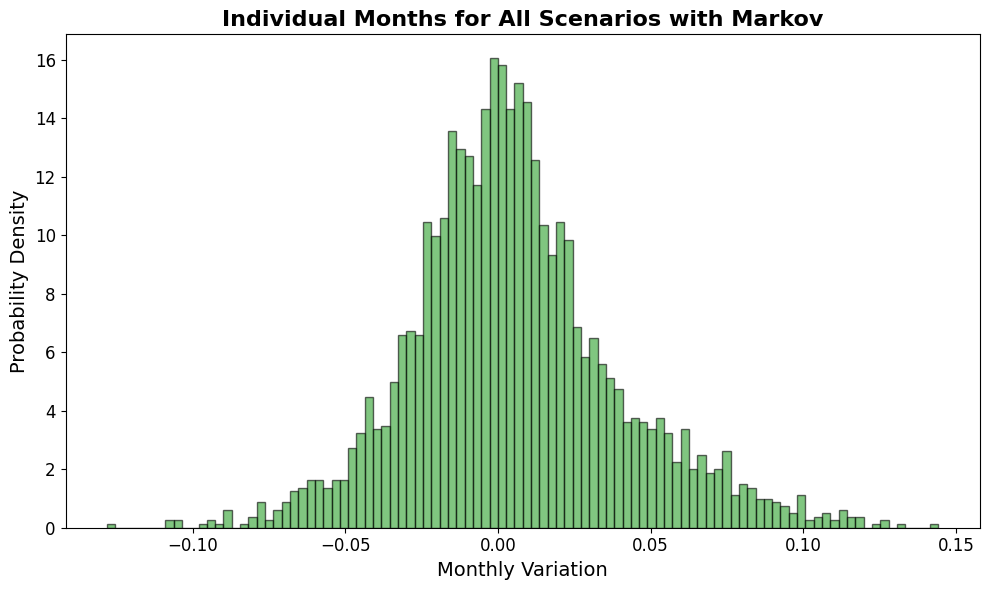

In [37]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from statsmodels.tsa.regime_switching import markov_regression as mr

# ------------------------------------------------------------
# Parâmetros básicos (altere se quiser)
# ------------------------------------------------------------
K = 3                       # nº de regimes
DEFAULT_T = 60              # horizonte (meses) se T não existir no ambiente
NUM_SCENARIOS = S           # nº de cenários a simular

# Se T não estiver definido no ambiente, use DEFAULT_T
try:
    T
except NameError:
    T = DEFAULT_T

if True:

    # ------------------------------------------------------------
    # 1) série de retornos (%)
    #    Exige que 'dolar_mean' exista como array-like de preços/cotações
    # ------------------------------------------------------------
    if 'dolar_mean' not in globals():
        raise ValueError("Defina 'dolar_mean' (série de preços) antes de rodar este script.")

    fx  = pd.Series(dolar_mean, dtype=float)
    ret = 100 * np.log(fx).diff().dropna()        # log-retorno em %

    # ------------------------------------------------------------
    # 2) ajusta Markov (K regimes) com média e variância diferentes
    # ------------------------------------------------------------
    mod = mr.MarkovRegression(
        ret,
        k_regimes=K,
        trend='c',                 # constante por regime
        switching_variance=True    # variância muda por regime
    )
    res = mod.fit(disp=False)
    print(res.summary())

    # ------------------------------------------------------------
    # 3) matriz de transição (do modelo) e momentos por regime
    # ------------------------------------------------------------
    # Matriz de transição diretamente do modelo
    P_raw = mod.regime_transition_matrix(res.params)
    P = P_raw if P_raw.ndim == 2 else P_raw[:, :, 0]

    # Em geral, statsmodels retorna P como "left-stochastic":
    # P[i, j] = Prob(ir de j -> i) (colunas somam 1)
    # Para simular no formato comum (linhas somam 1: de estado atual -> próximo),
    # usamos a transposta:
    P_row = P.T

    # Momentos por regime via probs suavizadas (robusto)
    probs = res.smoothed_marginal_probabilities  # DataFrame com colunas 0..K-1
    y = ret.values

    mu  = np.zeros(K)
    sig = np.zeros(K)
    for k in range(K):
        w = probs[k].values
        w_sum = w.sum()
        if w_sum <= 0 or not np.isfinite(w_sum):
            mu[k]  = y.mean()
            sig[k] = y.std(ddof=1)
        else:
            mu[k]  = np.sum(w * y) / w_sum
            sig[k] = np.sqrt(np.sum(w * (y - mu[k])**2) / w_sum)

    print("Médias por regime:", mu)
    print("Desvios por regime:", sig)
    print("Matriz de transição (linhas somam 1):\n", P_row)

    # ------------------------------------------------------------
    # 4) simula caminhos de retorno
    # ------------------------------------------------------------
    np.random.seed(42)
    steps = T - 1
    paths = np.zeros((NUM_SCENARIOS, steps))

    # Regime inicial: última prob suavizada (mais "a partir de hoje")
    p0 = probs.iloc[-1].to_numpy()
    p0 = p0 / p0.sum() if p0.sum() > 0 else np.ones(K) / K

    for s in range(NUM_SCENARIOS):
        r = np.random.choice(np.arange(K), p=p0)  # regime inicial
        for t in range(steps):
            paths[s, t] = np.random.normal(mu[r], sig[r])  # retorno em %
            r = np.random.choice(np.arange(K), p=P_row[r]) # próximo regime

    # ------------------------------------------------------------
    # 5) grava no formato antigo (coluna única empilhada, em decimais)
    # ------------------------------------------------------------
    scenarios_data_markov = (paths / 100).reshape(-1, 1)  # % → decimal
    with open('all_data_markov.pkl', 'wb') as f:
        pickle.dump(scenarios_data_markov, f)

else:
    scenarios_data_markov = pickle.load(open('all_data_markov.pkl', 'rb'))

# ------------------------------------------------------------
# 6) histograma de todos os retornos simulados (opcional)
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.hist(scenarios_data_markov, bins=100, density=True, alpha=0.6,
    color="#2ca02c",
    edgecolor="black")
plt.title('Individual Months for All Scenarios with Markov', fontsize=16, fontweight="bold")
plt.xlabel('Monthly Variation', fontsize=14)
plt.ylabel('Probability Density', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('./figures/fig_hist_monthly_markov.png', dpi=300)


### Uso de moment matching para gerar os retornos

In [19]:
# Bloco 1
# (mantive a ideia, mas ajustei a curtose para "excess kurtosis" para ficar consistente com a literatura/Fleishman)

import numpy as np

# Extrair os parâmetros dos dados
target_mean = np.mean(dolar_mean_variation)
target_variance = np.var(dolar_mean_variation)
target_skewness = np.mean((dolar_mean_variation - target_mean)**3) / target_variance**(3/2)

# kurtosis "Pearson" (E[(x-mu)^4]/var^2) -> excess kurtosis = Pearson - 3
target_kurtosis = np.mean((dolar_mean_variation - target_mean)**4) / target_variance**2 - 3

New data generated


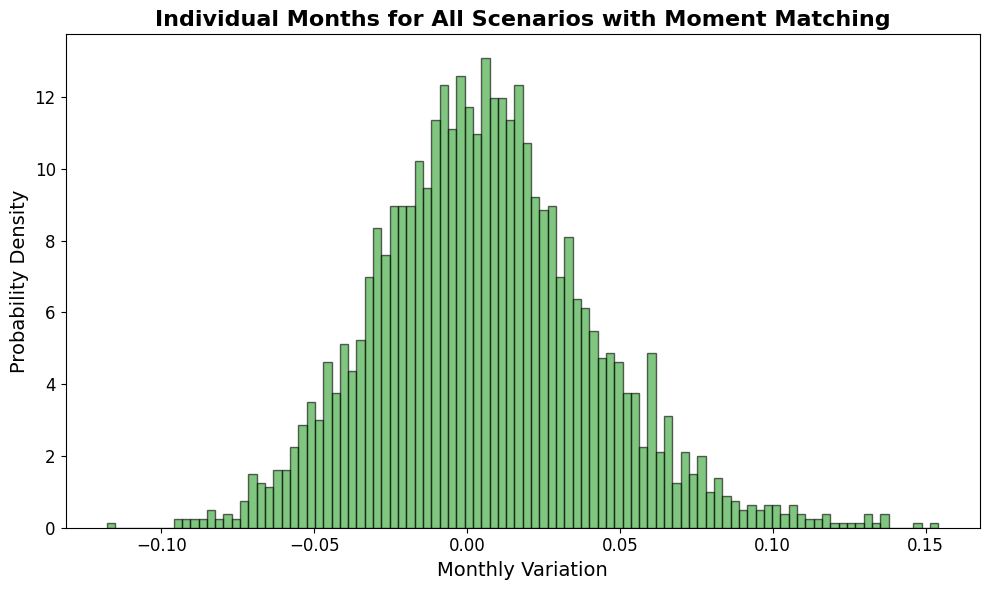

In [20]:
# Bloco 2
# (copiei o que é igual: imports, histograma, estrutura de geração com GENERATE_NEW_SCENARIOS,
#  mas alterei o núcleo de geração para Fleishman (cúbico), evitando a otimização CG em todos os pontos)

import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.optimize import root

def fleishman_system(bcd, g1, g2_excess):
    """
    Sistema de equações de Fleishman para encontrar b,c,d tal que:
    Var=1, Skew=g1, Excess Kurtosis=g2_excess
    """
    b, c, d = bcd

    b2 = b*b
    c2 = c*c
    d2 = d*d
    bd = b*d

    # Variância
    var = b2 + 6*bd + 2*c2 + 15*d2

    # Assimetria (skewness)
    sk = 2*c*(b2 + 24*bd + 105*d2 + 2)

    # Excess kurtosis
    ku_excess = 24 * (
        bd
        + c2*(1 + b2 + 28*bd)
        + d2*(12 + 48*bd + 141*c2 + 225*d2)
    )

    return np.array([var - 1.0, sk - g1, ku_excess - g2_excess])

def generate_scenarios_with_moment_matching(mean, variance, skewness, excess_kurtosis, size=10000, seed=42):
    """
    Gera amostras i.i.d. que casam mean, variance, skewness e EXCESS kurtosis usando Fleishman.
    Retorna um array (size, 1).
    """
    rng = np.random.default_rng(seed)

    # resolve b,c,d
    x0 = np.array([1.0, 0.0, 0.0])  # chute inicial
    sol = root(fleishman_system, x0, args=(skewness, excess_kurtosis), method="hybr")
    if not sol.success:
        raise RuntimeError(f"Fleishman não convergiu: {sol.message}")

    b, c, d = sol.x

    # amostra Z~N(0,1) e aplica transformação cúbica
    z = rng.standard_normal(size)
    y_std = (-c) + b*z + c*(z**2) + d*(z**3)  # ~ mean 0, var 1

    # escala para bater média e variância (variance = sigma^2)
    sigma = np.sqrt(variance)
    y = mean + sigma * y_std

    return y.reshape(-1, 1)

# Parâmetros dos cenários
scenarios = S  # Número de cenários
initial_variable_costs = 0.35
dolar_affect_parameter = 0.5

if True:
    # Gera (T-1)*S amostras de variação (mesma unidade do seu dolar_mean_variation)
    all_data = generate_scenarios_with_moment_matching(
        mean=target_mean,
        variance=target_variance,
        skewness=target_skewness,
        excess_kurtosis=target_kurtosis,
        size=(T-1) * scenarios,
        seed=42
    )

    print("New data generated")

    # Mantém compatibilidade com o seu pickle antigo
    pickle.dump(all_data, open('all_data.pkl', 'wb'))
else:
    all_data = pickle.load(open('all_data.pkl', 'rb'))

# Visualiza os dados de todos os cenários
plt.figure(figsize=(10, 6))
plt.hist(all_data, bins=100, density=True, alpha=0.6,
    color="#2ca02c",
    edgecolor="black")
plt.title('Individual Months for All Scenarios with Moment Matching', fontsize=16, fontweight="bold")
plt.xlabel('Monthly Variation', fontsize=14)
plt.ylabel('Probability Density', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('./figures/fig_hist_monthly_mm.png', dpi=300)
plt.show()

In [21]:
# scenarios_alt = np.zeros((scenarios, T))

if True:
    scenarios_data = all_data.reshape(scenarios, (T-1)).tolist()

    values = []
    for i in range(scenarios):
        values_list = [initial_variable_costs]
        for t in range(1, T):
            values_list.append(values_list[t-1] + scenarios_data[i][t-1] * dolar_affect_parameter)
        values.append(values_list)

    scenarios_data = values

    pickle.dump(scenarios_data, open('scenarios_data.pkl', 'wb'))

else:
    scenarios_data = pickle.load(open('scenarios_data.pkl', 'rb'))



## Avaliação de Cenários por CRPS


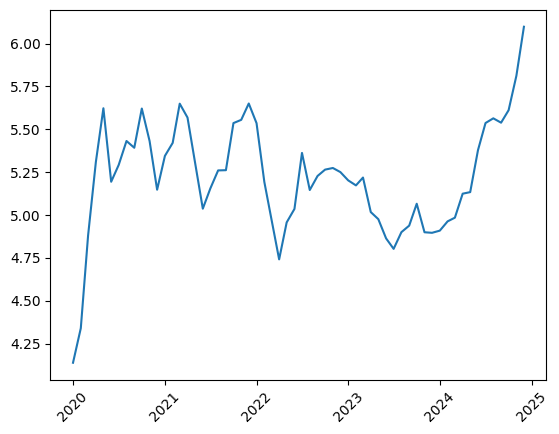

In [41]:
import numpy as np
from scipy.stats import norm

from currency_converter import CurrencyConverter
from datetime import datetime
from numpy import mean
import calendar
import matplotlib.pyplot as plt

c = CurrencyConverter(fallback_on_missing_rate=True)

# Pega a média do dólar mensal desde 2010
dolar_mean = []
for i in range(2020, 2025):
    for j in range(1, 13):
        _, num_days = calendar.monthrange(i, j)
        dolar_mean.append(mean([c.convert(1, 'USD', 'BRL', date=datetime(i, j, k)) for k in range(1, num_days+1)]))

# Plota o gráfico utilizando datas no eixo x
plt.plot([datetime(i, j, 1) for i in range(2020, 2025) for j in range(1, 13)], dolar_mean)
plt.xticks(rotation=45)
plt.show()


# variação
dolar_mean_variation = np.diff(dolar_mean)
dolar_mean_variation = [(dolar_mean[i] + dolar_mean_variation[i]) / dolar_mean[i] - 1 
                        for i in range(len(dolar_mean_variation))]

In [42]:
len(dolar_mean_variation)

59

In [43]:
import numpy as np
import pickle

def crps_ensemble(samples: np.ndarray, obs: float) -> float:
    """
    CRPS sample-based para um conjunto de amostras (ensemble) e um observado.
    samples: array shape (S,) ou (S,1)
    obs: float (observado)
    Retorna: float (quanto menor, melhor)
    """
    y = np.asarray(samples, dtype=float).reshape(-1)
    n = y.size
    if n == 0:
        raise ValueError("samples vazio")
    if n == 1:
        return float(np.abs(y[0] - obs))

    # Termo 1: E|Y - x|
    term1 = np.mean(np.abs(y - obs))

    # Termo 2: (1/(2n^2)) sum_{i,j} |y_i - y_j|
    # Computação O(n log n) via ordenação:
    y_sorted = np.sort(y)
    coef = 2 * np.arange(n) - n + 1  # (2k - n + 1), k=0..n-1
    sum_i_lt_j = np.sum(coef * y_sorted)  # = sum_{i<j} (y_j - y_i)
    term2 = sum_i_lt_j / (n ** 2)

    return float(term1 - term2)


def crps_from_paths(paths: np.ndarray, realized: np.ndarray):
    """
    Calcula CRPS por passo e CRPS médio ao longo do horizonte.
    paths: array shape (S, steps)  (retornos simulados em decimal)
    realized: array shape (steps,) (retornos realizados em decimal)
    Retorna:
      crps_by_step: array (steps,)
      crps_mean: float
    """
    paths = np.asarray(paths, dtype=float)
    realized = np.asarray(realized, dtype=float).reshape(-1)

    if paths.ndim != 2:
        raise ValueError("paths deve ser 2D (S, steps)")
    S, steps = paths.shape
    if realized.size != steps:
        raise ValueError(f"realized deve ter tamanho {steps}, mas tem {realized.size}")

    crps_by_step = np.zeros(steps, dtype=float)
    for t in range(steps):
        crps_by_step[t] = crps_ensemble(paths[:, t], realized[t])

    return crps_by_step, float(crps_by_step.mean())


def load_flat_pickle_as_matrix(pkl_path: str, S: int, steps: int) -> np.ndarray:
    """
    Lê pickle no formato antigo (N,1) e reconstrói matriz (S, steps).
    """
    data = pickle.load(open(pkl_path, "rb"))
    arr = np.asarray(data, dtype=float).reshape(-1)  # N,
    expected = S * steps
    if arr.size != expected:
        raise ValueError(f"Tamanho no pickle ({arr.size}) != S*steps ({expected}). "
                         "Confira S e T.")
    return arr.reshape(S, steps)


# -----------------------------
# EXEMPLO DE USO (com seus pickles)
# -----------------------------
# Supondo que:
# - você gerou cenários para steps = T-1 (ex.: 59)
# - S é o número de cenários
# - e você tem os retornos realizados do período correspondente (em decimal)
#
# realized_returns deve ter tamanho = steps
#
# realized_returns = ...  # ex.: np.array([...], dtype=float)  # decimal

realized_returns = dolar_mean_variation

steps = T - 1
paths_garch  = load_flat_pickle_as_matrix("all_data_arch.pkl",   S=S, steps=steps)
paths_markov = load_flat_pickle_as_matrix("all_data_markov.pkl", S=S, steps=steps)
paths_mm     = load_flat_pickle_as_matrix("all_data.pkl",        S=S, steps=steps)

crps_garch_by_step,  crps_garch_mean  = crps_from_paths(paths_garch,  realized_returns)
crps_markov_by_step, crps_markov_mean = crps_from_paths(paths_markov, realized_returns)
crps_mm_by_step,     crps_mm_mean     = crps_from_paths(paths_mm,     realized_returns)

print("CRPS médio GARCH :", crps_garch_mean)
print("CRPS médio Markov:", crps_markov_mean)
print("CRPS médio MM    :", crps_mm_mean)


CRPS médio GARCH : 0.021140863877121142
CRPS médio Markov: 0.021222506587734252
CRPS médio MM    : 0.020888889490214408


## Gerando os cenários para o churn

In [327]:
if True:
    # Gerando os cenários de churn
    churn_scenarios = np.random.normal(loc=churn_rate, scale=0.001, size=(scenarios, T))
    churn_scenarios = np.clip(churn_scenarios, 0, 1)  # Garante que os valores estejam entre 0 e 1
    pickle.dump(churn_scenarios, open('churn_scenarios.pkl', 'wb'))
else:
    churn_scenarios = pickle.load(open('churn_scenarios.pkl', 'rb'))
    
churn_data = churn_scenarios.copy()

# Modelo Múltiplo

In [45]:
from pyomo.environ import *
import math

# ============================================================
# MODELO MÚLTIPLO (multi-cenário) - ATUALIZADO PARA O NOVO WACC
# ============================================================
# Pressupõe que estes símbolos já existam no seu ambiente:
#   scenarios (int), T (int)
#   P_min, Q_min, Q_max, CF, DF
#   a_inc, b_inc, a, b
#   variable_expenses_percentage, taxes_percentage
#   theta_AR, theta_I, theta_AP, initial_NCG, initial_inventory
#   price_of_factory, factory_lifetime, production_capacity
#   growth_rate
#   inital_sales (sic)
#   scenarios_data  -> matriz/lista [scenarios][T]
#   churn_data      -> matriz/lista [scenarios][T]
#
# Novo bloco Capital/WACC:
#   initial_equity, initial_debt, initial_cost_of_debt
#   E_max, D_max, Borrow_max, L_loan
#   cost_of_equity
#   months_future_FCO

# ------------------------------------------------------------------
# 0) modelo e sets
# ------------------------------------------------------------------
model = ConcreteModel()
model.S = RangeSet(1, scenarios)
model.T = RangeSet(1, T)

# ------------------------------------------------------------------
# 1) parâmetro preço + iniciais
# ------------------------------------------------------------------
model.P = Param(initialize=P_min)  # preço fixo

model.initial_quantity  = Param(initialize=inital_sales)
model.initial_mkt       = Param(initialize=10)
model.initial_factories = Param(initialize=3, mutable=False)

# ------------------------------------------------------------------
# 2) inicializações (chutes simples) - (vamos reforçar via warm start depois)
# ------------------------------------------------------------------
def init_Q(m, i, t):
    return float(value(m.initial_quantity))

def init_M(m, i, t):
    return float(value(m.initial_mkt))

def init_fact(m, i, t):
    return int(value(m.initial_factories))

def init_Borrow(m, i, t):
    return 0.0

def init_amort_rule(m, t):
    return initial_debt / L_loan if t <= L_loan else 0.0

def init_Repay(m, i, t):
    # Repay inicial = amortização do estoque inicial
    return float(value(m.init_amort[t]))

def init_D(m, i, t):
    # chute simples (será sobrescrito por warm start)
    return max(0.0, float(initial_debt))

def init_E(m, i, t):
    return max(0.0, float(initial_equity))

def init_WACC(m, i, t):
    cap = max(1.0, float(initial_equity) + float(initial_debt))
    w = (float(initial_equity) / cap) * float(cost_of_equity) + (float(initial_debt) / cap) * float(initial_cost_of_debt)
    return min(0.99999, max(0.00001, w))

# ------------------------------------------------------------------
# 3) decisões operacionais
# ------------------------------------------------------------------
model.Q = Var(model.S, model.T, bounds=(Q_min, Q_max * 2), within=NonNegativeIntegers, initialize=init_Q)

M_MAX = 1e6  # ajuste se quiser
model.M = Var(model.S, model.T, bounds=(0, M_MAX), within=NonNegativeReals, initialize=init_M)

# coeficientes do incremento
model.a_inc = Param(initialize=a_inc)
model.b_inc = Param(initialize=b_inc)

def incr_rule(m, i, t):
    return m.a_inc * m.M[i, t] + m.b_inc
model.Increment = Expression(model.S, model.T, rule=incr_rule)

# fábricas (inteiro)
model.num_factories = Var(model.S, model.T, within=NonNegativeIntegers, initialize=init_fact)

# fixa condições iniciais
for i in range(1, scenarios + 1):
    model.Q[i, 1].fix(model.initial_quantity)
    model.M[i, 1].fix(model.initial_mkt)
    model.num_factories[i, 1].fix(value(model.initial_factories))

# ------------------------------------------------------------------
# 4) custos, despesas, impostos
# ------------------------------------------------------------------
model.variable_expenses_percentage = Param(initialize=variable_expenses_percentage)
model.taxes_percentage             = Param(initialize=taxes_percentage)
model.fix_costs                    = Param(initialize=CF)
model.fix_expenses                 = Param(initialize=DF)

# custo variável percentual (cenário x mês)
model.variable_cost_percentage = Param(
    model.S, model.T,
    initialize=lambda m, i, t: scenarios_data[i-1][t-1]
)

# churn rate (cenário x mês)
model.churn_rate = Param(
    model.S, model.T,
    initialize=lambda m, i, t: churn_data[i-1][t-1]
)

# ------------------------------------------------------------------
# 5) demanda (mantido)
# ------------------------------------------------------------------
model.a = Param(initialize=a)
model.b = Param(initialize=b)

# ------------------------------------------------------------------
# 6) parâmetros da NCG
# ------------------------------------------------------------------
model.theta_AR           = Param(initialize=theta_AR)
model.theta_I            = Param(initialize=theta_I)
model.theta_AP           = Param(initialize=theta_AP)
model.initial_NCG        = Param(initialize=initial_NCG)
model.initial_investment = Param(initialize=initial_inventory)

# ------------------------------------------------------------------
# 7) expressões auxiliares (receita, capex, NCG, FCF)
# ------------------------------------------------------------------
def revenue_rule(m, i, t):
    return m.P * m.Q[i, t]

def depreciation_rule(m, i, t):
    return (price_of_factory / factory_lifetime) * m.num_factories[i, t]

model.price_of_factory = Param(initialize=price_of_factory, mutable=False)

def difference_on_factories_rule(m, i, t):
    prev = m.num_factories[i, t-1] if t > 1 else m.initial_factories
    return m.num_factories[i, t] - prev

def capex_aquisi_rule(m, i, t):
    return m.price_of_factory * difference_on_factories_rule(m, i, t)

def AR_rule(m, i, t):
    return revenue_rule(m, i, t) * m.theta_AR

def I_rule(m, i, t):
    return (m.variable_cost_percentage[i, t] * revenue_rule(m, i, t)) * m.theta_I

def AP_rule(m, i, t):
    prev_I = I_rule(m, i, t-1) if t > 1 else m.initial_investment
    return (I_rule(m, i, t)
            + m.variable_cost_percentage[i, t] * revenue_rule(m, i, t)
            - prev_I) * m.theta_AP

def NCG_rule(m, i, t):
    prev = (AR_rule(m, i, t-1) + I_rule(m, i, t-1) - AP_rule(m, i, t-1)
            if t > 1 else m.initial_NCG)
    return AR_rule(m, i, t) + I_rule(m, i, t) - AP_rule(m, i, t) - prev

def fcf_period_expression(m, i, t):
    receita = revenue_rule(m, i, t)
    dep = depreciation_rule(m, i, t)
    capex = capex_aquisi_rule(m, i, t)
    return (receita
            - m.variable_cost_percentage[i, t] * receita
            - m.variable_expenses_percentage  * receita
            - m.M[i, t]
            - m.taxes_percentage * receita
            - m.fix_costs
            - m.fix_expenses
            - dep
            - capex
            - NCG_rule(m, i, t))

# ------------------------------------------------------------------
# 8) BLOCO Capital/WACC
# ------------------------------------------------------------------
CAPITAL_MIN = 1.0
WACC_MIN = 0.00001
WACC_MAX = 0.99999

model.cost_of_equity = Param(initialize=cost_of_equity)

# custo da dívida exógeno por mês
model.cost_of_debt = Param(model.T, initialize=lambda m, t: initial_cost_of_debt)

# (IMPORTANTE) init_amort precisa existir ANTES do initialize do Repay
model.init_amort = Param(model.T, initialize=init_amort_rule, mutable=False)

# estoques de capital por cenário e mês
model.E = Var(model.S, model.T, bounds=(0, E_max), within=NonNegativeReals, initialize=init_E)
model.D = Var(model.S, model.T, bounds=(0, D_max), within=NonNegativeReals, initialize=init_D)

# fluxos de financiamento
model.Borrow = Var(model.S, model.T, bounds=(0, Borrow_max), within=NonNegativeReals, initialize=init_Borrow)
model.Repay  = Var(model.S, model.T, bounds=(0, 10e9), within=NonNegativeReals, initialize=init_Repay)

# repay schedule por cenário
def repay_schedule_rule(m, i, t):
    kmin = max(1, t - L_loan + 1)
    s = sum(m.Borrow[i, k] for k in range(kmin, t + 1))
    return m.Repay[i, t] == m.init_amort[t] + (1.0 / L_loan) * s
model.repay_schedule = Constraint(model.S, model.T, rule=repay_schedule_rule)

# dinâmica da dívida por cenário
def debt_dyn_rule(m, i, t):
    if t == 1:
        return m.D[i, 1] == initial_debt + m.Borrow[i, 1] - m.Repay[i, 1]
    return m.D[i, t] == m.D[i, t-1] + m.Borrow[i, t] - m.Repay[i, t]
model.debt_dyn = Constraint(model.S, model.T, rule=debt_dyn_rule)

# juros por cenário
def interest_rule(m, i, t):
    D_prev = initial_debt if t == 1 else m.D[i, t-1]
    return m.cost_of_debt[t] * D_prev
model.Interest = Expression(model.S, model.T, rule=interest_rule)

# EBIT por cenário
def ebit_rule(m, i, t):
    receita = revenue_rule(m, i, t)
    dep = depreciation_rule(m, i, t)
    return (receita
            - m.variable_cost_percentage[i, t] * receita
            - m.variable_expenses_percentage * receita
            - m.M[i, t]
            - m.taxes_percentage * receita
            - m.fix_costs
            - m.fix_expenses
            - dep)
model.EBIT = Expression(model.S, model.T, rule=ebit_rule)

# NI por cenário
def ni_rule(m, i, t):
    return m.EBIT[i, t] - m.Interest[i, t]
model.NI = Expression(model.S, model.T, rule=ni_rule)

# dinâmica do equity por cenário (sem aporte)
def equity_dyn_rule(m, i, t):
    if t == 1:
        return m.E[i, 1] == initial_equity + m.NI[i, 1]
    return m.E[i, t] == m.E[i, t-1] + m.NI[i, t]
model.equity_dyn = Constraint(model.S, model.T, rule=equity_dyn_rule)

# evitar capital total ~0
model.capital_positive = Constraint(
    model.S, model.T,
    rule=lambda m, i, t: m.E[i, t] + m.D[i, t] >= CAPITAL_MIN
)

# WACC como VAR + definição bilinear
model.WACC = Var(model.S, model.T, bounds=(WACC_MIN, WACC_MAX), initialize=init_WACC)

def wacc_def_rule(m, i, t):
    return (m.E[i, t] + m.D[i, t]) * m.WACC[i, t] == (
        m.E[i, t] * m.cost_of_equity + m.D[i, t] * m.cost_of_debt[t]
    )
model.wacc_def = Constraint(model.S, model.T, rule=wacc_def_rule)

model.wacc_positive = Constraint(model.S, model.T, rule=lambda m, i, t: m.WACC[i, t] >= 0.001)

# ------------------------------------------------------------------
# 9) objetivo
# ------------------------------------------------------------------
def objective_rule(m):
    t0 = T - months_future_FCO + 1
    return (1.0 / scenarios) * sum(
        sum(
            fcf_period_expression(m, i, t) / ((1 + m.WACC[i, t]) ** t)
            for t in range(t0, T + 1)
        )
        for i in range(1, scenarios + 1)
    )
model.objective = Objective(rule=objective_rule, sense=maximize)

# ------------------------------------------------------------------
# 10) restrições operacionais
# ------------------------------------------------------------------
def growth_rule(m, i, t):
    return (m.Q[i, t] <= m.Q[i, t-1] * growth_rate
            if t > 1 else
            m.Q[i, t] <= m.initial_quantity)
model.growth = Constraint(model.S, model.T, rule=growth_rule)

def non_regression_rule(m, i, t):
    return (m.Q[i, t] >= m.Q[i, t-1]
            if t > 1 else
            m.Q[i, t] >= m.initial_quantity)
model.non_regression = Constraint(model.S, model.T, rule=non_regression_rule)

def qty_increment_rule(m, i, t):
    if t == 1:
        return Constraint.Skip
    return m.Q[i, t] == ((1 - m.churn_rate[i, t]) * m.Q[i, t-1]) + m.Increment[i, t]
model.qty_increment = Constraint(model.S, model.T, rule=qty_increment_rule)

def capex_aquisi_constraint_rule(m, i, t):
    return capex_aquisi_rule(m, i, t) >= 0
model.capex_aquisi_constraint = Constraint(model.S, model.T, rule=capex_aquisi_constraint_rule)

def production_capacity_rule(m, i, t):
    return m.Q[i, t] <= m.num_factories[i, t] * production_capacity
model.production_capacity_constraint = Constraint(model.S, model.T, rule=production_capacity_rule)

# ------------------------------------------------------------------
# 11) expressões para relatório (NCG)
# ------------------------------------------------------------------
model.AR  = Expression(model.S, model.T, rule=AR_rule)
model.I   = Expression(model.S, model.T, rule=I_rule)
model.AP  = Expression(model.S, model.T, rule=AP_rule)
model.NCG = Expression(model.S, model.T, rule=NCG_rule)

# ------------------------------------------------------------------
# 12) WARM START (sem alterar a modelagem): preencher valores iniciais coerentes
#     Ideia: reduzir inf_pr criando um ponto inicial "quase viável"
# ------------------------------------------------------------------
def _clip(x, lo, hi):
    return max(lo, min(hi, x))

for i in range(1, scenarios + 1):

    # 12.1) construir trajetória inicial (Q, M) respeitando qty_increment + não-regressão
    #       Escolha: manter Q não decrescente e ajustar M (via Increment) para compensar churn
    Q_prev = float(value(model.initial_quantity))

    # t=1 já fixo
    model.Q[i, 1].set_value(Q_prev)
    model.M[i, 1].set_value(float(value(model.initial_mkt)))

    for t in range(2, T + 1):
        churn = float(value(model.churn_rate[i, t]))

        # M mínimo para que Q[t] >= Q[t-1] dado qty_increment:
        # Q[t-1] = (1-churn)*Q[t-1] + a_inc*M + b_inc  =>  a_inc*M + b_inc = churn*Q_prev
        if float(a_inc) != 0.0:
            M_req = (churn * Q_prev - float(b_inc)) / float(a_inc)
        else:
            # se a_inc=0, não tem como ajustar M via incremento; fica no chute base
            M_req = float(value(model.initial_mkt))

        M_val = max(float(value(model.initial_mkt)), M_req)
        M_val = _clip(M_val, 0.0, M_MAX)
        model.M[i, t].set_value(M_val)

        # calcula Q pela eq. de incremento e depois força não-regressão (mantendo consistência na prática)
        Q_val = (1.0 - churn) * Q_prev + float(a_inc) * M_val + float(b_inc)

        # força não-regressão explicitamente no chute (ajuda reduzir violação em non_regression)
        Q_val = max(Q_prev, Q_val)

        # força também growth (se growth_rate < 1, só por segurança; normalmente growth_rate >= 1)
        Q_val = min(Q_val, Q_prev * float(growth_rate))

        # respeita bounds do Pyomo
        Q_val = _clip(Q_val, float(Q_min), float(Q_max) * 2.0)

        model.Q[i, t].set_value(Q_val)
        Q_prev = Q_val

    # 12.2) fábricas: não decrescer e suficiente para capacity
    f_prev = int(value(model.initial_factories))
    for t in range(2, T + 1):
        q = float(value(model.Q[i, t]))
        f_req = int(math.ceil(q / float(production_capacity))) if production_capacity > 0 else f_prev
        f_val = max(f_prev, f_req)
        model.num_factories[i, t].set_value(f_val)
        f_prev = f_val

    # 12.3) financiamento: Borrow=0; Repay=amort init; D por debt_dyn (consistente com repay)
    for t in range(1, T + 1):
        model.Borrow[i, t].set_value(0.0)
        model.Repay[i, t].set_value(float(value(model.init_amort[t])))

    D_prev = float(initial_debt)
    for t in range(1, T + 1):
        D_now = D_prev + 0.0 - float(value(model.Repay[i, t]))
        D_now = max(0.0, D_now)
        model.D[i, t].set_value(_clip(D_now, 0.0, float(D_max)))
        D_prev = float(value(model.D[i, t]))

    # 12.4) equity: calcular NI com base no chute e satisfazer equity_dyn recursivamente
    #       (isso costuma derrubar bastante inf_pr)
    E_prev = float(initial_equity)
    for t in range(1, T + 1):
        receita = float(value(model.P)) * float(value(model.Q[i, t]))
        dep = (float(price_of_factory) / float(factory_lifetime)) * float(value(model.num_factories[i, t]))

        ebit = (receita
                - float(value(model.variable_cost_percentage[i, t])) * receita
                - float(value(model.variable_expenses_percentage)) * receita
                - float(value(model.M[i, t]))
                - float(value(model.taxes_percentage)) * receita
                - float(value(model.fix_costs))
                - float(value(model.fix_expenses))
                - dep)

        D_prev_for_interest = float(initial_debt) if t == 1 else float(value(model.D[i, t-1]))
        interest = float(value(model.cost_of_debt[t])) * D_prev_for_interest

        ni = ebit - interest

        if t == 1:
            E_now = float(initial_equity) + ni
        else:
            E_now = E_prev + ni

        E_now = _clip(E_now, 0.0, float(E_max))
        model.E[i, t].set_value(E_now)
        E_prev = E_now

    # 12.5) WACC coerente com wacc_def (com clipping para bounds)
    for t in range(1, T + 1):
        E = float(value(model.E[i, t]))
        D = float(value(model.D[i, t]))
        cap = max(float(CAPITAL_MIN), E + D)

        w = (E / cap) * float(value(model.cost_of_equity)) + (D / cap) * float(value(model.cost_of_debt[t]))
        w = _clip(w, float(WACC_MIN), float(WACC_MAX))
        model.WACC[i, t].set_value(w)

import math
from pyomo.environ import value

def apply_warm_start(m):
    # 1) Decisões operacionais: garantir consistência com qty_increment e capacidade
    for i in m.S:
        # mês 1 já está fixado por você
        for t in m.T:
            if t == 1:
                continue

            # chute simples de marketing (pode ajustar)
            if m.M[i, t].value is None:
                m.M[i, t].set_value(value(m.initial_mkt))

            q_prev = value(m.Q[i, t-1])
            churn  = value(m.churn_rate[i, t])
            incr   = value(m.a_inc) * value(m.M[i, t]) + value(m.b_inc)

            # faz Q satisfazer exatamente a igualdade qty_increment
            q = (1.0 - churn) * q_prev + incr

            # respeita bounds do próprio Var Q
            lb, ub = m.Q[i, t].bounds
            if lb is not None: q = max(lb, q)
            if ub is not None: q = min(ub, q)
            m.Q[i, t].set_value(q)

            # fábricas: garantir capacidade >= Q (evita inf_pr gigante logo de cara)
            fac = max(1, int(math.ceil(q / production_capacity)))
            # respeita bounds se existirem
            if m.num_factories[i, t].value is None:
                m.num_factories[i, t].set_value(fac)
            else:
                m.num_factories[i, t].set_value(max(fac, int(value(m.num_factories[i, t]))))

    # 2) Financiamento: começar sem novos empréstimos e com amortização "limpa"
    for i in m.S:
        for t in m.T:
            m.Borrow[i, t].set_value(0.0)
            m.Repay[i, t].set_value(value(m.init_amort[t]))

        # dívida por dinâmica (consistente com debt_dyn)
        for t in m.T:
            if t == 1:
                D = float(initial_debt) + 0.0 - value(m.Repay[i, 1])
            else:
                D = value(m.D[i, t-1]) + 0.0 - value(m.Repay[i, t])
            D = max(0.0, D)
            # respeita bounds do Var D
            lb, ub = m.D[i, t].bounds
            if lb is not None: D = max(lb, D)
            if ub is not None: D = min(ub, D)
            m.D[i, t].set_value(D)

    # 3) Equity: simular via NI e equity_dyn (consistente)
    for i in m.S:
        for t in m.T:
            # NI é Expression -> depende de Q,M,num_factories e D (que já setamos)
            if t == 1:
                E = float(initial_equity) + value(m.NI[i, 1])
            else:
                E = value(m.E[i, t-1]) + value(m.NI[i, t])
            E = max(0.0, E)
            lb, ub = m.E[i, t].bounds
            if lb is not None: E = max(lb, E)
            if ub is not None: E = min(ub, E)
            m.E[i, t].set_value(E)

    # 4) WACC: setar para satisfazer wacc_def (bilinear) o máximo possível
    for i in m.S:
        for t in m.T:
            E = value(m.E[i, t])
            D = value(m.D[i, t])
            cap = max(CAPITAL_MIN, E + D)
            w = (E * float(cost_of_equity) + D * float(initial_cost_of_debt)) / cap

            lb, ub = m.WACC[i, t].bounds
            if lb is not None: w = max(lb, w)
            if ub is not None: w = min(ub, w)
            m.WACC[i, t].set_value(w)

# >>> chame isto antes do solve:
apply_warm_start(model)


# ------------------------------------------------------------------
# 13) solver
# ------------------------------------------------------------------
solver = SolverFactory("mindtpy")
result = solver.solve(
    model,
    strategy="OA",
    init_strategy="rNLP",
    mip_solver="appsi_highs",
    nlp_solver="ipopt",
    mip_solver_tee=True,
    nlp_solver_tee=True,
    tee=True,
    nlp_solver_args={
        'options': {
                    # logs
        "print_info_string": "yes",
        "print_level": 5,

        # warm start do IPOPT (aproveita os valores definidos acima)
        "warm_start_init_point": "yes",
        "warm_start_bound_push": 1e-6,
        "warm_start_mult_bound_push": 1e-6,
        "warm_start_slack_bound_push": 1e-6,

        "max_iter": 30000,  # ou o valor que você quiser (padrão é 3000)

        # um pouco mais robusto (opcional)
        "mu_strategy": "adaptive",
    "nlp_scaling_method": "gradient-based",
    "bound_relax_factor": 0.0,

        }
    },
    
)

if result.solver.status == SolverStatus.ok:
    print("Solução encontrada com sucesso!")
else:
    print("Não foi possível encontrar uma solução.")

# relatório rápido
for i in range(1, scenarios + 1):
    print(f"\n--- Cenário {i} ---")
    for t in range(1, T + 1):
        print(
            f"Mês {t}: Q={value(model.Q[i,t]):.4f}, M={value(model.M[i,t]):.4f}, "
            f"Factories={value(model.num_factories[i,t]):.0f}, "
            f"Borrow={value(model.Borrow[i,t]):.4f}, Repay={value(model.Repay[i,t]):.4f}, "
            f"D={value(model.D[i,t]):.4f}, E={value(model.E[i,t]):.4f}, WACC={value(model.WACC[i,t]):.4f}"
        )


WARNING (W1001): Setting Var 'Q[1,2]' to a value `250028.17278644565` (float)
not in domain NonNegativeIntegers.
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1001
WARNING (W1001): Setting Var 'Q[1,3]' to a value `250028.17278644565` (float)
not in domain NonNegativeIntegers.
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1001
WARNING (W1001): Setting Var 'Q[1,4]' to a value `250028.17278644565` (float)
not in domain NonNegativeIntegers.
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1001
WARNING (W1001): Setting Var 'Q[1,5]' to a value `250028.17278644565` (float)
not in domain NonNegativeIntegers.
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1001
WARNING (W1001): Setting Var 'Q[1,6]' to a value `251030.67278644565` (float)
not in domain NonNegativeIntegers.
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1001
WARNING (W1001): Setting Var 'Q[1,7]' to a value `251030.67278644565` (float)
not in 

Starting MindtPy version 1.0.0 using OA algorithm
iteration_limit: 50
stalling_limit: 15
time_limit: 600
strategy: OA
add_regularization: None
call_after_main_solve: <pyomo.contrib.gdpopt.util._DoNothing object at 0x13329c2b0>
call_before_subproblem_solve: <pyomo.contrib.gdpopt.util._DoNothing object at 0x13321ab10>
call_after_subproblem_solve: <pyomo.contrib.gdpopt.util._DoNothing object at 0x1332889e0>
call_after_subproblem_feasible: <pyomo.contrib.gdpopt.util._DoNothing object at 0x133288af0>
tee: true
logger: <Logger pyomo.contrib.mindtpy (INFO)>
logging_level: 20
integer_to_binary: false
add_no_good_cuts: false
use_tabu_list: false
single_tree: false
solution_pool: false
num_solution_iteration: 5
cycling_check: true
feasibility_norm: L_infinity
differentiate_mode: reverse_symbolic
use_mcpp: false
calculate_dual_at_solution: false
use_fbbt: false
use_dual_bound: true
partition_obj_nonlinear_terms: true
quadratic_strategy: 0
move_objective: false
add_cuts_at_incumbent: false
heurist

Ipopt 3.14.16: constr_viol_tol=1e-08
max_cpu_time=591
print_info_string=yes
print_level=5
warm_start_init_point=yes
warm_start_bound_push=1e-06
warm_start_mult_bound_push=1e-06
warm_start_slack_bound_push=1e-06
max_iter=30000
mu_strategy=adaptive
nlp_scaling_method=gradient-based
bound_relax_factor=0.0


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.16, running with linear solver MUMPS 5.6.2.

Number of nonzeros in equality constraint Jacobian...:    83200
Number of nonzeros in inequality constraint Jacobian.:    35001
Number of nonzeros in Lagrangian Hessian.............:    19500

Total number of variables..................

KeyboardInterrupt: 

## Criação de Funções auxiliares para calcular Receita, Lucro e FCO

In [ ]:
from pyomo.environ import value


def fco_period_multiple(model, i, t):
    return value(model.P * model.Q[i, t] - model.variable_cost_percentage[i, t] * model.P * model.Q[i, t] - model.variable_expenses_percentage * model.P * model.Q[i, t] - model.taxes_percentage * model.P * model.Q[i, t] - model.fix_costs - model.fix_expenses - model.NCG[i, t])

def revenue_period_multiple(model, i, t):
    return value(model.P * model.Q[i, t])

def profit_period_multiple(model, i, t):
    return value(model.P * model.Q[i, t] - model.variable_cost_percentage[i, t] * model.P * model.Q[i, t] - model.variable_expenses_percentage * model.P * model.Q[i, t] - model.taxes_percentage * model.P * model.Q[i, t] - model.fix_costs - model.fix_expenses)

## Gráficos de Comportamento da Solução

### Quantidade de Fábricas

In [ ]:
# plot de preço e quantidade para cada cenário
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [model.num_factories[i, t].value for t in range(1, T+1)], label=f'Cenário {i}')
    
plt.xlabel('Mês')
plt.ylabel('Número de Fábricas')
plt.title('Quantidade de Fábricas ao Longo dos Meses por Cenário')

### Gastos em Marketing

In [ ]:
# plot de preço e quantidade para cada cenário
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [model.M[i, t].value for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Gastos com Marketing')
plt.title('R$ Gastos em MKT ao Longo dos Meses por Cenário')

### Quantidade de Vendas por Período

In [ ]:
# plot de preço e quantidade para cada cenário
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [model.Q[i, t].value for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Quantidade de Vendas')
plt.title('Quantidade de Vendas ao Longo dos Meses Para Cada Cenário')

### Receita por Período

In [ ]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [revenue_period_multiple(model, i, t) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Receita')
plt.title('Receita ao Longo dos Meses Para Cada Cenário')
plt.show()

### Lucro por Período

In [ ]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [profit_period_multiple(model, i, t) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Lucro')
plt.title('Lucro ao Longo dos Meses Para Cada Cenário')
plt.show()

### Fluxo de Caixa Operacional por Período

In [ ]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [fco_period_multiple(model, i, t) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Fluxo de Caixa Operacional')
plt.title('Fluxo de Caixa Operacional ao Longo dos Meses Para Cada Cenário')
plt.show()

### Equity e Debt por Período

In [ ]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [model.E[i, t].value for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Equity')
plt.title('Equity ao Longo dos Meses Para Cada Cenário')

In [ ]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [model.D[i, t].value for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Debt')
plt.title('Debt ao Longo dos Meses Para Cada Cenário')

### Quantidade de Fábricas

In [ ]:
# plot de preço e quantidade para cada cenário
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [model.num_factories[i, t].value for t in range(1, T+1)], label=f'Cenário {i}')
    
plt.xlabel('Mês')
plt.ylabel('Número de Fábricas')
plt.title('Quantidade de Fábricas ao Longo dos Meses por Cenário')

### Gastos em Marketing

In [ ]:
# plot de preço e quantidade para cada cenário
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [model.M[i, t].value for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Gastos com Marketing')
plt.title('R$ Gastos em MKT ao Longo dos Meses por Cenário')

### Quantidade de Vendas por Período

In [ ]:
# plot de preço e quantidade para cada cenário
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [model.Q[i, t].value for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Quantidade de Vendas')
plt.title('Quantidade de Vendas ao Longo dos Meses Para Cada Cenário')

### Receita por Período

In [ ]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [revenue_period_multiple(model, i, t) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Receita')
plt.title('Receita ao Longo dos Meses Para Cada Cenário')
plt.show()

### Lucro por Período

In [ ]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [profit_period_multiple(model, i, t) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Lucro')
plt.title('Lucro ao Longo dos Meses Para Cada Cenário')
plt.show()

### Fluxo de Caixa Operacional por Período

In [ ]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [fco_period_multiple(model, i, t) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Fluxo de Caixa Operacional')
plt.title('Fluxo de Caixa Operacional ao Longo dos Meses Para Cada Cenário')
plt.show()

### Equity e Debt por Período

In [ ]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [model.E[i, t].value for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Equity')
plt.title('Equity ao Longo dos Meses Para Cada Cenário')
plt.show()

In [ ]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [model.D[i, t].value for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Debt')
plt.title('Debt ao Longo dos Meses Para Cada Cenário')
plt.show()

# Modelo Estocástico Mono-objetivo | FCO Último Ano

## Versão Linearizada (WACC Fixo)

### Primeiro Passo: Encontrar um valor de M razoável

In [225]:
from pyomo.environ import *

# ---------------------------------------------------------------
# 0) cria o modelo e define horizonte
# ---------------------------------------------------------------
stochastic_model = model = ConcreteModel()
T = 60
S = range(1, scenarios + 1)     # conjunto de cenários

# ---------------------------------------------------------------
# 1) variáveis / parâmetros básicos
# ---------------------------------------------------------------
model.P = Param(initialize=P_min)

model.Q = Var(S, range(1, T+1),
              bounds=(Q_min, 2*Q_max), within=NonNegativeReals)

M_MAX = 1e6
model.M = Var(range(1, T+1),
              bounds=(0, M_MAX), within=NonNegativeReals)

model.a_inc = Param(initialize=a_inc)
model.b_inc = Param(initialize=b_inc)
model.Increment = Expression(
    range(1, T+1), rule=lambda m, t: m.a_inc * m.M[t] + m.b_inc
)

# Variável de Quantidade de fábricas (uma inteira)
model.num_factories = Var(S, range(1, T+1), within=NonNegativeIntegers)

# ---------------------------------------------------------------
# 2) custos, despesas, impostos
# ---------------------------------------------------------------
model.variable_expenses_percentage = Param(initialize=variable_expenses_percentage)
model.taxes_percentage             = Param(initialize=taxes_percentage)
model.fix_costs                    = Param(initialize=CF)
model.fix_expenses                 = Param(initialize=DF)

model.variable_cost_percentage = Param(
    S, range(1, T+1),
    initialize=lambda m, i, t: scenarios_data[i-1][t-1],
    mutable=True
)

# churn rate (cenário x mês)
model.churn_rate = Param(
    range(1, scenarios+1), range(1, T+1),
    initialize=lambda m, i, t: churn_data[i-1][t-1]
)

# ---------------------------------------------------------------
# 3) demanda e parâmetros diversos
# ---------------------------------------------------------------
model.a = Param(initialize=a)
model.b = Param(initialize=b)

model.initial_quantity = Param(initialize=inital_sales)
for i in S:
    model.Q[i, 1].fix(model.initial_quantity)

model.initial_mkt = Param(initialize=10)
model.M[1].fix(model.initial_mkt)

# ---------------------------------------------------------------
# 4) parâmetros de NCG
# ---------------------------------------------------------------
model.theta_AR           = Param(initialize=theta_AR)
model.theta_I            = Param(initialize=theta_I)
model.theta_AP           = Param(initialize=theta_AP)
model.initial_NCG        = Param(initialize=initial_NCG)
model.initial_investment = Param(initialize=initial_inventory)

# ---------------------------------------------------------------
# 5) expressões auxiliares (iguais ao seu estocástico)
# ---------------------------------------------------------------
def revenue_rule(m, i, t):
    return m.P * m.Q[i, t]

def depreciation_rule(m, i, t):
    return (price_of_factory / factory_lifetime) * m.num_factories[i, t]

model.initial_factories = Param(initialize=Q_min // production_capacity, mutable=False)
model.price_of_factory = Param(initialize=price_of_factory, mutable=False)

def difference_on_factories_rule(m, i, t):
    prev = m.num_factories[i, t-1] if t > 1 else m.initial_factories
    return m.num_factories[i, t] - prev

def capex_aquisi_rule(m, i, t):
    return m.price_of_factory * difference_on_factories_rule(m, i, t)

def AR_rule(m, i, t):
    return revenue_rule(m, i, t) * m.theta_AR

def I_rule(m, i, t):
    return m.variable_cost_percentage[i, t] * revenue_rule(m, i, t) * m.theta_I

def AP_rule(m, i, t):
    prev_I = I_rule(m, i, t-1) if t > 1 else m.initial_investment
    return (I_rule(m, i, t)
            + m.variable_cost_percentage[i, t] * revenue_rule(m, i, t)
            - prev_I) * m.theta_AP

def NCG_rule(m, i, t):
    prev = (AR_rule(m, i, t-1) + I_rule(m, i, t-1) - AP_rule(m, i, t-1)
            if t > 1 else m.initial_NCG)
    return AR_rule(m, i, t) + I_rule(m, i, t) - AP_rule(m, i, t) - prev

def fcf_period_expression(m, i, t):
    receita = revenue_rule(m, i, t)
    depreciation = depreciation_rule(m, i, t)
    capex_aquisi = capex_aquisi_rule(m, i, t)
    return (receita
            - m.variable_cost_percentage[i, t] * receita
            - m.variable_expenses_percentage  * receita
            - m.M[t]
            - m.taxes_percentage * receita
            - m.fix_costs - m.fix_expenses
            - depreciation
            - capex_aquisi
            - NCG_rule(m, i, t))

# ===============================================================
# 6) NOVIDADES DO DETERMINÍSTICO (SUBSTITUEM: "EMPRÉSTIMO ÚNICO" e WACC FIXO)
#     - remove o bloco do "empréstimo bullet" e coloca o bloco (E, D, Borrow, Repay, WACC dinâmico)
# ===============================================================

# Fixar custo da dívida (exógeno) por mês
model.cost_of_debt = Param(range(1, T+1), initialize=lambda m, t: initial_cost_of_debt)

# WACC: parâmetros
model.cost_of_equity = Param(initialize=cost_of_equity)
model.tax_rate       = Param(initialize=tax_rate)

# --- dívida (decisão comum a todos os cenários, como no seu estocástico original)
model.D = Var(range(1, T+1), bounds=(0, D_max), within=NonNegativeReals, initialize=initial_debt)
model.Borrow = Var(range(1, T+1), bounds=(0, Borrow_max), within=NonNegativeReals, initialize=0.0)
model.Repay  = Var(range(1, T+1), bounds=(0, 10e9), within=NonNegativeReals, initialize=0.0)

# Amortização do estoque inicial (linear em L_loan meses)
def init_amort_rule(m, t):
    return initial_debt / L_loan if t <= L_loan else 0.0
model.init_amort = Param(range(1, T+1), initialize=init_amort_rule, mutable=False)

# Amortização das novas tomadas: cada Borrow[k] paga 1/L_loan por mês durante L_loan meses
def repay_schedule_rule(m, t):
    s = 0.0
    kmin = max(1, t - L_loan + 1)
    for k in range(kmin, t+1):
        s += m.Borrow[k]
    return m.Repay[t] == m.init_amort[t] + (1.0 / L_loan) * s
model.repay_schedule = Constraint(range(1, T+1), rule=repay_schedule_rule)

# Dinâmica do estoque de dívida
def debt_dyn_rule(m, t):
    if t == 1:
        return m.D[1] == initial_debt + m.Borrow[1] - m.Repay[1]
    return m.D[t] == m.D[t-1] + m.Borrow[t] - m.Repay[t]
model.debt_dyn = Constraint(range(1, T+1), rule=debt_dyn_rule)

# Juros (sobre D do mês anterior; no t=1 usa initial_debt)
def interest_rule(m, t):
    D_prev = initial_debt if t == 1 else m.D[t-1]
    return m.cost_of_debt[t] * D_prev
model.Interest = Expression(range(1, T+1), rule=interest_rule)

# --- equity por cenário (porque o resultado operacional varia por cenário)
model.E = Var(S, range(1, T+1), bounds=(1e-3, E_max), within=NonNegativeReals,
              initialize=lambda m, i, t: initial_equity)

def ebit_rule(m, i, t):
    receita = revenue_rule(m, i, t)
    dep = depreciation_rule(m, i, t)
    return (receita
            - m.variable_cost_percentage[i, t] * receita
            - m.variable_expenses_percentage * receita
            - m.M[t]
            - m.taxes_percentage * receita
            - m.fix_costs
            - m.fix_expenses
            - dep)
model.EBIT = Expression(S, range(1, T+1), rule=ebit_rule)

def ni_rule(m, i, t):
    return m.EBIT[i, t] - m.Interest[t]
model.NI = Expression(S, range(1, T+1), rule=ni_rule)

def equity_dyn_rule(m, i, t):
    if t == 1:
        return m.E[i, 1] == initial_equity + m.NI[i, 1]
    return m.E[i, t] == m.E[i, t-1] + m.NI[i, t]
model.equity_dyn = Constraint(S, range(1, T+1), rule=equity_dyn_rule)

# WACC dinâmico (variável) + definição bilinear (como no determinístico)
WACC_MIN = 0.00001
WACC_MAX = 0.99999
CAPITAL_MIN = 0.0

model.WACC = Var(S, range(1, T+1), bounds=(WACC_MIN, WACC_MAX), initialize=0.10)

model.capital_positive = Constraint(
    S, range(1, T+1),
    rule=lambda m, i, t: m.E[i, t] + m.D[t] >= CAPITAL_MIN
)

def wacc_def_rule(m, i, t):
    return (m.E[i, t] + m.D[t]) * m.WACC[i, t] == m.E[i, t] * m.cost_of_equity + m.D[t] * m.cost_of_debt[t]
model.wacc_def = Constraint(S, range(1, T+1), rule=wacc_def_rule)

# Desativa a definição do WACC
model.wacc_def.deactivate()

model.wacc_positive = Constraint(S, range(1, T+1), rule=lambda m, i, t: m.WACC[i, t] >= WACC_MIN)

# ---------------------------------------------------------------
# 7) objetivo (VPL médio) — igual ao determinístico (sem discount_factor recursivo)
# ---------------------------------------------------------------

# Janela do valuation (igual à sua)
t_final = T
t_ini = t_final - months_future_FCO + 1

# 1) Param de desconto por cenário/mês (atualizado a cada iteração)
if not hasattr(model, "disc"):
    model.disc = Param(S, range(1, T+1), mutable=True, initialize=1.0)

from pyomo.environ import value

# Fixando o que não é resolvido linearmente
for i in S:
    for t in range(1, T+1):
        w = model.WACC[i, t].value if model.WACC[i, t].value is not None else 0.10
        model.disc[i, t] = 1.0 / ((1.0 + float(w)) ** t)

for i in S:
    for t in range(1, T+1):
        w = model.WACC[i, t].value if model.WACC[i, t].value is not None else 0.10
        model.WACC[i, t].fix(w)

# for t in range(1, T+1):
#     model.Borrow[t].fix(value(model.Borrow[t]) if model.Borrow[t].value is not None else 0.0)
#     model.Repay[t].fix(value(model.Repay[t])  if model.Repay[t].value  is not None else value(model.init_amort[t]))
#     model.D[t].fix(value(model.D[t])          if model.D[t].value      is not None else initial_debt)

# 2) Objetivo linear (HiGHS): usa disc constante -> MILP ok
def obj_highs_rule(m):
    return sum(
        (sum(fcf_period_expression(m, i, t) * m.disc[i, t] for i in S) / len(S))
        for t in range(t_ini, t_final + 1)
    )

if not hasattr(model, "obj_highs"):
    model.obj_highs = Objective(rule=obj_highs_rule, sense=maximize)
else:
    model.obj_highs.activate()

# 3) Objetivo não linear (IPOPT): usa WACC variável no expoente
def obj_ipopt_rule(m):
    return sum(
        (sum(
            fcf_period_expression(m, i, t) / ((1 + m.WACC[i, t]) ** t)
            for i in S
        ) / len(S))
        for t in range(t_ini, t_final + 1)
    )

if not hasattr(model, "obj_ipopt"):
    model.obj_ipopt = Objective(rule=obj_ipopt_rule, sense=maximize)
model.obj_ipopt.deactivate()

# ---------------------------------------------------------------
# 8) restrições (mantidas exatamente como você tinha)
# ---------------------------------------------------------------
def growth_rule(m, i, t):
    if t == 1:
        return m.Q[i, t] <= m.initial_quantity
    return m.Q[i, t] <= m.Q[i, t-1] * 1.2
model.growth = Constraint(S, range(1, T+1), rule=growth_rule)

def non_regression_rule(m, i, t):
    if t == 1:
        return m.Q[i, t] >= m.initial_quantity
    return m.Q[i, t] >= m.Q[i, t-1]
model.non_regression = Constraint(S, range(1, T+1), rule=non_regression_rule)

def qty_increment_rule(m, i, t):
    if t == 1:
        return Constraint.Skip
    return m.Q[i, t] == (1 - m.churn_rate[i, t]/2) * m.Q[i, t-1] + m.Increment[t]
model.qty_increment = Constraint(S, range(1, T+1), rule=qty_increment_rule)

def capex_aquisi_constraint_rule(m, i, t):
    return capex_aquisi_rule(m, i, t) >= 0
model.capex_aquisi_constraint = Constraint(S, range(1, T+1), rule=capex_aquisi_constraint_rule)

def production_capacity_rule(m, i, t):
    return m.Q[i, t] <= m.num_factories[i, t] * production_capacity
model.production_capacity_constraint = Constraint(S, range(1, T+1), rule=production_capacity_rule)

# ---------------------------------------------------------------
# 9) expressões úteis para relatório
# ---------------------------------------------------------------
model.AR  = Expression(S, range(1, T+1), rule=AR_rule)
model.I   = Expression(S, range(1, T+1), rule=I_rule)
model.AP  = Expression(S, range(1, T+1), rule=AP_rule)
model.NCG = Expression(S, range(1, T+1), rule=NCG_rule)

# ---------------------------------------------------------------
# 10) solver (mantido)
# ---------------------------------------------------------------
# OBS: com WACC variável (bilinear + potência) isso vira MINLP/NLP.
# Use o mesmo solver que você usa no determinístico (ex.: MindtPy).
solver = SolverFactory("highs")

result = solver.solve(
    model,
    tee=True,
    # strategy="OA",
    # init_strategy="rNLP",

    # # Master MILP
    # mip_solver="appsi_highs",

    # # Subproblem NLP
    # nlp_solver="ipopt",

    # # (opcional) limite global do MindtPy (segundos)
    # time_limit=3600,

    # mip_solver_tee=True,
    # nlp_solver_tee=True,
    # tee=True,

    # # Se quiser também limitar tempo do MILP master:
    # # mip_solver_args={"options": {"time_limit": 600, "mip_rel_gap": 1e-4}},

    # nlp_solver_args={
    #     "options": {
    #         # desempenho/log
    #         "print_level": 3,                 # 5 é bem verboso e custa tempo
    #         "print_info_string": "yes",

    #         # tempo e iterações
    #         "max_cpu_time": 3600,             # <<< isso evita o “Maximum CPU time exceeded”
    #         "max_iter": 30000,                # 30000 costuma ser overkill

    #         # robustez numérica / velocidade
    #         "mu_strategy": "adaptive",
    #         "nlp_scaling_method": "gradient-based",
    #         "hessian_approximation": "limited-memory",  # <<< geralmente ajuda MUITO

    #         # parada “aceitável” (evita gastar tempo/instabilidade no final)
    #         "tol": 1e-6,
    #         "acceptable_tol": 1e-5,
    #         "acceptable_iter": 50,

    #         # warm-start (eu manteria só o bound_push; evitar mexer com multipliers no começo)
    #         "warm_start_bound_push": 1e-6,
    #         # eu removeria estes dois inicialmente; podem atrapalhar quando o ponto muda muito:
    #         # "warm_start_mult_bound_push": 1e-6,
    #         # "warm_start_slack_bound_push": 1e-6,
    #     }
    # },
)


In [219]:
from pyomo.environ import *
from pyomo.environ import value

# ===============================================================
# BLOCO IPOPT: otimizar financiamento/WACC com objetivo NÃO LINEAR
# - fixa M, Q, num_factories (congela operação)
# - libera Borrow/Repay/D/E/WACC
# - ativa wacc_def e ativa obj_ipopt (desativa obj_highs)
# - evita TOO_FEW_DOF desativando restrições que definem Q
# - warm-start só na 1ª vez (não sobrescreve uma solução boa)
# - capital_positive_eps: cria uma vez, depois só ativa
# ===============================================================

# ---------- 0) Trocar objetivo: IPOPT usa obj_ipopt ----------
if hasattr(model, "obj_highs"):
    model.obj_highs.deactivate()
if hasattr(model, "obj_ipopt"):
    model.obj_ipopt.activate()
else:
    raise RuntimeError("obj_ipopt não existe no modelo. Crie-o no bloco do modelo antes deste bloco IPOPT.")

# ---------- 1) Fixar MKT (M) em todos os meses (no valor atual do HiGHS) ----------
for t in range(1, T + 1):
    model.M[t].fix()  # fixa no value corrente

# ---------- 2) Congelar operação ----------
for i in S:
    for t in range(1, T + 1):
        if model.Q[i, t].value is None:
            model.Q[i, t].set_value(value(model.initial_quantity))

        if model.Q[i, t].value < 250_000:
            model.Q[i, t].fix(250_000)
        else:
            model.Q[i, t].fix()

        if model.num_factories[i, t].value is None:
            model.num_factories[i, t].set_value(value(model.initial_factories))
        model.num_factories[i, t].fix()

# ---------- 3) Liberar financiamento e WACC ----------
for t in range(1, T + 1):
    if model.Borrow[t].fixed: model.Borrow[t].unfix()
    if model.Repay[t].fixed:  model.Repay[t].unfix()
    if model.D[t].fixed:      model.D[t].unfix()

for i in S:
    for t in range(1, T + 1):
        if model.E[i, t].fixed:    model.E[i, t].unfix()
        if model.WACC[i, t].fixed: model.WACC[i, t].unfix()

# ---------- 4) Warm-start (apenas se for a primeira execução / sem valores) ----------
do_warm_start = (model.Borrow[1].value is None) or (model.D[1].value is None) or (model.E[1, 1].value is None)

if do_warm_start:
    for t in range(1, T + 1):
        model.Borrow[t].set_value(0.0)
        model.Repay[t].set_value(value(model.init_amort[t]))

    D0 = {}
    for t in range(1, T + 1):
        if t == 1:
            D0[t] = initial_debt + value(model.Borrow[1]) - value(model.Repay[1])
        else:
            D0[t] = D0[t-1] + value(model.Borrow[t]) - value(model.Repay[t])
        model.D[t].set_value(D0[t])

    def interest0(tt):
        D_prev = initial_debt if tt == 1 else D0[tt-1]
        return value(model.cost_of_debt[tt]) * D_prev

    for i in S:
        E0 = {}
        for t in range(1, T + 1):
            receita = value(model.P) * value(model.Q[i, t])
            dep = (value(model.price_of_factory) / factory_lifetime) * value(model.num_factories[i, t])

            ebit = (
                receita
                - value(model.variable_cost_percentage[i, t]) * receita
                - value(model.variable_expenses_percentage) * receita
                - value(model.M[t])
                - value(model.taxes_percentage) * receita
                - value(model.fix_costs)
                - value(model.fix_expenses)
                - dep
            )
            ni = ebit - interest0(t)

            if t == 1:
                E0[t] = initial_equity + ni
            else:
                E0[t] = E0[t-1] + ni

            model.E[i, t].set_value(E0[t])

# ---------- 5) Capital > 0 (evita degeneração no wacc_def) ----------
EPS_CAPITAL = 1e2
if hasattr(model, "capital_positive"):
    model.capital_positive.deactivate()

if not hasattr(model, "capital_positive_eps"):
    model.capital_positive_eps = Constraint(
        S, range(1, T + 1),
        rule=lambda m, i, t: m.E[i, t] + m.D[t] >= EPS_CAPITAL
    )
else:
    model.capital_positive_eps.activate()

# ---------- 6) Ligar a definição do WACC (bilinear) ----------
if hasattr(model, "wacc_def"):
    model.wacc_def.activate()
else:
    model.wacc_def = Constraint(S, range(1, T + 1), rule=wacc_def_rule)

# ---------- 7) Evitar TOO_FEW_DOF quando Q está FIXO ----------
if hasattr(model, "qty_increment"):
    model.qty_increment.deactivate()
if hasattr(model, "growth"):
    model.growth.deactivate()
if hasattr(model, "non_regression"):
    model.non_regression.deactivate()

if hasattr(model, "production_capacity_constraint"):
    model.production_capacity_constraint.deactivate()
if hasattr(model, "capex_aquisi_constraint"):
    model.capex_aquisi_constraint.deactivate()

# ---------- 8) SOLVER (NLP) ----------
solver = SolverFactory("ipopt")
solver.options["obj_scaling_factor"] = 1e-6
result = solver.solve(model, tee=True)


Ipopt 3.14.16: obj_scaling_factor=1e-06


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.16, running with linear solver MUMPS 5.6.2.

Number of nonzeros in equality constraint Jacobian...:    18853
Number of nonzeros in inequality constraint Jacobian.:     9000
Number of nonzeros in Lagrangian Hessian.............:     6600

Total number of variables............................:     6180
                     variables with only lower bounds:        0
                variables with lower and upper bounds:     6180
                     variables with only upper bounds:        0
Total number of equality constraints...............

## Criação de Funções auxiliares para calcular Receita, Lucro e FCO

In [154]:
from pyomo.environ import value


def fco_period(model, i, t):
    return value(3 * model.Q[i, t] - model.variable_cost_percentage[i, t] * 3 * model.Q[i, t] - model.variable_expenses_percentage * 3 * model.Q[i, t] - model.taxes_percentage * 3 * model.Q[i, t] - model.fix_costs - model.fix_expenses - model.NCG[i, t])

def revenue_period(model, i, t):
    return value(3 * model.Q[i, t])

def profit_period(model, i, t):
    return value(3 * model.Q[i, t] - model.variable_cost_percentage[i, t] * 3 * model.Q[i, t] - model.variable_expenses_percentage * 3 * model.Q[i, t] - model.taxes_percentage * 3 * model.Q[i, t] - model.fix_costs - model.fix_expenses)

## Decisão de Financiamento por Período

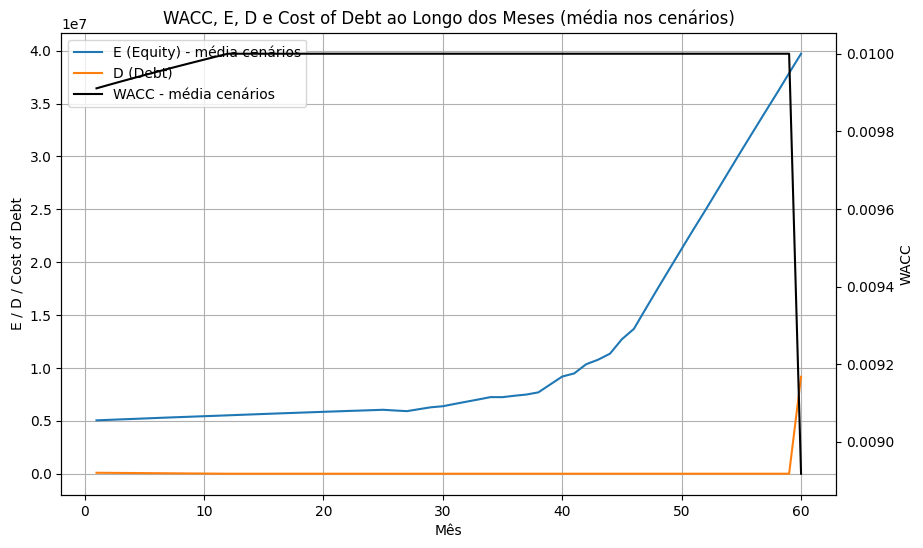

In [174]:
import matplotlib.pyplot as plt
from pyomo.environ import value

meses = range(1, T + 1)

# --- séries agregadas (média nos cenários) ---
wacc_series   = [sum(value(model.WACC[i, t]) for i in S) / len(S) for t in meses]
equity_series = [sum(value(model.E[i, t])    for i in S) / len(S) for t in meses]

# D é "decisão comum" (não depende do cenário)
debt_series   = [value(model.D[t]) for t in meses]

# (opcional) custo da dívida é Param por mês
cod_series    = [value(model.cost_of_debt[t]) for t in meses]

fig, ax1 = plt.subplots(figsize=(10, 6))

# E, D e cost_of_debt no eixo esquerdo
ax1.plot(meses, equity_series, label='E (Equity) - média cenários')
ax1.plot(meses, debt_series,   label='D (Debt)')
# ax1.plot(meses, cod_series,    label='Cost of Debt')
ax1.set_xlabel('Mês')
ax1.set_ylabel('E / D / Cost of Debt')
ax1.grid(True)

# WACC no eixo direito
ax2 = ax1.twinx()
ax2.plot(meses, wacc_series, label='WACC - média cenários', color='black')
ax2.set_ylabel('WACC')

# Legendas combinadas
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='best')

plt.title('WACC, E, D e Cost of Debt ao Longo dos Meses (média nos cenários)')
plt.show()


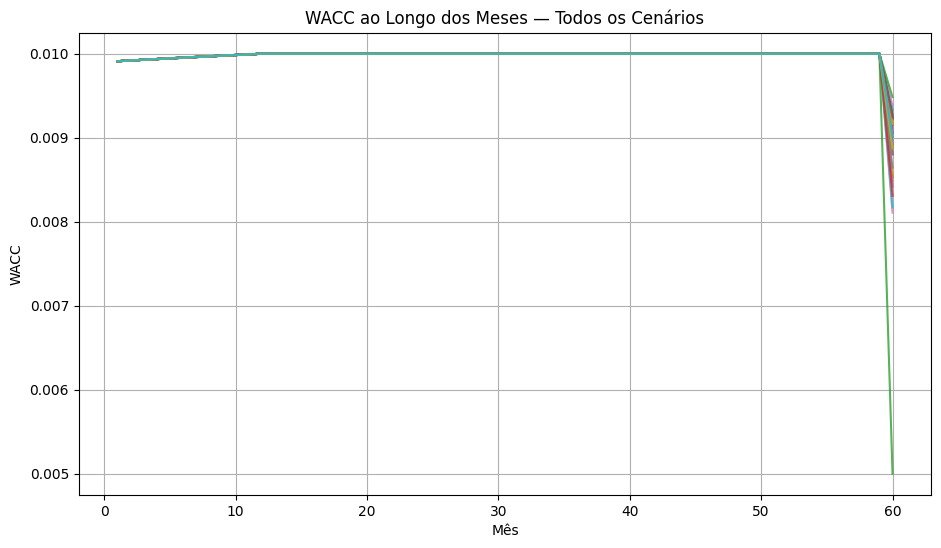

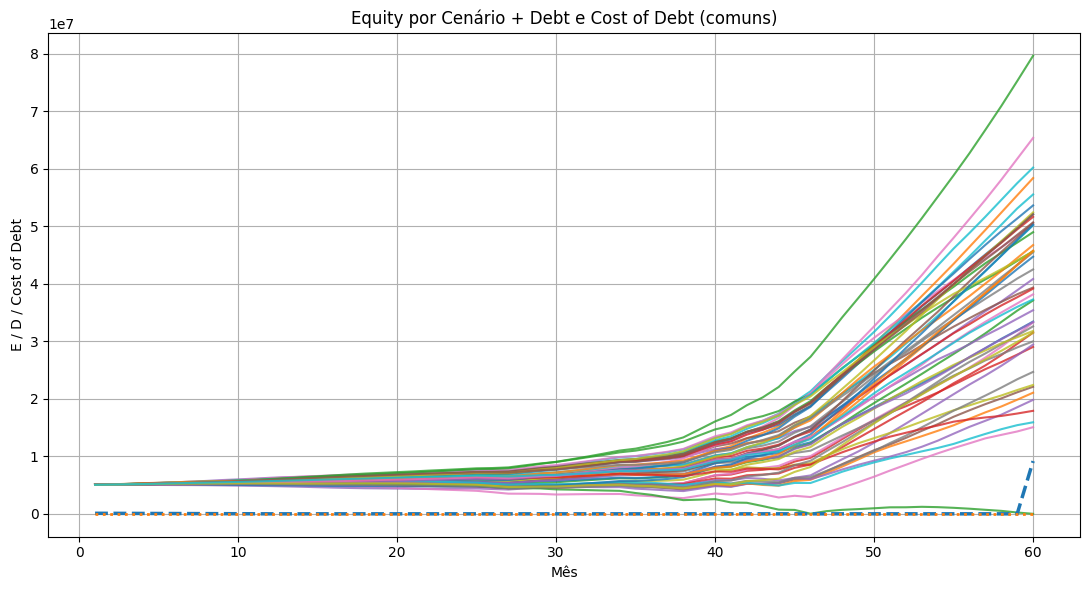

In [175]:
import matplotlib.pyplot as plt
from pyomo.environ import value

meses = range(1, T + 1)

# D é comum a todos os cenários
debt_series = [value(model.D[t]) for t in meses]

# (opcional) custo da dívida é Param por mês (comum)
cod_series  = [value(model.cost_of_debt[t]) for t in meses]

# ---------- (1) WACC por cenário (todas as curvas) ----------
fig, ax = plt.subplots(figsize=(11, 6))

for i in S:
    wacc_i = [value(model.WACC[i, t]) for t in meses]
    ax.plot(meses, wacc_i, linewidth=1.5, alpha=0.8, label=f'WACC (cenário {i})')

ax.set_xlabel("Mês")
ax.set_ylabel("WACC")
ax.grid(True)
ax.set_title("WACC ao Longo dos Meses — Todos os Cenários")
# ax.legend(loc="best", ncol=2, fontsize=9)
plt.show()


# ---------- (2) Equity por cenário + D (comum) + cost_of_debt (comum) ----------
fig, ax1 = plt.subplots(figsize=(11, 6))

# Equity por cenário (todas as curvas)
for i in S:
    e_i = [value(model.E[i, t]) for t in meses]
    ax1.plot(meses, e_i, linewidth=1.5, alpha=0.8, label=f'E (cenário {i})')

# D e cost_of_debt (comuns) no mesmo eixo esquerdo
ax1.plot(meses, debt_series, linewidth=2.5, linestyle="--", label="D (Debt) - comum")
ax1.plot(meses, cod_series,  linewidth=2.0, linestyle=":",  label="Cost of Debt - comum")

ax1.set_xlabel("Mês")
ax1.set_ylabel("E / D / Cost of Debt")
ax1.grid(True)

ax1.set_title("Equity por Cenário + Debt e Cost of Debt (comuns)")

# Legenda (muita coisa -> coloca fora)
# ax1.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0.0, fontsize=9)
plt.tight_layout()
plt.show()


## Quantidade de Vendas por Período

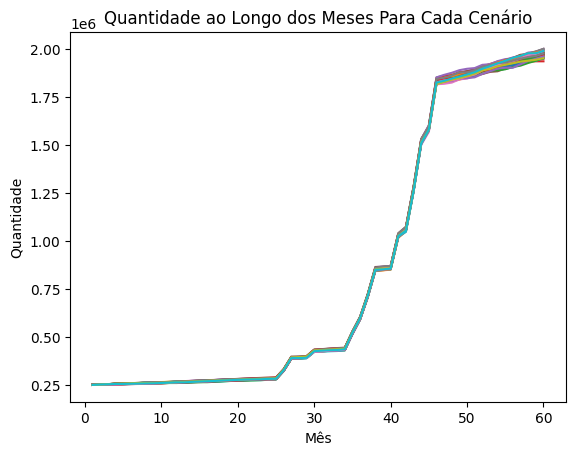

In [188]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [value(model.Q[i, t]) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Quantidade')
plt.title('Quantidade ao Longo dos Meses Para Cada Cenário')
plt.show()

## Fábricas por Período

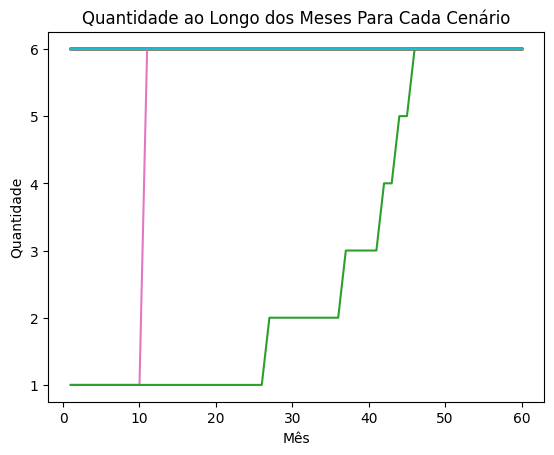

In [177]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [value(model.num_factories[i, t]) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Quantidade')
plt.title('Quantidade ao Longo dos Meses Para Cada Cenário')
plt.show()

## Marketing por Período

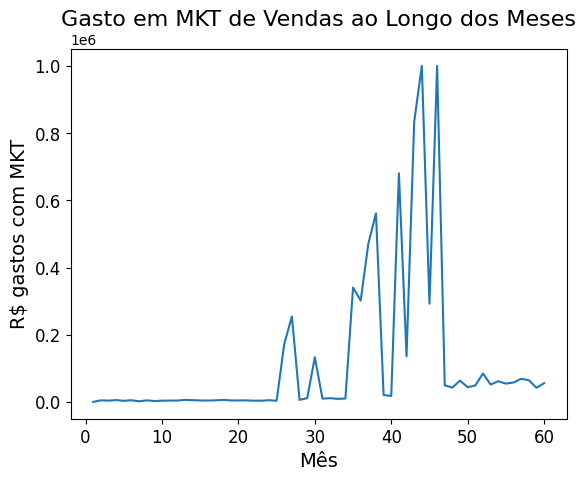

[10.0, 4630.875870727585, 3932.6701042712143, 5461.872977961439, 3326.1494838228805, 4951.244431044893, 1868.7382000339567, 4661.346849322651, 2637.792890548379, 3664.2223664666863, 3962.7558794446027, 4148.13315335137, 6045.011028783748, 5232.111844121657, 4383.115283471155, 4095.096339671479, 4674.072997017547, 6005.94663230853, 4488.709829368017, 4368.3380584430715, 4560.573703425449, 3694.48443422459, 3670.347839355179, 5122.681964837727, 3475.773309436895, 172569.05897712437, 254315.42645682927, 6038.855108581702, 11110.393744812345, 132920.22289183008, 9717.774589884415, 11202.328916747281, 9041.552283807267, 10142.602434373386, 340446.10883831605, 301764.8670943281, 470865.923551379, 561210.0107968313, 20629.686767790547, 17731.207699867282, 680498.4222344178, 135882.132747736, 833789.513171524, 1000000.0, 292462.5615216, 1000000.0, 49229.607344059536, 42764.18554115586, 63340.15683154103, 43802.10211746214, 49039.0441304232, 84676.42236126408, 51778.78039640794, 61500.152451960

In [189]:
import matplotlib.pyplot as plt

plt.plot(range(1, T+1), [model.M[t].value for t in range(1, T+1)])
plt.xlabel('Mês', fontsize=14)
plt.ylabel('R$ gastos com MKT', fontsize=14)
plt.title('Gasto em MKT de Vendas ao Longo dos Meses', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

print([model.M[t].value for t in range(1, T+1)])

## Receita por Período

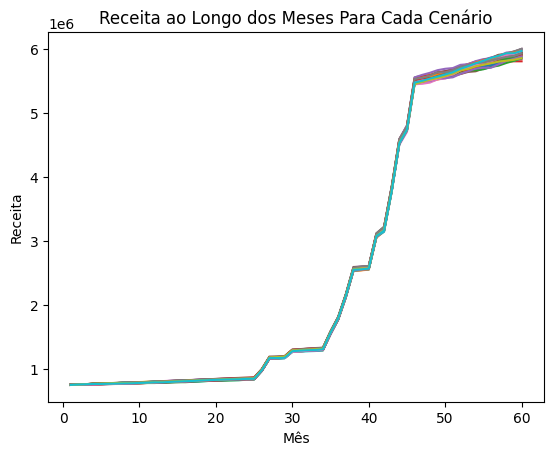

In [179]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [revenue_period(model, i, t) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Receita')
plt.title('Receita ao Longo dos Meses Para Cada Cenário')
plt.show()

## Lucro por Período

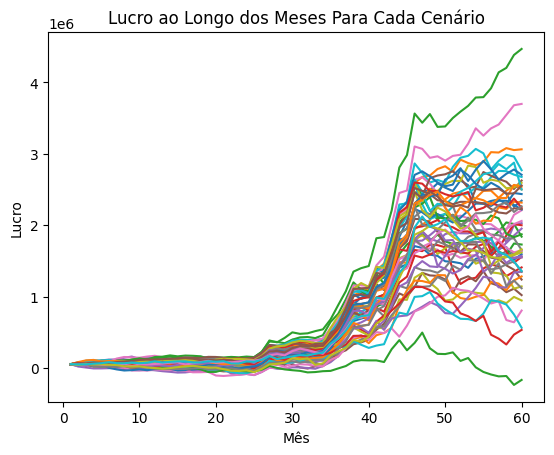

In [180]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [profit_period(model, i, t) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Lucro')
plt.title('Lucro ao Longo dos Meses Para Cada Cenário')
plt.show()

## Fluxo de Caixa Operacional por Período

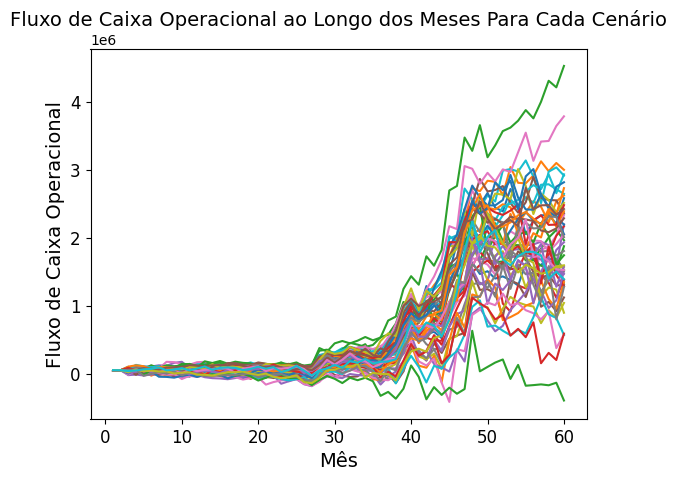

In [181]:


for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [fco_period(model, i, t) for t in range(1, T+1)], label=f'Cenário {i}')

# aumentar tamanho do titulo e dos eixos

plt.xlabel('Mês', fontsize=14)
plt.ylabel('Fluxo de Caixa Operacional', fontsize=14)
plt.title('Fluxo de Caixa Operacional ao Longo dos Meses Para Cada Cenário', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [182]:
M_star = {t: value(model.M[t]) for t in range(1, T+1)}


In [183]:
from pyomo.environ import SolverFactory, value

# ===============================================================
# LOOP (após você já ter rodado: HiGHS inicial -> IPOPT inicial)
# Alterna:
#   A) HiGHS: otimiza M/Q/fábricas com WACC fixo (via disc), financiamento fixo
#   B) IPOPT: otimiza financiamento + WACC com operação fixa, objetivo não linear
# ===============================================================

solver_highs = SolverFactory("highs")
solver_ipopt = SolverFactory("ipopt")

# ---- helpers ----
def _update_disc_from_current_wacc(m):
    """Atualiza m.disc usando os valores atuais de WACC (vindos do IPOPT)."""
    for i in S:
        for t in range(1, T+1):
            w = m.WACC[i, t].value
            if w is None:
                w = 0.10
                m.WACC[i, t].set_value(w)
            m.disc[i, t] = 1.0 / ((1.0 + float(w)) ** t)

def _prep_highs_block(m):
    """
    Prepara para HiGHS:
    - objetivo linear (obj_highs ON, obj_ipopt OFF)
    - wacc_def OFF
    - WACC FIXO (para não ficar solto)
    - disc atualizado com WACC
    - financiamento FIXO (Borrow/Repay/D)
    - operação livre (M t>=2; Q t>=2; num_factories livre)
    - restrições de operação ON
    """
    # objetivos
    if hasattr(m, "obj_ipopt"): m.obj_ipopt.deactivate()
    if hasattr(m, "obj_highs"): m.obj_highs.activate()

    # linearidade
    if hasattr(m, "wacc_def"): m.wacc_def.deactivate()
    if hasattr(m, "capital_positive_eps"): m.capital_positive_eps.deactivate()
    if hasattr(m, "capital_positive"): m.capital_positive.activate()

    # reativar restrições de operação (caso IPOPT tenha desativado)
    if hasattr(m, "qty_increment"): m.qty_increment.activate()
    if hasattr(m, "growth"):        m.growth.activate()
    if hasattr(m, "non_regression"):m.non_regression.activate()
    if hasattr(m, "production_capacity_constraint"): m.production_capacity_constraint.activate()
    if hasattr(m, "capex_aquisi_constraint"):        m.capex_aquisi_constraint.activate()

    # operação livre
    for t in range(2, T+1):
        if m.M[t].fixed: m.M[t].unfix()
    for i in S:
        for t in range(2, T+1):
            if m.Q[i, t].fixed: m.Q[i, t].unfix()
    for i in S:
        for t in range(1, T+1):
            if m.num_factories[i, t].fixed: m.num_factories[i, t].unfix()

    # WACC fixo + disc atualizado
    _update_disc_from_current_wacc(m)
    for i in S:
        for t in range(1, T+1):
            w = m.WACC[i, t].value if m.WACC[i, t].value is not None else 0.10
            m.WACC[i, t].fix(float(w))

    # financiamento fixo (no melhor atual)
    for t in range(1, T+1):
        m.Borrow[t].fix(max(0, value(m.Borrow[t])))
        m.Repay[t].fix(max(0, value(m.Repay[t])))
        m.D[t].fix(max(0, value(m.D[t])))

def _prep_ipopt_block(m):
    """
    Prepara para IPOPT:
    - objetivo não linear (obj_ipopt ON, obj_highs OFF)
    - operação FIXA (M, Q, num_factories)
    - libera financiamento e WACC
    - ativa wacc_def e capital_positive_eps
    - desativa restrições que definem Q (evita TOO_FEW_DOF)
    """
    # objetivos
    if hasattr(m, "obj_highs"): m.obj_highs.deactivate()
    if hasattr(m, "obj_ipopt"): m.obj_ipopt.activate()

    # operação fixa no valor atual do HiGHS
    for t in range(1, T+1):
        m.M[t].fix(value(m.M[t]))
    for i in S:
        for t in range(1, T+1):
            if value(m.Q[i, t]) > 250_000:
                m.Q[i, t].fix(value(m.Q[i, t]))
            else:
                m.Q[i, t].fix(250_000)
            m.num_factories[i, t].fix(round(value(m.num_factories[i, t])))

    # evita TOO_FEW_DOF
    if hasattr(m, "qty_increment"): m.qty_increment.deactivate()
    if hasattr(m, "growth"):        m.growth.deactivate()
    if hasattr(m, "non_regression"):m.non_regression.deactivate()
    if hasattr(m, "production_capacity_constraint"): m.production_capacity_constraint.deactivate()
    if hasattr(m, "capex_aquisi_constraint"):        m.capex_aquisi_constraint.deactivate()

    # ativa bilinearidade do WACC
    if hasattr(m, "wacc_def"): m.wacc_def.activate()

    # capital > 0
    if hasattr(m, "capital_positive"): m.capital_positive.deactivate()
    if hasattr(m, "capital_positive_eps"): m.capital_positive_eps.activate()

    # libera financiamento e WACC (NÃO fixar Borrow/Repay!)
    for t in range(1, T+1):
        if m.Borrow[t].fixed: m.Borrow[t].unfix()
        if m.Repay[t].fixed:  m.Repay[t].unfix()
        if m.D[t].fixed:      m.D[t].unfix()
    for i in S:
        for t in range(1, T+1):
            if m.WACC[i, t].fixed: m.WACC[i, t].unfix()
            if m.E[i, t].fixed:    m.E[i, t].unfix()

# ---- loop ----
n_iter = 10
hist = []

for it in range(1, n_iter + 1):
    print(f"\n================ Iteração {it}/{n_iter} ================")

    # A) HiGHS
    _prep_highs_block(model)
    res_h = solver_highs.solve(model)
    obj_h = value(model.obj_highs)
    print(f"[HiGHS] obj_highs = {obj_h}")

    # B) IPOPT
    _prep_ipopt_block(model)
    res_n = solver_ipopt.solve(model, tee=False)
    obj_n = value(model.obj_ipopt)
    print(f"[IPOPT] obj_ipopt  = {obj_n}")

    hist.append((it, obj_h, obj_n))

    if abs(obj_h - obj_n) < 1e-3:
        break

print("\nLoop concluído. (it, obj_highs, obj_ipopt):")
for row in hist:
    print(row)



================ Iteração 1/10 ================
[HiGHS] obj_highs = 12713536.16479949
[IPOPT] obj_ipopt  = 12713535.787719658

================ Iteração 2/10 ================
[HiGHS] obj_highs = 12713535.787719652
[IPOPT] obj_ipopt  = 12713535.74829474

================ Iteração 3/10 ================
[HiGHS] obj_highs = 12713535.748294735
[IPOPT] obj_ipopt  = 12713536.594490722

================ Iteração 4/10 ================
[HiGHS] obj_highs = 12713536.59449076
[IPOPT] obj_ipopt  = 12713536.59449076

Loop concluído. (it, obj_highs, obj_ipopt):
(1, 12713536.16479949, 12713535.787719658)
(2, 12713535.787719652, 12713535.74829474)
(3, 12713535.748294735, 12713536.594490722)
(4, 12713536.59449076, 12713536.59449076)


### Segundo Passo: Encontrar a melhor forma de Financiamento

In [ ]:
model2 = ConcreteModel()

# ---------------------------------------------------------------
# 0) cria o modelo e define horizonte
# ---------------------------------------------------------------
stochastic_model = model2 = ConcreteModel()
T = 60
S = range(1, scenarios + 1)     # ← conjunto de cenários já usado mais abaixo

# ---------------------------------------------------------------
# 1) variáveis / parâmetros básicos
# ---------------------------------------------------------------
model2.P = Param(initialize=P_min)

model2.Q = Var(S, range(1, T+1),
              bounds=(Q_min, 2*Q_max), within=NonNegativeReals)

M_MAX = 1e6
model2.M = Var(range(1, T+1), within=NonNegativeReals)

model2.a_inc = Param(initialize=a_inc)
model2.b_inc = Param(initialize=b_inc)
model2.Increment = Expression(
    range(1, T+1), rule=lambda m, t: m.a_inc * m.M[t] + m.b_inc
)

# Variável de Quantidade de fábricas (uma inteira)
model2.num_factories = Var(S, range(1, T+1), within=NonNegativeIntegers)

# ---------------------------------------------------------------
# 2) custos, despesas, impostos
# ---------------------------------------------------------------
model2.variable_expenses_percentage = Param(initialize=variable_expenses_percentage)
model2.taxes_percentage             = Param(initialize=taxes_percentage)
model2.fix_costs                    = Param(initialize=CF)
model2.fix_expenses                 = Param(initialize=DF)

model2.variable_cost_percentage = Param(
        S, range(1, T+1),
        initialize=lambda m, i, t: scenarios_data[i-1][t-1], mutable=True)

# churn rate (taxa de cancelamento) (cenário x mês)
# taxa de churn por cenário e mês  (ex.: 0,03 = 3 %)
model2.churn_rate = Param(
        range(1, scenarios+1), range(1, T+1),
        initialize=lambda m, i, t: churn_data[i-1][t-1])     # ← sua matriz

# ---------------------------------------------------------------
# 3) demanda e parâmetros diversos
# ---------------------------------------------------------------
model2.a = Param(initialize=a)
model2.b = Param(initialize=b)

model2.initial_quantity = Param(initialize=inital_sales)
for i in S:
    model2.Q[i, 1].fix(model2.initial_quantity)

model2.initial_mkt = Param(initialize=10)
model2.M[1].fix(model2.initial_mkt)

# ---------------------------------------------------------------
# 4) parâmetros de NCG
# ---------------------------------------------------------------
model2.theta_AR           = Param(initialize=theta_AR)
model2.theta_I            = Param(initialize=theta_I)
model2.theta_AP           = Param(initialize=theta_AP)
model2.initial_NCG        = Param(initialize=initial_NCG)
model2.initial_investment = Param(initialize=initial_inventory)

# ---------------------------------------------------------------
# 5) expressões auxiliares
# ---------------------------------------------------------------
def revenue_rule(m, i, t):
    return m.P * m.Q[i, t]

# Expressões Auxiliares para o cálculo do número de fábricas
def depreciation_rule(m, i, t):
    return (price_of_factory / factory_lifetime) * m.num_factories[i, t]

model2.initial_factories = Param(initialize=Q_min//production_capacity, mutable=False)

def difference_on_factories_rule(m, i, t):
    prev = m.num_factories[i, t-1] if t > 1 else m.initial_factories
    return m.num_factories[i, t] - prev  # agora é expressão Pyomo para todo t

model2.price_of_factory = Param(initialize=price_of_factory, mutable=False)

def capex_aquisi_rule(m, i, t):
    return m.price_of_factory * difference_on_factories_rule(m, i, t)

# NCG

def AR_rule(m, i, t):
    return revenue_rule(m, i, t) * m.theta_AR

def I_rule(m, i, t):
    return m.variable_cost_percentage[i, t] * revenue_rule(m, i, t) * m.theta_I

def AP_rule(m, i, t):
    prev_I = I_rule(m, i, t-1) if t > 1 else m.initial_investment
    return (I_rule(m, i, t)
            + m.variable_cost_percentage[i, t] * revenue_rule(m, i, t)
            - prev_I) * m.theta_AP

def NCG_rule(m, i, t):
    prev = (AR_rule(m, i, t-1) + I_rule(m, i, t-1) - AP_rule(m, i, t-1)
            if t > 1 else m.initial_NCG)
    return AR_rule(m, i, t) + I_rule(m, i, t) - AP_rule(m, i, t) - prev

def fcf_period_expression(m, i, t):
    receita = revenue_rule(m, i, t)
    depreciation = depreciation_rule(m, i, t)
    capex_aquisi = capex_aquisi_rule(m, i, t)
    return (receita
            - m.variable_cost_percentage[i, t] * receita
            - m.variable_expenses_percentage  * receita
            - m.M[t]
            - m.taxes_percentage * receita
            - m.fix_costs - m.fix_expenses
            - depreciation
            - capex_aquisi
            - NCG_rule(m, i, t))


# ---------------------------------------------------------------
# Empréstimo único: bullet 12 meses, 1% a.m., 1.000.000
# ---------------------------------------------------------------

L0 = 1_000_000.0
loan_rate = 0.01          # 1% ao mês
loan_horizon = 12         # duração total em meses (0..11 relativo)

model2.L0 = Param(initialize=L0)
model2.loan_rate = Param(initialize=loan_rate)
model2.loan_horizon = Param(initialize=loan_horizon)

model2.Tau = RangeSet(0, loan_horizon - 1)  # índice relativo ao mês da contratação

def loan_inflow_init(m, tau):
    # Entrada só no início
    return m.L0 if tau == 0 else 0.0

def loan_interest_init(m, tau):
    # Juros sobre saldo devedor (L0) a partir do mês 1
    if tau == 0:
        return 0.0
    elif tau < m.loan_horizon:
        return loan_rate * L0
    else:
        return 0.0

def loan_amort_init(m, tau):
    # Amortiza tudo no último mês relativo
    if tau == m.loan_horizon - 1:
        return L0
    else:
        return 0.0

def loan_balance_init(m, tau):
    # Saldo devedor: L0 até o mês anterior ao vencimento, depois 0
    if tau < m.loan_horizon:
        # antes do último mês relativo, saldo cheio
        if tau < m.loan_horizon - 1:
            return L0
        else:
            # depois de pagar amortização (no último tau) zera
            return 0.0
    return 0.0

model2.loan_inflow = Param(model2.Tau, initialize=loan_inflow_init)
model2.loan_interest = Param(model2.Tau, initialize=loan_interest_init)
model2.loan_amort = Param(model2.Tau, initialize=loan_amort_init)
model2.loan_balance = Param(model2.Tau, initialize=loan_balance_init)

# Pode tomar ou não 1 unidade do empréstimo em cada mês t
model2.loan_take = Var(range(1, T+1), within=Binary)

# Para obrigar a tomar emprestimo apenas uma vez
def loan_once_rule(m):
    return sum(m.loan_take[t] for t in range(1, T+1)) <= 1
model2.loan_once = Constraint(rule=loan_once_rule)


# ---------------------------------------------------------------
# 6) WACC dinâmico por cenário e mês + objetivo (VPL médio)
# ---------------------------------------------------------------
# Variáveis de estrutura de capital por cenário e mês

# Fluxos de Empréstimos
def new_debt_rule(m, t):
    # soma das entradas deslocadas (bullet: só tau=0)
    return sum(
        m.loan_take[tau0] * m.loan_inflow[t - tau0]
        for tau0 in range(1, t+1)
        if (t - tau0) in m.Tau
    )
model2.new_debt = Expression(range(1, T+1), rule=new_debt_rule)

def interest_payment_rule(m, t):
    return sum(
        m.loan_take[tau0] * m.loan_interest[t - tau0]
        for tau0 in range(1, t+1)
        if (t - tau0) in m.Tau
    )
model2.interest_payment = Expression(range(1, T+1), rule=interest_payment_rule)

def principal_payment_rule(m, t):
    return sum(
        m.loan_take[tau0] * m.loan_amort[t - tau0]
        for tau0 in range(1, t+1)
        if (t - tau0) in m.Tau
    )
model2.principal_payment = Expression(range(1, T+1), rule=principal_payment_rule)


D_MAX = 10_000_000.0  # ajusta se quiser

model2.D = Var(range(1, T+1), bounds=(0, D_MAX))

def debt_balance_rule(m, t):
    # saldo inicial (se você tiver uma dívida inicial)
    base = initial_debt if t == 1 else 0.0
    return m.D[t] == base + sum(
        m.loan_take[tau0] * m.loan_balance[t - tau0]
        for tau0 in range(1, t+1)
        if (t - tau0) in m.Tau
    )
model2.debt_balance_constraint = Constraint(range(1, T+1), rule=debt_balance_rule)

E_MAX = 10_000_000.0
model2.E = Var(range(1, T+1), bounds=(0, E_MAX))

def fcfe_rule(m, t):
    # média do FCFE nos cenários:
    # FCFE = FCFF - juros - amortização + nova dívida
    fcff_mean = sum(fcf_period_expression(m, i, t) for i in S) / len(S)
    return fcff_mean - m.interest_payment[t] - m.principal_payment[t] + m.new_debt[t]
model2.FCFE = Expression(range(1, T+1), rule=fcfe_rule)

def equity_dyn_rule(m, t):
    if t == 1:
        return m.E[1] == initial_equity + m.FCFE[1]
    return m.E[t] == m.E[t-1] + m.FCFE[t]
model2.equity_dyn = Constraint(range(1, T+1), rule=equity_dyn_rule)

def cost_of_debt_rule(m, t):
    # se há dívida, custo = taxa do empréstimo; se não, mantém base
    return loan_rate
model2.cost_of_debt = Expression(range(1, T+1), rule=cost_of_debt_rule)


# Parâmetros: custo do equity e taxa de imposto
# cost_of_equity já existe como constante; taxes_percentage já está no model2o
model2.cost_of_equity = Param(initialize=cost_of_equity)
model2.tax_rate = Param(initialize=taxes_percentage)
eps = 1e-6

def equity_ratio_rule(m, t):
    denom = (m.E[t] + m.D[t]) + eps
    return m.E[t] / denom

model2.equity_ratio = Expression(range(1, T+1), rule=equity_ratio_rule)
model2.debt_ratio   = Expression(range(1, T+1), rule=debt_ratio_rule)

def wacc_rule(m, t):
    return (m.equity_ratio[t] * m.cost_of_equity +
            m.debt_ratio[t]   * m.cost_of_debt[t] * (1 - m.tax_rate))
model2.WACC = Expression(range(1, T+1), rule=wacc_rule)

# Valores iniciais por cenário (ajuste para vetores se tiver valores distintos por cenário)
def initial_equity_rule(m):
    return m.E[1] == initial_equity

def initial_debt_rule(m):
    return m.D[1] == initial_debt

def initial_cost_of_debt_rule(m):
    return m.cost_of_debt[1] == initial_cost_of_debt

# model2.initial_equity_constraint       = Constraint(rule=initial_equity_rule)
# model2.initial_debt_constraint         = Constraint(rule=initial_debt_rule)
# model2.initial_cost_of_debt_constraint = Constraint(rule=initial_cost_of_debt_rule)

# ---------------------------------------------------------------
# 6) objetivo (VPL médio dos cenários)
# ---------------------------------------------------------------

def discount_factor_rule(m, t):
    if t == 1:
        return 1 / (1 + m.WACC[1])
    return m.discount_factor[t-1] / (1 + m.WACC[t])

model2.discount_factor = Expression(range(1, T+1), rule=discount_factor_rule)

def objective_rule(m):
    t_final = T
    t_ini = t_final - months_future_FCO + 1
    return sum(
        # média dos cenários naquele t
        (sum(fcf_period_expression(m, i, t) for i in S) / len(S))
        * m.discount_factor[t]
        for t in range(t_ini, t_final + 1)
    )
model2.objective = Objective(rule=objective_rule, sense=maximize)

# ---------------------------------------------------------------
# 8) restrições
# ---------------------------------------------------------------
def growth_rule(m, i, t):
    if t == 1:
        return m.Q[i, t] <= m.initial_quantity
    return m.Q[i, t] <= m.Q[i, t-1] * growth_rate

model2.growth = Constraint(S, range(1, T+1), rule=growth_rule)

def non_regression_rule(m, i, t):
    if t == 1:
        return m.Q[i, t] >= m.initial_quantity
    return m.Q[i, t] >= m.Q[i, t-1]

model2.non_regression = Constraint(S, range(1, T+1), rule=non_regression_rule)

def qty_increment_rule(m, i, t):
    if t == 1:
        return Constraint.Skip
    return m.Q[i, t] == (1 - m.churn_rate[i, t]/1.5) * m.Q[i, t-1] + m.Increment[t]

model2.qty_increment = Constraint(S, range(1, T+1), rule=qty_increment_rule)

# Restrições dos Capex

# Aquisição de novas fábricas deve ser 0 ou positiva
def capex_aquisi_constraint_rule(m, i, t):
    return capex_aquisi_rule(m, i, t) >= 0

model2.capex_aquisi_constraint = Constraint(S, range(1, T+1), rule=capex_aquisi_constraint_rule)

# quantidade de fábricas deve ser >= qt * capacidade de produção
def production_capacity_rule(m, i, t):
    return m.Q[i, t] <= m.num_factories[i, t] * production_capacity

model2.production_capacity_constraint = Constraint(S, range(1, T+1), rule=production_capacity_rule)

# ---------------------------------------------------------------
# 9) expressões úteis para relatório
# ---------------------------------------------------------------
model2.AR  = Expression(S, range(1, T+1), rule=AR_rule)
model2.I   = Expression(S, range(1, T+1), rule=I_rule)
model2.AP  = Expression(S, range(1, T+1), rule=AP_rule)
model2.NCG = Expression(S, range(1, T+1), rule=NCG_rule)


# Depois de construir o model2:
for t in range(1, T+1):
    model2.M[t].fix(M_star[t])

    
# ---------------------------------------------------------------
# 10) solver
# ---------------------------------------------------------------
solver = SolverFactory("mindtpy")
result = solver.solve(
    model2, 
    strategy="OA",          # alternativas: "ECP", "GBD"
    init_strategy="rNLP",   # começa resolvendo a relaxação contínua
    mip_solver="appsi_highs",       # ou "gurobi"/"cplex"
    nlp_solver="ipopt",
    tee=True,
    nlp_solver_args={
        'tol': 1e-8,
        'constr_viol_tol': 1e-8,
        'max_iter': 10000,
        'hessian_approximation': 'limited-memory',
        'linear_solver': 'mumps'
    },
)

# solver = SolverFactory(solver_name)
# result = solver.solve(model2, tee=True)



In [ ]:
from pyomo.environ import *

# ===============================
# 0) Modelo 2: híbrido (M fixo)
# ===============================
model2 = ConcreteModel()
T = 60
S = range(1, scenarios + 1)

# 1) Básico
model2.P = Param(initialize=P_min)

model2.Q = Var(S, range(1, T+1),
               bounds=(Q_min, 2*Q_max), within=NonNegativeReals)

model2.M = Var(range(1, T+1), within=NonNegativeReals)  # será fixado em M_star

model2.a_inc = Param(initialize=a_inc)
model2.b_inc = Param(initialize=b_inc)
model2.Increment = Expression(
    range(1, T+1), rule=lambda m, t: m.a_inc * m.M[t] + m.b_inc
)

model2.num_factories = Var(S, range(1, T+1), within=NonNegativeIntegers)

# 2) Custos
model2.variable_expenses_percentage = Param(initialize=variable_expenses_percentage)
model2.taxes_percentage             = Param(initialize=taxes_percentage)
model2.fix_costs                    = Param(initialize=CF)
model2.fix_expenses                 = Param(initialize=DF)

model2.variable_cost_percentage = Param(
    S, range(1, T+1),
    initialize=lambda m, i, t: scenarios_data[i-1][t-1],
    mutable=True
)

model2.churn_rate = Param(
    range(1, scenarios+1), range(1, T+1),
    initialize=lambda m, i, t: churn_data[i-1][t-1]
)

# 3) Demanda
model2.a = Param(initialize=a)
model2.b = Param(initialize=b)

model2.initial_quantity = Param(initialize=inital_sales)
for i in S:
    model2.Q[i, 1].fix(model2.initial_quantity)

model2.initial_mkt = Param(initialize=10)
model2.M[1].fix(model2.initial_mkt)

# 4) NCG Params
model2.theta_AR           = Param(initialize=theta_AR)
model2.theta_I            = Param(initialize=theta_I)
model2.theta_AP           = Param(initialize=theta_AP)
model2.initial_NCG        = Param(initialize=initial_NCG)
model2.initial_investment = Param(initialize=initial_inventory)

# 5) Expressões auxiliares
def revenue_rule(m, i, t):
    return m.P * m.Q[i, t]

def depreciation_rule(m, i, t):
    return (price_of_factory / factory_lifetime) * m.num_factories[i, t]

model2.initial_factories = Param(initialize=Q_min//production_capacity, mutable=False)

def difference_on_factories_rule(m, i, t):
    prev = m.num_factories[i, t-1] if t > 1 else m.initial_factories
    return m.num_factories[i, t] - prev

model2.price_of_factory = Param(initialize=price_of_factory, mutable=False)

def capex_aquisi_rule(m, i, t):
    return m.price_of_factory * difference_on_factories_rule(m, i, t)

def AR_rule(m, i, t):
    return revenue_rule(m, i, t) * m.theta_AR

def I_rule(m, i, t):
    return m.variable_cost_percentage[i, t] * revenue_rule(m, i, t) * m.theta_I

def AP_rule(m, i, t):
    prev_I = I_rule(m, i, t-1) if t > 1 else m.initial_investment
    return (I_rule(m, i, t)
            + m.variable_cost_percentage[i, t] * revenue_rule(m, i, t)
            - prev_I) * m.theta_AP

def NCG_rule(m, i, t):
    prev = (AR_rule(m, i, t-1) + I_rule(m, i, t-1) - AP_rule(m, i, t-1)
            if t > 1 else m.initial_NCG)
    return AR_rule(m, i, t) + I_rule(m, i, t) - AP_rule(m, i, t) - prev

def fcf_period_expression(m, i, t):
    receita = revenue_rule(m, i, t)
    depreciation = depreciation_rule(m, i, t)
    capex_aquisi = capex_aquisi_rule(m, i, t)
    return (receita
            - m.variable_cost_percentage[i, t] * receita
            - m.variable_expenses_percentage  * receita
            - m.M[t]
            - m.taxes_percentage * receita
            - m.fix_costs - m.fix_expenses
            - depreciation
            - capex_aquisi
            - NCG_rule(m, i, t))

# 6) Empréstimo único
L0 = 1_000_000.0
loan_rate = 0.01
loan_horizon = 12

model2.L0 = Param(initialize=L0)
model2.loan_rate = Param(initialize=loan_rate)
model2.loan_horizon = Param(initialize=loan_horizon)

model2.Tau = RangeSet(0, loan_horizon - 1)

def loan_inflow_init(m, tau):
    return m.L0 if tau == 0 else 0.0

def loan_interest_init(m, tau):
    if tau == 0:
        return 0.0
    elif tau < m.loan_horizon:
        return loan_rate * L0
    else:
        return 0.0

def loan_amort_init(m, tau):
    return L0 if tau == m.loan_horizon - 1 else 0.0

def loan_balance_init(m, tau):
    if tau < m.loan_horizon - 1:
        return L0
    else:
        return 0.0

model2.loan_inflow   = Param(model2.Tau, initialize=loan_inflow_init)
model2.loan_interest = Param(model2.Tau, initialize=loan_interest_init)
model2.loan_amort    = Param(model2.Tau, initialize=loan_amort_init)
model2.loan_balance  = Param(model2.Tau, initialize=loan_balance_init)

model2.loan_take = Var(range(1, T+1), within=Binary)

def loan_once_rule(m):
    return sum(m.loan_take[t] for t in range(1, T+1)) <= 1
model2.loan_once = Constraint(rule=loan_once_rule)

# Fluxos da dívida
def new_debt_rule(m, t):
    return sum(
        m.loan_take[t0] * m.loan_inflow[t - t0]
        for t0 in range(1, t+1)
        if (t - t0) in m.Tau
    )
model2.new_debt = Expression(range(1, T+1), rule=new_debt_rule)

def interest_payment_rule(m, t):
    return sum(
        m.loan_take[t0] * m.loan_interest[t - t0]
        for t0 in range(1, t+1)
        if (t - t0) in m.Tau
    )
model2.interest_payment = Expression(range(1, T+1), rule=interest_payment_rule)

def principal_payment_rule(m, t):
    return sum(
        m.loan_take[t0] * m.loan_amort[t - t0]
        for t0 in range(1, t+1)
        if (t - t0) in m.Tau
    )
model2.principal_payment = Expression(range(1, T+1), rule=principal_payment_rule)

D_MAX = 10_000_000.0
model2.D = Var(range(1, T+1), bounds=(0, D_MAX))

def debt_balance_rule(m, t):
    base = initial_debt if t == 1 else 0.0
    return m.D[t] == base + sum(
        m.loan_take[t0] * m.loan_balance[t - t0]
        for t0 in range(1, t+1)
        if (t - t0) in m.Tau
    )
model2.debt_balance_constraint = Constraint(range(1, T+1), rule=debt_balance_rule)

# Equity e FCFE
E_MAX = 10_000_000.0
model2.E = Var(range(1, T+1), bounds=(0, E_MAX))

def fcfe_rule(m, t):
    fcff_mean = sum(fcf_period_expression(m, i, t) for i in S) / len(S)
    return fcff_mean - m.interest_payment[t] - m.principal_payment[t] + m.new_debt[t]
model2.FCFE = Expression(range(1, T+1), rule=fcfe_rule)

def equity_dyn_rule(m, t):
    if t == 1:
        return m.E[1] == initial_equity + m.FCFE[1]
    return m.E[t] == m.E[t-1] + m.FCFE[t]
model2.equity_dyn = Constraint(range(1, T+1), rule=equity_dyn_rule)

# WACC endógeno
model2.cost_of_equity = Param(initialize=cost_of_equity)
model2.tax_rate = Param(initialize=taxes_percentage)
eps = 1e-6

def equity_ratio_rule(m, t):
    denom = m.E[t] + m.D[t] + eps
    return m.E[t] / denom

def debt_ratio_rule(m, t):
    denom = m.E[t] + m.D[t] + eps
    return m.D[t] / denom

model2.equity_ratio = Expression(range(1, T+1), rule=equity_ratio_rule)
model2.debt_ratio   = Expression(range(1, T+1), rule=debt_ratio_rule)

def cost_of_debt_rule(m, t):
    return m.loan_rate
model2.cost_of_debt = Expression(range(1, T+1), rule=cost_of_debt_rule)

def wacc_rule(m, t):
    return (m.equity_ratio[t] * m.cost_of_equity +
            m.debt_ratio[t]   * m.cost_of_debt[t] * (1 - m.tax_rate))
model2.WACC = Expression(range(1, T+1), rule=wacc_rule)

# Desconto recursivo
def discount_factor_rule(m, t):
    if t == 1:
        return 1 / (1 + m.WACC[1])
    return m.discount_factor[t-1] / (1 + m.WACC[t])
model2.discount_factor = Expression(range(1, T+1), rule=discount_factor_rule)

# Objetivo
def objective_rule(m):
    t_final = T
    t_ini = t_final - months_future_FCO + 1
    return sum(
        (sum(fcf_period_expression(m, i, t) for i in S) / len(S))
        * m.discount_factor[t]
        for t in range(t_ini, t_final + 1)
    )
model2.objective = Objective(rule=objective_rule, sense=maximize)

# 8) Restrições (mesmas)
def growth_rule(m, i, t):
    if t == 1:
        return m.Q[i, t] <= m.initial_quantity
    return m.Q[i, t] <= m.Q[i, t-1] * growth_rate
model2.growth = Constraint(S, range(1, T+1), rule=growth_rule)

def non_regression_rule(m, i, t):
    if t == 1:
        return m.Q[i, t] >= m.initial_quantity
    return m.Q[i, t] >= m.Q[i, t-1]
model2.non_regression = Constraint(S, range(1, T+1), rule=non_regression_rule)

def qty_increment_rule(m, i, t):
    if t == 1:
        return Constraint.Skip
    return m.Q[i, t] == (1 - m.churn_rate[i, t]/1.5) * m.Q[i, t-1] + m.Increment[t]
model2.qty_increment = Constraint(S, range(1, T+1), rule=qty_increment_rule)

def capex_aquisi_constraint_rule(m, i, t):
    return capex_aquisi_rule(m, i, t) >= 0
model2.capex_aquisi_constraint = Constraint(S, range(1, T+1), rule=capex_aquisi_constraint_rule)

def production_capacity_rule(m, i, t):
    return m.Q[i, t] <= m.num_factories[i, t] * production_capacity
model2.production_capacity_constraint = Constraint(S, range(1, T+1), rule=production_capacity_rule)

# Relatório
model2.AR  = Expression(S, range(1, T+1), rule=AR_rule)
model2.I   = Expression(S, range(1, T+1), rule=I_rule)
model2.AP  = Expression(S, range(1, T+1), rule=AP_rule)
model2.NCG = Expression(S, range(1, T+1), rule=NCG_rule)

# Fixar M com solução do modelo 1
for t in range(1, T+1):
    model2.M[t].fix(M_star[t])

# Solver MINLP (MindtPy)
solver = SolverFactory("mindtpy")
result = solver.solve(
    model2,
    strategy="OA",
    init_strategy="rNLP",
    mip_solver="appsi_highs",
    nlp_solver="ipopt",
    tee=True
)


## Versão Não Linearizada (WACC Dinâmico)

In [ ]:
from pyomo.environ import *

# ---------------------------------------------------------------
# 0) cria o modelo e define horizonte
# ---------------------------------------------------------------
stochastic_model = model = ConcreteModel()
T = 60
S = range(1, scenarios + 1)     # ← conjunto de cenários já usado mais abaixo

# ---------------------------------------------------------------
# 1) variáveis / parâmetros básicos
# ---------------------------------------------------------------
model.P = Param(initialize=P_min)

model.Q = Var(S, range(1, T+1),
              bounds=(Q_min, 2*Q_max), within=NonNegativeReals)

M_MAX = 1e6
model.M = Var(range(1, T+1),
              bounds=(0, M_MAX), within=NonNegativeReals)

model.a_inc = Param(initialize=a_inc)
model.b_inc = Param(initialize=b_inc)
model.Increment = Expression(
    range(1, T+1), rule=lambda m, t: m.a_inc * m.M[t] + m.b_inc
)

# Variável de Quantidade de fábricas (uma inteira)
model.num_factories = Var(S, range(1, T+1), within=NonNegativeIntegers)

# ---------------------------------------------------------------
# 2) custos, despesas, impostos
# ---------------------------------------------------------------
model.variable_expenses_percentage = Param(initialize=variable_expenses_percentage)
model.taxes_percentage             = Param(initialize=taxes_percentage)
model.fix_costs                    = Param(initialize=CF)
model.fix_expenses                 = Param(initialize=DF)

model.variable_cost_percentage = Param(
        S, range(1, T+1),
        initialize=lambda m, i, t: scenarios_data[i-1][t-1], mutable=True)

# churn rate (taxa de cancelamento) (cenário x mês)
# taxa de churn por cenário e mês  (ex.: 0,03 = 3 %)
model.churn_rate = Param(
        range(1, scenarios+1), range(1, T+1),
        initialize=lambda m, i, t: churn_data[i-1][t-1])     # ← sua matriz

# ---------------------------------------------------------------
# 3) demanda e parâmetros diversos
# ---------------------------------------------------------------
model.a = Param(initialize=a)
model.b = Param(initialize=b)

model.initial_quantity = Param(initialize=inital_sales)
for i in S:
    model.Q[i, 1].fix(model.initial_quantity)

model.initial_mkt = Param(initialize=10)
model.M[1].fix(model.initial_mkt)

# ---------------------------------------------------------------
# 4) parâmetros de NCG
# ---------------------------------------------------------------
model.theta_AR           = Param(initialize=theta_AR)
model.theta_I            = Param(initialize=theta_I)
model.theta_AP           = Param(initialize=theta_AP)
model.initial_NCG        = Param(initialize=initial_NCG)
model.initial_investment = Param(initialize=initial_inventory)

# ---------------------------------------------------------------
# 5) expressões auxiliares
# ---------------------------------------------------------------
def revenue_rule(m, i, t):
    return m.P * m.Q[i, t]

# Expressões Auxiliares para o cálculo do número de fábricas
def depreciation_rule(model, i, t):
    return (price_of_factory / factory_lifetime) * model.num_factories[i, t]

model.initial_factories = Param(initialize=Q_min//production_capacity, mutable=False)

def difference_on_factories_rule(model, i, t):
    prev = model.num_factories[i, t-1] if t > 1 else model.initial_factories
    return model.num_factories[i, t] - prev  # agora é expressão Pyomo para todo t

model.price_of_factory = Param(initialize=price_of_factory, mutable=False)

def capex_aquisi_rule(model, i, t):
    return model.price_of_factory * difference_on_factories_rule(model, i, t)

# NCG

def AR_rule(m, i, t):
    return revenue_rule(m, i, t) * m.theta_AR

def I_rule(m, i, t):
    return m.variable_cost_percentage[i, t] * revenue_rule(m, i, t) * m.theta_I

def AP_rule(m, i, t):
    prev_I = I_rule(m, i, t-1) if t > 1 else m.initial_investment
    return (I_rule(m, i, t)
            + m.variable_cost_percentage[i, t] * revenue_rule(m, i, t)
            - prev_I) * m.theta_AP

def NCG_rule(m, i, t):
    prev = (AR_rule(m, i, t-1) + I_rule(m, i, t-1) - AP_rule(m, i, t-1)
            if t > 1 else m.initial_NCG)
    return AR_rule(m, i, t) + I_rule(m, i, t) - AP_rule(m, i, t) - prev

def fcf_period_expression(m, i, t):
    receita = revenue_rule(m, i, t)
    depreciation = depreciation_rule(model, i, t)
    capex_aquisi = capex_aquisi_rule(model, i, t)
    return (receita
            - m.variable_cost_percentage[i, t] * receita
            - m.variable_expenses_percentage  * receita
            - m.M[t]
            - m.taxes_percentage * receita
            - m.fix_costs - m.fix_expenses
            - depreciation
            - capex_aquisi
            - NCG_rule(m, i, t))

# ---------------------------------------------------------------
# Empréstimo único: bullet 12 meses, 1% a.m., 1.000.000
# ---------------------------------------------------------------

L0 = 1_000_000.0
loan_rate = 0.01          # 1% ao mês
loan_horizon = 12         # duração total em meses (0..11 relativo)

model.L0 = Param(initialize=L0)
model.loan_rate = Param(initialize=loan_rate)
model.loan_horizon = Param(initialize=loan_horizon)

model.Tau = RangeSet(0, loan_horizon - 1)  # índice relativo ao mês da contratação

def loan_inflow_init(m, tau):
    # Entrada só no início
    return m.L0 if tau == 0 else 0.0

def loan_interest_init(m, tau):
    # Juros sobre saldo devedor (L0) a partir do mês 1
    if tau == 0:
        return 0.0
    elif tau < m.loan_horizon:
        return loan_rate * L0
    else:
        return 0.0

def loan_amort_init(m, tau):
    # Amortiza tudo no último mês relativo
    if tau == m.loan_horizon - 1:
        return L0
    else:
        return 0.0

def loan_balance_init(m, tau):
    # Saldo devedor: L0 até o mês anterior ao vencimento, depois 0
    if tau < m.loan_horizon:
        # antes do último mês relativo, saldo cheio
        if tau < m.loan_horizon - 1:
            return L0
        else:
            # depois de pagar amortização (no último tau) zera
            return 0.0
    return 0.0

model.loan_inflow = Param(model.Tau, initialize=loan_inflow_init)
model.loan_interest = Param(model.Tau, initialize=loan_interest_init)
model.loan_amort = Param(model.Tau, initialize=loan_amort_init)
model.loan_balance = Param(model.Tau, initialize=loan_balance_init)

# Pode tomar ou não 1 unidade do empréstimo em cada mês t
model.loan_take = Var(range(1, T+1), within=Binary)

# Para obrigar a tomar emprestimo apenas uma vez
def loan_once_rule(m):
    return sum(m.loan_take[t] for t in range(1, T+1)) <= 1
model.loan_once = Constraint(rule=loan_once_rule)


# ---------------------------------------------------------------
# 6) WACC dinâmico por cenário e mês + objetivo (VPL médio)
# ---------------------------------------------------------------
# Variáveis de estrutura de capital por cenário e mês

# Fluxos de Empréstimos
def new_debt_rule(m, t):
    # soma das entradas deslocadas (bullet: só tau=0)
    return sum(
        m.loan_take[tau0] * m.loan_inflow[t - tau0]
        for tau0 in range(1, t+1)
        if (t - tau0) in m.Tau
    )
model.new_debt = Expression(range(1, T+1), rule=new_debt_rule)

def interest_payment_rule(m, t):
    return sum(
        m.loan_take[tau0] * m.loan_interest[t - tau0]
        for tau0 in range(1, t+1)
        if (t - tau0) in m.Tau
    )
model.interest_payment = Expression(range(1, T+1), rule=interest_payment_rule)

def principal_payment_rule(m, t):
    return sum(
        m.loan_take[tau0] * m.loan_amort[t - tau0]
        for tau0 in range(1, t+1)
        if (t - tau0) in m.Tau
    )
model.principal_payment = Expression(range(1, T+1), rule=principal_payment_rule)


D_MAX = 10_000_000.0  # ajusta se quiser

model.D = Var(range(1, T+1), bounds=(0, D_MAX))

def debt_balance_rule(m, t):
    # saldo inicial (se você tiver uma dívida inicial)
    base = initial_debt if t == 1 else 0.0
    return m.D[t] == base + sum(
        m.loan_take[tau0] * m.loan_balance[t - tau0]
        for tau0 in range(1, t+1)
        if (t - tau0) in m.Tau
    )
model.debt_balance_constraint = Constraint(range(1, T+1), rule=debt_balance_rule)

E_MAX = 10_000_000.0
model.E = Var(range(1, T+1), bounds=(0, E_MAX))

def fcfe_rule(m, t):
    # média do FCFE nos cenários:
    # FCFE = FCFF - juros - amortização + nova dívida
    fcff_mean = sum(fcf_period_expression(m, i, t) for i in S) / len(S)
    return fcff_mean - m.interest_payment[t] - m.principal_payment[t] + m.new_debt[t]
model.FCFE = Expression(range(1, T+1), rule=fcfe_rule)

def equity_dyn_rule(m, t):
    if t == 1:
        return m.E[1] == initial_equity + m.FCFE[1]
    return m.E[t] == m.E[t-1] + m.FCFE[t]
model.equity_dyn = Constraint(range(1, T+1), rule=equity_dyn_rule)

def cost_of_debt_rule(m, t):
    # se há dívida, custo = taxa do empréstimo; se não, mantém base
    return loan_rate
model.cost_of_debt = Expression(range(1, T+1), rule=cost_of_debt_rule)


# Parâmetros: custo do equity e taxa de imposto
# cost_of_equity já existe como constante; taxes_percentage já está no modelo
model.cost_of_equity = Param(initialize=cost_of_equity)
model.tax_rate = Param(initialize=taxes_percentage)
eps = 1e-6

def equity_ratio_rule(m, t):
    denom = (m.E[t] + m.D[t]) + 1
    return m.E[t] / denom

def debt_ratio_rule(m, t):
    denom = (m.E[t] + m.D[t]) + 1
    return m.D[t] / denom

model.equity_ratio = Expression(range(1, T+1), rule=equity_ratio_rule)
model.debt_ratio   = Expression(range(1, T+1), rule=debt_ratio_rule)

def wacc_rule(m, t):
    return (m.equity_ratio[t] * m.cost_of_equity +
            m.debt_ratio[t]   * m.cost_of_debt[t] * (1 - m.tax_rate))
model.WACC = Expression(range(1, T+1), rule=wacc_rule)

# Valores iniciais por cenário (ajuste para vetores se tiver valores distintos por cenário)
def initial_equity_rule(model):
    return model.E[1] == initial_equity

def initial_debt_rule(model):
    return model.D[1] == initial_debt

def initial_cost_of_debt_rule(model):
    return model.cost_of_debt[1] == initial_cost_of_debt

model.initial_equity_constraint       = Constraint(rule=initial_equity_rule)
model.initial_debt_constraint         = Constraint(rule=initial_debt_rule)
model.initial_cost_of_debt_constraint = Constraint(rule=initial_cost_of_debt_rule)

# XXX: Aqui permite o modelo virar linear!!!!
# Fixar variáveis do WACC em valores constantes
valor_equity_fixo = initial_equity
valor_debt_fixo = initial_debt
valor_cost_of_debt_fixo = initial_cost_of_debt

# for s in range(1, scenarios+1):
for t in range(1, T+1):
    model.E[t].fix(valor_equity_fixo)
    model.D[t].fix(valor_debt_fixo)
    model.cost_of_debt[t].fix(valor_cost_of_debt_fixo)

# XXX : FIm 

# ---------------------------------------------------------------
# 6) objetivo (VPL médio dos cenários)
# ---------------------------------------------------------------

def discount_factor_rule(m, t):
    if t == 1:
        return 1 / (1 + m.WACC[1])
    return m.discount_factor[t-1] / (1 + m.WACC[t])

model.discount_factor = Expression(range(1, T+1), rule=discount_factor_rule)

def objective_rule(m):
    t_final = T
    t_ini = t_final - months_future_FCO + 1
    return sum(
        # média dos cenários naquele t
        (sum(fcf_period_expression(m, i, t) for i in S) / len(S))
        * m.discount_factor[t]
        for t in range(t_ini, t_final + 1)
    )
model.objective = Objective(rule=objective_rule, sense=maximize)

# ---------------------------------------------------------------
# 8) restrições
# ---------------------------------------------------------------
def growth_rule(m, i, t):
    if t == 1:
        return m.Q[i, t] <= m.initial_quantity
    return m.Q[i, t] <= m.Q[i, t-1] * growth_rate

model.growth = Constraint(S, range(1, T+1), rule=growth_rule)

def non_regression_rule(m, i, t):
    if t == 1:
        return m.Q[i, t] >= m.initial_quantity
    return m.Q[i, t] >= m.Q[i, t-1]

model.non_regression = Constraint(S, range(1, T+1), rule=non_regression_rule)

def qty_increment_rule(m, i, t):
    if t == 1:
        return Constraint.Skip
    return m.Q[i, t] == (1 - m.churn_rate[i, t]/1.5) * m.Q[i, t-1] + m.Increment[t]

model.qty_increment = Constraint(S, range(1, T+1), rule=qty_increment_rule)

# Restrições dos Capex

# Aquisição de novas fábricas deve ser 0 ou positiva
def capex_aquisi_constraint_rule(model, i, t):
    return capex_aquisi_rule(model, i, t) >= 0

model.capex_aquisi_constraint = Constraint(S, range(1, T+1), rule=capex_aquisi_constraint_rule)

# quantidade de fábricas deve ser >= qt * capacidade de produção
def production_capacity_rule(model, i, t):
    return model.Q[i, t] <= model.num_factories[i, t] * production_capacity

model.production_capacity_constraint = Constraint(S, range(1, T+1), rule=production_capacity_rule)

# ---------------------------------------------------------------
# 9) expressões úteis para relatório
# ---------------------------------------------------------------
model.AR  = Expression(S, range(1, T+1), rule=AR_rule)
model.I   = Expression(S, range(1, T+1), rule=I_rule)
model.AP  = Expression(S, range(1, T+1), rule=AP_rule)
model.NCG = Expression(S, range(1, T+1), rule=NCG_rule)

# ---------------------------------------------------------------
# 10) solver
# ---------------------------------------------------------------
# solver = SolverFactory("mindtpy")
# result = solver.solve(
#     model, 
#     strategy="OA",          # alternativas: "ECP", "GBD"
#     init_strategy="rNLP",   # começa resolvendo a relaxação contínua
#     mip_solver="appsi_highs",       # ou "gurobi"/"cplex"
#     nlp_solver="ipopt",
#     tee=True,
#     nlp_solver_args={'options': {
#         'tol': 1e-8,
#         'constr_viol_tol': 1e-8,
#         'max_iter': 10000,
#         'hessian_approximation': 'limited-memory',
#         'linear_solver': 'mumps'
#     }},
# )

solver = SolverFactory(solver_name)
result = solver.solve(model, tee=True)

In [ ]:
from pyomo.environ import *

# ---------------------------------------------------------------
# 0) cria o modelo e define horizonte
# ---------------------------------------------------------------
stochastic_model = model = ConcreteModel()
T = 60
S = range(1, scenarios + 1)     # ← conjunto de cenários já usado mais abaixo

# ---------------------------------------------------------------
# 1) variáveis / parâmetros básicos
# ---------------------------------------------------------------
model.P = Param(initialize=P_min)

model.Q = Var(S, range(1, T+1),
              bounds=(Q_min, 2*Q_max), within=NonNegativeReals)

M_MAX = 1e6
model.M = Var(range(1, T+1),
              bounds=(0, M_MAX), within=NonNegativeReals)

model.a_inc = Param(initialize=a_inc)
model.b_inc = Param(initialize=b_inc)
model.Increment = Expression(
    range(1, T+1), rule=lambda m, t: m.a_inc * m.M[t] + m.b_inc
)

# Variável de Quantidade de fábricas (uma inteira)
model.num_factories = Var(S, range(1, T+1), within=NonNegativeIntegers)

# ---------------------------------------------------------------
# 2) custos, despesas, impostos
# ---------------------------------------------------------------
model.variable_expenses_percentage = Param(initialize=variable_expenses_percentage)
model.taxes_percentage             = Param(initialize=taxes_percentage)
model.fix_costs                    = Param(initialize=CF)
model.fix_expenses                 = Param(initialize=DF)

model.variable_cost_percentage = Param(
        S, range(1, T+1),
        initialize=lambda m, i, t: scenarios_data[i-1][t-1], mutable=True)

# churn rate (taxa de cancelamento) (cenário x mês)
# taxa de churn por cenário e mês  (ex.: 0,03 = 3 %)
model.churn_rate = Param(
        range(1, scenarios+1), range(1, T+1),
        initialize=lambda m, i, t: churn_data[i-1][t-1])     # ← sua matriz

# ---------------------------------------------------------------
# 3) demanda e parâmetros diversos
# ---------------------------------------------------------------
model.a = Param(initialize=a)
model.b = Param(initialize=b)

model.initial_quantity = Param(initialize=inital_sales)
for i in S:
    model.Q[i, 1].fix(model.initial_quantity)

model.initial_mkt = Param(initialize=10)
model.M[1].fix(model.initial_mkt)

# ---------------------------------------------------------------
# 4) parâmetros de NCG
# ---------------------------------------------------------------
model.theta_AR           = Param(initialize=theta_AR)
model.theta_I            = Param(initialize=theta_I)
model.theta_AP           = Param(initialize=theta_AP)
model.initial_NCG        = Param(initialize=initial_NCG)
model.initial_investment = Param(initialize=initial_inventory)

# ---------------------------------------------------------------
# 5) expressões auxiliares
# ---------------------------------------------------------------
def revenue_rule(m, i, t):
    return m.P * m.Q[i, t]

# Expressões Auxiliares para o cálculo do número de fábricas
def depreciation_rule(model, i, t):
    return (price_of_factory / factory_lifetime) * model.num_factories[i, t]

model.initial_factories = Param(initialize=Q_min//production_capacity, mutable=False)

def difference_on_factories_rule(model, i, t):
    prev = model.num_factories[i, t-1] if t > 1 else model.initial_factories
    return model.num_factories[i, t] - prev  # agora é expressão Pyomo para todo t

model.price_of_factory = Param(initialize=price_of_factory, mutable=False)

def capex_aquisi_rule(model, i, t):
    return model.price_of_factory * difference_on_factories_rule(model, i, t)

# NCG

def AR_rule(m, i, t):
    return revenue_rule(m, i, t) * m.theta_AR

def I_rule(m, i, t):
    return m.variable_cost_percentage[i, t] * revenue_rule(m, i, t) * m.theta_I

def AP_rule(m, i, t):
    prev_I = I_rule(m, i, t-1) if t > 1 else m.initial_investment
    return (I_rule(m, i, t)
            + m.variable_cost_percentage[i, t] * revenue_rule(m, i, t)
            - prev_I) * m.theta_AP

def NCG_rule(m, i, t):
    prev = (AR_rule(m, i, t-1) + I_rule(m, i, t-1) - AP_rule(m, i, t-1)
            if t > 1 else m.initial_NCG)
    return AR_rule(m, i, t) + I_rule(m, i, t) - AP_rule(m, i, t) - prev

def fcf_period_expression(m, i, t):
    receita = revenue_rule(m, i, t)
    depreciation = depreciation_rule(model, i, t)
    capex_aquisi = capex_aquisi_rule(model, i, t)
    return (receita
            - m.variable_cost_percentage[i, t] * receita
            - m.variable_expenses_percentage  * receita
            - m.M[t]
            - m.taxes_percentage * receita
            - m.fix_costs - m.fix_expenses
            - depreciation
            - capex_aquisi
            - NCG_rule(m, i, t))

# ---------------------------------------------------------------
# Empréstimo único: bullet 12 meses, 1% a.m., 1.000.000
# ---------------------------------------------------------------

L0 = 1_000_000.0
loan_rate = 0.01          # 1% ao mês
loan_horizon = 12         # duração total em meses (0..11 relativo)

model.L0 = Param(initialize=L0)
model.loan_rate = Param(initialize=loan_rate)
model.loan_horizon = Param(initialize=loan_horizon)

model.Tau = RangeSet(0, loan_horizon - 1)  # índice relativo ao mês da contratação

def loan_inflow_init(m, tau):
    # Entrada só no início
    return m.L0 if tau == 0 else 0.0

def loan_interest_init(m, tau):
    # Juros sobre saldo devedor (L0) a partir do mês 1
    if tau == 0:
        return 0.0
    elif tau < m.loan_horizon:
        return loan_rate * L0
    else:
        return 0.0

def loan_amort_init(m, tau):
    # Amortiza tudo no último mês relativo
    if tau == m.loan_horizon - 1:
        return L0
    else:
        return 0.0

def loan_balance_init(m, tau):
    # Saldo devedor: L0 até o mês anterior ao vencimento, depois 0
    if tau < m.loan_horizon:
        # antes do último mês relativo, saldo cheio
        if tau < m.loan_horizon - 1:
            return L0
        else:
            # depois de pagar amortização (no último tau) zera
            return 0.0
    return 0.0

model.loan_inflow = Param(model.Tau, initialize=loan_inflow_init)
model.loan_interest = Param(model.Tau, initialize=loan_interest_init)
model.loan_amort = Param(model.Tau, initialize=loan_amort_init)
model.loan_balance = Param(model.Tau, initialize=loan_balance_init)

# Pode tomar ou não 1 unidade do empréstimo em cada mês t
model.loan_take = Var(range(1, T+1), within=Binary)

# Para obrigar a tomar emprestimo apenas uma vez
def loan_once_rule(m):
    return sum(m.loan_take[t] for t in range(1, T+1)) <= 1
model.loan_once = Constraint(rule=loan_once_rule)


# ---------------------------------------------------------------
# 6) WACC dinâmico por cenário e mês + objetivo (VPL médio)
# ---------------------------------------------------------------
# Variáveis de estrutura de capital por cenário e mês

# Fluxos de Empréstimos
def new_debt_rule(m, t):
    # soma das entradas deslocadas (bullet: só tau=0)
    return sum(
        m.loan_take[tau0] * m.loan_inflow[t - tau0]
        for tau0 in range(1, t+1)
        if (t - tau0) in m.Tau
    )
model.new_debt = Expression(range(1, T+1), rule=new_debt_rule)

def interest_payment_rule(m, t):
    return sum(
        m.loan_take[tau0] * m.loan_interest[t - tau0]
        for tau0 in range(1, t+1)
        if (t - tau0) in m.Tau
    )
model.interest_payment = Expression(range(1, T+1), rule=interest_payment_rule)

def principal_payment_rule(m, t):
    return sum(
        m.loan_take[tau0] * m.loan_amort[t - tau0]
        for tau0 in range(1, t+1)
        if (t - tau0) in m.Tau
    )
model.principal_payment = Expression(range(1, T+1), rule=principal_payment_rule)


D_MAX = 10_000_000.0  # ajusta se quiser

model.D = Var(range(1, T+1), bounds=(0, D_MAX))

def debt_balance_rule(m, t):
    # saldo inicial (se você tiver uma dívida inicial)
    base = initial_debt if t == 1 else 0.0
    return m.D[t] == base + sum(
        m.loan_take[tau0] * m.loan_balance[t - tau0]
        for tau0 in range(1, t+1)
        if (t - tau0) in m.Tau
    )
model.debt_balance_constraint = Constraint(range(1, T+1), rule=debt_balance_rule)

E_MAX = 10_000_000.0
model.E = Var(range(1, T+1), bounds=(0, E_MAX))

def fcfe_rule(m, t):
    # média do FCFE nos cenários:
    # FCFE = FCFF - juros - amortização + nova dívida
    fcff_mean = sum(fcf_period_expression(m, i, t) for i in S) / len(S)
    return fcff_mean - m.interest_payment[t] - m.principal_payment[t] + m.new_debt[t]
model.FCFE = Expression(range(1, T+1), rule=fcfe_rule)

def equity_dyn_rule(m, t):
    if t == 1:
        return m.E[1] == initial_equity + m.FCFE[1]
    return m.E[t] == m.E[t-1] + m.FCFE[t]
model.equity_dyn = Constraint(range(1, T+1), rule=equity_dyn_rule)

def cost_of_debt_rule(m, t):
    # se há dívida, custo = taxa do empréstimo; se não, mantém base
    return loan_rate
model.cost_of_debt = Expression(range(1, T+1), rule=cost_of_debt_rule)


# Parâmetros: custo do equity e taxa de imposto
# cost_of_equity já existe como constante; taxes_percentage já está no modelo
model.cost_of_equity = Param(initialize=cost_of_equity)
model.tax_rate = Param(initialize=taxes_percentage)
eps = 1e-6

def equity_ratio_rule(m, t):
    denom = (m.E[t] + m.D[t]) + 1
    return m.E[t] / denom

def debt_ratio_rule(m, t):
    denom = (m.E[t] + m.D[t]) + 1
    return m.D[t] / denom

model.equity_ratio = Expression(range(1, T+1), rule=equity_ratio_rule)
model.debt_ratio   = Expression(range(1, T+1), rule=debt_ratio_rule)

def wacc_rule(m, t):
    return (m.equity_ratio[t] * m.cost_of_equity +
            m.debt_ratio[t]   * m.cost_of_debt[t] * (1 - m.tax_rate))
model.WACC = Expression(range(1, T+1), rule=wacc_rule)

# Valores iniciais por cenário (ajuste para vetores se tiver valores distintos por cenário)
def initial_equity_rule(model):
    return model.E[1] == initial_equity

def initial_debt_rule(model):
    return model.D[1] == initial_debt

def initial_cost_of_debt_rule(model):
    return model.cost_of_debt[1] == initial_cost_of_debt

model.initial_equity_constraint       = Constraint(rule=initial_equity_rule)
model.initial_debt_constraint         = Constraint(rule=initial_debt_rule)
model.initial_cost_of_debt_constraint = Constraint(rule=initial_cost_of_debt_rule)

# XXX: Aqui permite o modelo virar linear!!!!
# Fixar variáveis do WACC em valores constantes
valor_equity_fixo = initial_equity
valor_debt_fixo = initial_debt
valor_cost_of_debt_fixo = initial_cost_of_debt

# for s in range(1, scenarios+1):
for t in range(1, T+1):
    model.E[t].fix(valor_equity_fixo)
    model.D[t].fix(valor_debt_fixo)
    model.cost_of_debt[t].fix(valor_cost_of_debt_fixo)

# XXX : FIm 

# ---------------------------------------------------------------
# 6) objetivo (VPL médio dos cenários)
# ---------------------------------------------------------------

def discount_factor_rule(m, t):
    if t == 1:
        return 1 / (1 + m.WACC[1])
    return m.discount_factor[t-1] / (1 + m.WACC[t])

model.discount_factor = Expression(range(1, T+1), rule=discount_factor_rule)

def objective_rule(m):
    t_final = T
    t_ini = t_final - months_future_FCO + 1
    return sum(
        # média dos cenários naquele t
        (sum(fcf_period_expression(m, i, t) for i in S) / len(S))
        * m.discount_factor[t]
        for t in range(t_ini, t_final + 1)
    )
model.objective = Objective(rule=objective_rule, sense=maximize)

# ---------------------------------------------------------------
# 8) restrições
# ---------------------------------------------------------------
def growth_rule(m, i, t):
    if t == 1:
        return m.Q[i, t] <= m.initial_quantity
    return m.Q[i, t] <= m.Q[i, t-1] * growth_rate

model.growth = Constraint(S, range(1, T+1), rule=growth_rule)

def non_regression_rule(m, i, t):
    if t == 1:
        return m.Q[i, t] >= m.initial_quantity
    return m.Q[i, t] >= m.Q[i, t-1]

model.non_regression = Constraint(S, range(1, T+1), rule=non_regression_rule)

def qty_increment_rule(m, i, t):
    if t == 1:
        return Constraint.Skip
    return m.Q[i, t] == (1 - m.churn_rate[i, t]/1.5) * m.Q[i, t-1] + m.Increment[t]

model.qty_increment = Constraint(S, range(1, T+1), rule=qty_increment_rule)

# Restrições dos Capex

# Aquisição de novas fábricas deve ser 0 ou positiva
def capex_aquisi_constraint_rule(model, i, t):
    return capex_aquisi_rule(model, i, t) >= 0

model.capex_aquisi_constraint = Constraint(S, range(1, T+1), rule=capex_aquisi_constraint_rule)

# quantidade de fábricas deve ser >= qt * capacidade de produção
def production_capacity_rule(model, i, t):
    return model.Q[i, t] <= model.num_factories[i, t] * production_capacity

model.production_capacity_constraint = Constraint(S, range(1, T+1), rule=production_capacity_rule)

# ---------------------------------------------------------------
# 9) expressões úteis para relatório
# ---------------------------------------------------------------
model.AR  = Expression(S, range(1, T+1), rule=AR_rule)
model.I   = Expression(S, range(1, T+1), rule=I_rule)
model.AP  = Expression(S, range(1, T+1), rule=AP_rule)
model.NCG = Expression(S, range(1, T+1), rule=NCG_rule)

# ---------------------------------------------------------------
# 10) solver
# ---------------------------------------------------------------
# solver = SolverFactory("mindtpy")
# result = solver.solve(
#     model, 
#     strategy="OA",          # alternativas: "ECP", "GBD"
#     init_strategy="rNLP",   # começa resolvendo a relaxação contínua
#     mip_solver="appsi_highs",       # ou "gurobi"/"cplex"
#     nlp_solver="ipopt",
#     tee=True,
#     nlp_solver_args={'options': {
#         'tol': 1e-8,
#         'constr_viol_tol': 1e-8,
#         'max_iter': 10000,
#         'hessian_approximation': 'limited-memory',
#         'linear_solver': 'mumps'
#     }},
# )

solver = SolverFactory(solver_name)
result = solver.solve(model, tee=True)

In [ ]:
for i in S:
    for t in range(1, T+1):
        print(f'Cenário {i} | Mês {t}: Q = {value(model.Q[i,t]):.2f}')
    print('---')


In [ ]:
# for t in range(1, T+1):
#     model.E[t].unfix()
#     model.D[t].unfix()
#     model.cost_of_debt[t].unfix()

solver = SolverFactory("mindtpy")
result = solver.solve(
    model, 
    strategy="OA",          # alternativas: "ECP", "GBD"
    init_strategy="rNLP",   # começa resolvendo a relaxação contínua
    mip_solver="appsi_highs",       # ou "gurobi"/"cplex"
    nlp_solver="ipopt",
    tee=True,
    mip_solver_tee=True,
    nlp_solver_tee=True,
    nlp_solver_args={'options': {
        'tol': 1e-8,
        'constr_viol_tol': 1e-8,
        'max_iter': 10000,
        'hessian_approximation': 'limited-memory',
        'linear_solver': 'mumps'
    }},
)

In [ ]:
for i in S:
    for t in range(1, T+1):
        print(f'Cenário {i} | Mês {t}: Q = {value(model.Q[i,t]):.2f}')
    print('---')


## Criação de Funções auxiliares para calcular Receita, Lucro e FCO

In [ ]:
from pyomo.environ import value


def fco_period(model, i, t):
    return value(3 * model.Q[i, t] - model.variable_cost_percentage[i, t] * 3 * model.Q[i, t] - model.variable_expenses_percentage * 3 * model.Q[i, t] - model.taxes_percentage * 3 * model.Q[i, t] - model.fix_costs - model.fix_expenses - model.NCG[i, t])

def revenue_period(model, i, t):
    return value(3 * model.Q[i, t])

def profit_period(model, i, t):
    return value(3 * model.Q[i, t] - model.variable_cost_percentage[i, t] * 3 * model.Q[i, t] - model.variable_expenses_percentage * 3 * model.Q[i, t] - model.taxes_percentage * 3 * model.Q[i, t] - model.fix_costs - model.fix_expenses)

## Quantidade de Vendas por Período

In [ ]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [value(model.Q[i, t]) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Quantidade')
plt.title('Quantidade ao Longo dos Meses Para Cada Cenário')
plt.show()

## Fábricas por Período

In [ ]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [value(model.num_factories[i, t]) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Quantidade')
plt.title('Quantidade ao Longo dos Meses Para Cada Cenário')
plt.show()

## Marketing por Período

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(1, T+1), [model.M[t].value for t in range(1, T+1)])
plt.xlabel('Mês', fontsize=14)
plt.ylabel('R$ gastos com MKT', fontsize=14)
plt.title('Gasto em MKT de Vendas ao Longo dos Meses', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

print([model.M[t].value for t in range(1, T+1)])

## Receita por Período

In [ ]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [revenue_period(model, i, t) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Receita')
plt.title('Receita ao Longo dos Meses Para Cada Cenário')
plt.show()

## Lucro por Período

In [ ]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [profit_period(model, i, t) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Lucro')
plt.title('Lucro ao Longo dos Meses Para Cada Cenário')
plt.show()

## Fluxo de Caixa Operacional por Período

In [ ]:


for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [fco_period(model, i, t) for t in range(1, T+1)], label=f'Cenário {i}')

# aumentar tamanho do titulo e dos eixos

plt.xlabel('Mês', fontsize=14)
plt.ylabel('Fluxo de Caixa Operacional', fontsize=14)
plt.title('Fluxo de Caixa Operacional ao Longo dos Meses Para Cada Cenário', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

### Equity e Debt por Período

In [ ]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [model.E[t].value for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Equity')
plt.title('Equity ao Longo dos Meses Para Cada Cenário')
plt.show()

for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [model.D[t].value for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Debt')
plt.title('Debt ao Longo dos Meses Para Cada Cenário')
plt.show()

### WACC por Período
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [model.WACC[t].value for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('WACC')
plt.title('WACC ao Longo dos Meses Para Cada Cenário')
plt.show()


## Distribuição de FCO

In [ ]:
# ­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­
# NPV por cenário  (desconto a tax_rate = WACC ou GAMMA)
# ­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­
discount_rate = WACC           # ou GAMMA, conforme deseje
npv_values = [
    sum(value(fcf_period_expression(model, i, t)) /
        (1 + discount_rate) ** t
        for t in range(1, T + 1))
    for i in S_range
]

# VaR e CVaR sobre NPV
alpha = 0.95
npv_sorted = sorted(npv_values)
var_value  = npv_sorted[int(len(npv_sorted) * (1 - alpha))]
cvar_value = (sum(v for v in npv_sorted if v <= var_value) /
              int(len(npv_sorted) * (1 - alpha)))

# ­­­­­­­­­ Plot
import matplotlib.pyplot as plt
import numpy as np

cum_probs = np.linspace(0, 1, len(npv_sorted))

plt.figure(figsize=(10, 6))
plt.plot(npv_sorted, cum_probs,
         label=f'Distribuição Empírica do NPV (Valor Esperado={round(np.mean(npv_values),2)})')
plt.axvline(x=var_value,  color='red',   ls='--', label=f'VaR ({var_value:.2f})')
plt.axhline(y=1-alpha,    color='green', ls='--', label=f'Nível {alpha:.0%}')
plt.axvline(x=cvar_value, color='orange',ls='-',  label=f'CVaR ({cvar_value:.2f})')

plt.title('VaR e CVaR sobre o NPV', fontsize=20)
plt.xlabel('NPV por Cenário', fontsize=18)
plt.ylabel('Probabilidade Acumulada', fontsize=18)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()


# Modelo Estocástico Mono-objetivo | CVaR

In [230]:
from pyomo.environ import *
from pyomo.environ import value

# ---------------------------------------------------------------
# 0) cria o modelo e define horizonte
# ---------------------------------------------------------------
cvar_model = ConcreteModel()
T = 60
S = range(1, scenarios + 1)     # conjunto de cenários

# ---------------------------------------------------------------
# 1) variáveis / parâmetros básicos
# ---------------------------------------------------------------
cvar_model.P = Param(initialize=P_min)

cvar_model.Q = Var(S, range(1, T+1),
              bounds=(Q_min, 2*Q_max), within=NonNegativeReals)

M_MAX = 1e6
cvar_model.M = Var(range(1, T+1),
              bounds=(0, M_MAX), within=NonNegativeReals)

cvar_model.a_inc = Param(initialize=a_inc)
cvar_model.b_inc = Param(initialize=b_inc)
cvar_model.Increment = Expression(
    range(1, T+1), rule=lambda m, t: m.a_inc * m.M[t] + m.b_inc
)

# Variável de Quantidade de fábricas (uma inteira)
cvar_model.num_factories = Var(S, range(1, T+1), within=NonNegativeIntegers)

# ---------------------------------------------------------------
# 2) custos, despesas, impostos
# ---------------------------------------------------------------
cvar_model.variable_expenses_percentage = Param(initialize=variable_expenses_percentage)
cvar_model.taxes_percentage             = Param(initialize=taxes_percentage)
cvar_model.fix_costs                    = Param(initialize=CF)
cvar_model.fix_expenses                 = Param(initialize=DF)

cvar_model.variable_cost_percentage = Param(
    S, range(1, T+1),
    initialize=lambda m, i, t: scenarios_data[i-1][t-1],
    mutable=True
)

# churn rate (cenário x mês)
cvar_model.churn_rate = Param(
    range(1, scenarios+1), range(1, T+1),
    initialize=lambda m, i, t: churn_data[i-1][t-1]
)

# ---------------------------------------------------------------
# 3) demanda e parâmetros diversos
# ---------------------------------------------------------------
cvar_model.a = Param(initialize=a)
cvar_model.b = Param(initialize=b)

cvar_model.initial_quantity = Param(initialize=inital_sales)
for i in S:
    cvar_model.Q[i, 1].fix(cvar_model.initial_quantity)

cvar_model.initial_mkt = Param(initialize=10)
cvar_model.M[1].fix(cvar_model.initial_mkt)

# ---------------------------------------------------------------
# 4) parâmetros de NCG
# ---------------------------------------------------------------
cvar_model.theta_AR           = Param(initialize=theta_AR)
cvar_model.theta_I            = Param(initialize=theta_I)
cvar_model.theta_AP           = Param(initialize=theta_AP)
cvar_model.initial_NCG        = Param(initialize=initial_NCG)
cvar_model.initial_investment = Param(initialize=initial_inventory)

# ---------------------------------------------------------------
# 5) expressões auxiliares (iguais ao seu estocástico)
# ---------------------------------------------------------------
def revenue_rule(m, i, t):
    return m.P * m.Q[i, t]

def depreciation_rule(m, i, t):
    return (price_of_factory / factory_lifetime) * m.num_factories[i, t]

cvar_model.initial_factories = Param(initialize=Q_min // production_capacity, mutable=False)
cvar_model.price_of_factory = Param(initialize=price_of_factory, mutable=False)

def difference_on_factories_rule(m, i, t):
    prev = m.num_factories[i, t-1] if t > 1 else m.initial_factories
    return m.num_factories[i, t] - prev

def capex_aquisi_rule(m, i, t):
    return m.price_of_factory * difference_on_factories_rule(m, i, t)

def AR_rule(m, i, t):
    return revenue_rule(m, i, t) * m.theta_AR

def I_rule(m, i, t):
    return m.variable_cost_percentage[i, t] * revenue_rule(m, i, t) * m.theta_I

def AP_rule(m, i, t):
    prev_I = I_rule(m, i, t-1) if t > 1 else m.initial_investment
    return (I_rule(m, i, t)
            + m.variable_cost_percentage[i, t] * revenue_rule(m, i, t)
            - prev_I) * m.theta_AP

def NCG_rule(m, i, t):
    prev = (AR_rule(m, i, t-1) + I_rule(m, i, t-1) - AP_rule(m, i, t-1)
            if t > 1 else m.initial_NCG)
    return AR_rule(m, i, t) + I_rule(m, i, t) - AP_rule(m, i, t) - prev

def fcf_period_expression(m, i, t):
    receita = revenue_rule(m, i, t)
    depreciation = depreciation_rule(m, i, t)
    capex_aquisi = capex_aquisi_rule(m, i, t)
    return (receita
            - m.variable_cost_percentage[i, t] * receita
            - m.variable_expenses_percentage  * receita
            - m.M[t]
            - m.taxes_percentage * receita
            - m.fix_costs - m.fix_expenses
            - depreciation
            - capex_aquisi
            - NCG_rule(m, i, t))

# ===============================================================
# 6) FINANCIAMENTO + E/D/WACC dinâmico
# ===============================================================

# Fixar custo da dívida (exógeno) por mês
cvar_model.cost_of_debt = Param(range(1, T+1), initialize=lambda m, t: initial_cost_of_debt)

# WACC: parâmetros
cvar_model.cost_of_equity = Param(initialize=cost_of_equity)
cvar_model.tax_rate       = Param(initialize=tax_rate)

# --- dívida (decisão comum a todos os cenários)
cvar_model.D = Var(range(1, T+1), bounds=(0, D_max), within=NonNegativeReals, initialize=initial_debt)
cvar_model.Borrow = Var(range(1, T+1), bounds=(0, Borrow_max), within=NonNegativeReals, initialize=0.0)
cvar_model.Repay  = Var(range(1, T+1), bounds=(0, 10e9), within=NonNegativeReals, initialize=0.0)

# Amortização do estoque inicial (linear em L_loan meses)
def init_amort_rule(m, t):
    return initial_debt / L_loan if t <= L_loan else 0.0
cvar_model.init_amort = Param(range(1, T+1), initialize=init_amort_rule, mutable=False)

# Amortização das novas tomadas
def repay_schedule_rule(m, t):
    s = 0.0
    kmin = max(1, t - L_loan + 1)
    for k in range(kmin, t+1):
        s += m.Borrow[k]
    return m.Repay[t] == m.init_amort[t] + (1.0 / L_loan) * s
cvar_model.repay_schedule = Constraint(range(1, T+1), rule=repay_schedule_rule)

# Dinâmica do estoque de dívida
def debt_dyn_rule(m, t):
    if t == 1:
        return m.D[1] == initial_debt + m.Borrow[1] - m.Repay[1]
    return m.D[t] == m.D[t-1] + m.Borrow[t] - m.Repay[t]
cvar_model.debt_dyn = Constraint(range(1, T+1), rule=debt_dyn_rule)

# Juros
def interest_rule(m, t):
    D_prev = initial_debt if t == 1 else m.D[t-1]
    return m.cost_of_debt[t] * D_prev
cvar_model.Interest = Expression(range(1, T+1), rule=interest_rule)

# --- equity por cenário (resultado operacional varia por cenário)
cvar_model.E = Var(S, range(1, T+1), bounds=(1e-3, E_max), within=NonNegativeReals,
              initialize=lambda m, i, t: initial_equity)

def ebit_rule(m, i, t):
    receita = revenue_rule(m, i, t)
    dep = depreciation_rule(m, i, t)
    return (receita
            - m.variable_cost_percentage[i, t] * receita
            - m.variable_expenses_percentage * receita
            - m.M[t]
            - m.taxes_percentage * receita
            - m.fix_costs
            - m.fix_expenses
            - dep)
cvar_model.EBIT = Expression(S, range(1, T+1), rule=ebit_rule)

def ni_rule(m, i, t):
    return m.EBIT[i, t] - m.Interest[t]
cvar_model.NI = Expression(S, range(1, T+1), rule=ni_rule)

def equity_dyn_rule(m, i, t):
    if t == 1:
        return m.E[i, 1] == initial_equity + m.NI[i, 1]
    return m.E[i, t] == m.E[i, t-1] + m.NI[i, t]
cvar_model.equity_dyn = Constraint(S, range(1, T+1), rule=equity_dyn_rule)

# WACC dinâmico (variável) + definição bilinear
WACC_MIN = 0.00001
WACC_MAX = 0.99999
CAPITAL_MIN = 0.0

cvar_model.WACC = Var(S, range(1, T+1), bounds=(WACC_MIN, WACC_MAX), initialize=0.10)

cvar_model.capital_positive = Constraint(
    S, range(1, T+1),
    rule=lambda m, i, t: m.E[i, t] + m.D[t] >= CAPITAL_MIN
)

def wacc_def_rule(m, i, t):
    return (m.E[i, t] + m.D[t]) * m.WACC[i, t] == m.E[i, t] * m.cost_of_equity + m.D[t] * m.cost_of_debt[t]
cvar_model.wacc_def = Constraint(S, range(1, T+1), rule=wacc_def_rule)

# Desativa a definição do WACC (para MILP/HiGHS)
cvar_model.wacc_def.deactivate()

cvar_model.wacc_positive = Constraint(S, range(1, T+1), rule=lambda m, i, t: m.WACC[i, t] >= 0.001)

# ---------------------------------------------------------------
# 7) desconto linear (disc) + FIXES p/ HiGHS
# ---------------------------------------------------------------

# Janela do valuation
t_final = T
t_ini = t_final - months_future_FCO + 1

# Param de desconto por cenário/mês (atualizado a cada iteração)
if not hasattr(cvar_model, "disc"):
    cvar_model.disc = Param(S, range(1, T+1), mutable=True, initialize=1.0)

# Atualiza disc com base no WACC atual (warm start) e fixa WACC/D/Borrow/Repay
for i in S:
    for t in range(1, T+1):
        w = cvar_model.WACC[i, t].value if cvar_model.WACC[i, t].value is not None else 0.10
        cvar_model.disc[i, t] = 1.0 / ((1.0 + float(w)) ** t)

for i in S:
    for t in range(1, T+1):
        w = cvar_model.WACC[i, t].value if cvar_model.WACC[i, t].value is not None else 0.10
        cvar_model.WACC[i, t].fix(w)

# for t in range(1, T+1):
#     cvar_model.Borrow[t].fix(value(cvar_model.Borrow[t]) if cvar_model.Borrow[t].value is not None else 0.0)
#     cvar_model.Repay[t].fix(value(cvar_model.Repay[t])  if cvar_model.Repay[t].value  is not None else value(cvar_model.init_amort[t]))
#     cvar_model.D[t].fix(value(cvar_model.D[t])          if cvar_model.D[t].value      is not None else initial_debt)

# ---------------------------------------------------------------
# 7.1) (opcional) objetivo VPL médio (mantido, mas desativado no CVaR)
# ---------------------------------------------------------------
def obj_highs_rule(m):
    return sum(
        (sum(fcf_period_expression(m, i, t) * m.disc[i, t] for i in S) / len(S))
        for t in range(t_ini, t_final + 1)
    )

if not hasattr(cvar_model, "obj_highs"):
    cvar_model.obj_highs = Objective(rule=obj_highs_rule, sense=maximize)
else:
    cvar_model.obj_highs.activate()

# Objetivo não linear (IPOPT) (mantido, desativado)
def obj_ipopt_rule(m):
    return sum(
        (sum(
            fcf_period_expression(m, i, t) / ((1 + m.WACC[i, t]) ** t)
            for i in S
        ) / len(S))
        for t in range(t_ini, t_final + 1)
    )

if not hasattr(cvar_model, "obj_ipopt"):
    cvar_model.obj_ipopt = Objective(rule=obj_ipopt_rule, sense=maximize)
cvar_model.obj_ipopt.deactivate()

# ===============================================================
# 7.2) CVaR (LINEAR p/ HiGHS) SOBRE O VALUATION (NPV) NA JANELA
# - valuation_disc[i] = sum_t FCF(i,t)*disc(i,t)
# - perdas = -valuation_disc[i]
# - minimiza CVaR das perdas
# ===============================================================

# alpha = 0.1
# nS = len(list(S))

# def valuation_disc_rule(m, i):
#     return sum(
#         fcf_period_expression(m, i, t) * m.disc[i, t]
#         for t in range(t_ini, t_final + 1)
#     )
# cvar_model.VALUATION_DISC = Expression(S, rule=valuation_disc_rule)

# cvar_model.VarDev = Var(S, within=NonNegativeReals)  # desvios das perdas na cauda
# cvar_model.VaR    = Var(within=Reals)
# cvar_model.CVaR   = Var(within=Reals)

# # VarDev[i] >= loss[i] - VaR, com loss[i] = -VALUATION_DISC[i]
# def vardev_rule(m, i):
#     return (-m.VALUATION_DISC[i] - m.VaR) <= m.VarDev[i]
# cvar_model.vardev_constraint = Constraint(S, rule=vardev_rule)

# def cvar_rule(m):
#     return m.CVaR == m.VaR + (1.0 / (nS * alpha)) * sum(m.VarDev[i] for i in S)
# cvar_model.cvar_constraint = Constraint(rule=cvar_rule)

# # Objetivo: minimizar CVaR (das perdas)
# # (desativa objetivo antigo)
# cvar_model.obj_highs.deactivate()

# cvar_model.obj_cvar_highs = Objective(expr=cvar_model.CVaR, sense=minimize)



#???????

# ===============================================================
# 7.2) CVaR (LINEAR p/ HiGHS) SOBRE O VALUATION (NPV) NA JANELA
# - valuation_disc[i] = sum_t FCF(i,t)*disc(i,t)
# - perdas = -valuation_disc[i]
# - minimiza CVaR das perdas
#
#  + Adiciona também a versão NÃO-LINEAR (p/ IPOPT/MindtPy) no MESMO BLOCO:
#    - valuation_nl[i] = sum_t FCF(i,t) / (1+WACC(i,t))^t
#    - perdas_nl = -valuation_nl[i]
#    - minimiza CVaR_nl das perdas_nl
# ===============================================================

alpha = 0.1
nS = len(list(S))

# ---------------------------
# (A) Valuation linear (disc)
# ---------------------------
def valuation_disc_rule(m, i):
    return sum(
        fcf_period_expression(m, i, t) * m.disc[i, t]
        for t in range(t_ini, t_final + 1)
    )
cvar_model.VALUATION_DISC = Expression(S, rule=valuation_disc_rule)

# CVaR linear (HiGHS)
cvar_model.VarDev = Var(S, within=NonNegativeReals)  # desvios das perdas na cauda
cvar_model.VaR    = Var(within=Reals)
cvar_model.CVaR   = Var(within=Reals)

# VarDev[i] >= loss[i] - VaR, com loss[i] = -VALUATION_DISC[i]
def vardev_rule(m, i):
    return (-m.VALUATION_DISC[i] - m.VaR) <= m.VarDev[i]
cvar_model.vardev_constraint = Constraint(S, rule=vardev_rule)

def cvar_rule(m):
    return m.CVaR == m.VaR + (1.0 / (nS * alpha)) * sum(m.VarDev[i] for i in S)
cvar_model.cvar_constraint = Constraint(rule=cvar_rule)

# ---------------------------
# (B) Valuation NÃO-LINEAR (WACC no expoente)
# ---------------------------
def valuation_nl_rule(m, i):
    return sum(
        fcf_period_expression(m, i, t) / ((1.0 + m.WACC[i, t]) ** t)
        for t in range(t_ini, t_final + 1)
    )
cvar_model.VALUATION_NL = Expression(S, rule=valuation_nl_rule)

# CVaR não-linear (IPOPT/MindtPy)
cvar_model.VarDev_nl = Var(S, within=NonNegativeReals)
cvar_model.VaR_nl    = Var(within=Reals)
cvar_model.CVaR_nl   = Var(within=Reals)

def vardev_nl_rule(m, i):
    return (-m.VALUATION_NL[i] - m.VaR_nl) <= m.VarDev_nl[i]
cvar_model.vardev_nl_constraint = Constraint(S, rule=vardev_nl_rule)

def cvar_nl_rule(m):
    return m.CVaR_nl == m.VaR_nl + (1.0 / (nS * alpha)) * sum(m.VarDev_nl[i] for i in S)
cvar_model.cvar_nl_constraint = Constraint(rule=cvar_nl_rule)

# ---------------------------
# Objetivos (um linear p/ HiGHS, outro não-linear p/ IPOPT/MindtPy)
# ---------------------------

# Mantém sua regra: desativa objetivo antigo (NPV médio)
cvar_model.obj_highs.deactivate()
# (obj_ipopt já está criado no seu bloco 7.1 e está desativado; mantemos assim)

# Objetivo linear (HiGHS): minimizar CVaR (das perdas com disc)
cvar_model.obj_cvar_highs = Objective(expr=cvar_model.CVaR, sense=minimize)

# Objetivo não-linear (IPOPT/MindtPy): minimizar CVaR_nl (das perdas com WACC no expoente)
cvar_model.obj_cvar_ipopt = Objective(expr=cvar_model.CVaR_nl, sense=minimize)
cvar_model.obj_cvar_ipopt.deactivate()  # <<< por padrão, deixa o linear ativo

# Dica de uso:
# - Para resolver CV выпад linear: deixe obj_cvar_highs ativo (default) e use HiGHS.
# - Para resolver CVaR não-linear: desative obj_cvar_highs e ative obj_cvar_ipopt:
#     cvar_model.obj_cvar_highs.deactivate()
#     cvar_model.obj_cvar_ipopt.activate()
#   (e aí você deve também reativar wacc_def e desfazer fixes de WACC, se quiser WACC realmente variável)


#????????

# ---------------------------------------------------------------
# 8) restrições
# ---------------------------------------------------------------
def growth_rule(m, i, t):
    if t == 1:
        return m.Q[i, t] <= m.initial_quantity
    return m.Q[i, t] <= m.Q[i, t-1] * 1.2
cvar_model.growth = Constraint(S, range(1, T+1), rule=growth_rule)

def non_regression_rule(m, i, t):
    if t == 1:
        return m.Q[i, t] >= m.initial_quantity
    return m.Q[i, t] >= m.Q[i, t-1]
cvar_model.non_regression = Constraint(S, range(1, T+1), rule=non_regression_rule)

def qty_increment_rule(m, i, t):
    if t == 1:
        return Constraint.Skip
    return m.Q[i, t] == (1 - m.churn_rate[i, t]/2) * m.Q[i, t-1] + m.Increment[t]
cvar_model.qty_increment = Constraint(S, range(1, T+1), rule=qty_increment_rule)

def capex_aquisi_constraint_rule(m, i, t):
    return capex_aquisi_rule(m, i, t) >= 0
cvar_model.capex_aquisi_constraint = Constraint(S, range(1, T+1), rule=capex_aquisi_constraint_rule)

def production_capacity_rule(m, i, t):
    return m.Q[i, t] <= m.num_factories[i, t] * production_capacity
cvar_model.production_capacity_constraint = Constraint(S, range(1, T+1), rule=production_capacity_rule)

# ---------------------------------------------------------------
# 9) expressões úteis para relatório
# ---------------------------------------------------------------
cvar_model.AR  = Expression(S, range(1, T+1), rule=AR_rule)
cvar_model.I   = Expression(S, range(1, T+1), rule=I_rule)
cvar_model.AP  = Expression(S, range(1, T+1), rule=AP_rule)
cvar_model.NCG = Expression(S, range(1, T+1), rule=NCG_rule)

# ---------------------------------------------------------------
# 10) solver
# ---------------------------------------------------------------
solver = SolverFactory("highs")

result = solver.solve(
    cvar_model,
    tee=True,
)



In [243]:
from pyomo.environ import *
from pyomo.environ import value

# ===============================================================
# BLOCO IPOPT (CVaR-NL): otimizar financiamento/WACC com CVaR NÃO LINEAR
# - fixa M, Q, num_factories (congela operação)
# - libera Borrow/Repay/D/E/WACC
# - ativa wacc_def
# - ativa obj_cvar_ipopt (desativa obj_cvar_highs e demais objetivos)
# - evita TOO_FEW_DOF desativando restrições que definem Q
# - warm-start opcional (não sobrescreve uma solução boa)
# - capital_positive_eps: cria uma vez, depois só ativa
#
#  + (IMPORTANTE) PROJEÇÃO PARA FACTIBILIDADE:
#    antes de chamar IPOPT, projeta Repay/D/E para satisfazer exatamente:
#      - repay_schedule
#      - debt_dyn
#      - equity_dyn
#    Isso evita “Converged to a locally infeasible point” com resíduos pequenos
#    (ex.: equity_dyn com violação ~0.11)
# ===============================================================

m = cvar_model  # só pra ficar curto

# ---------- helpers: projeção de factibilidade (NOVO) ----------
def _project_repay_and_debt(mm):
    """
    Projeta Repay e D para ficarem consistentes com:
      repay_schedule: Repay[t] = init_amort[t] + (1/L_loan)*sum_{k=t-L+1}^t Borrow[k]
      debt_dyn:       D[t] = D[t-1] + Borrow[t] - Repay[t]   (t=1 usa initial_debt)
    """
    # 1) Repay coerente com repay_schedule
    for t in range(1, T + 1):
        kmin = max(1, t - L_loan + 1)
        s = sum(value(mm.Borrow[k]) for k in range(kmin, t + 1))
        mm.Repay[t].set_value(max(0, value(mm.init_amort[t]) + (1.0 / L_loan) * s))

    # 2) D coerente com debt_dyn
    for t in range(1, T + 1):
        if t == 1:
            mm.D[t].set_value(max(0, initial_debt + value(mm.Borrow[1]) - value(mm.Repay[1])))
        else:
            mm.D[t].set_value(max(0, value(mm.D[t - 1]) + value(mm.Borrow[t]) - value(mm.Repay[t])))


def _project_equity(mm):
    """
    Projeta E para satisfazer equity_dyn exatamente:
      E[i,1] = initial_equity + NI[i,1]
      E[i,t] = E[i,t-1] + NI[i,t]
    onde NI = EBIT - Interest, e Interest usa D_prev (com D já projetado).
    """
    def interest0(tt):
        D_prev = initial_debt if tt == 1 else value(mm.D[tt - 1])
        return value(mm.cost_of_debt[tt]) * D_prev

    for i in S:
        E_prev = initial_equity
        for t in range(1, T + 1):
            receita = value(mm.P) * value(mm.Q[i, t])
            dep = (value(mm.price_of_factory) / factory_lifetime) * value(mm.num_factories[i, t])

            ebit = (
                receita
                - value(mm.variable_cost_percentage[i, t]) * receita
                - value(mm.variable_expenses_percentage) * receita
                - value(mm.M[t])
                - value(mm.taxes_percentage) * receita
                - value(mm.fix_costs)
                - value(mm.fix_expenses)
                - dep
            )
            ni = ebit - interest0(t)
            E_now = E_prev + ni

            mm.E[i, t].set_value(max(0, E_now))
            E_prev = E_now


# ---------- 0) Trocar objetivo: IPOPT usa obj_cvar_ipopt ----------
for name in ["obj_highs", "obj_ipopt", "obj_cvar_highs"]:
    if hasattr(m, name):
        getattr(m, name).deactivate()

if hasattr(m, "obj_cvar_ipopt"):
    m.obj_cvar_ipopt.activate()
else:
    raise RuntimeError("obj_cvar_ipopt não existe. Crie-o no bloco (7) do CVaR antes deste bloco IPOPT.")

# (opcional) se você quiser “limpar” o CVaR linear no NLP:
# if hasattr(m, "vardev_constraint"): m.vardev_constraint.deactivate()
# if hasattr(m, "cvar_constraint"):   m.cvar_constraint.deactivate()

# (recomendado) garantir que as constraints do CVaR-NL estejam ativas no IPOPT
if hasattr(m, "vardev_nl_constraint"): m.vardev_nl_constraint.activate()
if hasattr(m, "cvar_nl_constraint"):   m.cvar_nl_constraint.activate()

# ---------- 1) Fixar M em todos os meses ----------
for t in range(1, T + 1):
    m.M[t].fix()  # fixa no value corrente do HiGHS

# ---------- 2) Congelar operação (Q e fábricas) ----------
for i in S:
    for t in range(1, T + 1):

        if m.Q[i, t].value is None:
            m.Q[i, t].set_value(value(m.initial_quantity))

        # se você quer impor piso operacional (mesma lógica que você usa)
        if value(m.Q[i, t]) < 250_000:
            m.Q[i, t].fix(250_000)
        else:
            m.Q[i, t].fix()

        if m.num_factories[i, t].value is None:
            m.num_factories[i, t].set_value(value(m.initial_factories))
        m.num_factories[i, t].fix()

# ---------- 3) Liberar financiamento + E/WACC ----------
for t in range(1, T + 1):
    if m.Borrow[t].fixed: m.Borrow[t].unfix()
    if m.Repay[t].fixed:  m.Repay[t].unfix()
    if m.D[t].fixed:      m.D[t].unfix()

for i in S:
    for t in range(1, T + 1):
        if m.E[i, t].fixed:    m.E[i, t].unfix()
        if m.WACC[i, t].fixed: m.WACC[i, t].unfix()

# ---------- 4) Warm-start (opcional) ----------
# (a) se já veio do HiGHS, normalmente já existem values em D/Borrow/Repay/E/WACC;
#     então só faça warm-start quando estiver "vazio".
do_warm_start = (m.Borrow[1].value is None) or (m.D[1].value is None) or (m.E[1, 1].value is None)

if do_warm_start:
    # dívida: começa sem novas tomadas, pagando amortização inicial
    for t in range(1, T + 1):
        m.Borrow[t].set_value(0.0)
        m.Repay[t].set_value(value(m.init_amort[t]))

    D0 = {}
    for t in range(1, T + 1):
        if t == 1:
            D0[t] = initial_debt + value(m.Borrow[1]) - value(m.Repay[1])
        else:
            D0[t] = D0[t-1] + value(m.Borrow[t]) - value(m.Repay[t])
        m.D[t].set_value(D0[t])

    def interest0(tt):
        D_prev = initial_debt if tt == 1 else D0[tt-1]
        return value(m.cost_of_debt[tt]) * D_prev

    # equity por cenário
    for i in S:
        E0 = {}
        for t in range(1, T + 1):
            receita = value(m.P) * value(m.Q[i, t])
            dep = (value(m.price_of_factory) / factory_lifetime) * value(m.num_factories[i, t])

            ebit = (
                receita
                - value(m.variable_cost_percentage[i, t]) * receita
                - value(m.variable_expenses_percentage) * receita
                - value(m.M[t])
                - value(m.taxes_percentage) * receita
                - value(m.fix_costs)
                - value(m.fix_expenses)
                - dep
            )
            ni = ebit - interest0(t)

            if t == 1:
                E0[t] = initial_equity + ni
            else:
                E0[t] = E0[t-1] + ni

            m.E[i, t].set_value(E0[t])

    # WACC inicial (chute) — se quiser, derive de E/D
    for i in S:
        for t in range(1, T + 1):
            m.WACC[i, t].set_value(0.10)

# (b) warm-start do CVaR não-linear (ajuda IPOPT):
# se você tem a solução linear, use-a como seed
if hasattr(m, "VaR") and hasattr(m, "VaR_nl") and (m.VaR.value is not None) and (m.VaR_nl.value is None):
    m.VaR_nl.set_value(value(m.VaR))
if hasattr(m, "CVaR") and hasattr(m, "CVaR_nl") and (m.CVaR.value is not None) and (m.CVaR_nl.value is None):
    m.CVaR_nl.set_value(value(m.CVaR))
if hasattr(m, "VarDev") and hasattr(m, "VarDev_nl"):
    for i in S:
        if m.VarDev[i].value is not None and m.VarDev_nl[i].value is None:
            m.VarDev_nl[i].set_value(value(m.VarDev[i]))

# ---------- 5) Capital > 0 (evita degeneração no wacc_def) ----------
EPS_CAPITAL = 0
if hasattr(m, "capital_positive"):
    m.capital_positive.deactivate()

if not hasattr(m, "capital_positive_eps"):
    m.capital_positive_eps = Constraint(
        S, range(1, T + 1),
        rule=lambda mm, i, t: mm.E[i, t] + mm.D[t] >= EPS_CAPITAL
    )
else:
    m.capital_positive_eps.activate()

# ---------- 6) Ligar definição do WACC (bilinear) ----------
if hasattr(m, "wacc_def"):
    m.wacc_def.activate()
else:
    # se por algum motivo não existir:
    m.wacc_def = Constraint(S, range(1, T + 1), rule=wacc_def_rule)

# ---------- 6.1) (NOVO) PROJETA PARA COMEÇAR FACTÍVEL ----------
# Faz isso DEPOIS de liberar variáveis e ANTES de chamar o solver.
_project_repay_and_debt(m)
_project_equity(m)

# ---------- 7) Evitar TOO_FEW_DOF quando Q está FIXO ----------
for cname in ["qty_increment", "growth", "non_regression",
              "production_capacity_constraint", "capex_aquisi_constraint"]:
    if hasattr(m, cname):
        getattr(m, cname).deactivate()

# ---------- 8) SOLVER (NLP) ----------
solver = SolverFactory("ipopt")

# Sugestões úteis p/ robustez numérica (opcional, mas recomendo):
# solver.options["obj_scaling_factor"] = 1e-6
# solver.options["hessian_approximation"] = "limited-memory"
# solver.options["mu_strategy"] = "adaptive"
# solver.options["nlp_scaling_method"] = "gradient-based"
solver.options["tol"] = 1.5
solver.options["constr_viol_tol"] = 1.5
solver.options["acceptable_constr_viol_tol"] = 1.5
solver.options["acceptable_tol"] = 1.5

result = solver.solve(m, tee=True)


WARNING (W1002): Setting Var 'E[21,35]' to a numeric value `0` outside the
bounds (0.001, 100000000000.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'E[28,47]' to a numeric value `0` outside the
bounds (0.001, 100000000000.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
Ipopt 3.14.16: tol=1.5
constr_viol_tol=1.5
acceptable_constr_viol_tol=1.5
acceptable_tol=1.5


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.16, running with linear solver MUMPS 5.6.2.

Number of nonzeros in equality constraint Jacobian...:    18957
Number of nonzeros in inequal

In [244]:
from pyomo.environ import value

def max_constraint_violation(m):
    worst = (0.0, None, None)  # (viol, cname, index)
    for c in m.component_objects(Constraint, active=True):
        for idx in c:
            con = c[idx]
            body = value(con.body)
            lb = value(con.lower) if con.has_lb() else None
            ub = value(con.upper) if con.has_ub() else None

            viol = 0.0
            if lb is not None and body < lb:
                viol = lb - body
            if ub is not None and body > ub:
                viol = max(viol, body - ub)

            if viol > worst[0]:
                worst = (viol, c.name, idx)
    return worst

viol, cname, idx = max_constraint_violation(cvar_model)
print("MAX VIOL =", viol, " | constraint =", cname, " | index =", idx)


MAX VIOL = 0.10939005482941866  | constraint = equity_dyn  | index = (28, 5)


In [235]:
i, t = 28, 44
lhs = value(cvar_model.E[i, t])
rhs = value(cvar_model.E[i, t-1] + cvar_model.NI[i, t])
res = lhs - rhs

lb = cvar_model.E[i, t].lb
ub = cvar_model.E[i, t].ub

print("E_lhs =", lhs)
print("E_rhs =", rhs)
print("resíduo (lhs-rhs) =", res)
print("E bounds =", (lb, ub))
print("at_lb?", lb is not None and abs(lhs - lb) < 1e-8)
print("at_ub?", ub is not None and abs(lhs - ub) < 1e-8)


E_lhs = 31986.060120381513
E_rhs = 31985.949867865536
resíduo (lhs-rhs) = 0.11025251597675378
E bounds = (0.001, 100000000000.0)
at_lb? False
at_ub? False


## Quantidade de Vendas por Período

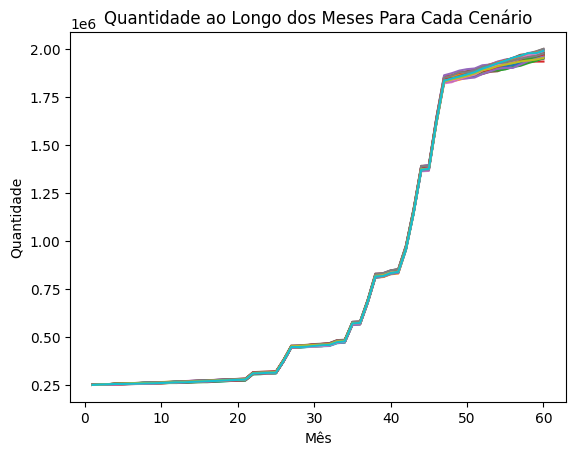

In [245]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [value(cvar_model.Q[i, t]) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Quantidade')
plt.title('Quantidade ao Longo dos Meses Para Cada Cenário')
plt.show()

### Gastos com Marketing

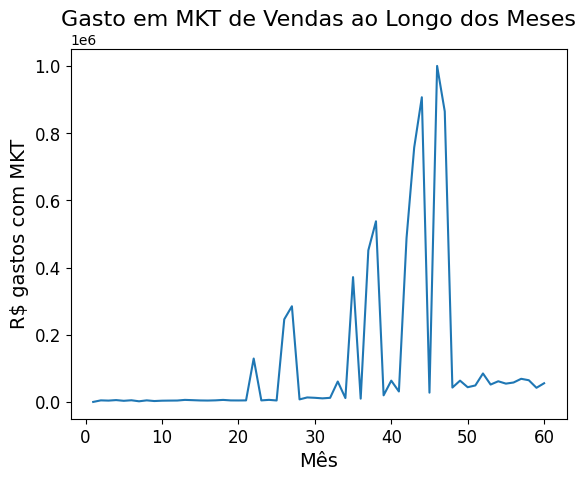

[10.0, 4630.875870727585, 3932.6701042712666, 5461.872977961439, 3326.1494838228828, 4951.24443104492, 1868.738200033932, 4661.346849322683, 2637.7928905483805, 3664.2223664667185, 3962.7558794446027, 4148.133153351413, 6045.011028783758, 5232.111844121662, 4383.115283471065, 4095.0963396714797, 4674.072997017639, 6005.946632308442, 4488.709829367987, 4368.338058443073, 4560.573703425335, 129207.10359242825, 4533.140227027785, 6156.675919735786, 4316.731254850323, 245932.34716178264, 284729.32313393126, 7524.087543391532, 13338.925936083499, 12264.55620926353, 10613.185641713702, 12205.352180048105, 60754.56953145672, 11493.951631505002, 371446.1134469727, 9738.731916797182, 451233.02697003074, 537559.1881484402, 19615.998192520055, 63334.230349251884, 31082.246462513667, 487781.9719047528, 756916.5235540682, 906760.6186284913, 27604.180851241756, 1000000.0, 864578.331747717, 42750.651565041444, 63345.49770083369, 43797.49293674342, 48997.84684832341, 84681.72723218778, 51710.076291377

In [246]:
import matplotlib.pyplot as plt

plt.plot(range(1, T+1), [cvar_model.M[t].value for t in range(1, T+1)])
plt.xlabel('Mês', fontsize=14)
plt.ylabel('R$ gastos com MKT', fontsize=14)
plt.title('Gasto em MKT de Vendas ao Longo dos Meses', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

print([cvar_model.M[t].value for t in range(1, T+1)])

### Quantidade de Fábricas

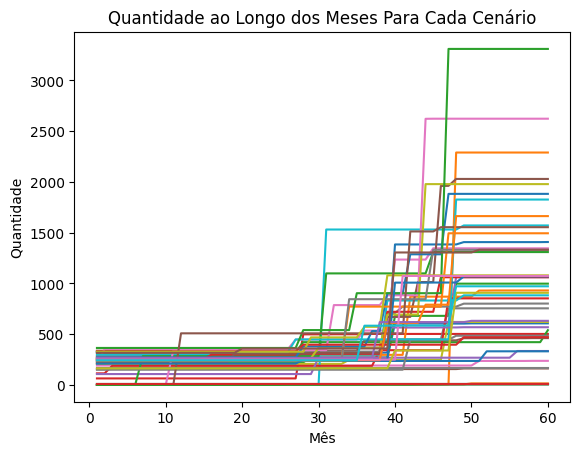

In [247]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [value(cvar_model.num_factories[i, t]) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Quantidade')
plt.title('Quantidade ao Longo dos Meses Para Cada Cenário')
plt.show()

VaR  = -61,541.60
CVaR = 941,829.11
Tail (VarDev>tol): 50 cenários -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]...
Tail (worst ceil(alpha*nS)): 5 cenários -> [43, 44, 40, 37, 19]


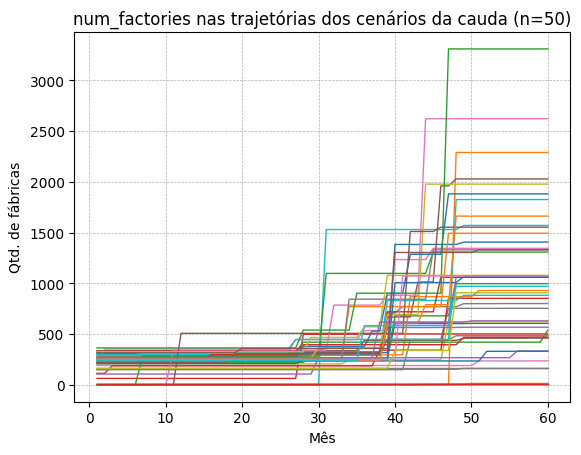

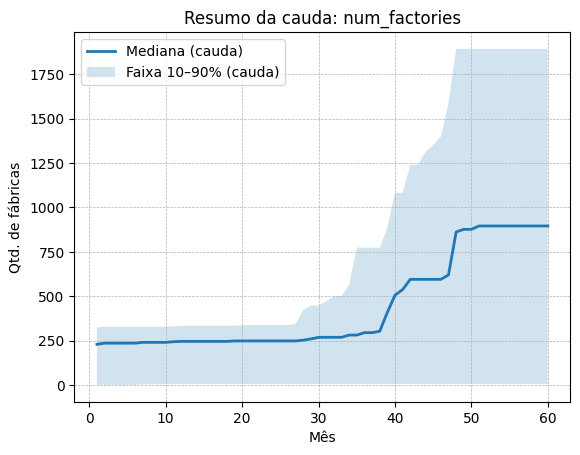

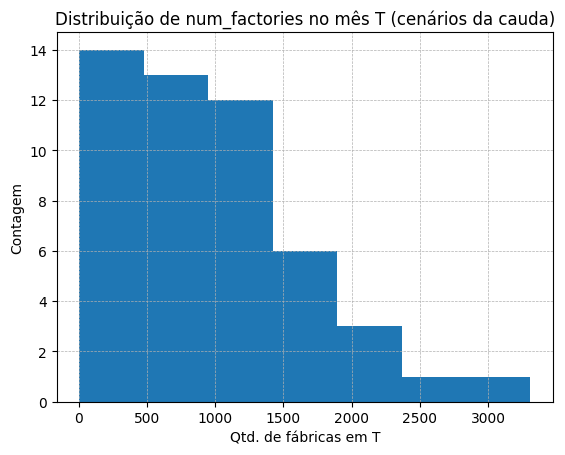

In [248]:
import numpy as np
import matplotlib.pyplot as plt
from pyomo.environ import value

# --- Config ---
alpha = 0.1  # o MESMO alpha usado no seu CVaR
T = 60
S = list(range(1, scenarios + 1))  # mesmo índice do seu modelo

# --- 1) Cenários na cauda pelo próprio CVaR (VarDev > 0) ---
tol = 1e-7
vardev = {i: value(cvar_model.VarDev[i]) for i in S}
tail_by_vardev = [i for i in S if vardev[i] > tol]

# --- 2) Cenários da pior fração alpha (rank por loss = -VALUATION_DISC) ---
loss = {i: -value(cvar_model.VALUATION_DISC[i]) for i in S}
nS = len(S)
k = int(np.ceil(alpha * nS))
tail_by_rank = sorted(S, key=lambda i: loss[i], reverse=True)[:k]

print(f"VaR  = {value(cvar_model.VaR):,.2f}")
print(f"CVaR = {value(cvar_model.CVaR):,.2f}")
print(f"Tail (VarDev>tol): {len(tail_by_vardev)} cenários -> {tail_by_vardev[:10]}{'...' if len(tail_by_vardev)>10 else ''}")
print(f"Tail (worst ceil(alpha*nS)): {len(tail_by_rank)} cenários -> {tail_by_rank[:10]}{'...' if len(tail_by_rank)>10 else ''}")

# Escolha qual cauda você quer plotar:
chosen = tail_by_vardev      # ou: chosen = tail_by_rank

# --- Extrai trajetórias de num_factories para os cenários escolhidos ---
months = np.arange(1, T + 1)
traj = np.array([[value(cvar_model.num_factories[i, t]) for t in range(1, T + 1)] for i in chosen])

# --- Plot A: "spaghetti plot" (todas as trajetórias da cauda) ---
plt.figure()
for row in traj:
    plt.plot(months, row, linewidth=1)
plt.title(f"num_factories nas trajetórias dos cenários da cauda (n={len(chosen)})")
plt.xlabel("Mês")
plt.ylabel("Qtd. de fábricas")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

# --- Plot B: resumo (mediana + faixa 10-90%) ---
plt.figure()
median = np.median(traj, axis=0)
p10 = np.percentile(traj, 10, axis=0)
p90 = np.percentile(traj, 90, axis=0)

plt.plot(months, median, linewidth=2, label="Mediana (cauda)")
plt.fill_between(months, p10, p90, alpha=0.2, label="Faixa 10–90% (cauda)")
plt.title("Resumo da cauda: num_factories")
plt.xlabel("Mês")
plt.ylabel("Qtd. de fábricas")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

# --- Plot C: distribuição no mês final (T) ---
final_factories = traj[:, -1]
plt.figure()
plt.hist(final_factories, bins=max(5, int(np.sqrt(len(final_factories)))))
plt.title("Distribuição de num_factories no mês T (cenários da cauda)")
plt.xlabel("Qtd. de fábricas em T")
plt.ylabel("Contagem")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()


## Receita por Período

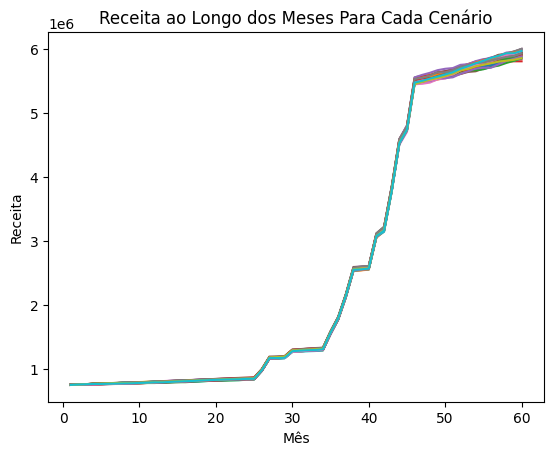

In [249]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [revenue_period(model, i, t) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Receita')
plt.title('Receita ao Longo dos Meses Para Cada Cenário')
plt.show()

## Lucro por Período

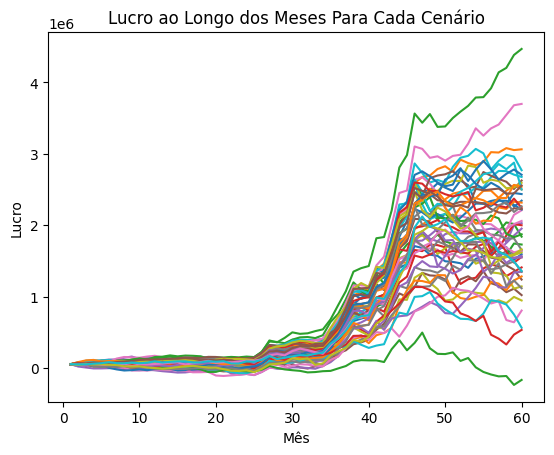

In [250]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [profit_period(model, i, t) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Lucro')
plt.title('Lucro ao Longo dos Meses Para Cada Cenário')
plt.show()

## Fluxo de Caixa Operacional por Período

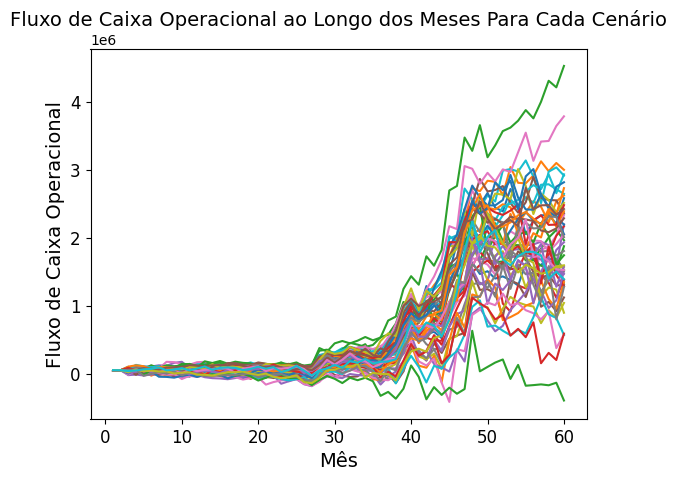

In [251]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [fco_period(model, i, t) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês', fontsize=14)
plt.ylabel('Fluxo de Caixa Operacional', fontsize=14)
plt.title('Fluxo de Caixa Operacional ao Longo dos Meses Para Cada Cenário', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

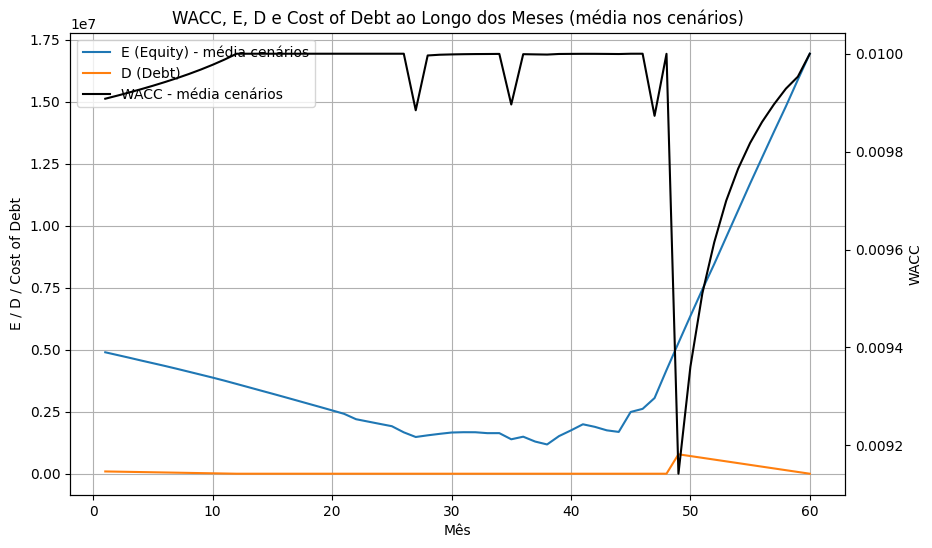

In [252]:
import matplotlib.pyplot as plt
from pyomo.environ import value

meses = range(1, T + 1)

# --- séries agregadas (média nos cenários) ---
wacc_series   = [sum(value(cvar_model.WACC[i, t]) for i in S) / len(S) for t in meses]
equity_series = [sum(value(cvar_model.E[i, t])    for i in S) / len(S) for t in meses]

# D é "decisão comum" (não depende do cenário)
debt_series   = [value(cvar_model.D[t]) for t in meses]

# (opcional) custo da dívida é Param por mês
cod_series    = [value(cvar_model.cost_of_debt[t]) for t in meses]

fig, ax1 = plt.subplots(figsize=(10, 6))

# E, D e cost_of_debt no eixo esquerdo
ax1.plot(meses, equity_series, label='E (Equity) - média cenários')
ax1.plot(meses, debt_series,   label='D (Debt)')
# ax1.plot(meses, cod_series,    label='Cost of Debt')
ax1.set_xlabel('Mês')
ax1.set_ylabel('E / D / Cost of Debt')
ax1.grid(True)

# WACC no eixo direito
ax2 = ax1.twinx()
ax2.plot(meses, wacc_series, label='WACC - média cenários', color='black')
ax2.set_ylabel('WACC')

# Legendas combinadas
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='best')

plt.title('WACC, E, D e Cost of Debt ao Longo dos Meses (média nos cenários)')
plt.show()


## Distribuição de FCO

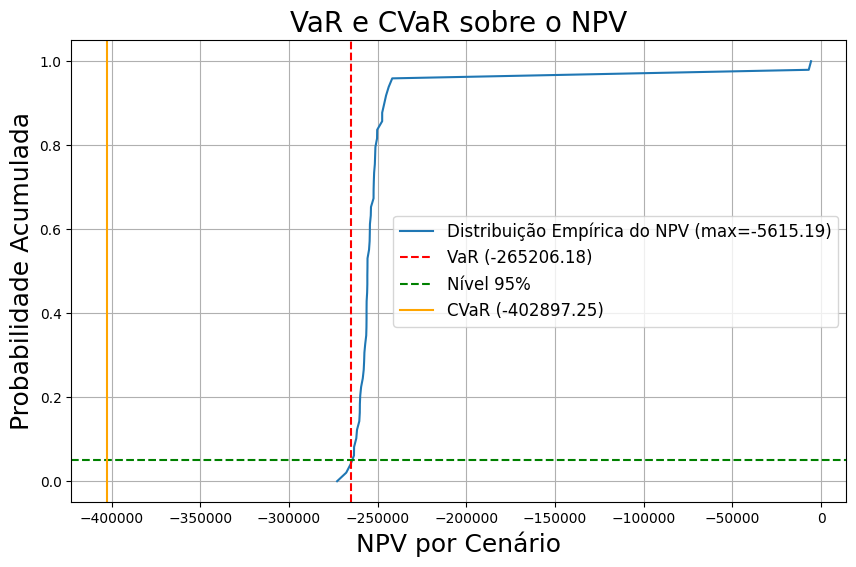

In [253]:
# ­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­
# NPV por cenário  (desconto a tax_rate = WACC ou GAMMA)
# ­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­
discount_rate = 1           # ou GAMMA, conforme deseje
npv_values = [
    sum(value(fcf_period_expression(model, i, t)) /
        (1 + discount_rate) ** t
        for t in range(1, T + 1))
    for i in S_range
]

# VaR e CVaR sobre NPV
alpha = 0.95
npv_sorted = sorted(npv_values)
var_value  = npv_sorted[int(len(npv_sorted) * (1 - alpha))]
cvar_value = (sum(v for v in npv_sorted if v <= var_value) /
              int(len(npv_sorted) * (1 - alpha)))

# ­­­­­­­­­ Plot
import matplotlib.pyplot as plt
import numpy as np

cum_probs = np.linspace(0, 1, len(npv_sorted))

plt.figure(figsize=(10, 6))
plt.plot(npv_sorted, cum_probs,
         label=f'Distribuição Empírica do NPV (max={round(max(npv_values),2)})')
plt.axvline(x=var_value,  color='red',   ls='--', label=f'VaR ({var_value:.2f})')
plt.axhline(y=1-alpha,    color='green', ls='--', label=f'Nível {alpha:.0%}')
plt.axvline(x=cvar_value, color='orange',ls='-',  label=f'CVaR ({cvar_value:.2f})')

plt.title('VaR e CVaR sobre o NPV', fontsize=20)
plt.xlabel('NPV por Cenário', fontsize=18)
plt.ylabel('Probabilidade Acumulada', fontsize=18)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()


## Iterando

In [255]:
from pyomo.environ import SolverFactory, value, Constraint, TerminationCondition

# ===============================================================
# LOOP CVaR (após: HiGHS inicial -> IPOPT inicial)
# Alterna:
#   A) HiGHS: minimiza CVaR linear (disc / VALUATION_DISC)
#   B) IPOPT: minimiza CVaR não-linear ((1+WACC)^t / VALUATION_NL)
# ===============================================================

m = cvar_model

solver_highs = SolverFactory("highs")
solver_ipopt = SolverFactory("ipopt")
solver_ipopt.options["obj_scaling_factor"] = 1e-6

# ---- helpers ----
def _clamp_wacc(w, lo=0.001, hi=0.99999):
    if w is None:
        w = 0.10
    w = float(w)
    if w < lo: w = lo
    if w > hi: w = hi
    return w

def _update_disc_from_current_wacc(mm):
    """Atualiza mm.disc usando WACC atual (clampado para respeitar wacc_positive)."""
    for i in S:
        for t in range(1, T + 1):
            w = _clamp_wacc(mm.WACC[i, t].value)
            # mantém coerência entre value e disc
            if mm.WACC[i, t].value is None:
                mm.WACC[i, t].set_value(w)
            mm.disc[i, t] = 1.0 / ((1.0 + w) ** t)

def _ensure_capital_positive_eps(mm, eps=1e2):
    """Cria (uma vez) capital_positive_eps e deixa pronta para ativar no IPOPT."""
    if not hasattr(mm, "capital_positive_eps"):
        mm.capital_positive_eps = Constraint(
            S, range(1, T + 1),
            rule=lambda mmm, i, t: mmm.E[i, t] + mmm.D[t] >= eps
        )
        mm.capital_positive_eps.deactivate()

def _project_repay_and_debt(mm):
    """Força Repay e D a ficarem consistentes com repay_schedule e debt_dyn (com Borrow atual)."""
    # Repay coerente com repay_schedule
    for t in range(1, T + 1):
        kmin = max(1, t - L_loan + 1)
        s = sum(value(mm.Borrow[k]) for k in range(kmin, t + 1))
        mm.Repay[t].set_value(value(mm.init_amort[t]) + (1.0 / L_loan) * s)

    # D coerente com debt_dyn
    for t in range(1, T + 1):
        if t == 1:
            mm.D[t].set_value(initial_debt + value(mm.Borrow[1]) - value(mm.Repay[1]))
        else:
            mm.D[t].set_value(value(mm.D[t - 1]) + value(mm.Borrow[t]) - value(mm.Repay[t]))

def _project_equity(mm):
    """Projeta E para satisfazer equity_dyn exatamente, usando Interest baseado em D_prev."""
    def interest0(tt):
        D_prev = initial_debt if tt == 1 else value(mm.D[tt - 1])
        return value(mm.cost_of_debt[tt]) * D_prev

    for i in S:
        E_prev = initial_equity
        for t in range(1, T + 1):
            receita = value(mm.P) * value(mm.Q[i, t])
            dep = (value(mm.price_of_factory) / factory_lifetime) * value(mm.num_factories[i, t])

            ebit = (
                receita
                - value(mm.variable_cost_percentage[i, t]) * receita
                - value(mm.variable_expenses_percentage) * receita
                - value(mm.M[t])
                - value(mm.taxes_percentage) * receita
                - value(mm.fix_costs)
                - value(mm.fix_expenses)
                - dep
            )
            ni = ebit - interest0(t)
            E_now = E_prev + ni
            mm.E[i, t].set_value(E_now)
            E_prev = E_now

def _seed_cvar_nl_from_linear(mm):
    """Seed do NL a partir do linear, se existir."""
    if hasattr(mm, "VaR") and hasattr(mm, "VaR_nl") and (mm.VaR.value is not None) and (mm.VaR_nl.value is None):
        mm.VaR_nl.set_value(value(mm.VaR))
    if hasattr(mm, "CVaR") and hasattr(mm, "CVaR_nl") and (mm.CVaR.value is not None) and (mm.CVaR_nl.value is None):
        mm.CVaR_nl.set_value(value(mm.CVaR))
    if hasattr(mm, "VarDev") and hasattr(mm, "VarDev_nl"):
        for i in S:
            if mm.VarDev[i].value is not None and mm.VarDev_nl[i].value is None:
                mm.VarDev_nl[i].set_value(value(mm.VarDev[i]))

def _safe_solve(solver, model, tee=False):
    """
    Resolve sem quebrar em NoFeasibleSolutionError.
    Se houver solução (ótima/feasible), carrega manualmente.
    """
    res = solver.solve(model, tee=tee, load_solutions=False)
    tc = res.solver.termination_condition

    ok = tc in (
        TerminationCondition.optimal,
        TerminationCondition.locallyOptimal,
        TerminationCondition.feasible,
        TerminationCondition.maxTimeLimit,
    )
    if ok and len(res.solution) > 0:
        model.solutions.load_from(res)
        return res, True

    return res, False

def _prep_highs_block(mm, fix_financing=True):
    """
    HiGHS (CVaR linear):
    - ativa obj_cvar_highs; desativa obj_cvar_ipopt e demais objetivos
    - CVaR linear ON; CVaR NL OFF
    - wacc_def OFF; WACC FIXO (clamp); disc atualizado
    - (opcional) financiamento FIXO (Borrow/Repay/D) projetado
    - operação LIVRE; restrições ON
    """
    # objetivos
    for name in ["obj_highs", "obj_ipopt", "obj_cvar_ipopt"]:
        if hasattr(mm, name): getattr(mm, name).deactivate()
    if hasattr(mm, "obj_cvar_highs"): mm.obj_cvar_highs.activate()

    # CVaR linear ON / NL OFF
    if hasattr(mm, "vardev_constraint"): mm.vardev_constraint.activate()
    if hasattr(mm, "cvar_constraint"):   mm.cvar_constraint.activate()
    if hasattr(mm, "vardev_nl_constraint"): mm.vardev_nl_constraint.deactivate()
    if hasattr(mm, "cvar_nl_constraint"):   mm.cvar_nl_constraint.deactivate()

    # linearidade WACC
    if hasattr(mm, "wacc_def"): mm.wacc_def.deactivate()

    # capital positivity (original ON / eps OFF)
    _ensure_capital_positive_eps(mm)
    if hasattr(mm, "capital_positive_eps"): mm.capital_positive_eps.deactivate()
    if hasattr(mm, "capital_positive"):     mm.capital_positive.activate()

    # restrições de operação ON
    for cname in ["qty_increment", "growth", "non_regression",
                  "production_capacity_constraint", "capex_aquisi_constraint"]:
        if hasattr(mm, cname): getattr(mm, cname).activate()

    # operação livre
    for t in range(2, T + 1):
        if mm.M[t].fixed: mm.M[t].unfix()
    for i in S:
        for t in range(2, T + 1):
            if mm.Q[i, t].fixed: mm.Q[i, t].unfix()
    for i in S:
        for t in range(1, T + 1):
            if mm.num_factories[i, t].fixed: mm.num_factories[i, t].unfix()

    # WACC fixo (clamp) + disc atualizado
    _update_disc_from_current_wacc(mm)
    for i in S:
        for t in range(1, T + 1):
            w = _clamp_wacc(mm.WACC[i, t].value)
            mm.WACC[i, t].set_value(w)
            mm.WACC[i, t].fix(w)

    # financiamento: projeta e fixa (ou libera se fix_financing=False)
    if fix_financing:
        # garante coerência antes de fixar
        _project_repay_and_debt(mm)
        for t in range(1, T + 1):
            mm.Borrow[t].fix(max(0.0, value(mm.Borrow[t])))
            mm.Repay[t].fix(max(0.0, value(mm.Repay[t])))
            mm.D[t].fix(max(0.0, value(mm.D[t])))
    else:
        for t in range(1, T + 1):
            if mm.Borrow[t].fixed: mm.Borrow[t].unfix()
            if mm.Repay[t].fixed:  mm.Repay[t].unfix()
            if mm.D[t].fixed:      mm.D[t].unfix()

def _prep_ipopt_block(mm):
    """
    IPOPT (CVaR NL):
    - ativa obj_cvar_ipopt; desativa obj_cvar_highs e demais objetivos
    - CVaR NL ON; CVaR linear OFF
    - operação FIXA
    - libera financiamento e WACC/E
    - ativa wacc_def e capital_positive_eps
    - desativa restrições que definem Q
    - projeta para factibilidade (Repay/D/E) antes do solve
    """
    # objetivos
    for name in ["obj_highs", "obj_ipopt", "obj_cvar_highs"]:
        if hasattr(mm, name): getattr(mm, name).deactivate()
    if hasattr(mm, "obj_cvar_ipopt"): mm.obj_cvar_ipopt.activate()

    # CVaR NL ON / linear OFF
    if hasattr(mm, "vardev_nl_constraint"): mm.vardev_nl_constraint.activate()
    if hasattr(mm, "cvar_nl_constraint"):   mm.cvar_nl_constraint.activate()
    if hasattr(mm, "vardev_constraint"): mm.vardev_constraint.deactivate()
    if hasattr(mm, "cvar_constraint"):   mm.cvar_constraint.deactivate()

    # operação fixa
    for t in range(1, T + 1):
        mm.M[t].fix(value(mm.M[t]))
    for i in S:
        for t in range(1, T + 1):
            qv = mm.Q[i, t].value
            if qv is None:
                qv = value(mm.initial_quantity)
                mm.Q[i, t].set_value(qv)
            mm.Q[i, t].fix(qv if qv >= 250_000 else 250_000)

            fv = mm.num_factories[i, t].value
            if fv is None:
                fv = value(mm.initial_factories)
                mm.num_factories[i, t].set_value(fv)
            mm.num_factories[i, t].fix(int(round(fv)))

    # evita TOO_FEW_DOF
    for cname in ["qty_increment", "growth", "non_regression",
                  "production_capacity_constraint", "capex_aquisi_constraint"]:
        if hasattr(mm, cname): getattr(mm, cname).deactivate()

    # ativa bilinearidade do WACC
    if hasattr(mm, "wacc_def"): mm.wacc_def.activate()

    # capital > 0 (eps)
    _ensure_capital_positive_eps(mm)
    if hasattr(mm, "capital_positive"):     mm.capital_positive.deactivate()
    if hasattr(mm, "capital_positive_eps"): mm.capital_positive_eps.activate()

    # libera financiamento e WACC/E
    for t in range(1, T + 1):
        if mm.Borrow[t].fixed: mm.Borrow[t].unfix()
        if mm.Repay[t].fixed:  mm.Repay[t].unfix()
        if mm.D[t].fixed:      mm.D[t].unfix()
    for i in S:
        for t in range(1, T + 1):
            if mm.WACC[i, t].fixed: mm.WACC[i, t].unfix()
            if mm.E[i, t].fixed:    mm.E[i, t].unfix()

    # seeds + projeção factível
    _seed_cvar_nl_from_linear(mm)
    _project_repay_and_debt(mm)
    _project_equity(mm)

# ---- loop ----
n_iter = 10
hist = []
prev_cvar_nl = None

for it in range(1, n_iter + 1):
    print(f"\n================ Iteração {it}/{n_iter} ================")

    # A) HiGHS (CVaR linear) - tenta com financiamento FIXO
    _prep_highs_block(m, fix_financing=True)
    res_h, ok_h = _safe_solve(solver_highs, m, tee=False)

    if not ok_h:
        tc = res_h.solver.termination_condition
        print(f"[HiGHS]  sem solução factível com financiamento FIXO. termination={tc}. Tentando fallback (financiamento LIVRE)...")

        # fallback: libera financiamento só para recuperar factibilidade
        _prep_highs_block(m, fix_financing=False)
        res_h, ok_h = _safe_solve(solver_highs, m, tee=False)

        if not ok_h:
            tc2 = res_h.solver.termination_condition
            print(f"[HiGHS]  fallback também falhou. termination={tc2}. Encerrando loop.")
            break

    cvar_h = value(m.CVaR)
    var_h  = value(m.VaR)
    print(f"[HiGHS]  CVaR(disc) = {cvar_h:.6f} | VaR(disc) = {var_h:.6f}")

    # B) IPOPT (CVaR não-linear)
    _prep_ipopt_block(m)
    res_n, ok_n = _safe_solve(solver_ipopt, m, tee=False)

    if not ok_n:
        tc = res_n.solver.termination_condition
        print(f"[IPOPT] sem solução factível/ótima. termination={tc}. Encerrando loop.")
        break

    cvar_nl = value(m.CVaR_nl)
    var_nl  = value(m.VaR_nl)
    print(f"[IPOPT]  CVaR(NL)   = {cvar_nl:.6f} | VaR(NL)   = {var_nl:.6f}")

    hist.append((it, cvar_h, cvar_nl, var_h, var_nl))

    # parada: estabilização do CVaR_nl
    if prev_cvar_nl is not None and abs(cvar_nl - prev_cvar_nl) < 1e-3:
        break
    prev_cvar_nl = cvar_nl

print("\nLoop concluído. (it, CVaR_highs, CVaR_ipopt, VaR_highs, VaR_ipopt):")
for row in hist:
    print(row)



================ Iteração 1/10 ================


KeyboardInterrupt: 


=== Expected NPV (objetivo do Problema 1) ===
Problema (1) na própria solução: 127,524.8240
Problema (1) avaliado na solução do (2): 62,301.4670

=== CVaR empírico das perdas (loss = -NPV) ===
(1) VaR_emp(0.10)=-62,636.0588 | CVaR_emp(0.10)=-42,486.1896
(2) VaR_emp(0.10)=-62,650.3840 | CVaR_emp(0.10)=-42,499.3301

=== CVaR reportado pelo Problema (2) (variáveis do modelo) ===
VaR (modelo 2):  -62,650.3840
CVaR (modelo 2): -42,499.3301
Obs: o CVaR do modelo (2) deve ficar muito próximo do CVaR empírico se a formulação e solução estiverem consistentes.

=== Cauda no (2) ===
Tail por VarDev>0 (modelo 2): [37, 40, 43, 44]
Tail por pior 5 cenários (empírico): [43, 44, 40, 37, 19]

=== Top cenários por pior perda (solução do 2) ===
 scenario         NPV_1        NPV_2         loss_1        loss_2     VarDev_2  tail_emp_1  tail_emp_2  tail_vardev_2
       43  -5123.712188 -5124.671700    5123.712188   5124.671700 67775.055679       False       False           True
       44  44204.824326 441

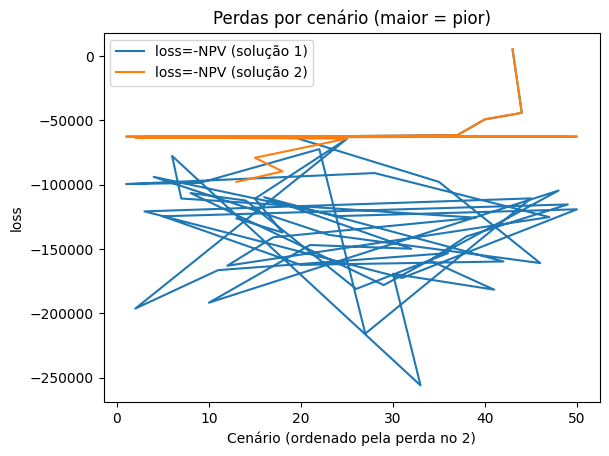


=== Plotando FCF/FCO para cenários na cauda (pior alpha%) do (2) ===


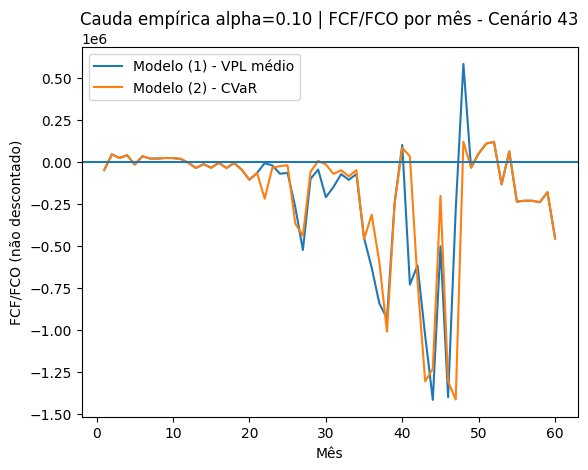

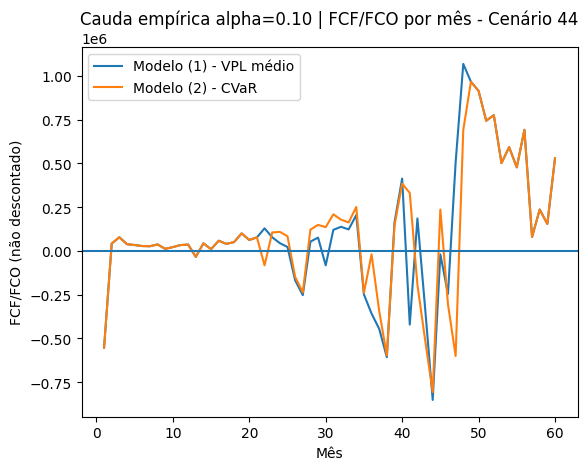

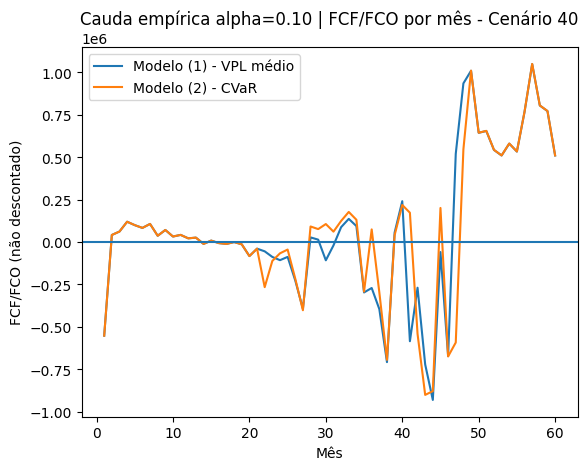

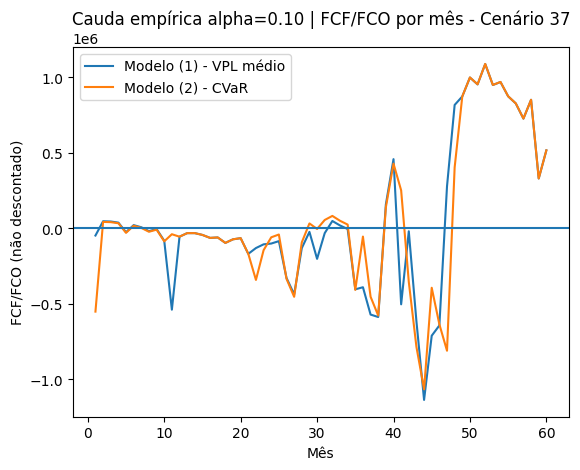

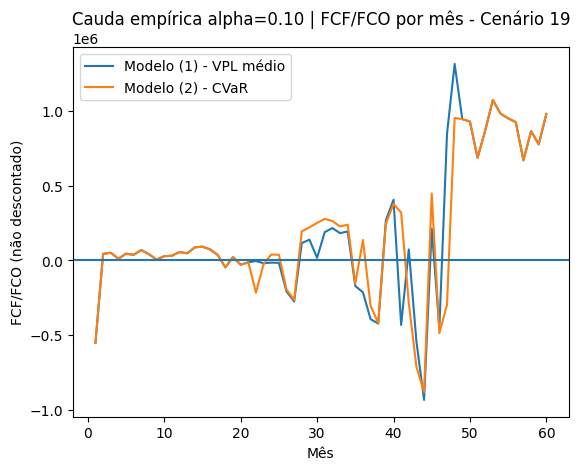

In [226]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyomo.environ import value

# ============================================================
# CONFIG: garanta que estes nomes existem no seu namespace
# - model       -> problema (1)
# - cvar_model  -> problema (2)
# - T, scenarios, months_future_FCO, alpha (se quiser)
# ============================================================

EPS = 1e-8

# Se alpha não existir no seu escopo, defina aqui:
try:
    alpha
except NameError:
    alpha = 0.1

# Janela (igual ao seu código)
T_local = 60  # ajuste se seu T for diferente
t_final = T_local
t_ini = t_final - months_future_FCO + 1

S_list = list(range(1, scenarios + 1))
nS = len(S_list)
k_tail = int(math.ceil(alpha * nS))  # nº cenários na cauda (pior alpha%)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def safe_value(x):
    """value() robusto para Var/Param/Expression; retorna np.nan se der ruim."""
    try:
        v = value(x)
        if v is None:
            return np.nan
        return float(v)
    except Exception:
        return np.nan


def valuation_disc_generic(m, i, t_ini, t_final):
    """
    NPV/Valuation descontado por cenário:
      sum_t FCF(i,t) * disc(i,t)
    Assumindo que m.disc existe e fcf_period_expression está no escopo.
    """
    return sum(safe_value(fcf_period_expression(m, i, t) * m.disc[i, t])
               for t in range(t_ini, t_final + 1))


def expected_npv_generic(m, S_list, t_ini, t_final):
    vals = [valuation_disc_generic(m, i, t_ini, t_final) for i in S_list]
    return float(np.mean(vals)), np.array(vals, dtype=float)


def empirical_cvar_from_losses(losses, alpha):
    """
    CVaR empírico (média das piores alpha% perdas).
    losses: array (maior = pior)
    """
    n = len(losses)
    k = int(math.ceil(alpha * n))
    idx_sorted = np.argsort(-losses)  # desc (pior primeiro)
    tail_idx = idx_sorted[:k]
    var_emp = losses[idx_sorted[k-1]]  # VaR "discreto"
    cvar_emp = float(np.mean(losses[tail_idx]))
    return var_emp, cvar_emp, tail_idx


def fcf_timeseries(m, i, t1=1, t2=60):
    """Retorna FCF por período (lista) para um cenário i."""
    return np.array([safe_value(fcf_period_expression(m, i, t)) for t in range(t1, t2 + 1)], dtype=float)


def plot_fcf_for_scenarios(model_a, model_b, scen_ids, title_prefix="", t1=1, t2=60):
    """
    Plota 1 gráfico por cenário (sem subplots) comparando FCF do (1) vs (2).
    """
    for i in scen_ids:
        f1 = fcf_timeseries(model_a, i, t1, t2)
        f2 = fcf_timeseries(model_b, i, t1, t2)

        plt.figure()
        plt.plot(range(t1, t2 + 1), f1, label="Modelo (1) - VPL médio")
        plt.plot(range(t1, t2 + 1), f2, label="Modelo (2) - CVaR")
        plt.axhline(0.0)
        plt.title(f"{title_prefix} FCF/FCO por mês - Cenário {i}")
        plt.xlabel("Mês")
        plt.ylabel("FCF/FCO (não descontado)")
        plt.legend()
        plt.show()


# ============================================================
# (A) OBJETIVO DO PROBLEMA (1) APLICADO EM (1) E EM (2)
# ============================================================
npv_mean_1, npv_by_s_1 = expected_npv_generic(model, S_list, t_ini, t_final)
npv_mean_2, npv_by_s_2 = expected_npv_generic(cvar_model, S_list, t_ini, t_final)

print("\n=== Expected NPV (objetivo do Problema 1) ===")
print(f"Problema (1) na própria solução: {npv_mean_1:,.4f}")
print(f"Problema (1) avaliado na solução do (2): {npv_mean_2:,.4f}")

# ============================================================
# (B) CVaR EMPÍRICO (PERDAS) APLICADO EM (1) E EM (2)
#     loss[i] = - NPV[i]
# ============================================================
loss_1 = -npv_by_s_1
loss_2 = -npv_by_s_2

var_emp_1, cvar_emp_1, tail_idx_1 = empirical_cvar_from_losses(loss_1, alpha)
var_emp_2, cvar_emp_2, tail_idx_2 = empirical_cvar_from_losses(loss_2, alpha)

print("\n=== CVaR empírico das perdas (loss = -NPV) ===")
print(f"(1) VaR_emp({alpha:.2f})={var_emp_1:,.4f} | CVaR_emp({alpha:.2f})={cvar_emp_1:,.4f}")
print(f"(2) VaR_emp({alpha:.2f})={var_emp_2:,.4f} | CVaR_emp({alpha:.2f})={cvar_emp_2:,.4f}")

# Também compara com o CVaR "do modelo" (variável otimizada no (2))
cvar_model_CVaR = safe_value(cvar_model.CVaR)
cvar_model_VaR  = safe_value(cvar_model.VaR)

print("\n=== CVaR reportado pelo Problema (2) (variáveis do modelo) ===")
print(f"VaR (modelo 2):  {cvar_model_VaR:,.4f}")
print(f"CVaR (modelo 2): {cvar_model_CVaR:,.4f}")
print("Obs: o CVaR do modelo (2) deve ficar muito próximo do CVaR empírico se a formulação e solução estiverem consistentes.")

# ============================================================
# (C) Identificar cenários que entraram na cauda (2)
#     - via VarDev (cenários com VarDev > 0 implicam loss > VaR)
#     - via pior alpha% empírico
# ============================================================
vardev_2 = np.array([safe_value(cvar_model.VarDev[i]) for i in S_list], dtype=float)

tail_by_vardev = [i for i in S_list if (not np.isnan(vardev_2[i-1])) and (vardev_2[i-1] > 1e-6)]
tail_by_emp_2 = [S_list[j] for j in tail_idx_2]  # pior alpha% empírico no (2)

print("\n=== Cauda no (2) ===")
print(f"Tail por VarDev>0 (modelo 2): {tail_by_vardev}")
print(f"Tail por pior {k_tail} cenários (empírico): {tail_by_emp_2}")

# ============================================================
# (D) Tabela comparativa por cenário: NPV, loss, VarDev, flags
# ============================================================
df = pd.DataFrame({
    "scenario": S_list,
    "NPV_1": npv_by_s_1,
    "NPV_2": npv_by_s_2,
    "loss_1": loss_1,
    "loss_2": loss_2,
    "VarDev_2": vardev_2,
})

df["tail_emp_1"] = False
df.loc[[S_list[j] for j in tail_idx_1], "tail_emp_1"] = True

df["tail_emp_2"] = False
df.loc[[S_list[j] for j in tail_idx_2], "tail_emp_2"] = True

df["tail_vardev_2"] = df["VarDev_2"] > 1e-6

# Ordena por pior loss_2 (pior primeiro)
df_sorted = df.sort_values("loss_2", ascending=False).reset_index(drop=True)

print("\n=== Top cenários por pior perda (solução do 2) ===")
print(df_sorted.head(max(10, k_tail)).to_string(index=False))

# (opcional) exportar
# df_sorted.to_csv("debug_cvar_vs_expectednpv.csv", index=False)

# ============================================================
# (E) Gráficos
#   1) Barras de loss por cenário (1 vs 2)
#   2) FCF/FCO por mês para cenários na cauda (pior alpha%) do (2)
# ============================================================

# 1) Gráfico de perdas
plt.figure()
plt.plot(df_sorted["scenario"], df_sorted["loss_1"], label="loss=-NPV (solução 1)")
plt.plot(df_sorted["scenario"], df_sorted["loss_2"], label="loss=-NPV (solução 2)")
plt.title("Perdas por cenário (maior = pior)")
plt.xlabel("Cenário (ordenado pela perda no 2)")
plt.ylabel("loss")
plt.legend()
plt.show()

# 2) Plota FCF/FCO por mês para os piores cenários (empírico) na solução do (2)
print("\n=== Plotando FCF/FCO para cenários na cauda (pior alpha%) do (2) ===")
plot_fcf_for_scenarios(
    model_a=model,
    model_b=cvar_model,
    scen_ids=tail_by_emp_2,
    title_prefix=f"Cauda empírica alpha={alpha:.2f} |",
    t1=1, t2=T_local
)


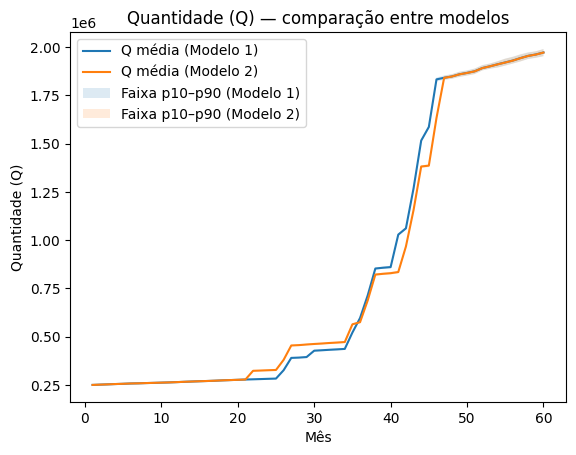

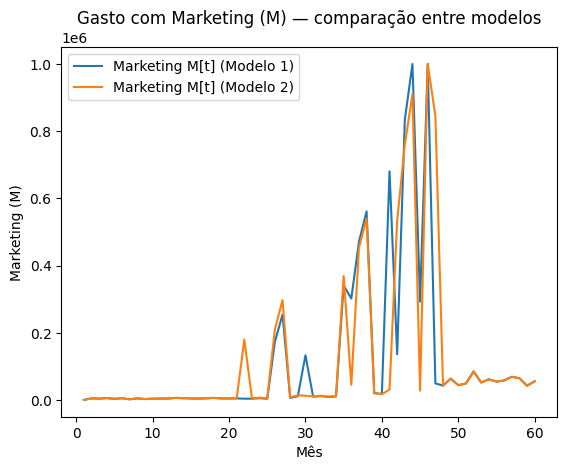

In [227]:
import numpy as np
import matplotlib.pyplot as plt
from pyomo.environ import value

# Ajuste se necessário (ou reaproveite do seu código)
T_local = 60
S_list = list(range(1, scenarios + 1))

def safe_value(x):
    try:
        v = value(x)
        return float(v) if v is not None else np.nan
    except Exception:
        return np.nan

def get_Q_matrix(m, S_list, T):
    """Retorna matriz (nS x T) com Q[i,t]."""
    Q = np.zeros((len(S_list), T), dtype=float)
    for si, i in enumerate(S_list):
        for t in range(1, T + 1):
            Q[si, t-1] = safe_value(m.Q[i, t])
    return Q

def get_M_series(m, T):
    """Retorna vetor (T,) com M[t]."""
    M = np.zeros(T, dtype=float)
    for t in range(1, T + 1):
        M[t-1] = safe_value(m.M[t])
    return M

# =========================
# 1) Quantidade (Q): média e faixa p10-p90
# =========================
Q1 = get_Q_matrix(model, S_list, T_local)
Q2 = get_Q_matrix(cvar_model, S_list, T_local)

q1_mean = np.nanmean(Q1, axis=0)
q2_mean = np.nanmean(Q2, axis=0)

q1_p10 = np.nanpercentile(Q1, 10, axis=0)
q1_p90 = np.nanpercentile(Q1, 90, axis=0)

q2_p10 = np.nanpercentile(Q2, 10, axis=0)
q2_p90 = np.nanpercentile(Q2, 90, axis=0)

months = np.arange(1, T_local + 1)

plt.figure()
plt.plot(months, q1_mean, label="Q média (Modelo 1)")
plt.plot(months, q2_mean, label="Q média (Modelo 2)")
plt.fill_between(months, q1_p10, q1_p90, alpha=0.15, label="Faixa p10–p90 (Modelo 1)")
plt.fill_between(months, q2_p10, q2_p90, alpha=0.15, label="Faixa p10–p90 (Modelo 2)")
plt.title("Quantidade (Q) — comparação entre modelos")
plt.xlabel("Mês")
plt.ylabel("Quantidade (Q)")
plt.legend()
plt.show()

# =========================
# 2) Marketing (M): série mensal
# =========================
M1 = get_M_series(model, T_local)
M2 = get_M_series(cvar_model, T_local)

plt.figure()
plt.plot(months, M1, label="Marketing M[t] (Modelo 1)")
plt.plot(months, M2, label="Marketing M[t] (Modelo 2)")
plt.title("Gasto com Marketing (M) — comparação entre modelos")
plt.xlabel("Mês")
plt.ylabel("Marketing (M)")
plt.legend()
plt.show()


In [228]:
from pyomo.environ import value
import numpy as np

def recompute_npv(m, i, t_ini, t_final):
    return sum(value(fcf_period_expression(m, i, t) * m.disc[i, t])
               for t in range(t_ini, t_final+1))

# escolha uns cenários que deram problema
check_scen = [43, 44, 40, 37, 19]

for i in check_scen:
    npv_internal = value(cvar_model.VALUATION_DISC[i])
    npv_recomp   = recompute_npv(cvar_model, i, t_ini, t_final)
    print(i, "NPV_internal=", npv_internal, "NPV_recomputed=", npv_recomp,
          "diff=", npv_recomp - npv_internal)

print("VaR=", value(cvar_model.VaR), "CVaR=", value(cvar_model.CVaR))


43 NPV_internal= -5124.671699821147 NPV_recomputed= -5124.671699821147 diff= 0.0
44 NPV_internal= 44185.571652246144 NPV_recomputed= 44185.571652246144 diff= 0.0
40 NPV_internal= 49258.69654417102 NPV_recomputed= 49258.69654417102 diff= 0.0
37 NPV_internal= 61526.670078632334 NPV_recomputed= 61526.670078632334 diff= 0.0
19 NPV_internal= 62650.38397959943 NPV_recomputed= 62650.38397959943 diff= 0.0
VaR= -62650.38397959941 CVaR= -42499.33011096553


In [229]:
from pyomo.environ import value
import numpy as np

S_list = list(range(1, scenarios+1))

VaR = value(cvar_model.VaR)

viol = []
for i in S_list:
    lhs = (-value(cvar_model.VALUATION_DISC[i]) - VaR)   # loss - VaR
    rhs = value(cvar_model.VarDev[i])
    viol.append(lhs - rhs)

print("max(lhs-rhs) =", np.max(viol))
print("cenário do pior =", S_list[int(np.argmax(viol))])



max(lhs-rhs) = 7.275957614183426e-12
cenário do pior = 44


# Criação da Fronteira Pareto - Problema Multi-objetivo

In [328]:
from pyomo.environ import *
from pyomo.environ import value

# ---------------------------------------------------------------
# 0) cria o modelo e define horizonte
# ---------------------------------------------------------------
multi_model = ConcreteModel()
T = 60
S = range(1, scenarios + 1)     # conjunto de cenários

# ---------------------------------------------------------------
# 1) variáveis / parâmetros básicos
# ---------------------------------------------------------------
multi_model.P = Param(initialize=P_min)

multi_model.Q = Var(S, range(1, T+1),
              bounds=(Q_min, 2*Q_max), within=NonNegativeReals)

M_MAX = 1e6
multi_model.M = Var(range(1, T+1),
              bounds=(0, M_MAX), within=NonNegativeReals)

multi_model.a_inc = Param(initialize=a_inc)
multi_model.b_inc = Param(initialize=b_inc)
multi_model.Increment = Expression(
    range(1, T+1), rule=lambda m, t: m.a_inc * m.M[t] + m.b_inc
)

# Variável de Quantidade de fábricas (uma inteira)
multi_model.num_factories = Var(S, range(1, T+1), within=NonNegativeIntegers)

# ---------------------------------------------------------------
# 2) custos, despesas, impostos
# ---------------------------------------------------------------
multi_model.variable_expenses_percentage = Param(initialize=variable_expenses_percentage)
multi_model.taxes_percentage             = Param(initialize=taxes_percentage)
multi_model.fix_costs                    = Param(initialize=CF)
multi_model.fix_expenses                 = Param(initialize=DF)

multi_model.variable_cost_percentage = Param(
    S, range(1, T+1),
    initialize=lambda m, i, t: scenarios_data[i-1][t-1],
    mutable=True
)

# churn rate (cenário x mês)
multi_model.churn_rate = Param(
    range(1, scenarios+1), range(1, T+1),
    initialize=lambda m, i, t: churn_data[i-1][t-1]
)

# ---------------------------------------------------------------
# 3) demanda e parâmetros diversos
# ---------------------------------------------------------------
multi_model.a = Param(initialize=a)
multi_model.b = Param(initialize=b)

multi_model.initial_quantity = Param(initialize=inital_sales)
for i in S:
    multi_model.Q[i, 1].fix(multi_model.initial_quantity)

multi_model.initial_mkt = Param(initialize=10)
multi_model.M[1].fix(multi_model.initial_mkt)

# ---------------------------------------------------------------
# 4) parâmetros de NCG
# ---------------------------------------------------------------
multi_model.theta_AR           = Param(initialize=theta_AR)
multi_model.theta_I            = Param(initialize=theta_I)
multi_model.theta_AP           = Param(initialize=theta_AP)
multi_model.initial_NCG        = Param(initialize=initial_NCG)
multi_model.initial_investment = Param(initialize=initial_inventory)

# ---------------------------------------------------------------
# 5) expressões auxiliares (iguais ao seu estocástico)
# ---------------------------------------------------------------
def revenue_rule(m, i, t):
    return m.P * m.Q[i, t]

def depreciation_rule(m, i, t):
    return (price_of_factory / factory_lifetime) * m.num_factories[i, t]

multi_model.initial_factories = Param(initialize=Q_min // production_capacity, mutable=False)
multi_model.price_of_factory = Param(initialize=price_of_factory, mutable=False)

def difference_on_factories_rule(m, i, t):
    prev = m.num_factories[i, t-1] if t > 1 else m.initial_factories
    return m.num_factories[i, t] - prev

def capex_aquisi_rule(m, i, t):
    return m.price_of_factory * difference_on_factories_rule(m, i, t)

def AR_rule(m, i, t):
    return revenue_rule(m, i, t) * m.theta_AR

def I_rule(m, i, t):
    return m.variable_cost_percentage[i, t] * revenue_rule(m, i, t) * m.theta_I

def AP_rule(m, i, t):
    prev_I = I_rule(m, i, t-1) if t > 1 else m.initial_investment
    return (I_rule(m, i, t)
            + m.variable_cost_percentage[i, t] * revenue_rule(m, i, t)
            - prev_I) * m.theta_AP

def NCG_rule(m, i, t):
    prev = (AR_rule(m, i, t-1) + I_rule(m, i, t-1) - AP_rule(m, i, t-1)
            if t > 1 else m.initial_NCG)
    return AR_rule(m, i, t) + I_rule(m, i, t) - AP_rule(m, i, t) - prev

def fcf_period_expression(m, i, t):
    receita = revenue_rule(m, i, t)
    depreciation = depreciation_rule(m, i, t)
    capex_aquisi = capex_aquisi_rule(m, i, t)
    return (receita
            - m.variable_cost_percentage[i, t] * receita
            - m.variable_expenses_percentage  * receita
            - m.M[t]
            - m.taxes_percentage * receita
            - m.fix_costs - m.fix_expenses
            - depreciation
            - capex_aquisi
            - NCG_rule(m, i, t))

# ===============================================================
# 6) FINANCIAMENTO + E/D/WACC dinâmico
# ===============================================================

# Fixar custo da dívida (exógeno) por mês
multi_model.cost_of_debt = Param(range(1, T+1), initialize=lambda m, t: initial_cost_of_debt)

# WACC: parâmetros
multi_model.cost_of_equity = Param(initialize=cost_of_equity)
multi_model.tax_rate       = Param(initialize=tax_rate)

# --- dívida (decisão comum a todos os cenários)
multi_model.D = Var(range(1, T+1), bounds=(0, D_max), within=NonNegativeReals, initialize=initial_debt)
multi_model.Borrow = Var(range(1, T+1), bounds=(0, Borrow_max), within=NonNegativeReals, initialize=0.0)
multi_model.Repay  = Var(range(1, T+1), bounds=(0, 10e9), within=NonNegativeReals, initialize=0.0)

# Amortização do estoque inicial (linear em L_loan meses)
def init_amort_rule(m, t):
    return initial_debt / L_loan if t <= L_loan else 0.0
multi_model.init_amort = Param(range(1, T+1), initialize=init_amort_rule, mutable=False)

# Amortização das novas tomadas
def repay_schedule_rule(m, t):
    s = 0.0
    kmin = max(1, t - L_loan + 1)
    for k in range(kmin, t+1):
        s += m.Borrow[k]
    return m.Repay[t] == m.init_amort[t] + (1.0 / L_loan) * s
multi_model.repay_schedule = Constraint(range(1, T+1), rule=repay_schedule_rule)

# Dinâmica do estoque de dívida
def debt_dyn_rule(m, t):
    if t == 1:
        return m.D[1] == initial_debt + m.Borrow[1] - m.Repay[1]
    return m.D[t] == m.D[t-1] + m.Borrow[t] - m.Repay[t]
multi_model.debt_dyn = Constraint(range(1, T+1), rule=debt_dyn_rule)

# Juros
def interest_rule(m, t):
    D_prev = initial_debt if t == 1 else m.D[t-1]
    return m.cost_of_debt[t] * D_prev
multi_model.Interest = Expression(range(1, T+1), rule=interest_rule)

# --- equity por cenário (resultado operacional varia por cenário)
multi_model.E = Var(S, range(1, T+1), bounds=(1e-3, E_max), within=NonNegativeReals,
              initialize=lambda m, i, t: initial_equity)

def ebit_rule(m, i, t):
    receita = revenue_rule(m, i, t)
    dep = depreciation_rule(m, i, t)
    return (receita
            - m.variable_cost_percentage[i, t] * receita
            - m.variable_expenses_percentage * receita
            - m.M[t]
            - m.taxes_percentage * receita
            - m.fix_costs
            - m.fix_expenses
            - dep)
multi_model.EBIT = Expression(S, range(1, T+1), rule=ebit_rule)

def ni_rule(m, i, t):
    return m.EBIT[i, t] - m.Interest[t]
multi_model.NI = Expression(S, range(1, T+1), rule=ni_rule)

def equity_dyn_rule(m, i, t):
    if t == 1:
        return m.E[i, 1] == initial_equity + m.NI[i, 1]
    return m.E[i, t] == m.E[i, t-1] + m.NI[i, t]
multi_model.equity_dyn = Constraint(S, range(1, T+1), rule=equity_dyn_rule)

# WACC dinâmico (variável) + definição bilinear
WACC_MIN = 0.00001
WACC_MAX = 0.99999
CAPITAL_MIN = 100.0

multi_model.WACC = Var(S, range(1, T+1), bounds=(WACC_MIN, WACC_MAX), initialize=0.10)

multi_model.capital_positive = Constraint(
    S, range(1, T+1),
    rule=lambda m, i, t: m.E[i, t] + m.D[t] >= CAPITAL_MIN
)

def wacc_def_rule(m, i, t):
    return (m.E[i, t] + m.D[t]) * m.WACC[i, t] == m.E[i, t] * m.cost_of_equity + m.D[t] * m.cost_of_debt[t]
multi_model.wacc_def = Constraint(S, range(1, T+1), rule=wacc_def_rule)

# Desativa a definição do WACC (para MILP/HiGHS)
multi_model.wacc_def.deactivate()

multi_model.wacc_positive = Constraint(S, range(1, T+1), rule=lambda m, i, t: m.WACC[i, t] >= 0.001)

# ---------------------------------------------------------------
# 7) desconto linear (disc) + FIXES p/ HiGHS
# ---------------------------------------------------------------

# Janela do valuation
t_final = T
t_ini = t_final - months_future_FCO + 1

# Param de desconto por cenário/mês (atualizado a cada iteração)
if not hasattr(multi_model, "disc"):
    multi_model.disc = Param(S, range(1, T+1), mutable=True, initialize=1.0)

# Atualiza disc com base no WACC atual (warm start) e fixa WACC/D/Borrow/Repay
for i in S:
    for t in range(1, T+1):
        w = multi_model.WACC[i, t].value if multi_model.WACC[i, t].value is not None else 0.10
        multi_model.disc[i, t] = 1.0 / ((1.0 + float(w)) ** t)

for i in S:
    for t in range(1, T+1):
        w = multi_model.WACC[i, t].value if multi_model.WACC[i, t].value is not None else 0.10
        multi_model.WACC[i, t].fix(w)

# for t in range(1, T+1):
#     multi_model.Borrow[t].fix(value(multi_model.Borrow[t]) if multi_model.Borrow[t].value is not None else 0.0)
#     multi_model.Repay[t].fix(value(multi_model.Repay[t])  if multi_model.Repay[t].value  is not None else value(multi_model.init_amort[t]))
#     multi_model.D[t].fix(value(multi_model.D[t])          if multi_model.D[t].value      is not None else initial_debt)

# ---------------------------------------------------------------
# 7.1) (opcional) objetivo VPL médio (mantido, mas desativado no CVaR)
# ---------------------------------------------------------------
def obj_highs_rule(m):
    return sum(
        (sum(fcf_period_expression(m, i, t) * m.disc[i, t] for i in S) / len(S))
        for t in range(t_ini, t_final + 1)
    )

if not hasattr(multi_model, "obj_highs"):
    multi_model.obj_highs = Objective(rule=obj_highs_rule, sense=maximize)
multi_model.obj_highs.deactivate()

# Objetivo não linear (IPOPT) (mantido, desativado)
def obj_ipopt_rule(m):
    return sum(
        (sum(
            fcf_period_expression(m, i, t) / ((1 + m.WACC[i, t]) ** t)
            for i in S
        ) / len(S))
        for t in range(t_ini, t_final + 1)
    )

if not hasattr(multi_model, "obj_ipopt"):
    multi_model.obj_ipopt = Objective(rule=obj_ipopt_rule, sense=maximize)
multi_model.obj_ipopt.deactivate()

# ===============================================================
# 7.2) CVaR + OBJETIVO PONDERADO (beta)
# - Linear (HiGHS): usa VALUATION_DISC e CVaR
# - Não-linear (IPOPT): usa VALUATION_NL e CVaR_nl
#
# Objetivo misto (minimização):
#   obj_beta = beta * CVaR(loss) - (1-beta) * NPV
# ===============================================================

alpha = 0.1
nS = len(list(S))

# ---------------------------
# (A) Valuation linear (disc)
# ---------------------------
def valuation_disc_rule(m, i):
    return sum(
        fcf_period_expression(m, i, t) * m.disc[i, t]
        for t in range(t_ini, t_final + 1)
    )
if not hasattr(multi_model, "VALUATION_DISC"):
    multi_model.VALUATION_DISC = Expression(S, rule=valuation_disc_rule)

# CVaR linear (HiGHS)
if not hasattr(multi_model, "VarDev"):
    multi_model.VarDev = Var(S, within=NonNegativeReals)  # desvios das perdas na cauda
if not hasattr(multi_model, "VaR"):
    multi_model.VaR = Var(within=Reals)
if not hasattr(multi_model, "CVaR"):
    multi_model.CVaR = Var(within=Reals)

def vardev_rule(m, i):
    # VarDev[i] >= loss[i] - VaR  ; loss = -VALUATION_DISC
    return (-m.VALUATION_DISC[i] - m.VaR) <= m.VarDev[i]
if not hasattr(multi_model, "vardev_constraint"):
    multi_model.vardev_constraint = Constraint(S, rule=vardev_rule)

def cvar_rule(m):
    return m.CVaR == m.VaR + (1.0 / (nS * alpha)) * sum(m.VarDev[i] for i in S)
if not hasattr(multi_model, "cvar_constraint"):
    multi_model.cvar_constraint = Constraint(rule=cvar_rule)

# ---------------------------
# (B) Valuation NÃO-LINEAR
# ---------------------------
def valuation_nl_rule(m, i):
    return sum(
        fcf_period_expression(m, i, t) / ((1.0 + m.WACC[i, t]) ** t)
        for t in range(t_ini, t_final + 1)
    )
if not hasattr(multi_model, "VALUATION_NL"):
    multi_model.VALUATION_NL = Expression(S, rule=valuation_nl_rule)

# CVaR não-linear
if not hasattr(multi_model, "VarDev_nl"):
    multi_model.VarDev_nl = Var(S, within=NonNegativeReals)
if not hasattr(multi_model, "VaR_nl"):
    multi_model.VaR_nl = Var(within=Reals)
if not hasattr(multi_model, "CVaR_nl"):
    multi_model.CVaR_nl = Var(within=Reals)

def vardev_nl_rule(m, i):
    return (-m.VALUATION_NL[i] - m.VaR_nl) <= m.VarDev_nl[i]
if not hasattr(multi_model, "vardev_nl_constraint"):
    multi_model.vardev_nl_constraint = Constraint(S, rule=vardev_nl_rule)

def cvar_nl_rule(m):
    return m.CVaR_nl == m.VaR_nl + (1.0 / (nS * alpha)) * sum(m.VarDev_nl[i] for i in S)
if not hasattr(multi_model, "cvar_nl_constraint"):
    multi_model.cvar_nl_constraint = Constraint(rule=cvar_nl_rule)

# ---------------------------
# (C) Beta (peso)
# ---------------------------
# beta=1   => minimiza só CVaR (risco)
# beta=0   => maximiza só NPV
if not hasattr(multi_model, "beta"):
    multi_model.beta = Param(initialize=1.0, mutable=True)  # você ajusta em runtime: m.beta.set_value(0.7)

# auxiliares: NPV médio (para o termo de retorno)
def npv_disc_avg_rule(m):
    return sum(m.VALUATION_DISC[i] for i in S) / nS
if not hasattr(multi_model, "NPV_DISC_AVG"):
    multi_model.NPV_DISC_AVG = Expression(rule=npv_disc_avg_rule)

def npv_nl_avg_rule(m):
    return sum(m.VALUATION_NL[i] for i in S) / nS
if not hasattr(multi_model, "NPV_NL_AVG"):
    multi_model.NPV_NL_AVG = Expression(rule=npv_nl_avg_rule)

# ---------------------------
# (D) Objetivos: CVaR puro e Beta-misto (linear e NL)
# ---------------------------

# mantém sua regra: desativa objetivo antigo (NPV médio)
if hasattr(multi_model, "obj_highs"):
    multi_model.obj_highs.deactivate()
# (obj_ipopt continua existindo e desativado, ok)

# 1) Objetivo CVaR puro (como você já tinha)
if not hasattr(multi_model, "obj_cvar_highs"):
    multi_model.obj_cvar_highs = Objective(expr=multi_model.CVaR, sense=minimize)
multi_model.obj_cvar_highs.deactivate()

if not hasattr(multi_model, "obj_cvar_ipopt"):
    multi_model.obj_cvar_ipopt = Objective(expr=multi_model.CVaR_nl, sense=minimize)
multi_model.obj_cvar_ipopt.deactivate()  # default: deixa linear ativo

# 2) Objetivo misto com beta (NOVO)
#    min beta*CVaR - (1-beta)*NPV
if not hasattr(multi_model, "obj_beta_highs"):
    multi_model.obj_beta_highs = Objective(
        expr=multi_model.beta * multi_model.CVaR - (1.0 - multi_model.beta) * multi_model.NPV_DISC_AVG,
        sense=minimize
    )
multi_model.obj_beta_highs.deactivate()  # default off

if not hasattr(multi_model, "obj_beta_ipopt"):
    multi_model.obj_beta_ipopt = Objective(
        expr=multi_model.beta * multi_model.CVaR_nl - (1.0 - multi_model.beta) * multi_model.NPV_NL_AVG,
        sense=minimize
    )
multi_model.obj_beta_ipopt.deactivate()  # default off

# ---------------------------
# (E) Como usar (exemplos):
# ---------------------------
# Linear (HiGHS), CVaR puro:
#   multi_model.obj_cvar_highs.activate()
#   multi_model.obj_beta_highs.deactivate()
#
# Linear (HiGHS), Beta-misto:
multi_model.beta.set_value(1)
multi_model.obj_cvar_highs.deactivate()
multi_model.obj_beta_highs.activate()
#
# Não-linear (IPOPT), CVaR puro:
#   multi_model.obj_cvar_ipopt.activate()
#   multi_model.obj_beta_ipopt.deactivate()
#
# Não-linear (IPOPT), Beta-misto:
#   multi_model.beta.set_value(0.7)
#   multi_model.obj_cvar_ipopt.deactivate()
#   multi_model.obj_beta_ipopt.activate()
#
# Observação importante:
# - O termo NPV e o termo CVaR podem ter escalas muito diferentes.
#   Se isso “puxar” demais para um lado, normalize ou use um fator de escala.


# ---------------------------------------------------------------
# 8) restrições
# ---------------------------------------------------------------
def growth_rule(m, i, t):
    if t == 1:
        return m.Q[i, t] <= m.initial_quantity
    return m.Q[i, t] <= m.Q[i, t-1] * 1.2
multi_model.growth = Constraint(S, range(1, T+1), rule=growth_rule)

def non_regression_rule(m, i, t):
    if t == 1:
        return m.Q[i, t] >= m.initial_quantity
    return m.Q[i, t] >= m.Q[i, t-1]
multi_model.non_regression = Constraint(S, range(1, T+1), rule=non_regression_rule)

def qty_increment_rule(m, i, t):
    if t == 1:
        return Constraint.Skip
    return m.Q[i, t] == (1 - m.churn_rate[i, t]/2) * m.Q[i, t-1] + m.Increment[t]
multi_model.qty_increment = Constraint(S, range(1, T+1), rule=qty_increment_rule)

def capex_aquisi_constraint_rule(m, i, t):
    return capex_aquisi_rule(m, i, t) >= 0
multi_model.capex_aquisi_constraint = Constraint(S, range(1, T+1), rule=capex_aquisi_constraint_rule)

def production_capacity_rule(m, i, t):
    return m.Q[i, t] <= m.num_factories[i, t] * production_capacity
multi_model.production_capacity_constraint = Constraint(S, range(1, T+1), rule=production_capacity_rule)

# ---------------------------------------------------------------
# 9) expressões úteis para relatório
# ---------------------------------------------------------------
multi_model.AR  = Expression(S, range(1, T+1), rule=AR_rule)
multi_model.I   = Expression(S, range(1, T+1), rule=I_rule)
multi_model.AP  = Expression(S, range(1, T+1), rule=AP_rule)
multi_model.NCG = Expression(S, range(1, T+1), rule=NCG_rule)

# ---------------------------------------------------------------
# 10) solver
# ---------------------------------------------------------------
solver = SolverFactory("highs")

# result = solver.solve(
#     multi_model,
#     tee=True,
# )



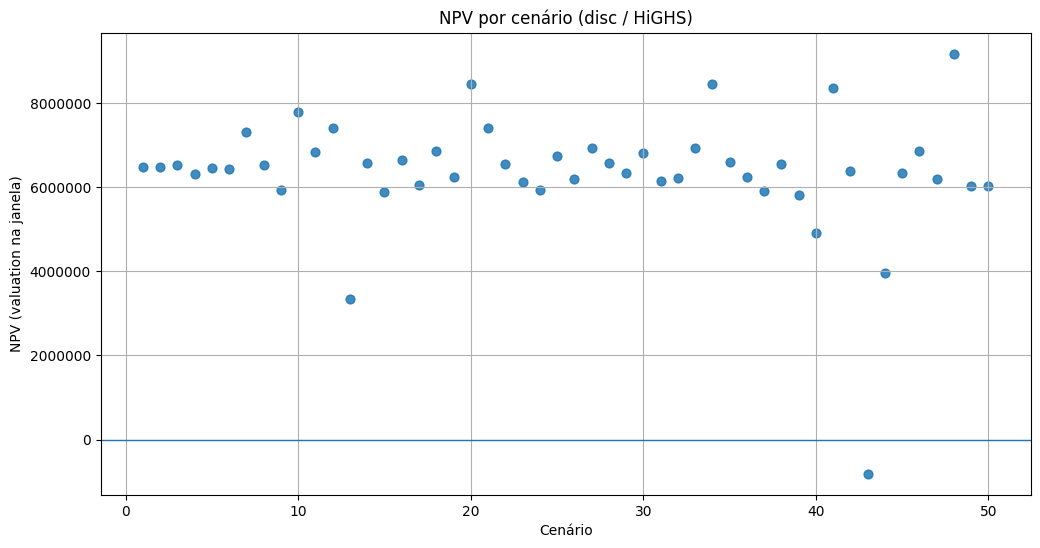

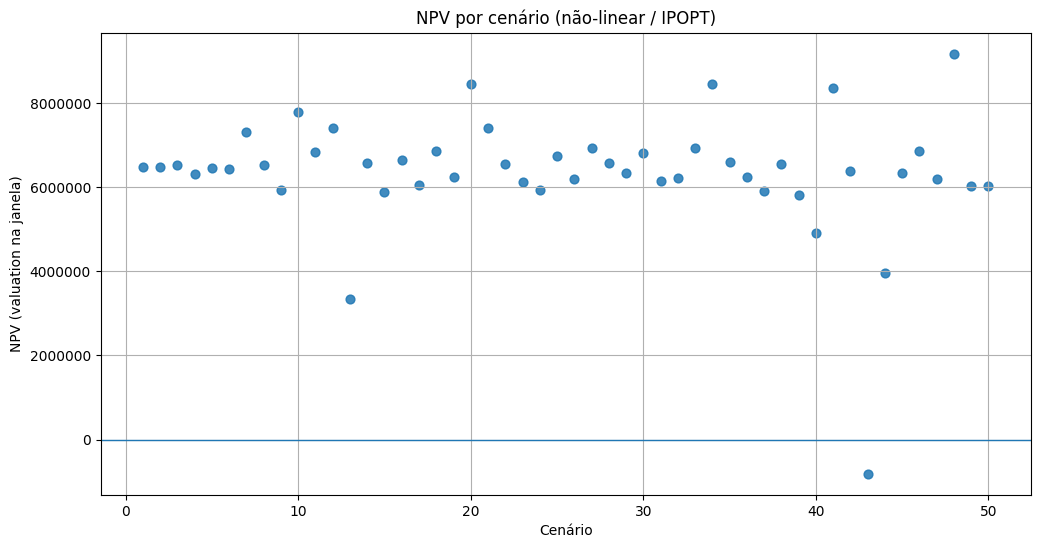

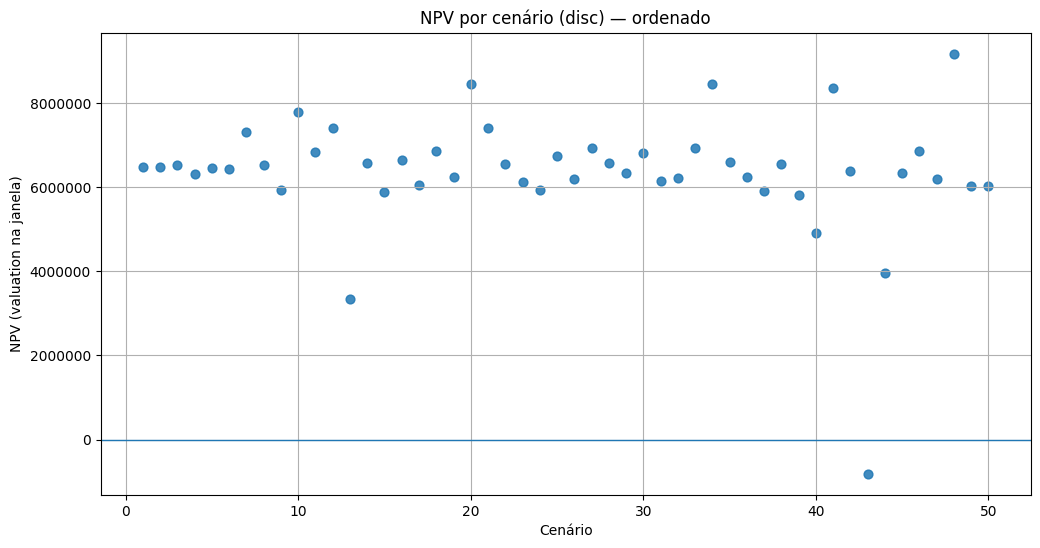

In [320]:
import numpy as np
import matplotlib.pyplot as plt
from pyomo.environ import value

def plot_npv_by_scenario(npv_by_scenario, title="NPV por cenário", sort_by="scenario", hline=None):
    """
    npv_by_scenario: dict {scenario_id: npv_value} OU list/array de npvs (assume cenário 1..n)
    sort_by: "scenario" (ordem natural) ou "npv" (ordena pelo NPV, do pior->melhor)
    hline: float | None -> desenha linha horizontal (ex: VaR em NPV)
    """
    if isinstance(npv_by_scenario, dict):
        scenarios = np.array(list(npv_by_scenario.keys()), dtype=int)
        npvs = np.array(list(npv_by_scenario.values()), dtype=float)
    else:
        npvs = np.array(npv_by_scenario, dtype=float)
        scenarios = np.arange(1, len(npvs) + 1)

    if sort_by == "npv":
        order = np.argsort(npvs)
        scenarios, npvs = scenarios[order], npvs[order]
    else:
        order = np.argsort(scenarios)
        scenarios, npvs = scenarios[order], npvs[order]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.scatter(scenarios, npvs, s=40, alpha=0.85)
    ax.axhline(0.0, linewidth=1)

    if hline is not None:
        ax.axhline(hline, linewidth=1)
        ax.text(scenarios.min(), hline, f"  linha = {hline:,.2f}", va="bottom")

    ax.ticklabel_format(axis='y', style='plain')
    ax.set_xlabel("Cenário")
    ax.set_ylabel("NPV (valuation na janela)")
    ax.set_title(title)
    ax.grid(True)
    plt.show()


# =========================
# USO NO SEU MODELO (Pyomo)
# =========================

# (A) NPV por cenário do modelo linear (HiGHS): usa disc -> VALUATION_DISC
npv_disc = {i: float(value(cvar_model.VALUATION_DISC[i])) for i in S}
plot_npv_by_scenario(npv_disc, title="NPV por cenário (disc / HiGHS)", sort_by="scenario")

# (B) NPV por cenário do modelo não-linear (IPOPT): usa (1+WACC)^t -> VALUATION_NL
# (só roda se VALUATION_NL existir e estiver bem definido/atualizado)
npv_nl = {i: float(value(cvar_model.VALUATION_NL[i])) for i in S}
plot_npv_by_scenario(npv_nl, title="NPV por cenário (não-linear / IPOPT)", sort_by="scenario")

# (C) Opcional: ordenar do pior para o melhor (bom pra ver cauda)
plot_npv_by_scenario(npv_disc, title="NPV por cenário (disc) — ordenado", sort_by="npv")

# (D) Opcional: desenhar linha do VaR em termos de NPV (se você quiser usar seu VaR do modelo)
# Ex.: como no seu loss = -NPV, então VaR(loss) = -VaR_NPV. Se você tem VaR no modelo como VaR(loss):
# var_npv_line = -float(value(cvar_model.VaR))
# plot_npv_by_scenario(npv_disc, title="NPV por cenário (disc) com linha VaR", sort_by="npv", hline=var_npv_line)


In [314]:
print(f"[beta={value(multi_model.beta)}] NPV={value(multi_model.NPV_DISC_AVG):,.2f} | CVaR={value(multi_model.CVaR):,.2f}")

ERROR:pyomo.common.numeric_types:evaluating object as numeric value: Q[1,49]
    (object: <class 'pyomo.core.base.var.VarData'>)
No value for uninitialized VarData object Q[1,49]
ERROR:pyomo.common.numeric_types:evaluating object as numeric value: NPV_DISC_AVG
    (object: <class 'pyomo.core.base.expression.ScalarExpression'>)
No value for uninitialized VarData object Q[1,49]


ValueError: No value for uninitialized VarData object Q[1,49]

In [276]:
print(f"[beta={value(multi_model.beta)}] NPV={value(multi_model.NPV_DISC_AVG):,.2f} | CVaR={value(multi_model.CVaR):,.2f}")

[beta=0.999999] NPV=105,766.22 | CVaR=-42,495.84


In [278]:
print(f"[beta={value(multi_model.beta)}] NPV={value(multi_model.NPV_DISC_AVG):,.2f} | CVaR={value(multi_model.CVaR):,.2f}")

[beta=0.5] NPV=127,518.05 | CVaR=-42,495.11


In [281]:
print(f"[beta={value(multi_model.beta)}] NPV={value(multi_model.NPV_DISC_AVG):,.2f} | CVaR={value(multi_model.CVaR):,.2f}")

[beta=1] NPV=61,433.91 | CVaR=-42,497.88


## Pegando apenas do linear por beta

In [ ]:
betas = np.linspace(0.99999, 0.00001, 21)

# Checks preliminares

print("obj_beta_highs active:", multi_model.obj_beta_highs.active)
print("obj_cvar_highs active:", multi_model.obj_cvar_highs.active)
print("obj_beta_ipopt active:", multi_model.obj_beta_ipopt.active)
print("obj_cvar_ipopt active:", multi_model.obj_cvar_ipopt.active)

print("wacc_def active:", multi_model.wacc_def.active, "\n\n")

solutions = []
points = []
for beta in betas:
    multi_model.beta.set_value(beta)

    solver = SolverFactory("highs")

    res = solver.solve(
        multi_model,
        tee=True,
    )

    solutions.append(res)
    points.append((beta, value(multi_model.CVaR), value(multi_model.NPV_DISC_AVG)))
    print(f"[beta={beta:.2f}] NPV={value(multi_model.NPV_DISC_AVG):,.2f} | CVaR={value(multi_model.CVaR):,.2f}")



[beta=1.00] NPV=108,165.83 | CVaR=-42,499.96
[beta=0.95] NPV=127,487.11 | CVaR=-42,498.11
[beta=0.90] NPV=127,487.11 | CVaR=-42,498.11
[beta=0.85] NPV=127,487.11 | CVaR=-42,498.11
[beta=0.80] NPV=127,495.83 | CVaR=-42,497.27
[beta=0.75] NPV=127,495.83 | CVaR=-42,497.27
[beta=0.70] NPV=127,513.93 | CVaR=-42,499.43
[beta=0.65] NPV=127,513.74 | CVaR=-42,493.43
[beta=0.60] NPV=127,511.26 | CVaR=-42,499.12
[beta=0.55] NPV=127,510.69 | CVaR=-42,497.02
[beta=0.50] NPV=127,518.05 | CVaR=-42,495.11
[beta=0.45] NPV=127,508.84 | CVaR=-42,493.16
[beta=0.40] NPV=127,512.46 | CVaR=-42,484.73
[beta=0.35] NPV=127,520.45 | CVaR=-42,495.03
[beta=0.30] NPV=127,523.36 | CVaR=-42,486.84


KeyboardInterrupt: 

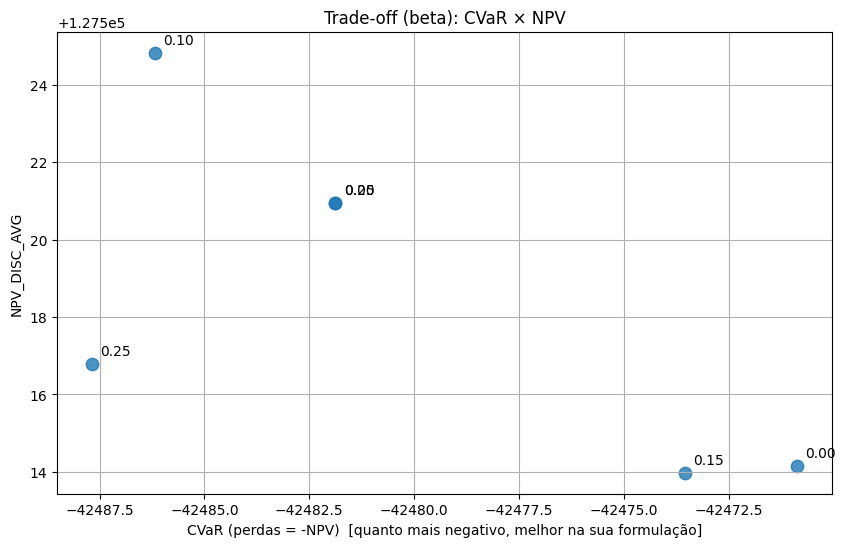

In [332]:
import numpy as np
import matplotlib.pyplot as plt

# points: lista de tuplas (beta, CVaR, NPV_DISC_AVG)
# exemplo: points.append((beta, value(multi_model.CVaR), value(multi_model.NPV_DISC_AVG)))

pts = np.array(points, dtype=float)
betas = pts[:, 0]
cvar  = pts[:, 1]
npv   = pts[:, 2]

# Ordena por beta (só para ligar os pontos de forma “bonita”)
order = np.argsort(betas)[::-1]  # de beta alto -> baixo
betas, cvar, npv = betas[order], cvar[order], npv[order]

fig, ax = plt.subplots(figsize=(10, 6))

# Se quiser usar -CVaR no eixo X, troque para: x = -cvar
x = cvar

ax.scatter(x, npv, s=80, alpha=0.8)

ax.ticklabel_format(axis='x', style='plain')
ax.ticklabel_format(axis='y', style='plain')

ax.set_xlabel("CVaR (perdas = -NPV)  [quanto mais negativo, melhor na sua formulação]")
ax.set_ylabel("NPV_DISC_AVG")
ax.set_title("Trade-off (beta): CVaR × NPV")

# Anota alguns betas (para não poluir, anota só alguns índices)
to_annotate = np.linspace(0, len(betas)-1, min(6, len(betas))).astype(int)
for k in to_annotate:
    ax.annotate(f"{betas[k]:.2f}", (x[k], npv[k]), textcoords="offset points", xytext=(6, 6))

ax.grid(True)
plt.show()


In [336]:
# ===============================================================
# LOOP (por beta) COM N_CYCLES DE ALTERNÂNCIA (HiGHS <-> IPOPT)
#   - HiGHS: resolve linear (disc, obj_beta_highs)
#   - IPOPT: resolve NLP (WACC no expoente, obj_beta_ipopt)
#   - repete N_CYCLES vezes por beta
#
# Ajustes aplicados (baseado no seu modelo):
#   1) HiGHS: mantém capital_positive (do modelo) ATIVO e desativa capital_positive_eps
#      (evita infeasible “do nada” por dinâmica de E + restrição duplicada)
#   2) HiGHS: NÃO descongela M[1] nem Q[:,1] (fixos por design no seu modelo base)
#   3) IPOPT: após projetar E e D / forçar capital_min, recomputa WACC inicial
#      consistente com wacc_def: WACC = (E*Ke + D*Kd)/(E+D) e clipa nos bounds
#   4) IPOPT: mantém M fixado em >=0, mas preserva M[1] fixo (se o modelo base fixou)
#
# Pré-requisitos no escopo:
#   S, T, L_loan, initial_debt, initial_equity, factory_lifetime
#   multi_model (Pyomo model pronto, com nomes iguais aos do seu modelo base)
# ===============================================================

import math
import logging
import numpy as np
from pyomo.environ import SolverFactory, value, Constraint, Objective
from pyomo.opt import TerminationCondition
from pyomo.util.infeasible import log_infeasible_constraints, log_infeasible_bounds


# ---------------------------
# Helpers "safe solve"
# ---------------------------
def _safe_solve_highs(solver_highs, mm, tee=False):
    """Evita NoFeasibleSolutionError quando HiGHS não encontra solução factível."""
    try:
        return solver_highs.solve(mm, tee=tee)
    except Exception:
        return solver_highs.solve(mm, tee=tee, load_solutions=False)


def _safe_solve_ipopt(solver_ipopt, mm, tee=False, tag="ipopt"):
    """
    Evita ValueError do Pyomo quando IPOPT retorna status=error
    (Pyomo não carrega solução). Re-rodamos com load_solutions=False.
    """
    try:
        return solver_ipopt.solve(mm, tee=tee)
    except ValueError:
        print(f"[{tag}] Pyomo não conseguiu carregar solução (provável status=error). Re-rodando com load_solutions=False...")
        return solver_ipopt.solve(mm, tee=tee, load_solutions=False)


def _termination_ok(res):
    tc = res.solver.termination_condition
    return tc in (
        TerminationCondition.optimal,
        TerminationCondition.locallyOptimal,
        TerminationCondition.feasible,
    )


def _print_solver_banner(res, label="SOLVER"):
    st = getattr(res.solver, "status", None)
    tc = getattr(res.solver, "termination_condition", None)
    msg = getattr(res.solver, "message", None)
    print(f"[{label}] status={st} | termination={tc}")
    if msg:
        print(f"[{label}] message={msg}")


# ---------------------------
# Diagnóstico (sem poluição)
# ---------------------------
def _log_infeasibilities(mm, label="INFEAS"):
    """
    log_infeasible_* só imprime se o logger estiver em INFO.
    Aqui criamos um logger isolado (não polui seu __main__).
    """
    logger = logging.getLogger(label)
    logger.setLevel(logging.INFO)

    # evita handlers duplicados
    if not any(isinstance(h, logging.StreamHandler) for h in logger.handlers):
        handler = logging.StreamHandler()
        handler.setLevel(logging.INFO)
        formatter = logging.Formatter('%(levelname)s:%(name)s:%(message)s')
        handler.setFormatter(formatter)
        logger.addHandler(handler)

    log_infeasible_bounds(mm, logger=logger)
    log_infeasible_constraints(mm, logger=logger)


def _check_for_nan_inf(mm, label="CHECK"):
    """
    Checa None/NaN/Inf em variáveis-chave.
    Causa #1 de IPOPT status=error: "Invalid number in NLP function".
    """
    problems = []

    def _scan(varcomp, name, max_items=10):
        bad = 0
        for k, v in varcomp.items():
            vv = v.value
            if vv is None or (isinstance(vv, float) and (math.isnan(vv) or math.isinf(vv))):
                problems.append((name, k, vv))
                bad += 1
                if bad >= max_items:
                    break

    for nm in ["M", "Borrow", "Repay", "D", "Q", "num_factories", "E", "WACC"]:
        if hasattr(mm, nm):
            _scan(getattr(mm, nm), nm)

    if problems:
        print(f"[{label}] Encontrados valores None/NaN/Inf (mostrando até 10):")
        for p in problems[:10]:
            print("  ", p)
        return False

    print(f"[{label}] OK: não achei None/NaN/Inf nas variáveis-chave.")
    return True


def _dump_switch_state(mm, label="STATE"):
    """Mostra (resumo) do estado no chaveamento: objetivos ativos, constraints e contagem de vars fixas."""
    def _count_fixed(varcomp):
        try:
            return sum(1 for v in varcomp.values() if v.fixed)
        except Exception:
            return None

    print(f"\n--- {label} ---")

    # objetivos ativos
    active_obj_names = []
    for obj in mm.component_objects(Objective, active=True):
        active_obj_names.append(obj.name)
    print("Active Objectives:", active_obj_names)

    # constraints-chave
    for cname in [
        "wacc_def",
        "vardev_constraint", "cvar_constraint",
        "vardev_nl_constraint", "cvar_nl_constraint",
        "capital_positive", "capital_positive_eps",
        "qty_increment", "growth", "non_regression",
        "production_capacity_constraint", "capex_aquisi_constraint",
    ]:
        if hasattr(mm, cname):
            comp = getattr(mm, cname)
            print(f"{cname}: active={comp.active}")

    # fixes
    for nm in ["M", "Borrow", "Repay", "D", "Q", "num_factories", "E", "WACC"]:
        if hasattr(mm, nm):
            print(f"{nm} fixed:", _count_fixed(getattr(mm, nm)))


# ---------------------------
# Projeções (warm start factível)
# ---------------------------
def _ensure_capital_positive_eps(mm, eps=1e2):
    if not hasattr(mm, "capital_positive_eps"):
        mm.capital_positive_eps = Constraint(
            S, range(1, T + 1),
            rule=lambda m2, i, t: m2.E[i, t] + m2.D[t] >= eps
        )
        mm.capital_positive_eps.deactivate()


def _project_repay_and_debt(mm):
    # Repay coerente com repay_schedule
    for t in range(1, T + 1):
        kmin = max(1, t - L_loan + 1)
        s = sum(value(mm.Borrow[k]) for k in range(kmin, t + 1))
        mm.Repay[t].set_value(max(0.0, value(mm.init_amort[t]) + (1.0 / L_loan) * s))

    # D coerente com debt_dyn
    for t in range(1, T + 1):
        if t == 1:
            mm.D[t].set_value(max(0.0, initial_debt + value(mm.Borrow[1]) - value(mm.Repay[1])))
        else:
            mm.D[t].set_value(max(0.0, value(mm.D[t-1]) + value(mm.Borrow[t]) - value(mm.Repay[t])))


def _project_equity(mm):
    def interest0(tt):
        D_prev = initial_debt if tt == 1 else value(mm.D[tt - 1])
        return value(mm.cost_of_debt[tt]) * D_prev

    for i in S:
        E_prev = initial_equity
        for t in range(1, T + 1):
            receita = value(mm.P) * value(mm.Q[i, t])
            dep = (value(mm.price_of_factory) / factory_lifetime) * value(mm.num_factories[i, t])

            ebit = (
                receita
                - value(mm.variable_cost_percentage[i, t]) * receita
                - value(mm.variable_expenses_percentage) * receita
                - value(mm.M[t])
                - value(mm.taxes_percentage) * receita
                - value(mm.fix_costs)
                - value(mm.fix_expenses)
                - dep
            )
            ni = ebit - interest0(t)
            E_now = E_prev + ni
            mm.E[i, t].set_value(max(1e-3, E_now))
            E_prev = E_now


# ---------------------------
# Liga/desliga objetivos
# ---------------------------
def _activate_only(mm, active_obj_name):
    """Garante que APENAS um Objective esteja ativo."""
    for obj in mm.component_objects(Objective, active=True):
        obj.deactivate()
    if not hasattr(mm, active_obj_name):
        raise RuntimeError(f"Objective '{active_obj_name}' não existe no modelo.")
    getattr(mm, active_obj_name).activate()


# ---------------------------
# Disc / WACC para HiGHS
# ---------------------------
def _update_disc_from_current_wacc(mm):
    """Atualiza mm.disc com base no WACC atual. Se disc não existir, não faz nada."""
    if not hasattr(mm, "disc"):
        return
    for i in S:
        for t in range(1, T + 1):
            w = mm.WACC[i, t].value
            if w is None:
                w = 0.10
                mm.WACC[i, t].set_value(w)
            mm.disc[i, t] = 1.0 / ((1.0 + float(w)) ** t)


def _fix_wacc_for_highs(mm, default_w=0.10):
    """HiGHS precisa de WACC FIXO (disc coerente)."""
    for i in S:
        for t in range(1, T + 1):
            w = mm.WACC[i, t].value
            if w is None:
                w = default_w
                mm.WACC[i, t].set_value(w)
            if not mm.WACC[i, t].fixed:
                mm.WACC[i, t].fix(float(w))


def _unfix_wacc_for_ipopt(mm):
    for i in S:
        for t in range(1, T + 1):
            if mm.WACC[i, t].fixed:
                mm.WACC[i, t].unfix()


def _force_capital_min_values(mm, cap_min=100.0, e_floor=1e-3):
    """
    Garante que o PONTO INICIAL respeita E[i,t] + D[t] >= cap_min.
    (útil para o IPOPT não começar violando capital_positive / wacc_def)
    """
    for t in range(1, T + 1):
        Dt = value(mm.D[t]) if mm.D[t].value is not None else 0.0
        Dt = max(0.0, float(Dt))
        mm.D[t].set_value(Dt)

        for i in S:
            Ei = value(mm.E[i, t]) if mm.E[i, t].value is not None else e_floor
            Ei = max(float(Ei), e_floor)

            if Ei + Dt < cap_min:
                Ei = cap_min - Dt
            mm.E[i, t].set_value(Ei)


def _recompute_wacc_initial(mm, w_min=1e-5, w_max=0.99999, w_floor=0.001):
    """
    (CRÍTICO) Chute inicial consistente com wacc_def:
      WACC = (E*Ke + D*Kd)/(E+D)
    Clip em [w_min, w_max] e respeita w_floor (>=0.001).
    """
    Ke = float(value(mm.cost_of_equity)) if hasattr(mm, "cost_of_equity") else 0.10
    for t in range(1, T + 1):
        Dv = float(value(mm.D[t])) if mm.D[t].value is not None else 0.0
        Kd = float(value(mm.cost_of_debt[t])) if hasattr(mm, "cost_of_debt") else 0.10

        for i in S:
            Ev = float(value(mm.E[i, t])) if mm.E[i, t].value is not None else 1e-3
            denom = Ev + Dv
            if denom <= 0:
                w = 0.10
            else:
                w = (Ev * Ke + Dv * Kd) / denom

            # bounds + wacc_positive (>=0.001)
            w = max(w, w_floor, w_min)
            w = min(w, w_max)

            mm.WACC[i, t].set_value(float(w))

def _warmstart_cvar_nl(mm, alpha, S):
    # garante que VaR_nl / VarDev_nl / CVaR_nl começam factíveis
    losses = []
    for i in S:
        # loss = -valuation
        losses.append(float(-value(mm.VALUATION_NL[i])))
    var0 = max(losses) if losses else 0.0

    if mm.VaR_nl.fixed:  mm.VaR_nl.unfix()
    if mm.CVaR_nl.fixed: mm.CVaR_nl.unfix()

    mm.VaR_nl.set_value(var0)

    # VarDev_nl[i] >= loss[i] - VaR_nl
    for i, loss in zip(S, losses):
        if mm.VarDev_nl[i].fixed:
            mm.VarDev_nl[i].unfix()
        mm.VarDev_nl[i].set_value(max(0.0, loss - var0))

    nS = len(list(S))
    mm.CVaR_nl.set_value(var0 + (1.0 / (nS * alpha)) * sum(value(mm.VarDev_nl[i]) for i in S))


# ---------------------------
# Preparação HiGHS (linear)
# ---------------------------
def _prep_for_highs_linear_beta(mm, cap_min=100.0):
    """
    HiGHS (MILP/LP):
      - ativa obj_beta_highs
      - desativa wacc_def (bilinear)
      - ativa CVaR linear; desativa CVaR NL
      - mantém capital_positive (original do modelo) ATIVO
      - desativa capital_positive_eps (para não criar duplicidade/aperte indevido)
      - reativa restrições operacionais (foram desativadas no IPOPT)
      - descongela operação, MAS preserva fixos do modelo base: M[1] e Q[:,1]
      - WACC fixo + disc atualizado
    """
    _activate_only(mm, "obj_beta_highs")

    # garantir linearidade
    if hasattr(mm, "wacc_def"):
        mm.wacc_def.deactivate()

    # CVaR linear ON; NL OFF
    if hasattr(mm, "vardev_constraint"):    mm.vardev_constraint.activate()
    if hasattr(mm, "cvar_constraint"):      mm.cvar_constraint.activate()
    if hasattr(mm, "vardev_nl_constraint"): mm.vardev_nl_constraint.deactivate()
    if hasattr(mm, "cvar_nl_constraint"):   mm.cvar_nl_constraint.deactivate()

    # capital: usa a original do modelo (E + D >= CAPITAL_MIN)
    if hasattr(mm, "capital_positive"):     mm.capital_positive.activate()
    if hasattr(mm, "capital_positive_eps"): mm.capital_positive_eps.deactivate()

    # reativar restrições operacionais desativadas no IPOPT
    for cname in ["qty_increment", "growth", "non_regression",
                  "production_capacity_constraint", "capex_aquisi_constraint"]:
        if hasattr(mm, cname):
            getattr(mm, cname).activate()

    # desfaz o "freeze" da operação do IPOPT, preservando fixos do modelo base
    # - M[1] é fixo no modelo base -> não mexer
    if hasattr(mm, "M"):
        for t in range(2, T + 1):
            if mm.M[t].fixed:
                mm.M[t].unfix()

    # - Q[:,1] é fixo no modelo base -> não mexer
    if hasattr(mm, "Q"):
        for i in S:
            for t in range(2, T + 1):
                if mm.Q[i, t].fixed:
                    mm.Q[i, t].unfix()

    if hasattr(mm, "num_factories"):
        for i in S:
            for t in range(1, T + 1):
                if mm.num_factories[i, t].fixed:
                    mm.num_factories[i, t].unfix()

    # coerência disc/WACC
    _update_disc_from_current_wacc(mm)
    _fix_wacc_for_highs(mm)


# ---------------------------
# Preparação IPOPT (NLP)
# ---------------------------
def _prep_for_ipopt_after_highs(mm, cap_min=100.0, q_floor=250_000):
    """
    IPOPT (NLP):
      - ativa obj_beta_ipopt
      - ativa wacc_def
      - ativa CVaR NL; desativa CVaR linear
      - congela operação (M, Q, num_factories) preservando fixos do modelo base:
          * M[1] já fixo -> mantém
          * Q[:,1] já fixo -> mantém
      - desativa restrições que definem Q (evita conflitos com Q fixo)
      - libera finanças + E/WACC
      - garante ponto inicial consistente:
          * projeta Repay/D
          * projeta E via equity_dyn “implícito” (aproximação)
          * força E+D >= cap_min
          * recomputa WACC inicial consistente com wacc_def
    """
    _activate_only(mm, "obj_beta_ipopt")

    # CVaR NL ON; linear OFF
    if hasattr(mm, "vardev_nl_constraint"): mm.vardev_nl_constraint.activate()
    if hasattr(mm, "cvar_nl_constraint"):   mm.cvar_nl_constraint.activate()
    if hasattr(mm, "vardev_constraint"):    mm.vardev_constraint.deactivate()
    if hasattr(mm, "cvar_constraint"):      mm.cvar_constraint.deactivate()

    # congela operação
    # - preserva M[1] fixo do modelo base; fixa t>=2
    for t in range(1, T + 1):
        mm.M[t].fix(max(0.0, value(mm.M[t])))

    # Q: preserva t=1 fixo; fixa t>=2 com piso
    for i in S:
        for t in range(2, T + 1):
            qv = mm.Q[i, t].value
            if qv is None:
                qv = value(mm.initial_quantity)
                mm.Q[i, t].set_value(qv)
            mm.Q[i, t].fix(qv if qv >= q_floor else q_floor)

        for t in range(1, T + 1):

            fv = mm.num_factories[i, t].value
            if fv is None:
                fv = value(mm.initial_factories)
                mm.num_factories[i, t].set_value(fv)
            mm.num_factories[i, t].fix(int(round(fv)))

    # IMPORTANTÍSSIMO: não pode manter qty_increment ativo com Q fixo (igualdade)
    # e as outras podem virar redundantes/inconvenientes; desative no NLP
    for cname in ["qty_increment", "growth", "non_regression",
                  "production_capacity_constraint", "capex_aquisi_constraint"]:
        if hasattr(mm, cname):
            getattr(mm, cname).deactivate()

    # libera finanças (as constraints repay_schedule/debt_dyn continuam garantindo coerência)
    for t in range(1, T + 1):
        if mm.Borrow[t].fixed:
            mm.Borrow[t].unfix()
        if mm.Repay[t].fixed:
            mm.Repay[t].unfix()
        if mm.D[t].fixed:
            mm.D[t].unfix()

    # libera E e WACC
    for i in S:
        for t in range(1, T + 1):
            if mm.E[i, t].fixed:
                mm.E[i, t].unfix()
    _unfix_wacc_for_ipopt(mm)

    # capital: use a original (não precisa duplicar). eps pode existir, mas deixe OFF
    if hasattr(mm, "capital_positive"):
        mm.capital_positive.activate()
    # _ensure_capital_positive_eps(mm, eps=cap_min)
    if hasattr(mm, "capital_positive_eps"):
        mm.capital_positive_eps.deactivate()

    # liga wacc_def
    if hasattr(mm, "wacc_def"):
        mm.wacc_def.activate()
    else:
        mm.wacc_def = Constraint(S, range(1, T + 1), rule=wacc_def_rule)

    # projeção factível (warm start)
    _project_repay_and_debt(mm)
    _project_equity(mm)

    # garante capital min no ponto inicial e WACC consistente com wacc_def
    _force_capital_min_values(mm, cap_min=cap_min, e_floor=1e-3)

    _recompute_wacc_initial(mm, w_min=1e-5, w_max=0.99999, w_floor=0.001)

    _warmstart_cvar_nl(mm, alpha=0.1, S=S)

   


# ---------------------------
# safe value helper
# ---------------------------
def _val_or_nan(x):
    try:
        return float(value(x))
    except Exception:
        return float("nan")


# ===============================================================
# EXECUÇÃO: para cada beta, alterna HiGHS->IPOPT por N_CYCLES
# ===============================================================
betas = np.linspace(0.00001, 0.99999, 21)

N_CYCLES = 5
CAPITAL_MIN = 100.0   # usa o mesmo CAPITAL_MIN do seu modelo
Q_FLOOR = 250_000

runs = []

for beta in betas:
    m = multi_model.clone()
    m.beta.set_value(float(beta))

    solver_highs = SolverFactory("highs")
    solver_ipopt = SolverFactory("ipopt")

    # opções IPOPT (ajuste como quiser)
    solver_ipopt.options["obj_scaling_factor"] = 1e-6
    solver_ipopt.options["print_level"] = 0  # 0 = silencioso

    print(f"\n================ beta={beta:.5f} ================")

    for cyc in range(1, N_CYCLES + 1):
        print(f"\n---- ciclo {cyc}/{N_CYCLES} ----")

        # (A) HiGHS
        # Controle total do estado também no ciclo 1 (evita “clone veio estranho”)
        _prep_for_highs_linear_beta(m, cap_min=CAPITAL_MIN)
        res_h = _safe_solve_highs(solver_highs, m, tee=False)

        if not _termination_ok(res_h):
            print(f"[HiGHS] sem solução factível/ótima: {res_h.solver.termination_condition}")
            runs.append({
                "beta": float(beta), "cycle": int(cyc), "stage": "highs",
                "termination": str(res_h.solver.termination_condition),
            })
            # ajuda debug
            _log_infeasibilities(m, label=f"INFEAS_HIGHS beta={beta:.5f} cyc={cyc}")
            break

        cvar_lin = _val_or_nan(m.CVaR) if hasattr(m, "CVaR") else np.nan
        npv_lin  = _val_or_nan(m.NPV_DISC_AVG) if hasattr(m, "NPV_DISC_AVG") else np.nan
        obj_lin  = _val_or_nan(m.obj_beta_highs) if hasattr(m, "obj_beta_highs") else np.nan

        print(f"[HiGHS]  NPV={npv_lin:,.2f} | CVaR={cvar_lin:,.4f} | obj_beta={obj_lin:,.4f}")

        runs.append({
            "beta": float(beta), "cycle": int(cyc), "stage": "highs",
            "termination": str(res_h.solver.termination_condition),
            "NPV": npv_lin, "CVaR": cvar_lin, "obj_beta": obj_lin,
        })

        # (B) IPOPT
        _prep_for_ipopt_after_highs(m, cap_min=CAPITAL_MIN, q_floor=Q_FLOOR)

        # diagnósticos antes de chamar IPOPT
        _dump_switch_state(m, label=f"BEFORE IPOPT (beta={beta:.5f}, cyc={cyc})")
        _check_for_nan_inf(m, label=f"CHECK IPOPT INIT (beta={beta:.5f}, cyc={cyc})")

        # log do IPOPT em arquivo por beta/ciclo
        solver_ipopt.options["output_file"] = f"ipopt_beta_{beta:.5f}_cyc_{cyc}.log"

        res_n = _safe_solve_ipopt(solver_ipopt, m, tee=False, tag=f"IPOPT beta={beta:.5f} cyc={cyc}")
        _print_solver_banner(res_n, label=f"IPOPT beta={beta:.5f} cyc={cyc}")

        term_n = res_n.solver.termination_condition
        status_n = getattr(res_n.solver, "status", None)

        # métricas NLP
        cvar_nl = _val_or_nan(m.CVaR_nl) if hasattr(m, "CVaR_nl") else np.nan
        npv_nl  = _val_or_nan(m.NPV_NL_AVG) if hasattr(m, "NPV_NL_AVG") else np.nan
        var_nl  = _val_or_nan(m.VaR_nl) if hasattr(m, "VaR_nl") else np.nan
        obj_nl  = _val_or_nan(m.obj_beta_ipopt) if hasattr(m, "obj_beta_ipopt") else np.nan

        print(f"[IPOPT] termination={term_n} | NPV={npv_nl:,.2f} | CVaR_nl={cvar_nl:,.4f} | VaR_nl={var_nl:,.4f} | obj_beta={obj_nl:,.4f}")

        runs.append({
            "beta": float(beta), "cycle": int(cyc), "stage": "ipopt",
            "termination": str(term_n),
            "status": str(status_n),
            "NPV": npv_nl, "CVaR": cvar_nl, "VaR": var_nl, "obj_beta": obj_nl,
            "ipopt_log": f"ipopt_beta_{beta:.5f}_cyc_{cyc}.log",
        })

        # se IPOPT retornou status=error/unknown, loga infeasibilidades e para ciclos desse beta
        if str(status_n).lower() == "error" or term_n in (TerminationCondition.error, TerminationCondition.unknown):
            print("[IPOPT] status=error/unknown. Vou logar infeasible bounds/constraints do ponto atual.")
            _log_infeasibilities(m, label=f"INFEAS_IPOPT beta={beta:.5f} cyc={cyc}")
            break

        # se IPOPT falhar feio, pare os ciclos desse beta
        if term_n in (TerminationCondition.infeasible, TerminationCondition.noSolution):
            _log_infeasibilities(m, label=f"INFEAS_IPOPT beta={beta:.5f} cyc={cyc}")
            break

        # IMPORTANTÍSSIMO: depois do IPOPT, atualiza disc para o próximo HiGHS usar WACC “novo”
        _update_disc_from_current_wacc(m)

# Ao final você tem:
# - runs: histórico detalhado por beta/ciclo/etapa
# - arquivos ipopt_beta_..._cyc_....log com o log do IPOPT



================ beta=0.00001 ================

---- ciclo 1/5 ----
[HiGHS]  NPV=113,082.81 | CVaR=-24,804.0928 | obj_beta=-113,081.9309

--- BEFORE IPOPT (beta=0.00001, cyc=1) ---
Active Objectives: ['obj_beta_ipopt']
wacc_def: active=True
vardev_constraint: active=False
cvar_constraint: active=False
vardev_nl_constraint: active=True
cvar_nl_constraint: active=True
capital_positive: active=True
qty_increment: active=False
growth: active=False
non_regression: active=False
production_capacity_constraint: active=False
capex_aquisi_constraint: active=False
M fixed: 60
Borrow fixed: 0
Repay fixed: 0
D fixed: 0
Q fixed: 3000
num_factories fixed: 3000
E fixed: 0
WACC fixed: 0
[CHECK IPOPT INIT (beta=0.00001, cyc=1)] OK: não achei None/NaN/Inf nas variáveis-chave.
[IPOPT beta=0.00001 cyc=1] status=ok | termination=optimal
[IPOPT beta=0.00001 cyc=1] message=Ipopt 3.14.16\x3a Solved To Acceptable Level.
[IPOPT] termination=optimal | NPV=6,978,361.24 | CVaR_nl=1,209,496.4612 | VaR_nl=1,082,618.

KeyboardInterrupt: 

In [ ]:
# from pyomo.environ import SolverFactory, value, Objective, Constraint
# from pyomo.opt import TerminationCondition
# import numpy as np

# # -----------------------------
# # DIAGNÓSTICO: objetivos ativos
# # -----------------------------
# def _print_objectives(mm, tag=""):
#     actives = []
#     for obj in mm.component_data_objects(Objective, active=True):
#         actives.append(obj.name)
#     print(f"\n[{tag}] Active objectives = {actives}")

#     # imprime valores de TODOS os objetivos (ativos e inativos) pra você ver o que está acontecendo
#     for obj in mm.component_data_objects(Objective, active=False):
#         # inativos
#         try:
#             v = value(obj.expr)
#         except:
#             v = None
#         print(f"  (inactive) {obj.name} = {v}")

#     for obj in mm.component_data_objects(Objective, active=True):
#         print(f"  (ACTIVE)   {obj.name} = {value(obj.expr)}")

# def _assert_single_objective(mm, expected_name=None):
#     actives = [obj.name for obj in mm.component_data_objects(Objective, active=True)]
#     assert len(actives) == 1, f"Era pra ter 1 objetivo ativo, mas tem {len(actives)}: {actives}"
#     if expected_name is not None:
#         assert actives[0] == expected_name, f"Objetivo ativo = {actives[0]}, esperado = {expected_name}"

# # ----------------------------------------
# # CHAVEAMENTO CORRETO: HiGHS vs IPOPT
# # ----------------------------------------
# def _prep_highs_beta(mm):
#     """
#     HiGHS: linear (disc), então:
#     - wacc_def OFF
#     - CVaR linear ON (vardev_constraint/cvar_constraint)
#     - CVaR NL OFF (vardev_nl_constraint/cvar_nl_constraint)
#     - objetivo: obj_beta_highs ATIVO, obj_beta_ipopt INATIVO (e demais inativos)
#     - WACC FIXO (porque disc é Param atualizado fora)
#     """
#     # 1) desativa todos objetivos conhecidos
#     for name in ["obj_highs", "obj_ipopt", "obj_cvar_highs", "obj_cvar_ipopt", "obj_beta_highs", "obj_beta_ipopt"]:
#         if hasattr(mm, name):
#             getattr(mm, name).deactivate()

#     # 2) ativa o objetivo beta linear
#     if not hasattr(mm, "obj_beta_highs"):
#         raise RuntimeError("obj_beta_highs não existe no modelo.")
#     mm.obj_beta_highs.activate()

#     # 3) garante linearidade
#     if hasattr(mm, "wacc_def"):
#         mm.wacc_def.deactivate()

#     # 4) CVaR linear ON / CVaR NL OFF
#     if hasattr(mm, "vardev_constraint"):  mm.vardev_constraint.activate()
#     if hasattr(mm, "cvar_constraint"):    mm.cvar_constraint.activate()
#     if hasattr(mm, "vardev_nl_constraint"): mm.vardev_nl_constraint.deactivate()
#     if hasattr(mm, "cvar_nl_constraint"):   mm.cvar_nl_constraint.deactivate()

#     # 5) capital constraint padrão (se você usa)
#     if hasattr(mm, "capital_positive_eps"): mm.capital_positive_eps.deactivate()
#     if hasattr(mm, "capital_positive"):     mm.capital_positive.activate()

#     # 6) WACC fixo (porque disc usa WACC fixo)
#     if hasattr(mm, "WACC"):
#         for i in S:
#             for t in range(1, T+1):
#                 if not mm.WACC[i, t].fixed:
#                     mm.WACC[i, t].fix(value(mm.WACC[i, t]))

# def _ensure_capital_positive_eps(mm, eps=1e2):
#     if not hasattr(mm, "capital_positive_eps"):
#         mm.capital_positive_eps = Constraint(
#             S, range(1, T+1),
#             rule=lambda m2, i, t: m2.E[i, t] + m2.D[t] >= eps
#         )
#         mm.capital_positive_eps.deactivate()

# def _project_repay_and_debt(mm):
#     for t in range(1, T + 1):
#         kmin = max(1, t - L_loan + 1)
#         s = sum(value(mm.Borrow[k]) for k in range(kmin, t + 1))
#         mm.Repay[t].set_value(max(0.0, value(mm.init_amort[t]) + (1.0 / L_loan) * s))

#     for t in range(1, T + 1):
#         if t == 1:
#             mm.D[t].set_value(max(0.0, initial_debt + value(mm.Borrow[1]) - value(mm.Repay[1])))
#         else:
#             mm.D[t].set_value(max(0.0, value(mm.D[t-1]) + value(mm.Borrow[t]) - value(mm.Repay[t])))

# def _project_equity(mm):
#     def interest0(tt):
#         D_prev = initial_debt if tt == 1 else value(mm.D[tt - 1])
#         return value(mm.cost_of_debt[tt]) * D_prev

#     for i in S:
#         E_prev = initial_equity
#         for t in range(1, T + 1):
#             receita = value(mm.P) * value(mm.Q[i, t])
#             dep = (value(mm.price_of_factory) / factory_lifetime) * value(mm.num_factories[i, t])

#             ebit = (
#                 receita
#                 - value(mm.variable_cost_percentage[i, t]) * receita
#                 - value(mm.variable_expenses_percentage) * receita
#                 - value(mm.M[t])
#                 - value(mm.taxes_percentage) * receita
#                 - value(mm.fix_costs)
#                 - value(mm.fix_expenses)
#                 - dep
#             )
#             ni = ebit - interest0(t)
#             E_now = E_prev + ni
#             mm.E[i, t].set_value(max(1e-3, E_now))
#             E_prev = E_now

# def _prep_ipopt_beta(mm, eps_capital=1e2):
#     """
#     IPOPT: NL (WACC no expoente), então:
#     - ativa wacc_def
#     - ativa CVaR NL constraints
#     - desativa CVaR linear constraints
#     - objetivo: obj_beta_ipopt ativo, obj_beta_highs inativo
#     - congela operação (M,Q,fábricas) e libera finanças + E/WACC
#     - projeta pra ficar factível (repay/debt/equity)
#     """
#     # 1) desativa todos objetivos conhecidos
#     for name in ["obj_highs", "obj_ipopt", "obj_cvar_highs", "obj_cvar_ipopt", "obj_beta_highs", "obj_beta_ipopt"]:
#         if hasattr(mm, name):
#             getattr(mm, name).deactivate()

#     # 2) ativa o objetivo beta NL
#     if not hasattr(mm, "obj_beta_ipopt"):
#         raise RuntimeError("obj_beta_ipopt não existe no modelo.")
#     mm.obj_beta_ipopt.activate()

#     # 3) CVaR NL ON / linear OFF
#     if hasattr(mm, "vardev_nl_constraint"): mm.vardev_nl_constraint.activate()
#     if hasattr(mm, "cvar_nl_constraint"):   mm.cvar_nl_constraint.activate()
#     if hasattr(mm, "vardev_constraint"):    mm.vardev_constraint.deactivate()
#     if hasattr(mm, "cvar_constraint"):      mm.cvar_constraint.deactivate()

#     # 4) congela operação
#     for t in range(1, T+1):
#         mm.M[t].fix(value(mm.M[t]))

#     for i in S:
#         for t in range(1, T+1):
#             qv = mm.Q[i, t].value
#             if qv is None:
#                 qv = value(mm.initial_quantity)
#                 mm.Q[i, t].set_value(qv)
#             mm.Q[i, t].fix(qv if qv >= 250_000 else 250_000)

#             fv = mm.num_factories[i, t].value
#             if fv is None:
#                 fv = value(mm.initial_factories)
#                 mm.num_factories[i, t].set_value(fv)
#             mm.num_factories[i, t].fix(int(round(fv)))

#     # 5) desliga restrições que definem Q (evitar TOO_FEW_DOF)
#     for cname in ["qty_increment", "growth", "non_regression",
#                   "production_capacity_constraint", "capex_aquisi_constraint"]:
#         if hasattr(mm, cname):
#             getattr(mm, cname).deactivate()

#     # 6) libera finanças + E/WACC
#     for t in range(1, T+1):
#         if mm.Borrow[t].fixed: mm.Borrow[t].unfix()
#         if mm.Repay[t].fixed:  mm.Repay[t].unfix()
#         if mm.D[t].fixed:      mm.D[t].unfix()

#     for i in S:
#         for t in range(1, T+1):
#             if mm.E[i, t].fixed:    mm.E[i, t].unfix()
#             if mm.WACC[i, t].fixed: mm.WACC[i, t].unfix()

#     # 7) capital eps + wacc_def ON
#     _ensure_capital_positive_eps(mm, eps=eps_capital)
#     if hasattr(mm, "capital_positive"):     mm.capital_positive.deactivate()
#     if hasattr(mm, "capital_positive_eps"): mm.capital_positive_eps.activate()

#     if hasattr(mm, "wacc_def"):
#         mm.wacc_def.activate()
#     else:
#         mm.wacc_def = Constraint(S, range(1, T+1), rule=wacc_def_rule)

#     # 8) projeção factível
#     _project_repay_and_debt(mm)
#     _project_equity(mm)

# # -----------------------------
# # LOOP beta: HiGHS -> IPOPT
# # -----------------------------
# betas = np.linspace(0.00001, 0.99999, 21)

# points = []  # (beta, NPV_lin, CVaR_lin, NPV_nl, CVaR_nl)
# solutions_highs = []
# solutions_ipopt = []



# for beta in betas:
#     solver_highs = SolverFactory("highs")
#     solver_ipopt = SolverFactory("ipopt")
#     solver_ipopt.options["obj_scaling_factor"] = 1e-6
    
#     m = multi_model.clone()
#     m.beta.set_value(float(beta))

#     print(f"\n================ beta={beta:.5f} ================")

#     # --- HiGHS ---
#     _prep_highs_beta(m)
#     _print_objectives(m, tag="before HiGHS")
#     _assert_single_objective(m, expected_name="obj_beta_highs")

#     res_h = solver_highs.solve(m, tee=True)
#     solutions_highs.append(res_h)

#     npv_lin  = value(m.NPV_DISC_AVG)
#     cvar_lin = value(m.CVaR)
#     obj_beta = value(m.obj_beta_highs)
#     print(f"[HiGHS] term={res_h.solver.termination_condition} | NPV={npv_lin:,.2f} | CVaR={cvar_lin:,.4f} | obj_beta={obj_beta:,.4f}")

#     # --- IPOPT ---
#     _prep_ipopt_beta(m, eps_capital=1e2)
#     _print_objectives(m, tag="before IPOPT")
#     _assert_single_objective(m, expected_name="obj_beta_ipopt")

#     res_n = solver_ipopt.solve(m, tee=False)
#     solutions_ipopt.append(res_n)

#     npv_nl  = value(m.NPV_NL_AVG)
#     cvar_nl = value(m.CVaR_nl)
#     var_nl  = value(m.VaR_nl)
#     obj_beta = value(m.obj_beta_ipopt)
#     print(f"[IPOPT] term={res_n.solver.termination_condition} | NPV={npv_nl:,.2f} | CVaR_nl={cvar_nl:,.4f} | VaR_nl={var_nl:,.4f} | obj_beta={obj_beta:,.4f}")

#     points.append((beta, npv_lin, cvar_lin, npv_nl, cvar_nl))



================ beta=0.00001 ================

[before HiGHS] Active objectives = ['obj_beta_highs']
ERROR: evaluating object as numeric value: CVaR
        (object: <class 'pyomo.core.base.var.ScalarVar'>)
    No value for uninitialized ScalarVar object CVaR
ERROR: evaluating object as numeric value: beta*CVaR - (1.0 -
beta)*((((3*Q[1,49] - variable_cost_percentage[1,49]*3*Q[1,49] - 0.09*Q[1,49]
- M[49] - 0.21000000000000002*Q[1,49] - 112500 - 247500 -
833.3333333333334*num_factories[1,49] - 100000*(num_factories[1,49] -
num_factories[1,48]) - (3.5*Q[1,49] + variable_cost_percentage[1,49]*3*Q[1,49]
- (variable_cost_percentage[1,49]*3*Q[1,49] +
variable_cost_percentage[1,49]*3*Q[1,49] -
variable_cost_percentage[1,48]*3*Q[1,48]) - (3.5*Q[1,48] +
variable_cost_percentage[1,48]*3*Q[1,48] -
(variable_cost_percentage[1,48]*3*Q[1,48] +
variable_cost_percentage[1,48]*3*Q[1,48] -
variable_cost_percentage[1,47]*3*Q[1,47]))))*disc[1,49] + (3*Q[1,50] -
variable_cost_percentage[1,50]*3*Q[1,50] -

ValueError: No value for uninitialized ScalarVar object CVaR

In [ ]:
# import logging
# from pyomo.util.infeasible import log_infeasible_constraints, log_infeasible_bounds

# # Habilita output das rotinas de infeasibilidade
# logger = logging.getLogger('pyomo.util.infeasible')
# logger.setLevel(logging.INFO)
# if not logger.handlers:
#     h = logging.StreamHandler()
#     h.setLevel(logging.INFO)
#     h.setFormatter(logging.Formatter('%(levelname)s: %(message)s'))
#     logger.addHandler(h)

# log_infeasible_constraints(m, tol=1e-6)
# log_infeasible_bounds(m, tol=1e-6)



INFO: CONSTR equity_dyn[43,1]: 0.04999879002571106 =/= 0.0


INFO: CONSTR equity_dyn[43,1]: 0.04999879002571106 =/= 0.0


INFO: CONSTR equity_dyn[43,2]: 0.04999881610274315 =/= 0.0


INFO: CONSTR equity_dyn[43,2]: 0.04999881610274315 =/= 0.0


INFO: CONSTR equity_dyn[43,3]: 0.04999884217977524 =/= 0.0


...

INFO: CONSTR equity_dyn[43,58]: 0.05000010534422472 =/= 0.0


INFO: CONSTR equity_dyn[43,59]: 0.050000120798358694 =/= 0.0


INFO: CONSTR equity_dyn[43,59]: 0.050000120798358694 =/= 0.0


INFO: CONSTR equity_dyn[43,60]: 0.050000123789386376 =/= 0.0


INFO: CONSTR equity_dyn[43,60]: 0.050000123789386376 =/= 0.0


In [216]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pyomo.environ import (
    value, Param, Expression, Objective, SolverFactory, minimize
)
from pyomo.opt import TerminationCondition

m = multi_model  # <-- seu modelo combinado já montado

# ----------------------------
# 0) Garante NPV esperado linear (médio dos cenários) como Expression
# ----------------------------
# VALUATION_DISC[i] = NPV (linear) do cenário i (você já tem isso no seu CVaR linear)
# Aqui criamos a média: EXP_NPV_DISC
if not hasattr(m, "EXP_NPV_DISC"):
    # pega o conjunto de cenários do próprio componente VALUATION_DISC
    # (assumindo que VALUATION_DISC é indexado em S)
    S = list(m.VALUATION_DISC.index_set())
    nS = len(S)
    m.EXP_NPV_DISC = Expression(expr=(1.0 / nS) * sum(m.VALUATION_DISC[i] for i in S))
else:
    S = list(m.VALUATION_DISC.index_set())
    nS = len(S)

# ----------------------------
# 1) Cria "beta" e objetivo ponderado (linear) uma vez
#    Minimiza: beta*CVaR - (1-beta)*E[NPV]
# ----------------------------
if not hasattr(m, "beta"):
    m.beta = Param(mutable=True, initialize=0.5)

# Desativa objetivos antigos (se existirem)
for obj_name in ["obj_highs", "obj_cvar_highs", "obj_ipopt", "objective"]:
    if hasattr(m, obj_name):
        getattr(m, obj_name).deactivate()

if not hasattr(m, "obj_weighted"):
    m.obj_weighted = Objective(
        expr=m.beta * m.CVaR - (1.0 - m.beta) * m.EXP_NPV_DISC,
        sense=minimize
    )
else:
    m.obj_weighted.activate()

# ----------------------------
# 2) Loop de pesos e solve
# ----------------------------
solver = SolverFactory("highs")

betas = np.linspace(0.0, 1.0, 31)  # ajuste densidade aqui (ex.: 101)
rows = []

for beta in betas:
    m.beta.set_value(float(beta))

    res = solver.solve(m, tee=False, load_solutions=False)

    tc = res.solver.termination_condition
    st = res.solver.status

    if tc not in (TerminationCondition.optimal, TerminationCondition.feasible):
        print(f"[beta={beta: .3f}] skip | termination={tc} | status={st}")
        continue

    # agora carrega solução (só quando deu ok)
    m.solutions.load_from(res)

    exp_npv = value(m.EXP_NPV_DISC)
    cvar = value(m.CVaR)
    var_ = value(m.VaR)
    wobj = value(m.obj_weighted)

    rows.append({
        "beta": float(beta),
        "EXP_NPV_DISC": float(exp_npv),
        "CVaR": float(cvar),
        "VaR": float(var_),
        "weighted_obj": float(wobj),
    })

df = pd.DataFrame(rows)

if df.empty:
    raise RuntimeError("Nenhum ponto viável foi encontrado. Veja os logs de infeasibility acima.")

# ----------------------------
# 3) Extrai a fronteira eficiente (não-dominada)
#    Critério: maximizar EXP_NPV_DISC e minimizar CVaR
# ----------------------------
df_sorted = df.sort_values("EXP_NPV_DISC", ascending=False).reset_index(drop=True)

best_cvar = np.inf
keep = []
for idx, r in df_sorted.iterrows():
    if r["CVaR"] <= best_cvar + 1e-9:
        keep.append(True)
        best_cvar = r["CVaR"]
    else:
        keep.append(False)

pareto = df_sorted[keep].sort_values("EXP_NPV_DISC").reset_index(drop=True)

# ----------------------------
# 4) Plot "bonito" (sem escolher cores manualmente)
# ----------------------------
def money_fmt(x, pos):
    # formata como número com separador (R$ opcional — deixei sem símbolo)
    return f"{x:,.0f}".replace(",", "X").replace(".", ",").replace("X", ".")

fig = plt.figure(figsize=(11, 7))
ax = plt.gca()

# todos os pontos viáveis
ax.scatter(df["EXP_NPV_DISC"], df["CVaR"], marker="o", alpha=0.6, label="Soluções viáveis (ponderação)")

# fronteira pareto (não dominada)
ax.plot(pareto["EXP_NPV_DISC"], pareto["CVaR"], marker="o", linewidth=2, label="Fronteira Pareto (não-dominada)")

# anota alguns betas (para não poluir)
if len(pareto) > 0:
    n_annot = min(8, len(pareto))
    idxs = np.linspace(0, len(pareto)-1, n_annot).round().astype(int)
    for k in idxs:
        ax.annotate(
            f"β={pareto.loc[k,'beta']:.2f}",
            (pareto.loc[k,"EXP_NPV_DISC"], pareto.loc[k,"CVaR"]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=10
        )

ax.set_title("Fronteira de Pareto: NPV Esperado (linear) vs CVaR (perdas)")
ax.set_xlabel("NPV Esperado (linear, médio dos cenários)")
ax.set_ylabel("CVaR (perdas) — menor é melhor")

ax.xaxis.set_major_formatter(FuncFormatter(money_fmt))
ax.yaxis.set_major_formatter(FuncFormatter(money_fmt))

ax.grid(True, which="both", linestyle="--", linewidth=0.7, alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()

# (opcional) ver tabela
display(df.sort_values("beta"))


KeyboardInterrupt: 

## Teste com CVaR

In [ ]:
from pyomo.environ import *

# ---------------------------------------------------------------
# 0) cria o modelo e define horizonte
# ---------------------------------------------------------------
stochastic_model = model = ConcreteModel()
T = 60
S = range(1, scenarios + 1)     # ← conjunto de cenários já usado mais abaixo

# ---------------------------------------------------------------
# 1) variáveis / parâmetros básicos
# ---------------------------------------------------------------
model.P = Param(initialize=P_min)

model.Q = Var(S, range(1, T+1),
              bounds=(Q_min, 2*Q_max), within=NonNegativeReals)

M_MAX = 1e6
model.M = Var(range(1, T+1),
              bounds=(0, M_MAX), within=NonNegativeReals)

model.a_inc = Param(initialize=a_inc)
model.b_inc = Param(initialize=b_inc)
model.Increment = Expression(
    range(1, T+1), rule=lambda m, t: m.a_inc * m.M[t] + m.b_inc
)

# Variável de Quantidade de fábricas (uma inteira)
model.num_factories = Var(S, range(1, T+1), within=NonNegativeIntegers)

# ---------------------------------------------------------------
# 2) custos, despesas, impostos
# ---------------------------------------------------------------
model.variable_expenses_percentage = Param(initialize=variable_expenses_percentage)
model.taxes_percentage             = Param(initialize=taxes_percentage)
model.fix_costs                    = Param(initialize=CF)
model.fix_expenses                 = Param(initialize=DF)

model.variable_cost_percentage = Param(
        S, range(1, T+1),
        initialize=lambda m, i, t: scenarios_data[i-1][t-1], mutable=True)

# churn rate (taxa de cancelamento) (cenário x mês)
# taxa de churn por cenário e mês  (ex.: 0,03 = 3 %)
model.churn_rate = Param(
        range(1, scenarios+1), range(1, T+1),
        initialize=lambda m, i, t: churn_data[i-1][t-1])     # ← sua matriz

# ---------------------------------------------------------------
# 3) demanda e parâmetros diversos
# ---------------------------------------------------------------
model.a = Param(initialize=a)
model.b = Param(initialize=b)

model.initial_quantity = Param(initialize=inital_sales)
for i in S:
    model.Q[i, 1].fix(model.initial_quantity)

model.initial_mkt = Param(initialize=48000)
model.M[1].fix(model.initial_mkt)

# ---------------------------------------------------------------
# 4) parâmetros de NCG
# ---------------------------------------------------------------
model.theta_AR           = Param(initialize=theta_AR)
model.theta_I            = Param(initialize=theta_I)
model.theta_AP           = Param(initialize=theta_AP)
model.initial_NCG        = Param(initialize=initial_NCG)
model.initial_investment = Param(initialize=initial_inventory)

# ---------------------------------------------------------------
# 5) expressões auxiliares
# ---------------------------------------------------------------
def revenue_rule(m, i, t):
    return m.P * m.Q[i, t]

# Expressões Auxiliares para o cálculo do número de fábricas
def depreciation_rule(model, i, t):
    return (price_of_factory / factory_lifetime) * model.num_factories[i, t]

model.initial_factories = Param(initialize=Q_min//production_capacity, mutable=False)

def difference_on_factories_rule(model, i, t):
    prev = model.num_factories[i, t-1] if t > 1 else model.initial_factories
    return model.num_factories[i, t] - prev  # agora é expressão Pyomo para todo t

model.price_of_factory = Param(initialize=price_of_factory, mutable=False)

def capex_aquisi_rule(model, i, t):
    return model.price_of_factory * difference_on_factories_rule(model, i, t)

# NCG

def AR_rule(m, i, t):
    return revenue_rule(m, i, t) * m.theta_AR

def I_rule(m, i, t):
    return m.variable_cost_percentage[i, t] * revenue_rule(m, i, t) * m.theta_I

def AP_rule(m, i, t):
    prev_I = I_rule(m, i, t-1) if t > 1 else m.initial_investment
    return (I_rule(m, i, t)
            + m.variable_cost_percentage[i, t] * revenue_rule(m, i, t)
            - prev_I) * m.theta_AP

def NCG_rule(m, i, t):
    prev = (AR_rule(m, i, t-1) + I_rule(m, i, t-1) - AP_rule(m, i, t-1)
            if t > 1 else m.initial_NCG)
    return AR_rule(m, i, t) + I_rule(m, i, t) - AP_rule(m, i, t) - prev

def fcf_period_expression(m, i, t):
    receita = revenue_rule(m, i, t)
    depreciation = depreciation_rule(model, i, t)
    capex_aquisi = capex_aquisi_rule(model, i, t)
    return (receita
            - m.variable_cost_percentage[i, t] * receita
            - m.variable_expenses_percentage  * receita
            - m.M[t]
            - m.taxes_percentage * receita
            - m.fix_costs - m.fix_expenses
            - depreciation
            - capex_aquisi
            - NCG_rule(m, i, t))

# ---------------------------------------------------------------
# 6) WACC dinâmico por cenário e mês + objetivo (VPL médio)
# ---------------------------------------------------------------
# Variáveis de estrutura de capital por cenário e mês
model.E = Var(range(1, T+1), bounds=(0, 10E6), within=NonNegativeReals)
model.D = Var(range(1, T+1), bounds=(0, 10E6), within=NonNegativeReals)
model.cost_of_debt = Var(range(1, T+1), bounds=(0, 1), within=NonNegativeReals)

# Parâmetros: custo do equity e taxa de imposto
# cost_of_equity já existe como constante; taxes_percentage já está no modelo
model.cost_of_equity = Param(initialize=cost_of_equity)
model.tax_rate = Param(initialize=taxes_percentage)

# Ratios por cenário e mês
def equity_ratio_rule(model, t):
    return model.E[t] / (model.E[t] + model.D[t])

def debt_ratio_rule(model, t):
    return model.D[t] / (model.E[t] + model.D[t])

model.equity_ratio = Expression(range(1, T+1), rule=equity_ratio_rule)
model.debt_ratio   = Expression(range(1, T+1), rule=debt_ratio_rule)

# WACC por cenário e mês
def wacc_rule(model, t):
    return (model.equity_ratio[t] * model.cost_of_equity +
            model.debt_ratio[t]   * model.cost_of_debt[t] * (1 - model.tax_rate))

model.WACC = Expression(range(1, T+1), rule=wacc_rule)

# Valores iniciais por cenário (ajuste para vetores se tiver valores distintos por cenário)
def initial_equity_rule(model):
    return model.E[1] == initial_equity

def initial_debt_rule(model):
    return model.D[1] == initial_debt

def initial_cost_of_debt_rule(model):
    return model.cost_of_debt[1] == initial_cost_of_debt

model.initial_equity_constraint       = Constraint(rule=initial_equity_rule)
model.initial_debt_constraint         = Constraint(rule=initial_debt_rule)
model.initial_cost_of_debt_constraint = Constraint(rule=initial_cost_of_debt_rule)

# ---------------------------------------------------------------
# 6) objetivo (VPL médio dos cenários)
# ---------------------------------------------------------------

def objective_rule(m):
    t_final = T
    return sum(
        sum(
            fcf_period_expression(m, i, t) / ((1+m.WACC[t])**t)
            for i in S
        ) / len(S)
        for t in range(t_final - months_future_FCO + 1, t_final + 1)
    )

# ---------------------------------------------------------------
# 7) Cálculo DO VA-R / CVaR sobre o VALUATION
# ---------------------------------------------------------------
def valuation_rule(m, i):
    t_final = T
    return sum(
        fcf_period_expression(m, i, t) / ((1+m.WACC[t])**t)
        for t in range(t_final - months_future_FCO + 1, t_final + 1)
    )
model.VALUATION = Expression(S, rule=valuation_rule)

model.VarDev = Var(S, within=NonNegativeReals)
model.VaR    = Var(within=Reals)
model.CVaR   = Var(within=Reals)
alpha = 0.05

def vardev_rule(m, i):
    return -m.VALUATION[i] - m.VaR <= m.VarDev[i]    # perdas = −NPV
model.vardev_constraint = Constraint(S, rule=vardev_rule)

def cvar_rule(m):
    return m.VaR + (1 / (len(S)*alpha)) * sum(m.VarDev[i] for i in S) == m.CVaR
model.cvar_constraint = Constraint(rule=cvar_rule)

lambda_weight = 0.5   # ajuste externamente (0 ≤ λ ≤ 1) para traçar a fronteira

model.objective = Objective(
    expr=lambda_weight * model.CVaR - (1 - lambda_weight) * objective_rule(model),
    sense=minimize
)


# ---------------------------------------------------------------
# 8) restrições
# ---------------------------------------------------------------
def growth_rule(m, i, t):
    if t == 1:
        return m.Q[i, t] <= m.initial_quantity
    return m.Q[i, t] <= m.Q[i, t-1] * growth_rate

model.growth = Constraint(S, range(1, T+1), rule=growth_rule)


def non_regression_rule(m, i, t):
    if t == 1:
        return m.Q[i, t] >= m.initial_quantity
    return m.Q[i, t] >= m.Q[i, t-1]

model.non_regression = Constraint(S, range(1, T+1), rule=non_regression_rule)

def qty_increment_rule(m, i, t):
    if t == 1:
        return Constraint.Skip
    return m.Q[i, t] == (1 - m.churn_rate[i, t]/1.5) * m.Q[i, t-1] + m.Increment[t]

model.qty_increment = Constraint(S, range(1, T+1), rule=qty_increment_rule)

# Restrições dos Capex

# Aquisição de novas fábricas deve ser 0 ou positiva
def capex_aquisi_constraint_rule(model, i, t):
    return capex_aquisi_rule(model, i, t) >= 0

model.capex_aquisi_constraint = Constraint(S, range(1, T+1), rule=capex_aquisi_constraint_rule)

# quantidade de fábricas deve ser >= qt * capacidade de produção
def production_capacity_rule(model, i, t):
    return model.Q[i, t] <= model.num_factories[i, t] * production_capacity

model.production_capacity_constraint = Constraint(S, range(1, T+1), rule=production_capacity_rule)


# ---------------------------------------------------------------
# 9) expressões úteis para relatório
# ---------------------------------------------------------------
model.AR  = Expression(S, range(1, T+1), rule=AR_rule)
model.I   = Expression(S, range(1, T+1), rule=I_rule)
model.AP  = Expression(S, range(1, T+1), rule=AP_rule)
model.NCG = Expression(S, range(1, T+1), rule=NCG_rule)

# ---------------------------------------------------------------
# 10) solver
# ---------------------------------------------------------------
solver = SolverFactory(solver_name)
solver.solve(model, tee=True)

In [ ]:
# OBJETIVO

solutions = []
pop_x = []

spaced = 100

for i, beta in enumerate(np.linspace(1/spaced, 1, spaced)):
    print(f'Iteration {i+1}/{spaced}')
    #  remove objective
    if i > 0:
        model.del_component(model.objective)
    model.objective = Objective(expr=-model.CVaR * beta + (1-beta)*objective_rule(model), sense=maximize)
    solver = SolverFactory(solver_name)
    # solver.options['NonConvex'] = 2
    # result = solver.solve(model, tee=True, warmstart=False) # Válido p/ Gurobi
    result = solver.solve(model, tee=True)
    # Beta, CVaR, FCO, NPV, Quantidade Final, Quantidades Mensais, FCOs, FCOs Mensais
    
    print(f'Marketing Budget (M): {[value(model.M[t]) for t in range(1, T+1)]}')


    for j in range(1, scenarios+1):
            fcos_scenarios = [fco_period(model, j, t) for t in range(1, T+1)]

    solutions.append((
        beta, 
        value(model.CVaR), 
        value(objective_rule(model))
    ))

    x_sol = []

    # 1) P_{i,t}
    #    model.P[i+1, t+1] no Pyomo => lembre-se que no Pyomo o i e t começam em 1..
    for i_scenario in range(scenarios):
        for t_period in range(T):
            x_sol.append(value(model.P))

    # 2) Q_t
    for t_period in range(T):
        x_sol.append([value(model.Q[i, t_period+1]) for i in S])

    # 3) VarDev_i (se existir)
    for i_scenario in range(scenarios):
        # Se não estiver usando, pode colocar 0.0
        # ou, se estiver, use value(model.VarDev[i_scenario+1])
        x_sol.append(0.0)

    # 4) VaR e CVaR (2 vars extras)
    x_sol.append(value(model.VaR))
    x_sol.append(value(model.CVaR))

    pop_x.append(x_sol)


solutions

## Plotagem da Fronteira Pareto

In [ ]:
import matplotlib.pyplot as plt

def plot_solutions(solutions):
    # Extraindo as variáveis
    betas = [sol[0] for sol in solutions]
    CVAR = [-sol[1] for sol in solutions]
    FCO = [sol[2] for sol in solutions]

    # Cria a figura e o primeiro eixo
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Cor para a primeira série (CVAR)
    color1 = 'tab:blue'
    ax1.set_xlabel('Beta')
    ax1.set_ylabel('CVAR')
    ax1.plot(betas, CVAR, color=color1, label='CVAR')
    ax1.tick_params(axis='y')
    
    # Cria o segundo eixo (compartilhando o mesmo eixo x)
    ax2 = ax1.twinx()

    # Cor para a segunda série (FCO)
    color2 = 'tab:red'
    ax2.set_ylabel('FCO')
    ax2.plot(betas, FCO, color=color2, label='FCO')
    ax2.tick_params(axis='y')

    # Adiciona título e grade
    plt.title('Soluções para diferentes valores de beta')
    plt.grid(True)
    
    # Ajusta layout para evitar sobreposição
    fig.tight_layout()

    # Cria uma legenda combinada
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='center left',         # Posição da legenda (centro-esquerda)
    bbox_to_anchor=(0.0, 0.5)  # Ajuste da âncora do bounding box
)

    # Exibe o gráfico
    plt.show()

# Chamada de exemplo
plot_solutions(solutions)


In [ ]:
solutions_to_plot = [(s[0], s[1], s[2], s[3], s[4]) for s in solutions]
solutions_to_plot = np.array(solutions_to_plot)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_pareto(solutions):
    plt.style.use('ggplot')
    figsize = (10, 6)
    marker_size = 100
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Converte as soluções para um array numpy para facilitar a manipulação
    solutions = np.array(solutions)
    
    # Plota os pontos da fronteira de Pareto usando seaborn
    sns.scatterplot(x=[-s for s in solutions[:, 1]], y=solutions[:, 2], color='blue', s=marker_size, alpha=0.6, edgecolor='w', label='Fronteira de Pareto', ax=ax)
    
    # Coloca os eixos como múltiplos de 10^6
    ax.ticklabel_format(axis='x', style='plain')
    ax.ticklabel_format(axis='y', style='plain')
    
    # Melhorias estéticas
    ax.set_xlabel('CVaR', fontsize=14)
    ax.set_ylabel('FCO', fontsize=14)
    ax.set_title('Fronteira de Pareto', fontsize=16)
    ax.legend()
    ax.grid(True)
    
    plt.show()
    
plot_pareto(solutions_to_plot)

## Filtragem da Fronteira Pareto

In [ ]:
filtered_solutions = []
filtered_pop_x = []

for i, sol in enumerate(solutions_to_plot):
    if not any(sol[1] == s[1] and sol[2] == s[2] and sol[3] == s[3] and sol[4] == s[4] for s in filtered_solutions):
        filtered_solutions.append(sol)
        filtered_pop_x.append(pop_x[i])

filtered_solutions

# Tomada de Decisão

## Critérios

Obj 1: Maximizar o NPV
Obj 2: Minimizar o CVaR

Critério 3: Tempo Máximo de prejuízo em meses contínuos
Critério 4: Máximo de Dívida tomada
Critério 5: Mínimizar o WACC

## Variáveis de Decisão

Para a tomada de decisão, é necessário definir as variáveis de decisão que serão utilizadas para a resolução do problema. As variáveis de decisão são as variáveis que podem ser controladas pelo tomador de decisão e que influenciam o resultado do problema. No caso do problema proposto, as variáveis de decisão são:

- FCO dos últimos 12 Meses
- Valor Presente Líquido
- CVaR
- Quantidade de vendas por período

## Algoritmo de Decisão
Em um primeiro momento, será utilizada a abordagem de definição de Pesos pelo AHP e a execução do método TOPSIS para a tomada de decisão. Posteriormente, a abordagem estendida de Bellman-Zadeh será utilizada para a tomada de decisão.

### Descobrindo os Pesos com o AHP

In [ ]:
import numpy as np
from tabulate import tabulate


m = 344    # número de alternativas
n = 3      # número de critérios

# Definir os critérios do problema
criterios = ["CVaR (C1)", "FCO (C2)", "NPV (C3)", "Quantidade Final (C4)"]

# Matriz de comparação entre os critérios
# Substitua pelos valores do seu problema
comparison_matrix = np.array([
    [1,   3, 4, 4],  # C1 é 3x mais importante que C2, 4 vezes mais que C3 e 4 vezes mais que C4
    [1/3, 1, 2, 2],  # C2 é 3 vezes menos importante que C1, 2 vezes mais que C3 e 2 vezes mais que C4
    [1/4, 1/2, 1, 1],  # C3 é 4 vezes menos importante que C1, 2 vezes menos que C2 e igual a C4
    [1/4, 1/2, 1, 1]   # C4 é 4 vezes menos importante que C1, 2 vezes menos que C2 e igual a C3
], dtype=float)

# Normalizar
column_sums = np.sum(comparison_matrix, axis=0)          # soma de cada coluna
normalized_matrix = comparison_matrix / column_sums      # normaliza cada coluna
pesos = np.mean(normalized_matrix, axis=1)    

pesos_utilizados = pesos

pesos

### Aplicando o Promethee II

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from tabulate import tabulate

# Exemplo de listas para critérios (substitua pelos dados do seu problema)
criterio_1 = [-s[1] for s in filtered_solutions]  # CVaR (vem positivo, mas é negativo)
criterio_2 = [s[2] for s in filtered_solutions]  # FCO
criterio_3 = [s[3] for s in filtered_solutions]  # NPV
criterio_4 = [s[4] for s in filtered_solutions]  # Quantidade Final

# Número de alternativas e critérios
n_alternativas = len(criterio_1)
n_criterios = 4

# Matriz de critérios
criterios = np.array([criterio_1, criterio_2, criterio_3, criterio_4]).T

# Funções de avaliação para os critérios
def G1(x):  # Critério 1: Maximizar (linear)
    # CVaR entre -2655496 e -2452862 - Diferença entre -202634 e +202634
    p = 202634
    return max(0.0, min(1.0, x / p))

def G2(x):  # Critério 2: Maximizar (linear)
    # FCO entre 4468706 e 3872318 - Diferença entre 596388 e -596388
    p = 596388
    return max(0.0, min(1.0, x / p))

def G3(x):  # Critério 3: Maximizar (linear)
    # Custo entre 8653171 e 8317484 - Diferença entre 335687 e -335687
    p = 335687
    return max(0.0, min(1.0, x / p))

def G4(x):  # Critério 4: Maximizar (usual)
    # QOA entre 0 e 1; Simplesmente retornar o valor
    return 1.0 if x > 0.0 else 0.0

# Pesos dos critérios
pesos = pesos_utilizados

# Construção da matriz de preferências parciais
Pj = np.zeros((n_alternativas, n_alternativas, n_criterios))
for i in range(n_alternativas):
    for k in range(n_alternativas):
        for j in range(n_criterios):
            diff = criterios[i, j] - criterios[k, j]
            if j == 0:
                Pj[i, k, j] = G1(diff)
            elif j == 1:
                Pj[i, k, j] = G2(diff)
            elif j == 2:
                Pj[i, k, j] = G3(diff)
            else:
                Pj[i, k, j] = G4(diff)

# Construção da matriz de preferências agregadas
P = np.zeros((n_alternativas, n_alternativas))
for i in range(n_alternativas):
    for k in range(n_alternativas):
        P[i, k] = np.sum(pesos * Pj[i, k, :])

# Exibição da matriz de preferências agregadas
headers = [f"A{i+1}" for i in range(n_alternativas)]
print(tabulate(([headers[i]] + P[i, :].tolist() for i in range(n_alternativas)), headers=headers))

# Fluxos positivos, negativos e finais
phip = np.sum(P, axis=1)  # Fluxo positivo
phim = np.sum(P, axis=0)  # Fluxo negativo
phi = phip - phim         # Fluxo final

# Exibição dos fluxos
print("\nFluxos Positivos:", phip)
print("Fluxos Negativos:", phim)
print("Fluxos Finais:", phi)

# Construção dos grafos de preferências e indiferenças
Pf = phi[:, None] > phi  # Preferência
If = phi[:, None] == phi  # Indiferença

# Grafo de preferência (direcionado)
fig_pref, ax_pref = plt.subplots(figsize=[12, 10])
grafo_pref = nx.DiGraph(Pf)
nx.draw_circular(grafo_pref,
                 ax=ax_pref,
                 arrowsize=20,
                 with_labels=True,
                 labels={i: f"A{i+1}" for i in range(n_alternativas)},
                 node_color='moccasin')
ax_pref.set_title("Preferência", fontsize=30)
plt.show()

# Grafo de indiferença (não-direcionado)
fig_indif, ax_indif = plt.subplots(figsize=[12, 10])
grafo_indif = nx.Graph(If)
nx.draw_circular(grafo_indif,
                 ax=ax_indif,
                 arrowsize=20,
                 with_labels=True,
                 labels={i: f"A{i+1}" for i in range(n_alternativas)},
                 node_color='moccasin')
ax_indif.set_title("Indiferença", fontsize=20)
plt.show()


### Analisando a Solução na Fronteira Pareto

In [ ]:
# plt.style.use('ggplot')
figsize = (10, 6)
marker_size = 100

fig2, ax2 = plt.subplots(figsize=figsize)
scatter2 = ax2.scatter(criterio_1, criterio_2, c='green', s=marker_size, alpha=0.6, edgecolors='w', label='CVaR X FCO')
ax2.set_ylabel("FCO", fontsize=18)
ax2.set_xlabel("CVaR", fontsize=18)
ax2.set_title("Fronteira de Pareto", fontsize=20)
ax2.legend(fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
ax2.grid(True)

# Marcar ponto com [Prioridade, Custo] = [prioridades[19], custos[19]]
ax2.scatter(criterio_1[4], criterio_2[4], c='red', s=marker_size, alpha=0.6, edgecolors='w', label='Solução Ideal')

# Exibir o gráfico
plt.show()

In [ ]:
# plt.style.use('ggplot')
figsize = (10, 6)
marker_size = 100

fig2, ax2 = plt.subplots(figsize=figsize)
scatter2 = ax2.scatter(criterio_1, criterio_2, c='green', s=marker_size, alpha=0.6, edgecolors='w', label='CVaR X FCO')
ax2.set_ylabel("FCO", fontsize=18)
ax2.set_xlabel("CVaR", fontsize=18)
ax2.set_title("Fronteira de Pareto", fontsize=20)
ax2.legend(fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
ax2.grid(True)

# Marcar ponto com [Prioridade, Custo] = [prioridades[19], custos[19]]
ax2.scatter(criterio_1[4], criterio_2[4], c='red', s=marker_size, alpha=0.6, edgecolors='w', label='Solução Ideal')

# Exibir o gráfico
plt.show()

## Gráficos da Solução

In [ ]:
quantity = filtered_solutions[4][5]

plt.plot(range(1, T+1), quantity)
plt.xlabel('Mês')
plt.ylabel('Quantidade de Vendas')
plt.title('Quantidade de Vendas ao Longo dos Meses')
plt.show()

In [ ]:
fco_values = [-val for val in filtered_solutions[4][6]]

# descbrir var e cvar por cálculo, não utilizar model.VaR
var_value = sorted(fco_values)[int(len(fco_values) * 0.05)]
cvar_value = sum([fco for fco in fco_values if fco < var_value]) / int(len(fco_values) * 0.05)
alpha=0.95

import matplotlib.pyplot as plt
import numpy as np

# Dados
scenarios_results = list(S)
fco_values_sorted = sorted(fco_values)  # Ordenar FCO para visualização
cum_probs = np.linspace(0, 1, len(fco_values_sorted))  # Probabilidade acumulada

# Gráfico
plt.figure(figsize=(10, 6))
plt.plot(fco_values_sorted, cum_probs, label=f'Distribuição Empírica do FCO (max={round(max(fco_values), 2)})', color='blue')
plt.axvline(x=var_value, color='red', linestyle='--', label=f'VaR ({var_value:.2f})')
plt.axhline(y=(1-alpha), color='green', linestyle='--', label=f'Nível de Confiança ({0.05})')
plt.axvline(x=cvar_value, color='orange', linestyle='-', label=f'CVaR ({cvar_value:.2f})')

# Anotações
plt.title('Visualização do VaR e CVaR no FCO')
plt.xlabel('Fluxo de Caixa Operacional (FCO)')
plt.ylabel('Probabilidade Acumulada')
plt.legend()
plt.grid(True)

# Exibir
plt.show()

## Utilização do Algoritmo de Bellman-Zadeh sem Cenários

In [ ]:
import numpy as np
from tabulate import tabulate

###############################################################################
# 1) Organizar os Dados: gerar a matriz (N, 4) a partir de filtered_solutions
###############################################################################

# Supondo que 'filtered_solutions' já exista no seu código:
# filtered_solutions[i] = (beta, CVaR, FCO, NPV, QFinal, ...)
# Precisamos extrair somente as colunas dos 4 critérios.

N = len(filtered_solutions)  # Número de soluções (linhas)
P = 4                        # Número de critérios (colunas)

# Cria a matriz 'dados' onde cada linha é uma solução e cada coluna um critério.
dados = np.zeros((N, P), dtype=float)

for i in range(N):
    # Critério 1: CVaR (minimizar)
    dados[i, 0] = filtered_solutions[i][1]
    # Critério 2: FCO (maximizar)
    dados[i, 1] = filtered_solutions[i][2]
    # Critério 3: NPV (maximizar)
    dados[i, 2] = filtered_solutions[i][3]
    # Critério 4: QFinal (maximizar)
    dados[i, 3] = filtered_solutions[i][4]

# Nomes dos critérios, para referência
criterios = ["CVaR (min)", "FCO (max)", "NPV (max)", "QFinal (max)"]

# Nome simbólico das soluções. Se quiser indicar o 'beta', por exemplo:
sol_names = [f"Solução {i+1} | beta={filtered_solutions[i][0]:.3f}"
             for i in range(N)]

###############################################################################
# 2) Definir se cada coluna é critério de min ou max
###############################################################################
tipos = ["min", "max", "max", "max"]

###############################################################################
# 3) Calcular valores mínimos e máximos de cada critério
###############################################################################
cmin = np.min(dados, axis=0)  # shape (4,)
cmax = np.max(dados, axis=0)  # shape (4,)

###############################################################################
# 4) Definir expoentes lambda (um para cada critério) caso queira
###############################################################################
lambda_p = np.array([6, 4, 2, 2], dtype=float)

###############################################################################
# 5) Construir a Matriz de Pertinência A (N, P)
#    A[i, j] = grau de pertinência da solução i no critério j
###############################################################################
A = np.zeros((N, P), dtype=float)

for j in range(P):
    # Evitar divisão por zero se cmax[j] == cmin[j]
    denom = cmax[j] - cmin[j] if (cmax[j] != cmin[j]) else 1.0

    for i in range(N):
        x = dados[i, j]

        if tipos[j] == "min":
            # quanto MENOR x, maior a pertinência
            numer = (cmax[j] - x)
        else:
            # quanto MAIOR x, maior a pertinência
            numer = (x - cmin[j])

        # Garante ratio entre [0,1]
        ratio = 0.0
        if denom != 0.0:
            ratio = max(0.0, min(1.0, numer / denom))

        # Aplica o expoente lambda
        A[i, j] = ratio ** lambda_p[j]

###############################################################################
# 6) Exibir a Matriz de Pertinência por Critério, se desejar
###############################################################################
print("\n=== MATRIZ DE PERTINÊNCIA (Bellman-Zadeh) ===\n")
table_lines = []
for i in range(N):
    row = [sol_names[i]] + [f"{A[i, j]:.4f}" for j in range(P)]
    table_lines.append(row)

cabecalho = ["Solução"] + criterios
print(tabulate(table_lines, headers=cabecalho, floatfmt=".4f"))

###############################################################################
# 7) Grau de Pertinência Geral usando t-norma MIN
###############################################################################
D_min = np.amin(A, axis=1)  # para cada solução i, D_min[i] = min_j A[i, j]

# Ordenar da melhor (maior D_min) para a pior
ordem_min = np.argsort(D_min)[::-1]

print("\n=== Ranking - T-norma MIN (Bellman-Zadeh) ===")
for rank, idx in enumerate(ordem_min, start=1):
    print(f"{rank:2d}. {sol_names[idx]} -> D_min = {D_min[idx]:.4f}")

###############################################################################
# 8) Grau de Pertinência Geral usando o PRODUTO das pertinências
###############################################################################
D_prod = np.prod(A, axis=1)  # para cada solução i, produto das pertinências
ordem_prod = np.argsort(D_prod)[::-1]

print("\n=== Ranking - Produto das Pertinências ===")
for rank, idx in enumerate(ordem_prod, start=1):
    print(f"{rank:2d}. {sol_names[idx]} -> D_prod = {D_prod[idx]:.4e}")

print("\n*** Fim da análise Bellman-Zadeh ***\n")


In [ ]:
# plt.style.use('ggplot')
figsize = (10, 6)
marker_size = 100

fig2, ax2 = plt.subplots(figsize=figsize)
scatter2 = ax2.scatter(criterio_1, criterio_2, c='green', s=marker_size, alpha=0.6, edgecolors='w', label='CVaR X FCO')
ax2.set_ylabel("FCO", fontsize=14)
ax2.set_xlabel("CVaR", fontsize=14)
ax2.set_title("Fronteira Pareto (Filtrada)", fontsize=16)
ax2.legend()
ax2.grid(True)

# Marcar ponto com [Prioridade, Custo] = [prioridades[19], custos[19]]
ax2.scatter(criterio_1[2], criterio_2[2], c='red', s=marker_size, alpha=0.6, edgecolors='w', label='Solução Ideal')

# Exibir o gráfico
plt.show()

In [ ]:
quantity = filtered_solutions[2][5]

plt.plot(range(1, T+1), quantity)
plt.xlabel('Mês')
plt.ylabel('Quantidade de Vendas')
plt.title('Quantidade de Vendas ao Longo dos Meses')
plt.show()

In [ ]:
fco_values = [-val for val in filtered_solutions[2][6]]

# descbrir var e cvar por cálculo, não utilizar model.VaR
var_value = sorted(fco_values)[int(len(fco_values) * 0.05)]
cvar_value = sum([fco for fco in fco_values if fco < var_value]) / int(len(fco_values) * 0.05)
alpha=0.95

import matplotlib.pyplot as plt
import numpy as np

# Dados
scenarios_results = list(S)
fco_values_sorted = sorted(fco_values)  # Ordenar FCO para visualização
cum_probs = np.linspace(0, 1, len(fco_values_sorted))  # Probabilidade acumulada

# Gráfico
plt.figure(figsize=(10, 6))
plt.plot(fco_values_sorted, cum_probs, label=f'Distribuição Empírica do FCO (max={round(max(fco_values), 2)})', color='blue')
plt.axvline(x=var_value, color='red', linestyle='--', label=f'VaR ({var_value:.2f})')
plt.axhline(y=(1-alpha), color='green', linestyle='--', label=f'Nível de Confiança ({0.05})')
plt.axvline(x=cvar_value, color='orange', linestyle='-', label=f'CVaR ({cvar_value:.2f})')

# Anotações
plt.title('Visualização do VaR e CVaR no FCO')
plt.xlabel('Fluxo de Caixa Operacional (FCO)')
plt.ylabel('Probabilidade Acumulada')
plt.legend()
plt.grid(True)

# Exibir
plt.show()

# Utilização do PyMoo - DESCONTINUADO!!!

## Utilizando o NSGA-II sozinho

In [ ]:
import numpy as np
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.termination import get_termination


class StochasticMultiobjectiveProblem(Problem):
    def __init__(
            self,
            scenarios, T,
            P_min, P_max,
            Q_min, Q_max,
            variable_cost_percentage,
            variable_expenses_percentage,
            taxes_percentage,
            fix_costs,
            fix_expenses,
            theta_AR, theta_I, theta_AP,
            initial_NCG,
            initial_investment,
            growth_rate,
            profit_increment_rate,
            a, b,
            initial_quantity,
            months_future_FCO,
    ):
        self.scenarios = scenarios
        self.T = T
        self.P_min = P_min
        self.P_max = P_max
        self.Q_min = Q_min
        self.Q_max = Q_max
        self.variable_cost_percentage = variable_cost_percentage
        self.variable_expenses_percentage = variable_expenses_percentage
        self.taxes_percentage = taxes_percentage
        self.fix_costs = fix_costs
        self.fix_expenses = fix_expenses
        self.theta_AR = theta_AR
        self.theta_I = theta_I
        self.theta_AP = theta_AP
        self.initial_NCG = initial_NCG
        self.initial_investment = initial_investment
        self.growth_rate = growth_rate
        self.profit_increment_rate = profit_increment_rate
        self.a = a
        self.b = b
        self.initial_quantity = initial_quantity
        self.months_future_FCO = months_future_FCO

        # Quantidade de variáveis de decisão:
        #  P_{i,t} : S*T
        #  Q_t     : T
        #  VarDev_i: S
        #  VaR, CVaR: 2
        self.nP = scenarios * T
        self.nQ = T
        self.nVarDev = scenarios
        self.nTotal = self.nP + self.nQ + self.nVarDev + 2  # + VaR + CVaR

        # Limites inferiores (xl) e superiores (xu)
        lb_P = np.full(self.nP, P_min)
        ub_P = np.full(self.nP, P_max)

        lb_Q = np.full(self.nQ, Q_min)
        ub_Q = np.full(self.nQ, Q_max)

        lb_VarDev = np.full(self.nVarDev, 0.0)   
        ub_VarDev = np.full(self.nVarDev, 1e15)  

        lb_extra = np.array([-1e15, -1e15])  # VaR, CVaR sem limite inferior real
        ub_extra = np.array([+1e15, +1e15])

        xl = np.concatenate([lb_P, lb_Q, lb_VarDev, lb_extra])
        xu = np.concatenate([ub_P, ub_Q, ub_VarDev, ub_extra])

        # --------------------------------------------------------
        # Quantas constraints ao todo?
        # --------------------------------------------------------
        # (a) fco_rule(i,t): S*T
        # (b) demand_rule(i,t): 2*S*T (igualdade => 2 ineq)
        # (c) growth_rule(i,t): S*(T-1)
        # (d) profit_rule(i,t): S*(T-2) (se T>2)
        n_fco      = self.scenarios * self.T
        n_demand   = 2 * self.scenarios * self.T
        n_demand = 0
        n_growth   = self.scenarios * max(0, (self.T - 1))
        n_profit   = self.scenarios * max(0, (self.T - 2))
        n_constr   = n_fco + n_demand + n_growth + n_profit

        super().__init__(
            n_var=self.nTotal,
            n_obj=2,         # -objective_rule e CVaR
            n_constr=n_constr,
            xl=xl,
            xu=xu
        )

    # ----------------
    # Índices
    # ----------------
    def _index_p(self, i, t):
        return i*self.T + t

    def _index_q(self, t):
        return self.nP + t

    def _index_vardev(self, i):
        return self.nP + self.nQ + i

    def _index_var(self):
        return self.nP + self.nQ + self.nVarDev

    def _index_cvar(self):
        return self.nP + self.nQ + self.nVarDev + 1

    # ----------------
    # Auxiliares
    # ----------------
    def revenue_rule(self, P_it, Q_t):
        return P_it * Q_t

    def AR_rule(self, P_it, Q_t):
        return self.revenue_rule(P_it, Q_t) * self.theta_AR

    def I_rule(self, i, t, P_it, Q_t):
        return (self.variable_cost_percentage[i, t] * self.revenue_rule(P_it, Q_t)) * self.theta_I

    def AP_rule(self, i, t, P_it, Q_t, I_t, I_t_minus_1):
        return (I_t + self.variable_cost_percentage[i, t] * self.revenue_rule(P_it, Q_t) - I_t_minus_1) * self.theta_AP

    def NCG_rule(self, i, t, x):
        idx_pit = self._index_p(i, t)
        P_it = x[idx_pit]
        idx_qt = self._index_q(t)
        Q_t = x[idx_qt]

        AR_t = self.AR_rule(P_it, Q_t)
        I_t = self.I_rule(i, t, P_it, Q_t)

        if t == 0:
            I_t_minus_1 = self.initial_investment
        else:
            idx_p_i_t_1 = self._index_p(i, t-1)
            P_i_t_1 = x[idx_p_i_t_1]
            idx_q_t_1 = self._index_q(t-1)
            Q_t_1 = x[idx_q_t_1]
            I_t_minus_1 = self.I_rule(i, t-1, P_i_t_1, Q_t_1)

        AP_t = self.AP_rule(i, t, P_it, Q_t, I_t, I_t_minus_1)
        current = AR_t + I_t - AP_t

        if t == 0:
            previous = self.initial_NCG
        else:
            # AR(t-1) + I(t-1) - AP(t-1)
            idx_p_i_t_1 = self._index_p(i, t-1)
            P_i_t_1 = x[idx_p_i_t_1]
            idx_q_t_1 = self._index_q(t-1)
            Q_t_1 = x[idx_q_t_1]
            AR_t_1 = self.AR_rule(P_i_t_1, Q_t_1)
            I_t_1 = self.I_rule(i, t-1, P_i_t_1, Q_t_1)

            if (t-1) == 0:
                AP_t_1 = self.AP_rule(i, 0, P_i_t_1, Q_t_1, I_t_1, self.initial_investment)
            else:
                idx_p_i_t_2 = self._index_p(i, t-2)
                P_i_t_2 = x[idx_p_i_t_2]
                idx_q_t_2 = self._index_q(t-2)
                Q_t_2 = x[idx_q_t_2]
                I_t_2 = self.I_rule(i, t-2, P_i_t_2, Q_t_2)
                AP_t_1 = self.AP_rule(i, t-1, P_i_t_1, Q_t_1, I_t_1, I_t_2)

            previous = AR_t_1 + I_t_1 - AP_t_1

        return current - previous

    def monthly_profit(self, i, t, x):
        idx_pit = self._index_p(i, t)
        P_it = x[idx_pit]
        idx_qt = self._index_q(t)
        Q_t = x[idx_qt]
        rev = self.revenue_rule(P_it, Q_t)
        return (
            rev
            - self.variable_cost_percentage[i, t] * rev
            - self.variable_expenses_percentage * rev
            - self.taxes_percentage * rev
            - self.fix_costs
            - self.fix_expenses
        )

    def fco_rule(self, i, t, x):
        return self.monthly_profit(i, t, x) - self.NCG_rule(i, t, x)

    def final_fco_sum(self, i, x):
        start_t = self.T - self.months_future_FCO
        total = 0.0
        for t in range(start_t, self.T):
            total += self.fco_rule(i, t, x)
        return total

    def discounted_fco_sum(self, i, x):
        start_t = 0
        total = 0.0
        for t in range(0, self.T):
            total += (self.fco_rule(i, t-1, x) / (1 + GAMMA)**t)
        return total

    def objective_rule(self, x):
        # soma final fco nos últimos meses, e faz a média
        total = 0.0
        for i in range(self.scenarios):
            total += self.final_fco_sum(i, x)
        return total / self.scenarios
    
    def alternate_objective_rule(self, x):
        # soma final fco nos últimos meses, e faz a média
        total = 0.0
        for i in range(self.scenarios):
            total += self.discounted_fco_sum(i, x)
        return total / self.scenarios


    # =======================================================================
    # AQUI: mude de "evaluate" para "_evaluate"
    # =======================================================================
    def _evaluate(self, X, out, *args, **kwargs):
        # X pode ter shape (pop_size, n_var) ou (n_var,)
        if X.ndim == 1:
            X = X[None, :]

        n_ind = X.shape[0]
        
        # Prepara saidas
        F = np.zeros((n_ind, 2))  # 2 objetivos
        G = np.zeros((n_ind, self.n_constr))  # constraints

        for k in range(n_ind):
            xk = X[k, :]

            # ------------------------
            # Objetivos
            # ------------------------
            # 1) Maximize objective_rule -> minimize -objective_rule
            obj_rule = self.objective_rule(xk)
            F[k, 0] = -obj_rule

            # 2) Minimizar CVaR
            alternative_objective_net_present_value_rule = self.alternate_objective_rule(xk)
            F[k, 1] = -alternative_objective_net_present_value_rule

            # ------------------------
            # Restrições
            # ------------------------
            # Montamos uma lista e depois jogamos em G[k,:]
            g_list = []

            eps_tol = 0

            # (a) fco_rule(i,t) >= 0 => -fco_rule(i,t) <= 0
            for i in range(self.scenarios):
                for t in range(self.T):
                    fco_it = self.fco_rule(i, t, xk)
                    g_list.append(-fco_it)  # <= 0

            # (b) demand_rule: P_{i,t} = a - b*Q_t => 2 ineq
            for i in range(self.scenarios):
                for t in range(self.T):
                    P_it = xk[self._index_p(i, t)]
                    Q_t = xk[self._index_q(t)]
                    expr = P_it - (self.a - self.b * Q_t)
                    # expr = 0 => expr <=0 and -expr <=0
                    # g_list.append(expr)      # <= 0
                    # g_list.append(-expr)     # <= 0

            # (c) growth_rule: Q[t] <= growth_rate * Q[t-1]
            #                 => Q[t] - growth_rate * Q[t-1] <= 0
            if self.T > 1:
                for i in range(self.scenarios):
                    for t in range(1, self.T):
                        Qt = xk[self._index_q(t)]
                        Qtm1 = xk[self._index_q(t-1)]
                        g_list.append(Qt - self.growth_rate * Qtm1)

            # (d) profit_rule:
            #    se t<=2 => sem restrição
            #    caso contrário => profit(i,t) >= profit(i,t-1)*rate => => -(profit(t) - profit(t-1)*rate) <=0
            #    Lembrando que t Pyomo=1..T, mas aqui t=0..T-1. Então "t<=2" em Pyomo ~ "t<=1" aqui (deslocando 1).
            for i in range(self.scenarios):
                # Precisamos checar do t=2 (Pyomo) -> t=1 (nosso 0-based)
                # Mas o seu Pyomo faz if t<=2 => sempre True => sem restrição
                # => restrição começa em t>=3 => no 0-based, t>=2
                # Então laço t=2..(T-1)
                for t in range(2, self.T):
                    profit_t = self.monthly_profit(i, t, xk)
                    profit_t_minus_1 = self.monthly_profit(i, t-1, xk)
                    g_list.append(-(profit_t - profit_t_minus_1*self.profit_increment_rate))

            G[k, :] = np.array(g_list)

        out["F"] = F
        out["G"] = G


# ================
# EXEMPLO DE USO
# ================
if __name__ == "__main__":
    # Número de meses
    T=60

    # Parâmetros
    a = 60  # Constante da demanda
    b = 1/2000    # Elasticidade da demanda
    variable_cost_percentage = 0.35  # Percentual de custos variáveis - Depois será utilizado no problema de otimização estocástica
    variable_expenses_percentage = 0.03  # Percentual de custos variáveis
    taxes_percentage = 0.07  # Percentual de impostos sobre vendas, neste caso consideramos uma empresa que opera em lucro presumido
    CF = 112_500    # Custo fixo mensal (salários, aluguel, etc)
    DF = 247_500    # Despesa fixa mensal
    theta_AR = 35/30 # 35 dias de recebimento
    theta_I = 30/30 # 30 dias de estoque
    theta_AP = 30/30 # 30 dias de pagamento

    # Intervalos de preço e quantidade
    P_min = 3 # 3 reais por lata
    P_max = 3
    Q_min = 250_000 # 250.000 latas
    inital_sales = 250_000 # Vendas iniciais
    Q_max = 450_000

    # Variação inicial da NCG (exemplo)
    initial_NCG = 875_000 + 262_500 - 262_500 #CR + Estoque Inicial - CP
    initial_inventory = 262_500 # 

    # Meses usados no cálculo do FCO futuro
    months_future_FCO = 12

    # Taxa de Incremento do Lucro
    profit_increment_rate = 0.8 #0.7
    growth_rate = 1.019446 # 1.26 a.a

    # Value at risk
    alpha_var = 0.05
    epsilon_var = 10000  # Valor inicial, será atualizado no loop

    # Taxa de Desconto
    GAMMA = 0.01

    problem = StochasticMultiobjectiveProblem(
        scenarios=scenarios,
        T=T,
        P_min=P_min, P_max=P_max,
        Q_min=Q_min, Q_max=Q_max,
        variable_cost_percentage=variable_cost_percentage,
        variable_expenses_percentage=variable_expenses_percentage,
        taxes_percentage=taxes_percentage,
        fix_costs=CF,
        fix_expenses=DF,
        theta_AR=theta_AR,
        theta_I=theta_I,
        theta_AP=theta_AP,
        initial_NCG=initial_NCG,
        initial_investment=initial_inventory,
        growth_rate=growth_rate,
        profit_increment_rate=profit_increment_rate,
        a=a, b=b,
        initial_quantity=inital_sales,
        months_future_FCO=months_future_FCO,
    )

    # Algoritmo de otimização
    algorithm = NSGA2(pop_size=50)

    # Critério de parada
    termination = get_termination("n_gen", 5)

    # Rodar otimização
    # res = minimize(problem, algorithm, termination, verbose=True)


In [ ]:
# Análise de Consistência

# 1) Verificar se a fronteira de Pareto é consistente com o esperado

# Pegar init_pop = np.array(pop_x) e calcular nos objetivos do problema

init_pop = np.array(pop_x)

F = np.zeros((init_pop.shape[0], 2))
G = np.zeros((init_pop.shape[0], problem.n_constr))

for k in range(init_pop.shape[0]):
    xk = init_pop[k, :]
    evaluation = problem.evaluate(xk, return_values_of=["F", "G"])
    F[k, :] = evaluation[0]  # Supondo que "F" seja o primeiro elemento da tupla
    G[k, :] = evaluation[1]  # Supondo que "G" seja o segundo elemento da tupla

# 2) Verificar se as restrições são satisfeitas

# Se G[k, :] for tudo zero, então a solução é factível
# Se G[k, :] for diferente de zero, então a solução é infactível

for k in range(init_pop.shape[0]):
    if np.all(G[k, :] < 1e-6):
        print(f"Solução {k} é factível")
    else:
        print(f"Solução {k} é infactível por conta das restrições {np.where(G[k, :] > 1e-6)}")

# 3) Verificar se a fronteira de Pareto é consistente com o esperado

plt.figure(figsize=(10, 6))
plt.plot(F[:, 0], F[:, 1], color='blue', marker='o', linestyle='-', label='Fronteira de Pareto')
plt.xlabel('FCO')
plt.ylabel('CVaR')
plt.title('Fronteira de Pareto')
plt.grid(True)
plt.legend()
plt.show()

## Análise das Soluções

In [ ]:
# # Plot pareto

# import matplotlib.pyplot as plt

# F = res.F

# plt.figure(figsize=(10, 6))
# plt.scatter(F[:, 0], F[:, 1], color='blue', marker='o', s=30)
# plt.xlabel('FCO')
# plt.ylabel('NPV')
# plt.title('Fronteira de Pareto')
# plt.grid(True)
# plt.show()



## Utilizando as soluções inicialmente encontradas como ponto de partida para o NSGA-II

In [ ]:
import pyomo as pyo

# Número de meses
T=60

# Parâmetros
a = 60  # Constante da demanda
b = 1/2000    # Elasticidade da demanda
variable_cost_percentage = 0.35  # Percentual de custos variáveis - Depois será utilizado no problema de otimização estocástica
variable_expenses_percentage = 0.03  # Percentual de custos variáveis
taxes_percentage = 0.07  # Percentual de impostos sobre vendas, neste caso consideramos uma empresa que opera em lucro presumido
CF = 112_500    # Custo fixo mensal (salários, aluguel, etc)
DF = 247_500    # Despesa fixa mensal
theta_AR = 35/30 # 35 dias de recebimento
theta_I = 30/30 # 30 dias de estoque
theta_AP = 30/30 # 30 dias de pagamento

# Intervalos de preço e quantidade
P_min = 3 # 3 reais por lata
P_max = 3
Q_min = 250_000 # 250.000 latas
inital_sales = 250_000 # Vendas iniciais
Q_max = 450_000

# Variação inicial da NCG (exemplo)
initial_NCG = 875_000 + 262_500 - 262_500 #CR + Estoque Inicial - CP
initial_inventory = 262_500 # 

# Meses usados no cálculo do FCO futuro
months_future_FCO = 12

# Taxa de Incremento do Lucro
profit_increment_rate = 0.8 #0.7
growth_rate = 1.019446 # 1.26 a.a

# Value at risk
alpha_var = 0.05
epsilon_var = 10000  # Valor inicial, será atualizado no loop

# Taxa de Desconto
GAMMA = 0.01

problem = StochasticMultiobjectiveProblem(
    scenarios=scenarios,
    T=T,
    P_min=P_min, P_max=P_max,
    Q_min=Q_min, Q_max=Q_max,
    variable_cost_percentage=variable_cost_percentage,
    variable_expenses_percentage=variable_expenses_percentage,
    taxes_percentage=taxes_percentage,
    fix_costs=CF,
    fix_expenses=DF,
    theta_AR=theta_AR,
    theta_I=theta_I,
    theta_AP=theta_AP,
    initial_NCG=initial_NCG,
    initial_investment=initial_inventory,
    growth_rate=growth_rate,
    profit_increment_rate=profit_increment_rate,
    a=a, b=b,
    initial_quantity=inital_sales,
    months_future_FCO=months_future_FCO,
)

init_pop = np.array(pop_x)  # shape = (n_solutions, n_var)

algorithm = NSGA2(
    pop_size=200,
    sampling=init_pop
)

termination = get_termination("n_gen", 10)

# Rodar otimização
res = minimize(problem, algorithm, termination, verbose=True)

In [ ]:
# Plotar a fronteira de Pareto
# Pegar toda a população final e calcular os objetivos
F = np.zeros((res.pop.get("X").shape[0], 2))
for i, x in enumerate(res.pop.get("X")):
    F[i, 0] = problem.objective_rule(x)
    F[i, 1] = problem.alternate_objective_rule(x)

    print(f'Objetivo 1: {F[i, 0]}, Objetivo 2: {F[i, 1]}')

plt.figure(figsize=(10, 6))
plt.scatter(F[:, 1], F[:, 0])

plt.xlabel('NPV')
plt.ylabel('FCO')
plt.title('População no Espaço de Soluções')
plt.grid(True)
plt.show()

In [ ]:
F = res.F

plt.figure(figsize=(10, 6))
plt.scatter(-F[:, 0], -F[:, 1], color='blue', marker='o', label='Fronteira de Pareto')
plt.xlabel('FCO')
plt.ylabel('NPV')
plt.title('Fronteira de Pareto')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
F
